# Punta Arenas simulations and results analysis — v7

This notebook separates simulation, disk export, aggregate reporting, and analysis in one reproducible workflow.

- Each solved scenario-year is exported to detailed static and time-series CSV tables plus an optional `network.nc`.
- Scenario-level aggregate CSV files are rebuilt from those detailed exports, including capacity, demand, dispatch, links, stores, PtX, CO₂, solver, and BESS-duration summaries.
- Aggregate reports can be regenerated with `RUN_SIMULATIONS = False`; completed optimisations do not need to be repeated.
- The analysis stage loads only the exported files required by each table or figure.

After the first complete run, set `RUN_SIMULATIONS = False`, restart the kernel, and run the notebook again to reconstruct tables and figures without repeating the optimisations.


## 1. Imports and shared configuration

All imports, workflow controls, scenario labels, technology groups, colours, and plotting settings are defined here.

In [1]:
from calendar import monthrange
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace
import gc
import importlib
import inspect
import json
import shutil
import tempfile

import atlite
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

import folium

from IPython.display import FileLink, IFrame, display
from matplotlib.patches import (
    Circle,
    FancyBboxPatch,
    Patch,
    Rectangle,
)

import config

config = importlib.reload(config)
config.configure_runtime_output()
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# Workflow controls
# Keep RUN_SIMULATIONS=False when reopening the notebook to analyse existing exports.
RUN_SIMULATIONS = True
OVERWRITE_EXISTING_EXPORTS = True
EXPORT_NETWORK_NETCDF = True
EXPORT_AGGREGATED_SUMMARIES = True

# Optional analyses not used in the residential heat/subsidy paper
RUN_RENEWABLE_SCARCITY_ANALYSIS = True
RUN_HYDROGEN_ANALYSIS = False
RUN_ROBUSTNESS = False
RUN_OPERATIONAL_SENSITIVITY = False

# Analysis selections
ACTIVE_SCENARIO = "TRANS_NOSUB"
LOW_WIND_THRESHOLD = 0.20
LOW_SOLAR_THRESHOLD = 0.10
H2_LHV_MWH_PER_TON = 33.33

# Output directories
OUTPUT_ROOT = Path("output") / "output_punta_arenas_2"
SIMULATION_EXPORT_DIR = OUTPUT_ROOT / "simulations"
TABLE_EXPORT_DIR = OUTPUT_ROOT / "tables"
PAPER_FIGURE_DIR = OUTPUT_ROOT / "figures"
ROBUSTNESS_EXPORT_DIR = OUTPUT_ROOT / "robustness"

for output_dir in (
    OUTPUT_ROOT,
    SIMULATION_EXPORT_DIR,
    TABLE_EXPORT_DIR,
    PAPER_FIGURE_DIR,
    ROBUSTNESS_EXPORT_DIR,
):
    output_dir.mkdir(parents=True, exist_ok=True)

# Figure export settings
PAPER_MODE = True
PAPER_DPI = 300
COST_AXIS_LABEL = "Cost [million USD/yr]"

CM_TO_INCH = 1 / 2.54
WORD_DOUBLE_COL_IN = 16.0 * CM_TO_INCH
FIGSIZE_2COL = (WORD_DOUBLE_COL_IN, 3.35)
FIGSIZE_PAPER_2X2 = (WORD_DOUBLE_COL_IN, 4.95)
FIGSIZE_2COL_LARGE = (7.2, 5.6)

FONT_SIZE_BASE = 9
FONT_SIZE_SMALL = 8
FONT_SIZE_LABEL = 9
FONT_SIZE_PANEL = 9

plt.rcParams.update({
    "font.size": FONT_SIZE_BASE,
    "axes.labelsize": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_BASE,
    "xtick.labelsize": FONT_SIZE_SMALL,
    "ytick.labelsize": FONT_SIZE_SMALL,
    "legend.fontsize": FONT_SIZE_SMALL,
})

# Map settings
MAP_WIDTH = "760px"
MAP_HEIGHT = "500px"
MAP_ZOOM = 11

SAVE_INTERACTIVE_HTML = True
SAVE_STATIC_PNG = True

MAP_OUTPUT_DIR = PAPER_FIGURE_DIR / "maps"
MAP_TABLE_DIR = TABLE_EXPORT_DIR / "maps"

MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MAP_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Scenario labels and order
SCENARIO_LABELS = {
    "BAU_SUB": "S1 BAU + subsidy",
    "BAU_NOSUB": "S2 BAU no subsidy",
    "TRANS_SUB": "S3 Transition + subsidy",
    "TRANS_NOSUB": "S4 Transition + reallocation",
}
SCENARIO_TECH_LABELS = {
    "BAU_SUB": "BAU + subsidy",
    "BAU_NOSUB": "BAU no subsidy",
    "TRANS_SUB": "Transition + subsidy",
    "TRANS_NOSUB": "Transition + reallocation",
}
SCENARIO_PLOT_ORDER = list(SCENARIO_LABELS)
SCENARIO_ORDER_RANK = {
    code: rank for rank, code in enumerate(SCENARIO_PLOT_ORDER)
}
SCENARIO_AXIS_LABELS = {
    "BAU_SUB": "S1 BAU\n+ subsidy",
    "BAU_NOSUB": "S2 BAU\nno subsidy",
    "TRANS_SUB": "S3 Transition\n+ subsidy",
    "TRANS_NOSUB": "S4 Transition\n+ reallocation",
}

# Technology and demand group definitions
TECH_COLORS = {
    "wind": "#5bbcff",
    "solar": "#ffd54f",
    "solar_pv": "#ffd54f",
    "ocgt": "#b85c5c",
    "bess": "#9966cc",
    "electrolyzer": "#00897b",
    "electrolyser": "#00897b",
    "h2_fuel_cell": "#ff8f00",
    "h2_turbine": "#6d4c41",
    "hydrogen_storage": "#26a69a",
    "uhs_injection": "#1e88e5",
    "uhs_withdrawal": "#3949ab",
    "uhs_storage": "#8e24aa",
    "slack": "#d32f2f",
    "natural_gas": "#bdbdbd",
    "gas": "#bdbdbd",
    "diesel": "#8d6e63",
    "asu": "#80cbc4",
    "dac": "#4db6ac",
    "solar_utility": "#f4c430",
    "solar_residential": "#ffe082",
    "solar_generic": "#ffd54f",
    "ptx_shortfall": "#d32f2f",
    "transmission": "#78909C",
}

TECH_GROUPS = [
    "Wind",
    "Solar PV",
    "BESS",
    "Thermal",
    "Hydrogen",
    "PtX",
    "Transmission",
    "Slack",
    "Other",
]
TECH_COLORS_GROUPED = {
    "Wind": TECH_COLORS["wind"],
    "Solar PV": TECH_COLORS["solar"],
    "BESS": TECH_COLORS["bess"],
    "Thermal": TECH_COLORS["ocgt"],
    "Hydrogen": TECH_COLORS["electrolyzer"],
    "Transmission": TECH_COLORS["transmission"],
    "PtX": TECH_COLORS["asu"],
    "Slack": TECH_COLORS["slack"],
    "Other": "#9e9e9e",
}
TECH_LEGEND_LABELS = {group: group for group in TECH_GROUPS}

DEMAND_COMPONENT_LABELS = {
    "base_load": "Base load",
    "heating": "Heating",
    "ev": "EVs",
    "cooking": "Cooking",
    "process_electrification": "Process electrification",
    "other": "Other local demand",
}
DEMAND_COMPONENT_COLORS = {
    "base_load": "#4c78a8",
    "heating": "#f58518",
    "ev": "#54a24b",
    "cooking": "#b279a2",
    "process_electrification": "#e45756",
    "other": "#9e9e9e",
    "electrolyser": TECH_COLORS["electrolyzer"],
    "ptx_aux": TECH_COLORS["asu"],
}
DEMAND_GROUPS = [
    "Base load",
    "Heating",
    "EVs",
    "Cooking",
    "Process electrification",
    "Electrolyser",
    "PtX auxiliaries",
    "Other local demand",
]
DEMAND_COLORS_GROUPED = {
    "Base load": DEMAND_COMPONENT_COLORS["base_load"],
    "Heating": DEMAND_COMPONENT_COLORS["heating"],
    "EVs": DEMAND_COMPONENT_COLORS["ev"],
    "Cooking": DEMAND_COMPONENT_COLORS["cooking"],
    "Process electrification": DEMAND_COMPONENT_COLORS["process_electrification"],
    "Electrolyser": DEMAND_COMPONENT_COLORS["electrolyser"],
    "PtX auxiliaries": DEMAND_COMPONENT_COLORS["ptx_aux"],
    "Other local demand": DEMAND_COMPONENT_COLORS["other"],
}
DEMAND_LEGEND_LABELS = {
    "Base load": "Base load",
    "Heating": "Heating",
    "EVs": "EVs",
    "Cooking": "Cooking",
    "Process electrification": "Process elec.",
    "Electrolyser": "Electrolyser",
    "PtX auxiliaries": "PtX aux.",
    "Other local demand": "Other demand",
}

GENERATOR_CARRIER_GROUP = {
    "wind": "Wind",
    "solar": "Solar PV",
    "solar_pv": "Solar PV",
    "ocgt": "Thermal",
    "gas": "Thermal",
    "natural_gas": "Thermal",
    "diesel": "Thermal",
    "thermal": "Thermal",
    "slack": "Slack",
    "load_shedding": "Slack",
    "unserved": "Slack",
    "lost_load": "Slack",
}
STORAGE_UNIT_CARRIER_GROUP = {
    "bess": "BESS",
    "battery": "BESS",
    "battery_storage": "BESS",
}
ELECTRICITY_OUTPUT_LINK_GROUP = {
    "h2_fuel_cell": "Hydrogen",
    "fuel_cell": "Hydrogen",
    "h2_turbine": "Hydrogen",
    "hydrogen_turbine": "Hydrogen",
}
COST_GROUP_KEYWORDS = {
    "Slack": ["slack", "load_shedding", "load shedding", "unserved", "lost_load", "lost load"],
    "Wind": ["wind"],
    "Solar PV": ["solar", "pv"],
    "BESS": ["bess", "battery"],
    "Thermal": ["ocgt", "gas", "natural_gas", "diesel", "thermal"],
    "Hydrogen": ["electroly", "hydrogen", "h2", "fuel_cell", "fuel cell", "h2_turbine", "uhs"],
    "PtX": ["ptx", "asu", "dac", "ammonia", "methanol", "synthesis"],
    "Transmission":["transmission", "electricity"]
}


def scenario_label(
    scenario_code: str,
    paper_id: str | None = None,
    linebreak: bool = False,
) -> str:
    """Return a readable scenario label without underscores."""
    if scenario_code in SCENARIO_LABELS:
        label = SCENARIO_LABELS[scenario_code]
    else:
        clean = str(scenario_code).replace("_", " ")
        label = f"{paper_id} {clean}" if paper_id else clean
    return label.replace(" ", "\n", 1) if linebreak else label


def scenario_axis_label(scenario_code: str) -> str:
    """Return a compact two-line scenario label."""
    return SCENARIO_AXIS_LABELS.get(
        scenario_code,
        scenario_label(str(scenario_code), linebreak=True),
    )


def apply_scenario_order(
    df: pd.DataFrame,
    scenario_col: str = "scenario",
) -> pd.DataFrame:
    """Sort a table using the paper scenario order."""
    out = df.copy()
    out["_scenario_order"] = (
        out[scenario_col].map(SCENARIO_ORDER_RANK).fillna(999).astype(int)
    )
    return (
        out.sort_values(["_scenario_order", scenario_col])
        .drop(columns="_scenario_order")
    )


def clean_technology_label(label: str) -> str:
    """Return readable technology labels for legends and tables."""
    replacements = {
        "wind": "Wind",
        "solar": "Solar PV",
        "solar_pv": "Solar PV",
        "bess": "BESS",
        "bess_charge": "BESS charge",
        "ocgt": "Thermal",
        "gas": "Gas",
        "natural_gas": "Natural gas",
        "diesel": "Diesel",
        "electrolyzer": "Electrolyser",
        "h2_fuel_cell": "H2 fuel cell",
        "h2_turbine": "H2 turbine",
        "uhs_injection": "UHS injection",
        "uhs_withdrawal": "UHS withdrawal",
        "uhs_storage": "UHS storage",
        "hydrogen_storage": "H2 tank",
        "slack": "Slack",
        "asu": "ASU",
        "dac": "DAC",
        "Local electricity demand": "Local electricity demand",
        "Demand + flexible electricity use": "Demand + flexible electricity use",
    }
    return replacements.get(str(label), str(label).replace("_", " ").title())


def panel_label(ax, label: str, x: float = 0.015, y: float = 0.965):
    """Add a panel label inside an axis."""
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=FONT_SIZE_PANEL,
        fontweight="bold",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
        zorder=20,
    )


def save_paper_figure(fig, filename: str, folder: Path | None = None) -> Path:
    """Save a figure using the notebook export settings."""
    out_dir = PAPER_FIGURE_DIR if folder is None else Path(folder)
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / filename
    fig.savefig(path, dpi=PAPER_DPI, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def finish_axis(ax, xlabel=None, ylabel=None):
    """Apply the shared axis formatting."""
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    ax.tick_params(axis="both", labelsize=FONT_SIZE_SMALL)
    return ax


## 2. Simulation configuration

This section defines planning years, solver settings, scenarios, input paths, and emissions-cap rules. It does not run the model by itself.

In [3]:
# Model and solver settings
years = [2025, 2050]
detailed_year = years[-1]

case_folder = "input_punta_arenas_2"
base_case_name = "punta_arenas"
cutout_case_name = "magallanes"

critical_weather_year = 2020

cutout_file = f"{cutout_case_name}_{critical_weather_year}.nc"

vre_profile_method = "atlite_technology"
wind_turbine = "Vestas_V112_3MW"
solar_panel = "CSi"
solar_orientation = "latitude_optimal"

solver_name = "gurobi"
time_limit = 8000
mip_gap = 0.02
threads = 4

enable_heat = True
enable_year_linking = True
prepare_cutout = False
fallback_to_highs = False

paths_base = config.get_case_paths(case_folder)

RESULT_BUNDLE_ROOT = SIMULATION_EXPORT_DIR
RESULT_MANIFEST_PATH = OUTPUT_ROOT / "manifest.csv"

_run_case_multiple_params = inspect.signature(config.run_case_multiple_years).parameters
SUPPORTS_PTX = "enable_ptx" in _run_case_multiple_params

# Scenario matrix for the residential heat / gas-subsidy study
#
# Four scenarios are retained. S4 removes the gas subsidy and reallocates the
# estimated BAU public subsidy budget to eligible clean investments. The public
# budget is calculated year-by-year after BAU_SUB and BAU_NOSUB have been run.
#
# All four cases use the SAME exogenous local demand profile:
# electricity + residential space_heat + residential hot_water.
# Technology availability is controlled by heat_assets_<scenario>.csv.
# Gas price is controlled by costs_<scenario>.csv.

# Fiscal gas-subsidy accounting used to define the reallocation budget.
# IMPORTANT: the subsidy applies to modeled natural-gas use in BOTH
# residential heat and gas-fired electricity generation (GX). The same
# assumptions are reused later in Section 11 for policy accounting.
# The no-subsidy policy starts after the common 2025 base year.
# Thus, all scenarios still receive the gas subsidy in 2025; BAU_NOSUB and
# TRANS_NOSUB remove it from 2030 onward.
SUBSIDY_REMOVAL_YEAR = 2030

def gas_subsidized_in_year(scenario_metadata: dict, year: int) -> bool:
    """Return whether the gas subsidy is active in a scenario-year."""
    year = int(year)
    if year < SUBSIDY_REMOVAL_YEAR:
        return True
    return bool(scenario_metadata.get("gas_subsidized", False))

GAS_SUBSIDY_CLP_PER_M3 = 135.294232206156
GAS_KWH_PER_M3_FOR_POLICY_ACCOUNTING = 10.260000
CLP_PER_USD_FOR_POLICY_ACCOUNTING = 951.249166666667
GAS_SUBSIDY_USD_PER_MWH_FUEL = (
    GAS_SUBSIDY_CLP_PER_M3
    * 1000.0
    / GAS_KWH_PER_M3_FOR_POLICY_ACCOUNTING
    / CLP_PER_USD_FOR_POLICY_ACCOUNTING
)

# Clean-investment policy sensitivity. A fixed fraction of the annualized
# capital_cost of eligible NEW capacity can be paid from the recycled budget.
# The budget is an upper bound: it is not forced to be fully spent.
CLEAN_INVESTMENT_SUPPORT_FRACTION = 0.50
CLEAN_SUPPORT_GENERATOR_CARRIERS = ["wind", "solar"]
CLEAN_SUPPORT_LINK_CARRIERS = [
    "heat_pump",
    "heat_pump_water_heater",
    "electric_boiler",
    "electric_water_heater",
]
CLEAN_SUPPORT_STORAGE_CARRIERS = ["bess"]

SUPPORTS_INVESTMENT_SUPPORT = (
    "investment_support_budget_usd_per_year" in _run_case_multiple_params
)

SCENARIOS_ALL = [
    {
        "code": "BAU_SUB",
        "paper_id": "S1",
        "technology": "Existing gas heating",
        "demand": "common electricity + residential heat",
        "demand_profile_code": None,
        "enable_hydrogen": False,
        "enable_ptx": False,
        "co2_policy": "none",
        "gas_subsidized": True,
        "reallocate_subsidy": False,
    },
    {
        "code": "BAU_NOSUB",
        "paper_id": "S2",
        "technology": "Existing gas heating",
        "demand": "common electricity + residential heat",
        "demand_profile_code": None,
        "enable_hydrogen": False,
        "enable_ptx": False,
        "co2_policy": "none",
        "gas_subsidized": False,
        "reallocate_subsidy": False,
    },
    {
        "code": "TRANS_SUB",
        "paper_id": "S3",
        "technology": "Gas + heat-transition technologies",
        "demand": "common electricity + residential heat",
        "demand_profile_code": None,
        "enable_hydrogen": False,
        "enable_ptx": False,
        "co2_policy": "none",
        "gas_subsidized": True,
        "reallocate_subsidy": False,
    },
    {
        "code": "TRANS_NOSUB",
        "paper_id": "S4",
        "technology": "Gas + heat-transition technologies + recycled clean-investment support",
        "demand": "common electricity + residential heat",
        "demand_profile_code": None,
        "enable_hydrogen": False,
        "enable_ptx": False,
        "co2_policy": "none",
        "gas_subsidized": False,
        "reallocate_subsidy": True,
    },
]

RUN_SCENARIO_CODES = [
    "BAU_SUB",
    "BAU_NOSUB",
    "TRANS_SUB",
    "TRANS_NOSUB",
]

SCENARIOS = [sc for sc in SCENARIOS_ALL if sc["code"] in RUN_SCENARIO_CODES]

BAU_REFERENCE_SCENARIO = "BAU_SUB"
SUBSIDY_COUNTERFACTUAL_SCENARIO = "BAU_NOSUB"

def _scenario_optional_csv(base_name: str, scenario_code: str) -> str:
    """
    Use scenario-specific input files if they exist, otherwise fall back to the base file.

    Example:
      input_punta_arenas/generators_capacity_PTX_full.csv
    falls back to:
      input_punta_arenas/generators_capacity.csv
    """
    specific = Path(case_folder) / f"{base_name}_{scenario_code}.csv"
    fallback = Path(case_folder) / f"{base_name}.csv"
    return str(specific if specific.exists() else fallback)


def _demand_csv_for_scenario(sc: dict) -> tuple[str, str]:
    """
    Return the demand profile used by one policy scenario.

    For the subsidy study, demand_profile_code=None means all scenarios use the
    same base demand_profiles.csv. This avoids duplicating the 8760-hour
    electricity, space_heat and hot_water profiles merely to change policy.
    """
    demand_profile_code = sc.get("demand_profile_code")

    if demand_profile_code in {None, "", "base", "common"}:
        demand_file = Path(paths_base["csv_demand"])
        demand_summary = Path(paths_base.get("csv_demand_summary", ""))
    else:
        demand_file = Path(case_folder) / f"demand_profiles_scenarios/demand_profiles_{demand_profile_code}.csv"
        demand_summary = Path(case_folder) / f"demand_profiles_scenarios/demand_validation_summary_{demand_profile_code}.csv"

    if not demand_file.exists():
        raise FileNotFoundError(
            f"Missing demand file for scenario {sc['code']}: {demand_file}\n"
            "The subsidy study expects the common demand_profiles.csv to contain "
            "electricity, space_heat and hot_water."
        )

    return str(demand_file), str(demand_summary)



def _load_ptx_monthly_demand_for_scenario(sc: dict, csv_ptx_monthly_demand: str) -> pd.DataFrame | None:
    """Load and filter monthly PtX export demand for one scenario."""
    if not sc.get("enable_ptx", False):
        return None

    if not SUPPORTS_PTX:
        raise RuntimeError(
            "This notebook scenario has enable_ptx=True, but the imported config.py does not expose enable_ptx.\n"
            "Replace config.py with config_ptx_updated.py or merge the PtX update first."
        )

    ptx_path = Path(csv_ptx_monthly_demand)
    if not ptx_path.exists():
        raise FileNotFoundError(
            f"Missing PtX monthly demand file for {sc['code']}: {ptx_path}\n"
            "Create input_punta_arenas/ptx_monthly_demand.csv or a scenario-specific file."
        )

    df = config.load_ptx_monthly_demand_from_csv(csv_ptx_monthly_demand)
    if df is None or df.empty:
        raise ValueError(f"PtX monthly demand file is empty: {csv_ptx_monthly_demand}")

    # Use a single shared ptx_monthly_demand.csv with a scenario column.
    # This prevents rows for other PtX cases from being summed into this run.
    if "scenario" in df.columns:
        accepted = {
            str(sc["code"]),
            str(sc.get("paper_id", "")),
            str(sc.get("ptx_demand_code", sc["code"])),
        }
        df = df[df["scenario"].astype(str).str.strip().isin(accepted)].copy()

    if df.empty:
        raise ValueError(
            f"No PtX monthly demand rows found for scenario {sc['code']} in {csv_ptx_monthly_demand}.\n"
            "Check the scenario column or ptx_demand_code."
        )

    return df


def _ptx_demand_summary(ptx_monthly_demand_df: pd.DataFrame | None) -> dict:
    """Compact annual PtX demand summary for metadata/logging."""
    if ptx_monthly_demand_df is None or ptx_monthly_demand_df.empty:
        return {}
    table = (
        ptx_monthly_demand_df
        .groupby(["year", "product"], dropna=False)["demand_tons"]
        .sum()
        .reset_index()
    )
    return {
        f"{int(row['year']) if pd.notna(row['year']) else 'all'}_{row['product']}_tons": float(row["demand_tons"])
        for _, row in table.iterrows()
    }


def _compute_total_co2_by_year(results_dict: dict) -> dict:
    """Compute annual CO2 emissions from PyPSA network outputs."""
    out = {}

    for year, result in results_dict.items():
        net = result["network"]

        if "co2_emissions" not in net.carriers.columns:
            out[year] = 0.0
            continue

        carrier_factors = net.carriers["co2_emissions"].fillna(0.0)
        dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)

        gen_carrier = net.generators["carrier"].astype(str)
        gen_eff = net.generators["efficiency"].replace(0, np.nan).fillna(1.0)

        emission_factor_per_mwh_el = gen_carrier.map(carrier_factors).fillna(0.0) / gen_eff
        emissions_ts = dispatch.multiply(emission_factor_per_mwh_el, axis=1)

        out[year] = float(emissions_ts.to_numpy().sum())

    return out


def _co2_cap_from_policy(policy: str, bau_co2_by_year: dict | None) -> dict | None:
    """Resolve scenario emissions cap."""
    if policy == "none":
        return None

    if bau_co2_by_year is None:
        raise ValueError(f"BAU emissions are needed before applying CO2 policy: {policy}")

    start_year = min(years)
    target_year = 2050

    def _linear_cap_fraction(y: int, target_reduction: float) -> float:
        """Fraction of same-year BAU emissions allowed in year y."""
        if y <= start_year:
            return 1.0
        if y >= target_year:
            return 1.0 - target_reduction
        progress = (y - start_year) / (target_year - start_year)
        return 1.0 - target_reduction * progress

    if policy in {"reduction_50_2050", "bau_50_2050", "bau_50"}:
        return {
            year: _linear_cap_fraction(year, target_reduction=0.50)
            * float(bau_co2_by_year[year])
            for year in years
        }

    if policy == "net_zero_2050":
        return {
            year: _linear_cap_fraction(year, target_reduction=1.00)
            * float(bau_co2_by_year[year])
            for year in years
        }

    raise ValueError(f"Unknown CO2 policy: {policy}")




## 3. Simulation, detailed export, and memory release

When `RUN_SIMULATIONS = True`, the notebook runs the selected scenarios and writes each scenario-year under:

```text
output/output_punta_arenas/
├── manifest.csv
├── simulations/
│   ├── BAU_base/
│   │   ├── 2030/
│   │   │   ├── network.nc
│   │   │   ├── metadata.json
│   │   │   ├── static_*.csv
│   │   │   ├── ts_*.csv
│   │   │   └── result_*.csv
│   │   └── 2050/
│   └── ...
├── tables/
├── figures/
└── robustness/
```

`OVERWRITE_EXISTING_EXPORTS = True` removes and recreates each scenario-year folder when simulations are rerun. The CSV files are used for routine analysis, while `network.nc` preserves the complete solved PyPSA network for additional analyses. After exporting a scenario, the solved networks are removed from memory.

In [4]:

STATIC_COMPONENTS = [
    "buses",
    "carriers",
    "generators",
    "loads",
    "storage_units",
    "stores",
    "links",
    "lines",
]

DYNAMIC_COMPONENTS = [
    "generators",
    "loads",
    "storage_units",
    "stores",
    "links",
    "lines",
]


def _json_safe(value):
    """Convert common NumPy, pandas, and Path values to JSON-safe objects."""
    if value is None:
        return None
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, (pd.Timestamp, datetime)):
        return value.isoformat()
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_json_safe(v) for v in value]
    if pd.isna(value):
        return None
    return value


def _write_csv_table(df: pd.DataFrame, path: Path) -> bool:
    """Write a non-empty table and preserve its index."""
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=True, index_label=df.index.name or "index")
    return True


def _iter_dynamic_tables(component_t):
    """Yield all non-empty pandas tables available in a PyPSA time-series container."""
    seen = set()

    try:
        items = component_t.items()
    except Exception:
        items = []

    for name, value in items:
        if isinstance(value, pd.DataFrame) and not value.empty:
            seen.add(str(name))
            yield str(name), value

    for name in dir(component_t):
        if name.startswith("_") or name in seen:
            continue
        try:
            value = getattr(component_t, name)
        except Exception:
            continue
        if isinstance(value, pd.DataFrame) and not value.empty:
            yield name, value


def _is_boolean_series(series: pd.Series) -> bool:
    """Return True for native, nullable, or object columns containing booleans."""
    if pd.api.types.is_bool_dtype(series.dtype):
        return True
    if series.dtype != object:
        return False
    values = series.dropna()
    return bool(len(values)) and values.map(
        lambda value: isinstance(value, (bool, np.bool_))
    ).all()


def _iter_network_dataframes(net):
    """Yield every accessible PyPSA static or time-series DataFrame once."""
    seen = set()

    def emit(table):
        if isinstance(table, pd.DataFrame) and id(table) not in seen:
            seen.add(id(table))
            return table
        return None

    # Direct network tables, including snapshot and investment-period weights.
    for value in vars(net).values():
        table = emit(value)
        if table is not None:
            yield table
            continue

        try:
            items = value.items()
        except Exception:
            continue

        for _, item in items:
            table = emit(item)
            if table is not None:
                yield table

    # Component API covers standard and custom PyPSA components, including
    # tables not listed explicitly in STATIC_COMPONENTS/DYNAMIC_COMPONENTS.
    try:
        components = net.iterate_components()
    except Exception:
        components = []

    for component in components:
        table = emit(getattr(component, "static", None))
        if table is not None:
            yield table

        dynamic = getattr(component, "dynamic", None)
        try:
            dynamic_items = dynamic.items()
        except Exception:
            dynamic_items = []

        for _, item in dynamic_items:
            table = emit(item)
            if table is not None:
                yield table


def _netcdf_safe_value(value):
    """Encode booleans in nested metadata using NetCDF-compatible integers."""
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    if isinstance(value, dict):
        return {key: _netcdf_safe_value(item) for key, item in value.items()}
    if isinstance(value, list):
        return [_netcdf_safe_value(item) for item in value]
    if isinstance(value, tuple):
        return tuple(_netcdf_safe_value(item) for item in value)
    return value


def export_network_netcdf_safe(
    net,
    path: str | Path,
    strict: bool = False,
) -> Path | None:
    """
    Export a solved PyPSA network after temporarily encoding boolean columns.

    NetCDF does not support native boolean variables. Custom model columns such
    as ``enabled`` or ``continuous_operation`` are therefore written as 0/1 in
    the exported file. The in-memory network is restored immediately afterwards.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    backups = []

    for table in _iter_network_dataframes(net):
        for column in table.columns:
            series = table[column]
            if not isinstance(series, pd.Series) or not _is_boolean_series(series):
                continue

            backups.append((table, column, series.copy(deep=True)))
            encoded = series.map(
                lambda value: np.nan if pd.isna(value) else int(bool(value))
            )
            table[column] = (
                encoded.astype("float64")
                if encoded.isna().any()
                else encoded.astype("int8")
            )

    original_meta = getattr(net, "meta", None)
    meta_changed = isinstance(original_meta, dict)
    if meta_changed:
        net.meta = _netcdf_safe_value(original_meta)

    try:
        if path.exists():
            path.unlink()
        net.export_to_netcdf(path)
        return path
    except Exception as exc:
        if path.exists():
            path.unlink()
        if strict:
            raise RuntimeError(f"Could not export the solved network to {path}") from exc
        print(
            f"Warning: NetCDF export failed for {path}. "
            f"The detailed CSV export was preserved. Reason: {exc}"
        )
        return None
    finally:
        for table, column, original in backups:
            table[column] = original
        if meta_changed:
            net.meta = original_meta


def export_result_bundle(
    result: dict,
    scenario_metadata: dict,
    year: int,
    co2_tons: float,
    co2_cap_tons: float | None,
    demand_file: str,
    ptx_monthly_demand_file: str | None,
) -> dict:
    """
    Export one solved scenario-year to a self-contained folder.

    The CSV files support lightweight analysis without keeping solved networks
    in memory. The complete NetCDF network is also retained for later PyPSA
    analyses, fixed-capacity robustness runs, or additional diagnostics.
    """
    scenario_code = scenario_metadata["code"]
    bundle_dir = RESULT_BUNDLE_ROOT / scenario_code / str(int(year))


    bundle_dir.mkdir(parents=True, exist_ok=True)

    net = result["network"]
    exported_static = {}
    exported_dynamic = {}
    exported_result_tables = {}

    for component in STATIC_COMPONENTS:
        table = getattr(net, component, None)
        filename = f"static_{component}.csv"
        if _write_csv_table(table, bundle_dir / filename):
            exported_static[component] = filename

    snapshot_weightings = getattr(net, "snapshot_weightings", None)
    if isinstance(snapshot_weightings, pd.DataFrame):
        _write_csv_table(snapshot_weightings, bundle_dir / "snapshot_weightings.csv")

    for component in DYNAMIC_COMPONENTS:
        component_t = getattr(net, f"{component}_t", None)
        if component_t is None:
            continue
        component_files = {}
        for attribute, table in _iter_dynamic_tables(component_t):
            filename = f"ts_{component}_{attribute}.csv"
            if _write_csv_table(table, bundle_dir / filename):
                component_files[attribute] = filename
        if component_files:
            exported_dynamic[component] = component_files

    for key, value in result.items():
        if key == "network" or not isinstance(value, pd.DataFrame):
            continue
        filename = f"result_{key}.csv"
        if _write_csv_table(value, bundle_dir / filename):
            exported_result_tables[key] = filename

    network_netcdf = None
    if EXPORT_NETWORK_NETCDF:
        network_netcdf = export_network_netcdf_safe(
            net,
            bundle_dir / "network.nc",
            strict=False,
        )

    metadata = {
        "scenario": scenario_code,
        "paper_id": scenario_metadata.get("paper_id"),
        "technology": scenario_metadata.get("technology"),
        "demand": scenario_metadata.get("demand"),
        "demand_profile_code": scenario_metadata.get("demand_profile_code", scenario_code),
        "enable_hydrogen": bool(scenario_metadata.get("enable_hydrogen", False)),
        "enable_ptx": bool(scenario_metadata.get("enable_ptx", False)),
        "co2_policy": scenario_metadata.get("co2_policy"),
        "gas_subsidized": gas_subsidized_in_year(scenario_metadata, year),
        "reallocate_subsidy": bool(scenario_metadata.get("reallocate_subsidy", False)),
        "year": int(year),
        "weather_year": int(result.get("weather_year", critical_weather_year)),
        "objective": _json_safe(result.get("objective")),
        "solver": _json_safe(result.get("solver")),
        "status": _json_safe(result.get("status")),
        "condition": _json_safe(result.get("condition")),
        "co2_tons": _json_safe(co2_tons),
        "co2_cap_tons": _json_safe(co2_cap_tons),
        "investment_support_budget_usd_per_year": _json_safe(result.get("investment_support_budget_usd_per_year", 0.0)),
        "investment_support_fraction": _json_safe(result.get("investment_support_fraction", 0.0)),
        "investment_support_used_usd_per_year": _json_safe(result.get("investment_support_used_usd_per_year", 0.0)),
        "investment_support_unused_usd_per_year": _json_safe(result.get("investment_support_unused_usd_per_year", 0.0)),
        "reference_residential_gas_input_mwh": _json_safe(result.get("reference_residential_gas_input_mwh")),
        "reference_generation_gas_input_mwh": _json_safe(result.get("reference_generation_gas_input_mwh")),
        "reference_total_gas_input_mwh": _json_safe(result.get("reference_total_gas_input_mwh")),
        "reference_total_gas_m3": _json_safe(result.get("reference_total_gas_m3")),
        "reference_gas_subsidy_budget_usd_per_year": _json_safe(result.get("reference_gas_subsidy_budget_usd_per_year")),
        "demand_file": demand_file,
        "ptx_monthly_demand_file": ptx_monthly_demand_file,
        "static_files": exported_static,
        "timeseries_files": exported_dynamic,
        "result_table_files": exported_result_tables,
        "snapshot_count": int(len(net.snapshots)),
        "snapshot_start": _json_safe(net.snapshots[0]) if len(net.snapshots) else None,
        "snapshot_end": _json_safe(net.snapshots[-1]) if len(net.snapshots) else None,
        "network_netcdf": str(network_netcdf.name) if network_netcdf is not None else None,
        "network_netcdf_exported": network_netcdf is not None,
        "exported_at_utc": datetime.now(timezone.utc).isoformat(),
    }

    metadata_path = bundle_dir / "metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    return {
        "scenario": scenario_code,
        "paper_id": scenario_metadata.get("paper_id"),
        "technology": scenario_metadata.get("technology"),
        "demand": scenario_metadata.get("demand"),
        "demand_profile_code": scenario_metadata.get("demand_profile_code", scenario_code),
        "enable_hydrogen": bool(scenario_metadata.get("enable_hydrogen", False)),
        "enable_ptx": bool(scenario_metadata.get("enable_ptx", False)),
        "co2_policy": scenario_metadata.get("co2_policy"),
        "gas_subsidized": gas_subsidized_in_year(scenario_metadata, year),
        "reallocate_subsidy": bool(scenario_metadata.get("reallocate_subsidy", False)),
        "year": int(year),
        "weather_year": int(result.get("weather_year", critical_weather_year)),
        "objective": result.get("objective", np.nan),
        "solver": result.get("solver"),
        "status": result.get("status"),
        "condition": result.get("condition"),
        "co2_tons": co2_tons,
        "co2_cap_tons": co2_cap_tons,
        "investment_support_budget_usd_per_year": result.get("investment_support_budget_usd_per_year", 0.0),
        "investment_support_fraction": result.get("investment_support_fraction", 0.0),
        "investment_support_used_usd_per_year": result.get("investment_support_used_usd_per_year", 0.0),
        "investment_support_unused_usd_per_year": result.get("investment_support_unused_usd_per_year", 0.0),
        "reference_residential_gas_input_mwh": result.get("reference_residential_gas_input_mwh", np.nan),
        "reference_generation_gas_input_mwh": result.get("reference_generation_gas_input_mwh", np.nan),
        "reference_total_gas_input_mwh": result.get("reference_total_gas_input_mwh", np.nan),
        "reference_total_gas_m3": result.get("reference_total_gas_m3", np.nan),
        "reference_gas_subsidy_budget_usd_per_year": result.get("reference_gas_subsidy_budget_usd_per_year", np.nan),
        "demand_file": demand_file,
        "ptx_monthly_demand_file": ptx_monthly_demand_file,
        "bundle_dir": str(bundle_dir),
        "metadata_file": str(metadata_path),
        "network_netcdf": str(network_netcdf) if network_netcdf is not None else "",
        "network_netcdf_exported": network_netcdf is not None,
        "exported_at_utc": metadata["exported_at_utc"],
    }


def _read_manifest() -> pd.DataFrame:
    """Read the export manifest or return an empty table."""
    if not RESULT_MANIFEST_PATH.exists():
        return pd.DataFrame()
    return pd.read_csv(RESULT_MANIFEST_PATH)


def _update_manifest(new_rows: list[dict]) -> pd.DataFrame:
    """Upsert completed scenario-years and write the manifest immediately."""
    existing = _read_manifest()
    new = pd.DataFrame(new_rows)

    if existing.empty:
        combined = new
    else:
        keys = set(zip(new["scenario"].astype(str), new["year"].astype(int)))
        keep = [
            (str(row["scenario"]), int(row["year"])) not in keys
            for _, row in existing.iterrows()
        ]
        combined = pd.concat([existing.loc[keep], new], ignore_index=True)

    combined = combined.sort_values(["year", "paper_id", "scenario"]).reset_index(drop=True)
    RESULT_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
    combined.to_csv(RESULT_MANIFEST_PATH, index=False)
    return combined


def _scenario_export_is_complete(scenario_code: str) -> bool:
    """Check whether every requested planning year has a readable bundle."""
    manifest = _read_manifest()
    if manifest.empty:
        return False
    subset = manifest[
        (manifest["scenario"].astype(str) == str(scenario_code))
        & (manifest["year"].astype(int).isin(years))
    ]
    if set(subset["year"].astype(int)) != set(years):
        return False
    return all((Path(path) / "metadata.json").exists() for path in subset["bundle_dir"])


def _bau_co2_from_manifest() -> dict | None:
    """Load BAU emissions from previously exported results."""
    manifest = _read_manifest()
    if manifest.empty:
        return None
    subset = manifest[manifest["scenario"].astype(str) == BAU_REFERENCE_SCENARIO]
    values = {
        int(row["year"]): float(row["co2_tons"])
        for _, row in subset.iterrows()
        if int(row["year"]) in years and pd.notna(row["co2_tons"])
    }
    return values if set(values) == set(years) else None


def _policy_table_to_dataframe(table) -> pd.DataFrame:
    """Return a concrete DataFrame from either PyPSA or disk-backed table objects."""
    if table is None:
        return pd.DataFrame()
    if hasattr(table, "load") and callable(table.load):
        return table.load()
    if isinstance(table, pd.DataFrame):
        return table.copy()
    return pd.DataFrame(table)


def _policy_snapshot_weights(net, index) -> pd.Series:
    """Return annual snapshot weights aligned to ``index``."""
    weights = pd.Series(1.0, index=index, dtype=float)
    try:
        sw = _policy_table_to_dataframe(net.snapshot_weightings)
        if not sw.empty:
            if "objective" in sw.columns:
                values = pd.to_numeric(sw["objective"], errors="coerce")
            else:
                values = pd.to_numeric(sw.iloc[:, 0], errors="coerce")
            weights = values.reindex(index).fillna(1.0).astype(float)
    except Exception:
        pass
    return weights


def _residential_natural_gas_input_mwh(result: dict) -> float:
    """Annual natural-gas input to residential space heat and DHW [MWh_fuel]."""
    net = result["network"]
    links = _policy_table_to_dataframe(net.links)
    if links.empty or "bus0" not in links.columns or "bus1" not in links.columns:
        return 0.0

    mask = (
        links["bus0"].astype(str).str.startswith("natural_gas_")
        & links["bus1"].astype(str).str.startswith(("space_heat_", "hot_water_"))
    )
    link_ids = links.index[mask].tolist()
    if not link_ids:
        return 0.0

    p0 = _policy_table_to_dataframe(net.links_t.p0).reindex(columns=link_ids, fill_value=0.0)
    if p0.empty:
        return 0.0

    weights = _policy_snapshot_weights(net, p0.index)
    return float(
        p0.apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .clip(lower=0.0)
        .mul(weights, axis=0)
        .sum()
        .sum()
    )


def _gas_power_generation_input_mwh(result: dict) -> float:
    """Annual natural-gas fuel input to gas-fired electricity generation [MWh_fuel].

    OCGT/gas generators are identified on electricity buses, and electrical
    dispatch is converted back to fuel input using each generator's efficiency.
    """
    net = result["network"]
    generators = _policy_table_to_dataframe(net.generators)
    if generators.empty:
        return 0.0

    required = {"carrier", "bus"}
    if not required.issubset(generators.columns):
        return 0.0

    carrier = generators["carrier"].astype(str).str.strip().str.lower()
    bus = generators["bus"].astype(str)
    gas_carriers = {"ocgt", "gas", "natural_gas"}

    gas_ids = generators.index[
        carrier.isin(gas_carriers) & bus.str.startswith("elec_")
    ].tolist()
    if not gas_ids:
        return 0.0

    dispatch = _policy_table_to_dataframe(net.generators_t.p).reindex(
        columns=gas_ids,
        fill_value=0.0,
    )
    if dispatch.empty:
        return 0.0

    dispatch = (
        dispatch.apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .clip(lower=0.0)
    )
    weights = _policy_snapshot_weights(net, dispatch.index)
    generation_mwh = dispatch.mul(weights, axis=0).sum(axis=0)

    efficiency = pd.to_numeric(
        generators.loc[gas_ids].get(
            "efficiency",
            pd.Series(1.0, index=gas_ids),
        ),
        errors="coerce",
    ).replace(0.0, np.nan)

    if efficiency.isna().any():
        bad = efficiency.index[efficiency.isna()].tolist()
        raise ValueError(
            "Gas-fired generators require positive efficiency for subsidy accounting: "
            f"{bad}"
        )

    return float((generation_mwh / efficiency).sum())


def _total_natural_gas_input_mwh(result: dict) -> dict:
    """Return residential, GX, and total modeled natural-gas use [MWh_fuel]."""
    residential = _residential_natural_gas_input_mwh(result)
    generation = _gas_power_generation_input_mwh(result)
    return {
        "residential_gas_input_mwh": float(residential),
        "generation_gas_input_mwh": float(generation),
        "total_gas_input_mwh": float(residential + generation),
    }


def _fiscal_gas_subsidy_from_bau_result(result: dict) -> dict:
    """Estimate BAU public gas-subsidy expenditure from ALL modeled gas use.

    The reallocation budget includes gas used for residential heat and
    gas-fired electricity generation (GX), consistent with the regional
    subsidy intensity used in the policy accounting.
    """
    gas = _total_natural_gas_input_mwh(result)
    total_gas_mwh = gas["total_gas_input_mwh"]
    total_gas_m3 = total_gas_mwh * 1000.0 / float(GAS_KWH_PER_M3_FOR_POLICY_ACCOUNTING)
    subsidy_clp = total_gas_m3 * float(GAS_SUBSIDY_CLP_PER_M3)
    subsidy_usd = subsidy_clp / float(CLP_PER_USD_FOR_POLICY_ACCOUNTING)

    return {
        **gas,
        "total_gas_m3": float(total_gas_m3),
        "subsidy_clp_per_m3": float(GAS_SUBSIDY_CLP_PER_M3),
        "public_subsidy_clp": float(subsidy_clp),
        "public_subsidy_usd": float(subsidy_usd),
    }



def _subsidy_budget_reference_from_manifest() -> dict | None:
    """Build the year-specific recycled budget after BAU_SUB and BAU_NOSUB.

    2025 is a common subsidized base year, so the recycled investment budget is
    zero before SUBSIDY_REMOVAL_YEAR. From 2030 onward, the fiscal budget is
    calculated from TOTAL modeled BAU_SUB natural-gas use:
    residential heat + gas-fired electricity generation. The
    BAU_NOSUB - BAU_SUB objective difference remains a diagnostic only.
    """
    manifest = _read_manifest()
    if manifest.empty:
        return None

    sub = manifest[manifest["scenario"].astype(str).eq(BAU_REFERENCE_SCENARIO)].copy()
    nosub = manifest[manifest["scenario"].astype(str).eq(SUBSIDY_COUNTERFACTUAL_SCENARIO)].copy()
    if sub.empty or nosub.empty:
        return None

    required = {int(y) for y in years}
    if set(sub["year"].astype(int)) < required or set(nosub["year"].astype(int)) < required:
        return None
    if "reference_gas_subsidy_budget_usd_per_year" not in sub.columns:
        return None

    rows = []
    budget_by_year = {}

    for year in years:
        sub_row = sub[sub["year"].astype(int).eq(int(year))].iloc[-1]
        nosub_row = nosub[nosub["year"].astype(int).eq(int(year))].iloc[-1]

        fiscal_budget = pd.to_numeric(
            pd.Series([sub_row.get("reference_gas_subsidy_budget_usd_per_year", np.nan)]),
            errors="coerce",
        ).iloc[0]
        if pd.isna(fiscal_budget):
            return None

        fiscal_budget = float(fiscal_budget)
        recycled_budget = (
            fiscal_budget
            if int(year) >= SUBSIDY_REMOVAL_YEAR
            else 0.0
        )
        budget_by_year[int(year)] = recycled_budget

        obj_sub = float(sub_row["objective"])
        obj_nosub = float(nosub_row["objective"])

        rows.append(
            {
                "year": int(year),
                "bau_sub_objective_usd_per_year": obj_sub,
                "bau_nosub_objective_usd_per_year": obj_nosub,
                "model_objective_gap_usd_per_year": obj_nosub - obj_sub,
                "fiscal_gas_subsidy_budget_usd_per_year": fiscal_budget,
                "recycled_clean_investment_budget_usd_per_year": recycled_budget,
                "gas_subsidy_active_in_nosub_case": int(year) < SUBSIDY_REMOVAL_YEAR,
                "reference_residential_gas_input_mwh": sub_row.get(
                    "reference_residential_gas_input_mwh", np.nan
                ),
                "reference_generation_gas_input_mwh": sub_row.get(
                    "reference_generation_gas_input_mwh", np.nan
                ),
                "reference_total_gas_input_mwh": sub_row.get(
                    "reference_total_gas_input_mwh", np.nan
                ),
                "reference_total_gas_m3": sub_row.get(
                    "reference_total_gas_m3", np.nan
                ),
            }
        )

    comparison = pd.DataFrame(rows)
    comparison["objective_gap_to_fiscal_budget_ratio"] = (
        comparison["model_objective_gap_usd_per_year"]
        / comparison["fiscal_gas_subsidy_budget_usd_per_year"].replace(0.0, np.nan)
    )

    comparison.to_csv(
        TABLE_EXPORT_DIR / "subsidy_budget_reference.csv",
        index=False,
    )
    print("Subsidy-reallocation reference budget (residential + GX gas):")
    display(comparison.round(3))

    return budget_by_year



def run_one_scenario_to_disk(
    sc: dict,
    bau_co2_by_year: dict | None = None,
    investment_support_budget_by_year: dict | None = None,
) -> tuple[list[dict], dict]:
    """Run one scenario, export each year, and release all solved networks."""
    scenario_code = sc["code"]
    print(f"\nRunning {sc['paper_id']} | {scenario_code}")

    demand_file, demand_summary_file = _demand_csv_for_scenario(sc)

    scenario_paths = dict(paths_base)
    scenario_paths["csv_demand"] = demand_file
    scenario_paths["csv_demand_summary"] = demand_summary_file
    scenario_paths["csv_capacity"] = _scenario_optional_csv("generators_capacity", scenario_code)
    scenario_paths["csv_storage"] = _scenario_optional_csv("storage_capacity", scenario_code)
    scenario_paths["csv_hydrogen"] = _scenario_optional_csv("hydrogen_assets", scenario_code)
    scenario_paths["csv_heat_assets"] = _scenario_optional_csv("heat_assets", scenario_code)
    scenario_paths["csv_costs"] = _scenario_optional_csv("costs", scenario_code)
    scenario_paths["csv_interlinks"] = _scenario_optional_csv("interlinks", scenario_code)

    ptx_kwargs = {}
    ptx_monthly_demand_df = None

    if SUPPORTS_PTX and sc.get("enable_ptx", False):
        scenario_paths["csv_ptx_assets"] = _scenario_optional_csv("ptx_assets", scenario_code)
        scenario_paths["csv_ptx_monthly_demand"] = _scenario_optional_csv(
            "ptx_monthly_demand",
            scenario_code,
        )
        ptx_monthly_demand_df = _load_ptx_monthly_demand_for_scenario(
            sc,
            scenario_paths["csv_ptx_monthly_demand"],
        )
        ptx_kwargs = {
            "enable_ptx": True,
            "ptx_monthly_demand_df": ptx_monthly_demand_df,
            "csv_ptx_assets": scenario_paths["csv_ptx_assets"],
            "csv_ptx_monthly_demand": scenario_paths["csv_ptx_monthly_demand"],
        }
    elif sc.get("enable_ptx", False):
        raise RuntimeError("enable_ptx=True requires a config.py version with PtX support.")

    co2_cap = _co2_cap_from_policy(sc["co2_policy"], bau_co2_by_year)
    if co2_cap is not None:
        print(f"CO2 cap [tCO2]: {co2_cap}")

    support_kwargs = {}
    if sc.get("reallocate_subsidy", False):
        if not SUPPORTS_INVESTMENT_SUPPORT:
            raise RuntimeError(
                "TRANS_NOSUB requires the updated generic config.py with investment-support arguments."
            )
        if investment_support_budget_by_year is None:
            raise ValueError(
                "A year-specific subsidy-reallocation budget is required before running TRANS_NOSUB."
            )
        support_kwargs = {
            "investment_support_budget_usd_per_year": investment_support_budget_by_year,
            "investment_support_fraction": CLEAN_INVESTMENT_SUPPORT_FRACTION,
            "investment_support_generator_carriers": CLEAN_SUPPORT_GENERATOR_CARRIERS,
            "investment_support_link_carriers": CLEAN_SUPPORT_LINK_CARRIERS,
            "investment_support_storage_carriers": CLEAN_SUPPORT_STORAGE_CARRIERS,
        }
        print(
            "Clean-investment support enabled: "
            f"fraction={CLEAN_INVESTMENT_SUPPORT_FRACTION:.0%}, "
            f"budgets={investment_support_budget_by_year}"
        )

    results = config.run_case_multiple_years(
        years=years,
        weather_year=critical_weather_year,
        case_name=f"{base_case_name}_{scenario_code}",
        solver_name=solver_name,
        vre_profile_method=vre_profile_method,
        wind_turbine=wind_turbine,
        solar_panel=solar_panel,
        solar_orientation=solar_orientation,
        time_limit=time_limit,
        mip_gap=mip_gap,
        threads=threads,
        prepare_cutout=prepare_cutout,
        fallback_to_highs=fallback_to_highs,
        enable_year_linking=enable_year_linking,
        enable_hydrogen=sc["enable_hydrogen"],
        enable_heat=enable_heat,
        co2_cap_tons=co2_cap,
        csv_nodes=scenario_paths["csv_nodes"],
        csv_interlinks=scenario_paths["csv_interlinks"],
        csv_capacity=scenario_paths["csv_capacity"],
        csv_storage=scenario_paths["csv_storage"],
        csv_hydrogen=scenario_paths["csv_hydrogen"],
        csv_heat_assets=scenario_paths["csv_heat_assets"],
        csv_costs=scenario_paths["csv_costs"],
        csv_general=scenario_paths["csv_general"],
        csv_demand=scenario_paths["csv_demand"],
        csv_demand_summary=scenario_paths["csv_demand_summary"],
        cutout_file=cutout_file,
        **ptx_kwargs,
        **support_kwargs,
    )

    rows = []
    co2_by_year = {}

    for year in years:
        result = results[year]
        co2_year = _compute_total_co2_by_year({year: result})[year]
        co2_by_year[year] = co2_year

        if scenario_code == BAU_REFERENCE_SCENARIO and sc.get("gas_subsidized", False):
            subsidy_ref = _fiscal_gas_subsidy_from_bau_result(result)
            result["reference_residential_gas_input_mwh"] = subsidy_ref["residential_gas_input_mwh"]
            result["reference_generation_gas_input_mwh"] = subsidy_ref["generation_gas_input_mwh"]
            result["reference_total_gas_input_mwh"] = subsidy_ref["total_gas_input_mwh"]
            result["reference_total_gas_m3"] = subsidy_ref["total_gas_m3"]
            result["reference_gas_subsidy_budget_usd_per_year"] = subsidy_ref["public_subsidy_usd"]

        row = export_result_bundle(
            result=result,
            scenario_metadata=sc,
            year=year,
            co2_tons=co2_year,
            co2_cap_tons=None if co2_cap is None else co2_cap.get(year),
            demand_file=demand_file,
            ptx_monthly_demand_file=scenario_paths.get("csv_ptx_monthly_demand"),
        )
        rows.append(row)
        _update_manifest([row])

        results[year].clear()
        gc.collect()

    del results
    del ptx_monthly_demand_df
    gc.collect()

    print(f"Completed and released from memory: {scenario_code}")
    return rows, co2_by_year


def run_selected_scenarios():
    """Run the four policy scenarios in dependency order.

    BAU_SUB and BAU_NOSUB are solved first. BAU_SUB establishes the
    year-specific fiscal gas-subsidy reference from total modeled gas use
    (residential + GX), while the BAU objective gap is retained as a diagnostic.
    TRANS_NOSUB then receives that budget as clean-investment support;
    BAU_NOSUB itself remains the pure subsidy-removal counterfactual.
    """
    selected_codes = list(dict.fromkeys(RUN_SCENARIO_CODES))
    scenario_lookup = {sc["code"]: sc for sc in SCENARIOS_ALL}

    # S4 depends on both BAU policy cases even if a user later selects only S4.
    dependency_codes = []
    if "TRANS_NOSUB" in selected_codes:
        dependency_codes = [BAU_REFERENCE_SCENARIO, SUBSIDY_COUNTERFACTUAL_SCENARIO]

    ordered_codes = []
    for code in [
        BAU_REFERENCE_SCENARIO,
        SUBSIDY_COUNTERFACTUAL_SCENARIO,
        "TRANS_SUB",
        "TRANS_NOSUB",
    ]:
        if code in selected_codes or code in dependency_codes:
            ordered_codes.append(code)

    # First run/use the two BAU policy cases.
    for code in [BAU_REFERENCE_SCENARIO, SUBSIDY_COUNTERFACTUAL_SCENARIO]:
        if code not in ordered_codes:
            continue
        sc = scenario_lookup[code]
        if _scenario_export_is_complete(code) and not OVERWRITE_EXISTING_EXPORTS:
            print(f"Using existing export: {code}")
            continue
        run_one_scenario_to_disk(sc)

    subsidy_budget_by_year = _subsidy_budget_reference_from_manifest()
    if "TRANS_NOSUB" in ordered_codes and subsidy_budget_by_year is None:
        raise RuntimeError(
            "Could not construct the recycled-subsidy budget. Rerun BAU_SUB and BAU_NOSUB "
            "with the updated notebook/config so the reference fields are exported."
        )

    # Then run transition scenarios; only S4 receives the recycled budget.
    for code in ["TRANS_SUB", "TRANS_NOSUB"]:
        if code not in ordered_codes:
            continue
        sc = scenario_lookup[code]
        if _scenario_export_is_complete(code) and not OVERWRITE_EXISTING_EXPORTS:
            print(f"Using existing export: {code}")
            continue
        run_one_scenario_to_disk(
            sc,
            investment_support_budget_by_year=(
                subsidy_budget_by_year if sc.get("reallocate_subsidy", False) else None
            ),
        )

    print(f"\nManifest: {RESULT_MANIFEST_PATH}")


if RUN_SIMULATIONS:
    run_selected_scenarios()
else:
    print(
        "Simulation stage skipped. Set RUN_SIMULATIONS=True to create or update "
        f"exports under {RESULT_BUNDLE_ROOT}."
    )



Running S1 | BAU_SUB

Running optimization for punta_arenas_BAU_SUB - 2025...


c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

c:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\config.py:5352: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 132.07it/s]

Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15
Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-q93xh465.lp


Reading time = 0.32 seconds
obj: 122640 rows, 43800 columns, 148920 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 8000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 4
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter Crossover to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-8365U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  8000
MIPGap  0.02
Crossover  0
Threads  4

Optimize a model with 122640 rows, 43800 columns and 148920 nonzeros (Min)
Model fingerprint: 0x0db8d086
Model has 26280 linear objective coefficients
Coefficient statistics:
  Matrix range     [8e-01, 1e+00]
  Objective range  [2e+01, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+00, 1e+06]

Presolve removed 122640 rows and 43

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
c:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\config.py:5352: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 158.12it/s]

...

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time, dx, dy are ignored, since cutout is already built.

c:\Users\vse23\AppData\Local\anaconda3\envs\pypsa-isolated\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
c:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\config.py:5352: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 131.81it/s]

Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15


Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-dn3_uvee.lp
Reading time = 1.48 seconds
obj: 420499 rows, 175209 columns, 757627 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 8000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 4
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter Crossover to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-8365U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  8000
MIPGap  0.02
Crossover  0
Threads  4

Optimize a model with 420499 rows, 175209 columns and 757627 nonzeros (Min)
Model fingerprint: 0x57c2cd5d
Model has 43809 linear objective coefficients
Coefficient statistics:
  Matrix range     [4e-05, 3e+05]
  Objective range  [3e+01, 3e+05]
  Bounds r

C:\Users\vse23\AppData\Local\Temp\ipykernel_19612\4151974532.py:121: DeprecatedWarning:

iterate_components is deprecated as of 1.0.0 and will be removed in 2.0.0. Use `for component in n.components` instead.

C:\Users\vse23\AppData\Local\Temp\ipykernel_19612\4151974532.py:121: DeprecatedWarning:

iterate_components is deprecated as of 1.0.0 and will be removed in 2.0.0. Use `for component in n.components` instead.



Completed and released from memory: TRANS_NOSUB

Manifest: output\output_punta_arenas_2\manifest.csv


## 4. Load exported results

This section creates lightweight, disk-backed references to the exported CSV files. Tables are loaded only for the operation that needs them and are not retained across all scenarios.

In [5]:

class CsvDataFrameRef:
    """Lightweight reference that loads one CSV only for the current operation."""

    def __init__(self, path: str | Path | None, parse_dates: bool):
        self.path = None if path is None else Path(path)
        self.parse_dates = parse_dates

    def load(self) -> pd.DataFrame:
        if self.path is None or not self.path.exists():
            return pd.DataFrame()
        try:
            df = pd.read_csv(self.path, index_col=0)
        except pd.errors.EmptyDataError:
            return pd.DataFrame()

        if self.parse_dates and not df.empty:
            parsed = pd.to_datetime(df.index, errors="coerce")
            if parsed.notna().mean() >= 0.95:
                df.index = pd.DatetimeIndex(parsed)
        return df

    def __getattr__(self, name):
        return getattr(self.load(), name)

    def __getitem__(self, key):
        return self.load().__getitem__(key)

    def __len__(self):
        return len(self.load())

    def __repr__(self):
        return f"CsvDataFrameRef(path={self.path!s})"


class CsvDynamicNamespace:
    """Lazy access to one component's exported time-series tables."""

    def __init__(self, bundle_dir: Path, files: dict):
        self.bundle_dir = bundle_dir
        self.files = files or {}

    def __getattr__(self, name):
        filename = self.files.get(name)
        if filename is None:
            raise AttributeError(name)
        return CsvDataFrameRef(self.bundle_dir / filename, parse_dates=True)


class CsvNetworkRef:
    """
    Disk-backed, read-only view with the subset of the PyPSA interface used here.

    Static and time-dependent tables are loaded from CSV on demand and are not
    cached, so looping across scenarios does not retain every solved network.
    """

    def __init__(self, bundle_dir: str | Path):
        self.bundle_dir = Path(bundle_dir)
        metadata_path = self.bundle_dir / "metadata.json"
        if not metadata_path.exists():
            raise FileNotFoundError(f"Missing result metadata: {metadata_path}")
        self.metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    def __getattr__(self, name):
        static_files = self.metadata.get("static_files", {})
        if name in STATIC_COMPONENTS:
            filename = static_files.get(name)
            return CsvDataFrameRef(
                None if filename is None else self.bundle_dir / filename,
                parse_dates=False,
            )

        if name.endswith("_t"):
            component = name[:-2]
            files = self.metadata.get("timeseries_files", {}).get(component, {})
            return CsvDynamicNamespace(self.bundle_dir, files)

        if name == "snapshot_weightings":
            path = self.bundle_dir / "snapshot_weightings.csv"
            if path.exists():
                return CsvDataFrameRef(path, parse_dates=True)
            return pd.DataFrame(
                1.0,
                index=self.snapshots,
                columns=["objective", "generators", "stores"],
            )

        if name == "snapshots":
            weights_path = self.bundle_dir / "snapshot_weightings.csv"
            if weights_path.exists():
                return CsvDataFrameRef(weights_path, parse_dates=True).load().index

            result_files = self.metadata.get("result_table_files", {})
            for key in ("load", "wind_cf", "solar_cf"):
                filename = result_files.get(key)
                if filename is not None:
                    return CsvDataFrameRef(
                        self.bundle_dir / filename,
                        parse_dates=True,
                    ).load().index
            return pd.DatetimeIndex([])

        if name == "objective":
            return self.metadata.get("objective")

        raise AttributeError(name)


def _result_table_ref(bundle_dir: Path, metadata: dict, key: str, parse_dates=True):
    filename = metadata.get("result_table_files", {}).get(key)
    return CsvDataFrameRef(
        None if filename is None else bundle_dir / filename,
        parse_dates=parse_dates,
    )


def load_exported_scenario_results(
    scenario_codes: list[str] | None = None,
) -> tuple[dict, pd.DataFrame]:
    """Build a lightweight result catalogue from the manifest and bundle metadata."""
    manifest = _read_manifest()
    if manifest.empty:
        raise FileNotFoundError(
            f"No simulation manifest was found at {RESULT_MANIFEST_PATH}. "
            "Set RUN_SIMULATIONS=True and run the simulation section once."
        )

    if scenario_codes is not None:
        manifest = manifest[
            manifest["scenario"].astype(str).isin([str(code) for code in scenario_codes])
        ].copy()

    if manifest.empty:
        raise ValueError("The manifest does not contain any of the requested scenarios.")

    scenario_lookup = {sc["code"]: sc for sc in SCENARIOS_ALL}
    catalogue = {}

    for scenario_code, group in manifest.groupby("scenario", sort=False):
        scenario_code = str(scenario_code)
        metadata = dict(scenario_lookup.get(scenario_code, {}))
        first = group.iloc[0]
        metadata.setdefault("code", scenario_code)
        metadata.setdefault("paper_id", first.get("paper_id", ""))
        metadata.setdefault("technology", first.get("technology", ""))
        metadata.setdefault("demand", first.get("demand", ""))
        metadata.setdefault("demand_profile_code", first.get("demand_profile_code", scenario_code))
        metadata.setdefault("enable_hydrogen", bool(first.get("enable_hydrogen", False)))
        metadata.setdefault("enable_ptx", bool(first.get("enable_ptx", False)))

        results = {}
        co2_by_year = {}
        co2_cap_by_year = {}
        export_dirs = []

        for _, row in group.sort_values("year").iterrows():
            year = int(row["year"])
            bundle_dir = Path(row["bundle_dir"])
            metadata_path = bundle_dir / "metadata.json"
            bundle_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

            results[year] = {
                "network": CsvNetworkRef(bundle_dir),
                "load": _result_table_ref(bundle_dir, bundle_metadata, "load"),
                "wind_cf": _result_table_ref(bundle_dir, bundle_metadata, "wind_cf"),
                "solar_cf": _result_table_ref(bundle_dir, bundle_metadata, "solar_cf"),
                "nodes": _result_table_ref(
                    bundle_dir,
                    bundle_metadata,
                    "nodes",
                    parse_dates=False,
                ),
                "objective": row.get("objective", np.nan),
                "solver": row.get("solver"),
                "status": row.get("status"),
                "condition": row.get("condition"),
                "weather_year": int(row.get("weather_year", critical_weather_year)),
                "investment_support_budget_usd_per_year": float(row.get("investment_support_budget_usd_per_year", 0.0) or 0.0),
                "investment_support_fraction": float(row.get("investment_support_fraction", 0.0) or 0.0),
                "investment_support_used_usd_per_year": float(row.get("investment_support_used_usd_per_year", 0.0) or 0.0),
                "investment_support_unused_usd_per_year": float(row.get("investment_support_unused_usd_per_year", 0.0) or 0.0),
                "reference_residential_gas_input_mwh": float(row.get("reference_residential_gas_input_mwh", np.nan)) if pd.notna(row.get("reference_residential_gas_input_mwh", np.nan)) else np.nan,
                "reference_generation_gas_input_mwh": float(row.get("reference_generation_gas_input_mwh", np.nan)) if pd.notna(row.get("reference_generation_gas_input_mwh", np.nan)) else np.nan,
                "reference_total_gas_input_mwh": float(row.get("reference_total_gas_input_mwh", np.nan)) if pd.notna(row.get("reference_total_gas_input_mwh", np.nan)) else np.nan,
                "reference_total_gas_m3": float(row.get("reference_total_gas_m3", np.nan)) if pd.notna(row.get("reference_total_gas_m3", np.nan)) else np.nan,
                "investment_support_detail": _result_table_ref(
                    bundle_dir, bundle_metadata, "investment_support_detail", parse_dates=False
                ),
                "bundle_dir": bundle_dir,
                "network_netcdf": Path(row["network_netcdf"])
                if pd.notna(row.get("network_netcdf")) and str(row.get("network_netcdf")).strip()
                else None,
            }
            co2_by_year[year] = float(row["co2_tons"]) if pd.notna(row["co2_tons"]) else np.nan
            if pd.notna(row.get("co2_cap_tons")):
                co2_cap_by_year[year] = float(row["co2_cap_tons"])
            export_dirs.append(bundle_dir)

        catalogue[scenario_code] = {
            "metadata": metadata,
            "results": results,
            "co2_by_year": co2_by_year,
            "co2_cap_tons": co2_cap_by_year or None,
            "export_dir": export_dirs,
            "demand_file": first.get("demand_file"),
            "ptx_monthly_demand_file": first.get("ptx_monthly_demand_file"),
        }

    return catalogue, manifest.sort_values(["year", "paper_id", "scenario"]).reset_index(drop=True)


scenario_results, scenario_summary = load_exported_scenario_results(
    scenario_codes=RUN_SCENARIO_CODES,
)

missing_scenarios = [
    code for code in RUN_SCENARIO_CODES
    if code not in scenario_results
]
incomplete_scenarios = {
    code: sorted(set(years) - set(package["results"]))
    for code, package in scenario_results.items()
    if set(years) - set(package["results"])
}

if missing_scenarios or incomplete_scenarios:
    raise ValueError(
        "The export catalogue is incomplete. "
        f"Missing scenarios: {missing_scenarios}; "
        f"missing years by scenario: {incomplete_scenarios}. "
        "Set RUN_SIMULATIONS=True and run the simulation section."
    )

_summary_columns = [
    "paper_id",
    "scenario",
    "year",
    "status",
    "condition",
    "solver",
    "objective",
    "co2_tons",
    "co2_cap_tons",
    "investment_support_budget_usd_per_year",
    "investment_support_used_usd_per_year",
    "bundle_dir",
]
display(scenario_summary[[c for c in _summary_columns if c in scenario_summary.columns]])


,paper_id,scenario,year,status,condition,solver,objective,co2_tons,co2_cap_tons,investment_support_budget_usd_per_year,investment_support_used_usd_per_year,bundle_dir
0,S1,BAU_SUB,2025,ok,optimal,gurobi,4.487797e+07,529001.508283,NaN,0.000000e+00,0.000000e+00,output\output_punta_arenas_2\simulations\BAU_S...
1,S2,BAU_NOSUB,2025,ok,optimal,gurobi,4.487797e+07,529001.508283,NaN,0.000000e+00,0.000000e+00,output\output_punta_arenas_2\simulations\BAU_N...
2,S3,TRANS_SUB,2025,ok,optimal,gurobi,4.487797e+07,529001.508283,NaN,0.000000e+00,0.000000e+00,output\output_punta_arenas_2\simulations\TRANS...
3,S4,TRANS_NOSUB,2025,ok,optimal,gurobi,4.487797e+07,529001.508283,NaN,0.000000e+00,0.000000e+00,output\output_punta_arenas_2\simulations\TRANS...
4,S1,BAU_SUB,2050,ok,optimal,gurobi,4.466255e+07,502643.899558,NaN,0.000000e+00,0.000000e+00,output\output_punta_arenas_2\simulations\BAU_S...
5,S2,BAU_NOSUB,2050,ok,optimal,gurobi,7.866369e+07,490374.727990,NaN,0.000000e+00,0.000000e+00,output\output_punta_arenas_2\simulations\BAU_N...
6,S3,TRANS_SUB,2050,ok,optimal,gurobi,4.466255e+07,502643.899558,NaN,0.000000e+00,0.000000e+00,output\output_punta_arenas_2\simulations\TRANS...
7,S4,TRANS_NOSUB,2050,ok,optimal,gurobi,6.544761e+07,203536.568375,NaN,3.449425e+07,3.394024e+07,output\output_punta_arenas_2\simulations\TRANS...


## 5. Active scenario and summary tables

`ACTIVE_SCENARIO` controls the detailed dispatch, renewable-scarcity, curtailment, and hydrogen/UHS analyses. Cross-scenario tables use every scenario available in the manifest.

In [6]:
if ACTIVE_SCENARIO not in scenario_results:
    raise KeyError(
        f"{ACTIVE_SCENARIO} is not available in the export manifest. "
        "Run the simulation section or change ACTIVE_SCENARIO."
    )

active_scenario = ACTIVE_SCENARIO
all_results = scenario_results[active_scenario]["results"]
n = all_results[detailed_year]["network"]
load = all_results[detailed_year]["load"]
heat_load = all_results[detailed_year].get("heat_load")
wind_cf = all_results[detailed_year]["wind_cf"]
solar_cf = all_results[detailed_year]["solar_cf"]

active_scenario_summary = pd.Series({
    "scenario": active_scenario,
    "detailed_year": detailed_year,
    "cutout": all_results[detailed_year].get("cutout_path", "N/A"),
    "hydrogen_enabled": scenario_results[active_scenario]["metadata"]["enable_hydrogen"],
    "ptx_enabled": scenario_results[active_scenario]["metadata"].get("enable_ptx", False),
    "demand_profile_code": scenario_results[active_scenario]["metadata"].get(
        "demand_profile_code",
        active_scenario,
    ),
    "co2_cap_tons": scenario_results[active_scenario]["co2_cap_tons"],
}, name="value").to_frame()

display(active_scenario_summary)


,value
scenario,TRANS_NOSUB
detailed_year,2050
cutout,N/A
hydrogen_enabled,False
ptx_enabled,False
demand_profile_code,None
co2_cap_tons,None


In [7]:
# Cross-scenario summary tables

def _nominal_capacity(df, opt_col="p_nom_opt", fixed_col="p_nom"):
    """Return optimized capacity when available, otherwise fixed capacity."""
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0)

    return pd.Series(0.0, index=df.index)


def _energy_capacity(df, opt_col="e_nom_opt", fixed_col="e_nom"):
    """Return optimized energy capacity when available, otherwise fixed energy capacity."""
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0)

    return pd.Series(0.0, index=df.index)


def _annual_generation_by_carrier(net):
    """Annual generator dispatch by carrier [MWh]."""
    if len(net.generators) == 0:
        return pd.Series(dtype=float)

    dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)
    dispatch = dispatch.clip(lower=0.0)
    carriers = net.generators["carrier"].astype(str)

    return dispatch.T.groupby(carriers).sum().T.sum()


def _vre_curtailment(net, carrier):
    """Approximate annual curtailment for wind or solar [MWh]."""
    if len(net.generators) == 0 or not hasattr(net.generators_t, "p_max_pu"):
        return 0.0

    gens = net.generators.index[net.generators["carrier"].astype(str) == carrier]
    if len(gens) == 0:
        return 0.0

    p_nom = _nominal_capacity(net.generators.loc[gens], "p_nom_opt", "p_nom")
    p_max_pu = net.generators_t.p_max_pu.reindex(columns=gens, fill_value=1.0)
    available = p_max_pu.multiply(p_nom, axis=1).sum().sum()

    dispatch = net.generators_t.p.reindex(columns=gens, fill_value=0.0).clip(lower=0.0).sum().sum()
    return max(float(available - dispatch), 0.0)


def _link_energy_by_carrier(net, carrier, mode="input"):
    """
    Annual energy through links by carrier [MWh].
    mode='input' uses p0; mode='output' uses -p1.
    """
    if len(net.links) == 0:
        return 0.0

    links = net.links.index[net.links["carrier"].astype(str) == carrier]
    if len(links) == 0:
        return 0.0

    if mode == "input":
        return float(net.links_t.p0[links].clip(lower=0.0).sum().sum())

    if mode == "output":
        return float((-net.links_t.p1[links]).clip(lower=0.0).sum().sum())

    raise ValueError("mode must be 'input' or 'output'")


def _sum_columns_by_keywords(df, keywords):
    """Sum columns whose names contain any keyword."""
    cols = [c for c in df.columns if any(k.lower() in c.lower() for k in keywords)]
    if not cols:
        return pd.Series(0.0, index=df.index)
    return df[cols].sum(axis=1)


def _store_capacity_by_carrier(net, carrier):
    """Store capacity by carrier. Unit depends on carrier: MWh for H2/UHS, tonnes for product stores."""
    if len(net.stores) == 0:
        return 0.0
    mask = net.stores["carrier"].astype(str) == carrier
    if not mask.any():
        return 0.0
    caps = _energy_capacity(net.stores.loc[mask], "e_nom_opt", "e_nom")
    return float(caps.sum())


def build_scenario_comparison(scenario_results, years):
    rows = []

    for scenario_code, package in scenario_results.items():
        meta = package["metadata"]

        for year in years:
            result = package["results"][year]
            net = result["network"]
            load_y = result["load"].sum(axis=1)

            row = {
                "scenario": scenario_code,
                "paper_id": meta["paper_id"],
                "technology": meta["technology"],
                "demand_pathway": meta["demand"],
                "demand_profile_code": meta.get("demand_profile_code", scenario_code),
                "enable_ptx": bool(meta.get("enable_ptx", False)),
                "year": year,
                "status": result.get("status"),
                "condition": result.get("condition"),
                "objective": result.get("objective", np.nan),
                "demand_mwh": float(load_y.sum()),
                "peak_demand_mw": float(load_y.max()),
                "co2_tons": float(package["co2_by_year"].get(year, np.nan)),
                "co2_cap_tons": (
                    np.nan if package["co2_cap_tons"] is None
                    else package["co2_cap_tons"].get(year, np.nan)
                ),
            }

            row["cost_per_mwh"] = (
                row["objective"] / row["demand_mwh"]
                if row["demand_mwh"] > 0 and pd.notna(row["objective"])
                else np.nan
            )

            row["co2_intensity_t_per_mwh"] = (
                row["co2_tons"] / row["demand_mwh"]
                if row["demand_mwh"] > 0
                else np.nan
            )

            # Generator capacities [MW]
            if len(net.generators) > 0:
                gen_caps = _nominal_capacity(net.generators, "p_nom_opt", "p_nom")
                gen_caps_by_carrier = gen_caps.groupby(net.generators["carrier"].astype(str)).sum()
                for carrier, value in gen_caps_by_carrier.items():
                    row[f"cap_{carrier}_mw"] = float(value)

            # BESS power and energy capacity
            if len(net.storage_units) > 0:
                su_cap = _nominal_capacity(net.storage_units, "p_nom_opt", "p_nom")
                row["cap_bess_mw"] = float(su_cap.sum())
                row["energy_bess_mwh"] = float((su_cap * net.storage_units["max_hours"]).sum())
            else:
                row["cap_bess_mw"] = 0.0
                row["energy_bess_mwh"] = 0.0

            # Link capacities [MW]
            if len(net.links) > 0:
                link_caps = _nominal_capacity(net.links, "p_nom_opt", "p_nom")
                link_caps_by_carrier = link_caps.groupby(net.links["carrier"].astype(str)).sum()
                for carrier, value in link_caps_by_carrier.items():
                    row[f"linkcap_{carrier}_mw"] = float(value)

            # Store energy capacities [MWh]
            if len(net.stores) > 0:
                store_caps = _energy_capacity(net.stores, "e_nom_opt", "e_nom")
                store_caps_by_carrier = store_caps.groupby(net.stores["carrier"].astype(str)).sum()
                for carrier, value in store_caps_by_carrier.items():
                    row[f"store_{carrier}_mwh"] = float(value)

            # Annual generation [MWh]
            gen_by_carrier = _annual_generation_by_carrier(net)
            for carrier, value in gen_by_carrier.items():
                row[f"generation_{carrier}_mwh"] = float(value)

            # BESS operation [MWh]
            if len(net.storage_units) > 0:
                bess_p = net.storage_units_t.p.copy()
                row["bess_discharge_mwh"] = float(bess_p.clip(lower=0.0).sum().sum())
                row["bess_charge_mwh"] = float((-bess_p.clip(upper=0.0)).sum().sum())
            else:
                row["bess_discharge_mwh"] = 0.0
                row["bess_charge_mwh"] = 0.0

            # Hydrogen operation [MWh]
            row["electrolyzer_input_mwh"] = _link_energy_by_carrier(net, "electrolyzer", mode="input")
            row["h2_fuel_cell_output_mwh"] = _link_energy_by_carrier(net, "h2_fuel_cell", mode="output")
            row["h2_turbine_output_mwh"] = _link_energy_by_carrier(net, "h2_turbine", mode="output")
            row["h2_to_power_mwh"] = row["h2_fuel_cell_output_mwh"] + row["h2_turbine_output_mwh"]
            row["uhs_injection_mwh"] = _link_energy_by_carrier(net, "uhs_injection", mode="input")
            row["uhs_withdrawal_mwh"] = _link_energy_by_carrier(net, "uhs_withdrawal", mode="output")

            # PtX operation. Synthesis inputs are MWh_H2; product exports/storage are tonnes.
            row["asu_electricity_mwh"] = _link_energy_by_carrier(net, "asu", mode="input")
            row["dac_electricity_mwh"] = _link_energy_by_carrier(net, "dac", mode="input")
            row["ammonia_synthesis_h2_input_mwh"] = _link_energy_by_carrier(net, "ammonia_synthesis", mode="input")
            row["methanol_synthesis_h2_input_mwh"] = _link_energy_by_carrier(net, "methanol_synthesis", mode="input")
            row["ammonia_export_t"] = _link_energy_by_carrier(net, "ammonia_export", mode="input")
            row["methanol_export_t"] = _link_energy_by_carrier(net, "methanol_export", mode="input")
            row["ammonia_storage_t"] = _store_capacity_by_carrier(net, "ammonia_storage")
            row["methanol_storage_t"] = _store_capacity_by_carrier(net, "methanol_storage")

            # Curtailment [MWh]
            row["curtailment_wind_mwh"] = _vre_curtailment(net, "wind")
            row["curtailment_solar_mwh"] = _vre_curtailment(net, "solar")
            row["curtailment_total_mwh"] = row["curtailment_wind_mwh"] + row["curtailment_solar_mwh"]

            rows.append(row)

    df = pd.DataFrame(rows)

    # Fill missing numerical columns with zeros where appropriate
    for col in df.columns:
        if col.startswith((
            "cap_", "linkcap_", "store_", "generation_", "energy_",
            "bess_", "h2_", "uhs_", "curtailment_", "electrolyzer_",
            "asu_", "dac_", "ammonia_", "methanol_"
        )):
            df[col] = df[col].fillna(0.0)

    df = df.sort_values(["year", "paper_id"]).reset_index(drop=True)
    return df


scenario_comparison = build_scenario_comparison(scenario_results, years)

# Robust aggregate storage columns used by later plots.
scenario_comparison["h2_storage_total_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["store_h2", "store_hydrogen"]
)
scenario_comparison["uhs_storage_total_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["store_uhs"]
)
scenario_comparison["thermal_generation_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["generation_ocgt", "generation_gas", "generation_natural_gas", "generation_diesel"]
)
scenario_comparison["slack_generation_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["generation_slack"]
)


display_cols = [
    "paper_id", "scenario", "technology", "demand_pathway", "demand_profile_code", "enable_ptx", "year",
    "demand_mwh", "peak_demand_mw", "objective", "cost_per_mwh",
    "co2_tons", "co2_intensity_t_per_mwh", "slack_generation_mwh",
    "ammonia_export_t", "methanol_export_t",
    "ammonia_synthesis_h2_input_mwh", "methanol_synthesis_h2_input_mwh",
    "uhs_injection_mwh", "uhs_withdrawal_mwh",
]
display(scenario_comparison[display_cols].round(3))

# Save table
comparison_path = TABLE_EXPORT_DIR / f"scenario_comparison_{base_case_name}.csv"
scenario_comparison.to_csv(comparison_path, index=False)
print(f"Saved scenario comparison table to: {comparison_path}")


,paper_id,scenario,technology,demand_pathway,demand_profile_code,enable_ptx,year,demand_mwh,peak_demand_mw,objective,cost_per_mwh,co2_tons,co2_intensity_t_per_mwh,slack_generation_mwh,ammonia_export_t,methanol_export_t,ammonia_synthesis_h2_input_mwh,methanol_synthesis_h2_input_mwh,uhs_injection_mwh,uhs_withdrawal_mwh
0,S1,BAU_SUB,Existing gas heating,common electricity + residential heat,None,False,2025,277235.993,45.457,4.487797e+07,161.876,529001.508,1.908,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,S2,BAU_NOSUB,Existing gas heating,common electricity + residential heat,None,False,2025,277235.993,45.457,4.487797e+07,161.876,529001.508,1.908,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S3,TRANS_SUB,Gas + heat-transition technologies,common electricity + residential heat,None,False,2025,277235.993,45.457,4.487797e+07,161.876,529001.508,1.908,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,S4,TRANS_NOSUB,Gas + heat-transition technologies + recycled ...,common electricity + residential heat,None,False,2025,277235.993,45.457,4.487797e+07,161.876,529001.508,1.908,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,S1,BAU_SUB,Existing gas heating,common electricity + residential heat,None,False,2050,277235.993,45.457,4.466255e+07,161.099,502643.900,1.813,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,S2,BAU_NOSUB,Existing gas heating,common electricity + residential heat,None,False,2050,277235.993,45.457,7.866369e+07,283.743,490374.728,1.769,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,S3,TRANS_SUB,Gas + heat-transition technologies,common electricity + residential heat,None,False,2050,277235.993,45.457,4.466255e+07,161.099,502643.900,1.813,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,S4,TRANS_NOSUB,Gas + heat-transition technologies + recycled ...,common electricity + residential heat,None,False,2050,277235.993,45.457,6.544761e+07,236.072,203536.568,0.734,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Saved scenario comparison table to: output\output_punta_arenas_2\tables\scenario_comparison_punta_arenas.csv


In [8]:
# Demand and cost decomposition
breakdown_year = detailed_year


def _snapshot_weights(net, component="generators"):
    try:
        w = getattr(net.snapshot_weightings, component)
        return pd.Series(w, index=net.snapshots).astype(float)
    except Exception:
        return pd.Series(1.0, index=net.snapshots)


def _capacity_for_cost(df, component_type):
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if component_type in ["Generator", "StorageUnit", "Link"]:
        opt_col, fixed_col = "p_nom_opt", "p_nom"
    elif component_type == "Store":
        opt_col, fixed_col = "e_nom_opt", "e_nom"
    elif component_type == "Line":
        opt_col, fixed_col = "s_nom_opt", "s_nom"
    else:
        opt_col, fixed_col = "p_nom_opt", "p_nom"

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0).astype(float)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0).astype(float)

    return pd.Series(0.0, index=df.index)


def _cost_group(component, carrier, asset):
    """Assign a cost item to a shared technology group."""
    component_key = str(component).strip().lower()
    carrier_key = str(carrier).strip().lower()

    # Electricity Links represent inter-node transmission.
    if component_key == "link" and carrier_key == "electricity":
        return "Transmission"

    text = f"{component} {carrier} {asset}".lower()

    for group, keywords in COST_GROUP_KEYWORDS.items():
        if group == "Transmission":
            continue

        if any(keyword in text for keyword in keywords):
            return group

    return "Other"


def estimate_cost_breakdown_from_network(net):
    """
    Reconstruct annualized fixed and variable costs from a solved network.
    """
    rows = []

    # Generators
    if len(net.generators) > 0:
        caps = _capacity_for_cost(net.generators, "Generator")
        capital_cost = net.generators.get("capital_cost", pd.Series(0.0, index=net.generators.index)).fillna(0.0)
        marginal_cost = net.generators.get("marginal_cost", pd.Series(0.0, index=net.generators.index)).fillna(0.0)
        weights = _snapshot_weights(net, "generators")
        dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0).clip(lower=0.0)
        variable = dispatch.multiply(weights, axis=0).mul(marginal_cost, axis=1).sum(axis=0)
        capital = caps * capital_cost
        for comp_id in net.generators.index:
            carrier = net.generators.loc[comp_id, "carrier"]
            rows.append({
                "component": "Generator", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("Generator", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })

    # Storage units, e.g. BESS
    if len(net.storage_units) > 0:
        caps = _capacity_for_cost(net.storage_units, "StorageUnit")
        capital_cost = net.storage_units.get("capital_cost", pd.Series(0.0, index=net.storage_units.index)).fillna(0.0)
        marginal_cost = net.storage_units.get("marginal_cost", pd.Series(0.0, index=net.storage_units.index)).fillna(0.0)
        weights = _snapshot_weights(net, "stores")
        p = net.storage_units_t.p.reindex(columns=net.storage_units.index, fill_value=0.0).clip(lower=0.0)
        variable = p.multiply(weights, axis=0).mul(marginal_cost, axis=1).sum(axis=0)
        capital = caps * capital_cost
        for comp_id in net.storage_units.index:
            carrier = net.storage_units.loc[comp_id, "carrier"] if "carrier" in net.storage_units.columns else "bess"
            rows.append({
                "component": "StorageUnit", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("StorageUnit", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })

    # Links, e.g. electrolysers, fuel cells, PtX units
    if len(net.links) > 0:
        caps = _capacity_for_cost(net.links, "Link")
        capital_cost = net.links.get("capital_cost", pd.Series(0.0, index=net.links.index)).fillna(0.0)
        marginal_cost = net.links.get("marginal_cost", pd.Series(0.0, index=net.links.index)).fillna(0.0)
        weights = _snapshot_weights(net, "generators")
        p0 = net.links_t.p0.reindex(columns=net.links.index, fill_value=0.0).clip(lower=0.0)
        variable = p0.multiply(weights, axis=0).mul(marginal_cost, axis=1).sum(axis=0)
        capital = caps * capital_cost
        for comp_id in net.links.index:
            carrier = net.links.loc[comp_id, "carrier"]
            rows.append({
                "component": "Link", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("Link", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })

    # Stores, e.g. H2 tank, UHS, product storage
    if len(net.stores) > 0:
        caps = _capacity_for_cost(net.stores, "Store")
        capital_cost = net.stores.get("capital_cost", pd.Series(0.0, index=net.stores.index)).fillna(0.0)
        marginal_cost = net.stores.get("marginal_cost", pd.Series(0.0, index=net.stores.index)).fillna(0.0)
        capital = caps * capital_cost
        # Store marginal cost is often zero; skip time-dependent terms unless explicitly needed.
        variable = pd.Series(0.0, index=net.stores.index)
        for comp_id in net.stores.index:
            carrier = net.stores.loc[comp_id, "carrier"]
            rows.append({
                "component": "Store", "carrier": carrier, "asset": comp_id,
                "group": _cost_group("Store", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": float(variable.get(comp_id, 0.0)),
            })


    # Lines
    if hasattr(net, "lines") and len(net.lines) > 0:
        caps = _capacity_for_cost(net.lines, "Line")
        capital_cost = net.lines.get(
            "capital_cost",
            pd.Series(0.0, index=net.lines.index),
        ).fillna(0.0)
        capital = caps * capital_cost
        for comp_id in net.lines.index:
            carrier = (
                net.lines.loc[comp_id, "carrier"]
                if "carrier" in net.lines.columns
                else "line"
            )
            rows.append({
                "component": "Line",
                "carrier": carrier,
                "asset": comp_id,
                "group": _cost_group("Line", carrier, comp_id),
                "capital_cost": float(capital.get(comp_id, 0.0)),
                "variable_cost": 0.0,
            })

    cost_df = pd.DataFrame(rows)
    if cost_df.empty:
        return cost_df

    cost_df["total_cost"] = cost_df["capital_cost"] + cost_df["variable_cost"]
    return cost_df


# Load annual demand components from demand_profiles_scenarios
# Files expected: demand_components_<scenario>.csv
# Columns expected: timestamp, zone, scenario, year, component, demand_type, demand_mw

DEMAND_COMPONENT_DIR_CANDIDATES = [
    Path(case_folder) / "demand_profiles_scenarios",
    Path("demand_profiles_scenarios"),
    OUTPUT_ROOT / "demand_profiles_scenarios",
    Path("output") / "demand_profiles_scenarios",  # legacy location
]


def _safe_component_name(component):
    return (
        str(component).strip().lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def _demand_component_column(component):
    return f"demand_{_safe_component_name(component)}_mwh"


def _find_demand_components_file(scenario_code, package=None):
    """Find demand component CSV for a scenario.

    PtX scenarios may reuse RH_* local demand profiles, so the function first
    tries the scenario code and then the demand_profile_code stored in metadata.
    """
    candidate_codes = [scenario_code]
    if package is not None:
        demand_profile_code = package.get("metadata", {}).get("demand_profile_code")
        if demand_profile_code and demand_profile_code not in candidate_codes:
            candidate_codes.append(demand_profile_code)

    for folder in DEMAND_COMPONENT_DIR_CANDIDATES:
        for code in candidate_codes:
            candidate = folder / f"demand_components_{code}.csv"
            if candidate.exists():
                return candidate, code

    return None, None


def load_demand_components_for_scenario(scenario_code, package=None):
    path, source_code = _find_demand_components_file(scenario_code, package=package)
    if path is None:
        return pd.DataFrame(), None, None

    df = pd.read_csv(path)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])

    required = {"year", "component", "demand_mw"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")

    # This plot is electricity-use decomposition. Keep electric components only
    # when the file distinguishes demand_type.
    if "demand_type" in df.columns:
        df = df[df["demand_type"].astype(str).str.lower().eq("electricity")].copy()

    return df, path, source_code


# Build scenario/year breakdown tables
cost_breakdown_rows = []
demand_breakdown_rows = []
demand_component_long_rows = []

for scenario_code, package in scenario_results.items():
    paper_id = package["metadata"].get("paper_id", "")
    demand_components_df, demand_components_path, demand_components_source_code = load_demand_components_for_scenario(
        scenario_code, package=package
    )

    for year in years:
        result = package["results"][year]
        net = result["network"]
        label = scenario_label(scenario_code, paper_id=paper_id)

        # Model local demand from PyPSA loads [MWh]
        model_local_demand_mwh = float(result["load"].sum().sum())

        row = {
            "scenario": scenario_code,
            "paper_id": paper_id,
            "scenario_label": label,
            "year": year,
            "demand_components_source": str(demand_components_path) if demand_components_path is not None else "",
            "demand_components_source_code": demand_components_source_code if demand_components_source_code is not None else "",
            "model_local_demand_mwh": model_local_demand_mwh,
        }

        # Demand components from demand_profiles_scenarios, if available.
        component_sum_mwh = 0.0
        if not demand_components_df.empty:
            comp_year = demand_components_df[demand_components_df["year"].astype(int) == int(year)].copy()
            comp_summary = (
                comp_year
                .groupby("component", as_index=False)["demand_mw"]
                .sum()
                .rename(columns={"demand_mw": "demand_mwh"})
            )

            for _, comp_row in comp_summary.iterrows():
                component = _safe_component_name(comp_row["component"])
                value = float(comp_row["demand_mwh"])
                row[_demand_component_column(component)] = value
                component_sum_mwh += value

                demand_component_long_rows.append({
                    "scenario": scenario_code,
                    "paper_id": paper_id,
                    "scenario_label": label,
                    "year": year,
                    "component": component,
                    "component_label": DEMAND_COMPONENT_LABELS.get(component, component.replace("_", " ").title()),
                    "demand_mwh": value,
                    "source": str(demand_components_path),
                    "source_code": demand_components_source_code,
                })

        # If the component file is unavailable, or if there is a small mismatch
        # between components and the model load, record the residual.
        if component_sum_mwh <= 0:
            row["demand_other_mwh"] = model_local_demand_mwh
            component_sum_mwh = model_local_demand_mwh
        else:
            residual = model_local_demand_mwh - component_sum_mwh
            if abs(residual) > max(1e-3, 0.001 * max(model_local_demand_mwh, 1.0)):
                # Keep positive residuals in the stack; negative residuals are only stored.
                if residual > 0:
                    row["demand_other_mwh"] = residual
                    component_sum_mwh += residual
                row["demand_component_residual_mwh"] = residual
            else:
                row["demand_component_residual_mwh"] = residual

        row["local_demand_mwh"] = component_sum_mwh

        # Flexible electricity uses reconstructed from link operation [MWh].
        row["electrolyser_input_mwh"] = _link_energy_by_carrier(net, "electrolyzer", mode="input")
        row["asu_electricity_mwh"] = _link_energy_by_carrier(net, "asu", mode="input")
        row["dac_electricity_mwh"] = _link_energy_by_carrier(net, "dac", mode="input")
        row["ptx_aux_electricity_mwh"] = row["asu_electricity_mwh"] + row["dac_electricity_mwh"]
        row["final_plus_ptx_electricity_mwh"] = (
            row["local_demand_mwh"] + row["electrolyser_input_mwh"] + row["ptx_aux_electricity_mwh"]
        )

        demand_breakdown_rows.append(row)

        costs = estimate_cost_breakdown_from_network(net)
        if not costs.empty:
            grouped = costs.groupby("group", as_index=False)[["capital_cost", "variable_cost", "total_cost"]].sum()
            grouped["scenario"] = scenario_code
            grouped["paper_id"] = paper_id
            grouped["scenario_label"] = label
            grouped["year"] = year
            grouped["objective"] = float(result.get("objective", np.nan))
            grouped["estimated_total_cost"] = costs["total_cost"].sum()
            cost_breakdown_rows.append(grouped)

cost_breakdown_summary = pd.concat(cost_breakdown_rows, ignore_index=True) if cost_breakdown_rows else pd.DataFrame()
demand_breakdown_summary = pd.DataFrame(demand_breakdown_rows).fillna(0.0)
demand_component_annual = pd.DataFrame(demand_component_long_rows)

if not demand_breakdown_summary.empty:
    display(
        apply_scenario_order(
            demand_breakdown_summary[demand_breakdown_summary["year"] == breakdown_year]
        ).round(3)
    )
if not cost_breakdown_summary.empty:
    display(
        apply_scenario_order(
            cost_breakdown_summary[cost_breakdown_summary["year"] == breakdown_year]
        ).round(3)
    )
# ── Export detailed and grouped cost breakdowns ──────────────────────────────
cost_detail_rows = []

for scenario_code, package in scenario_results.items():
    paper_id = package["metadata"].get("paper_id", "")
    label = scenario_label(
        scenario_code,
        paper_id=paper_id,
    )

    for year in years:
        result = package["results"][year]
        net = result["network"]

        detail = estimate_cost_breakdown_from_network(net)

        if detail.empty:
            continue

        detail = detail.copy()
        detail.insert(0, "scenario", scenario_code)
        detail.insert(1, "paper_id", paper_id)
        detail.insert(2, "scenario_label", label)
        detail.insert(3, "year", int(year))
        detail["objective"] = float(
            result.get("objective", np.nan)
        )

        cost_detail_rows.append(detail)


cost_breakdown_detailed = (
    pd.concat(
        cost_detail_rows,
        ignore_index=True,
    )
    if cost_detail_rows
    else pd.DataFrame()
)


# One row per individual asset/component.
cost_detail_path = (
    TABLE_EXPORT_DIR
    / "cost_breakdown_detailed.csv"
)

cost_breakdown_detailed.to_csv(
    cost_detail_path,
    index=False,
)


# One row per scenario, year, and broad technology group.
cost_grouped_path = (
    TABLE_EXPORT_DIR
    / "cost_breakdown_grouped.csv"
)

cost_breakdown_summary.to_csv(
    cost_grouped_path,
    index=False,
)


print(
    f"Saved detailed cost breakdown to: {cost_detail_path}"
)

print(
    f"Saved grouped cost breakdown to: {cost_grouped_path}"
)


# Diagnostic: show exactly which assets are classified as Other.
other_cost_items = (
    cost_breakdown_detailed[
        cost_breakdown_detailed["group"].eq("Other")
        & cost_breakdown_detailed["total_cost"].abs().gt(1e-6)
    ]
    .sort_values(
        ["year", "scenario", "total_cost"],
        ascending=[True, True, False],
    )
)

if not other_cost_items.empty:
    display(
        other_cost_items[
            [
                "scenario",
                "year",
                "component",
                "carrier",
                "asset",
                "capital_cost",
                "variable_cost",
                "total_cost",
            ]
        ].round(3)
    )

,scenario,paper_id,scenario_label,year,demand_components_source,demand_components_source_code,model_local_demand_mwh,demand_other_mwh,local_demand_mwh,electrolyser_input_mwh,asu_electricity_mwh,dac_electricity_mwh,ptx_aux_electricity_mwh,final_plus_ptx_electricity_mwh
1,BAU_SUB,S1,S1 BAU + subsidy,2050,,,277235.993,277235.993,277235.993,0.0,0.0,0.0,0.0,277235.993
3,BAU_NOSUB,S2,S2 BAU no subsidy,2050,,,277235.993,277235.993,277235.993,0.0,0.0,0.0,0.0,277235.993
5,TRANS_SUB,S3,S3 Transition + subsidy,2050,,,277235.993,277235.993,277235.993,0.0,0.0,0.0,0.0,277235.993
7,TRANS_NOSUB,S4,S4 Transition + reallocation,2050,,,277235.993,277235.993,277235.993,0.0,0.0,0.0,0.0,277235.993


,group,capital_cost,variable_cost,total_cost,scenario,paper_id,scenario_label,year,objective,estimated_total_cost
2,BESS,0.000000e+00,0.000000e+00,0.000000e+00,BAU_SUB,S1,S1 BAU + subsidy,2050,4.466255e+07,4.466255e+07
3,Slack,0.000000e+00,0.000000e+00,0.000000e+00,BAU_SUB,S1,S1 BAU + subsidy,2050,4.466255e+07,4.466255e+07
4,Solar PV,2.541229e+06,0.000000e+00,2.541229e+06,BAU_SUB,S1,S1 BAU + subsidy,2050,4.466255e+07,4.466255e+07
5,Thermal,0.000000e+00,4.212132e+07,4.212132e+07,BAU_SUB,S1,S1 BAU + subsidy,2050,4.466255e+07,4.466255e+07
8,BESS,0.000000e+00,0.000000e+00,0.000000e+00,BAU_NOSUB,S2,S2 BAU no subsidy,2050,7.866369e+07,7.866369e+07
9,Slack,0.000000e+00,0.000000e+00,0.000000e+00,BAU_NOSUB,S2,S2 BAU no subsidy,2050,7.866369e+07,7.866369e+07
10,Solar PV,4.173482e+06,0.000000e+00,4.173482e+06,BAU_NOSUB,S2,S2 BAU no subsidy,2050,7.866369e+07,7.866369e+07
11,Thermal,0.000000e+00,7.449021e+07,7.449021e+07,BAU_NOSUB,S2,S2 BAU no subsidy,2050,7.866369e+07,7.866369e+07
15,BESS,0.000000e+00,0.000000e+00,0.000000e+00,TRANS_SUB,S3,S3 Transition + subsidy,2050,4.466255e+07,4.466255e+07
16,Other,0.000000e+00,0.000000e+00,0.000000e+00,TRANS_SUB,S3,S3 Transition + subsidy,2050,4.466255e+07,4.466255e+07


Saved detailed cost breakdown to: output\output_punta_arenas_2\tables\cost_breakdown_detailed.csv
Saved grouped cost breakdown to: output\output_punta_arenas_2\tables\cost_breakdown_grouped.csv


,scenario,year,component,carrier,asset,capital_cost,variable_cost,total_cost
66,TRANS_NOSUB,2050,Link,heat_pump,heat_pump_space_pa,1.780714e+07,0.0,1.780714e+07
67,TRANS_NOSUB,2050,Link,heat_pump_water_heater,heat_pump_water_pa,1.425782e+06,0.0,1.425782e+06
68,TRANS_NOSUB,2050,Link,electric_boiler,electric_boiler_space_pa,1.250260e+06,0.0,1.250260e+06
69,TRANS_NOSUB,2050,Link,electric_water_heater,electric_water_heater_pa,1.341469e+05,0.0,1.341469e+05


In [9]:
# Scenario-level aggregate exports
#
# These compact CSV files restore the convenient v5-style outputs while the
# detailed scenario/year bundles remain the source of truth. They are rebuilt
# from disk-backed exports and therefore do not require rerunning simulations.


def _existing_columns(df, exact=(), prefixes=()):
    """Return requested columns that exist, preserving DataFrame order."""
    selected = [column for column in exact if column in df.columns]
    selected += [
        column
        for column in df.columns
        if column not in selected
        and any(column.startswith(prefix) for prefix in prefixes)
    ]
    return selected


def _write_scenario_summary(df, scenario_dir, prefix, suffix):
    """Write one compact scenario-level table."""
    path = scenario_dir / f"{prefix}_{suffix}.csv"
    df.to_csv(path, index=False)
    return path


def _weights_for_network(net, component="stores"):
    """Return snapshot weights aligned with a disk-backed network."""
    try:
        values = getattr(net.snapshot_weightings, component)
        return pd.Series(values, index=net.snapshots, dtype=float)
    except Exception:
        return pd.Series(1.0, index=net.snapshots, dtype=float)


def _bess_duration_summary(scenario_code, package):
    """Build BESS power, energy, throughput, and cycling by duration."""
    rows = []

    for year, result in sorted(package["results"].items()):
        net = result["network"]
        storage_units = net.storage_units.copy()

        if storage_units.empty:
            continue

        if "carrier" in storage_units.columns:
            mask = storage_units["carrier"].astype(str).str.contains(
                "bess|battery",
                case=False,
                regex=True,
            )
            if mask.any():
                storage_units = storage_units.loc[mask]

        assets = storage_units.index
        if len(assets) == 0:
            continue

        power = _nominal_capacity(storage_units, "p_nom_opt", "p_nom")
        duration = storage_units.get(
            "max_hours",
            pd.Series(0.0, index=assets),
        ).fillna(0.0)
        energy = power * duration

        try:
            operation = net.storage_units_t.p.reindex(
                index=net.snapshots,
                columns=assets,
                fill_value=0.0,
            )
        except Exception:
            operation = pd.DataFrame(0.0, index=net.snapshots, columns=assets)

        weights = _weights_for_network(net, "stores")
        discharge = operation.clip(lower=0.0).multiply(weights, axis=0).sum(axis=0)
        charge = (-operation.clip(upper=0.0)).multiply(weights, axis=0).sum(axis=0)

        asset_table = pd.DataFrame({
            "duration_h": duration,
            "power_capacity_mw": power,
            "energy_capacity_mwh": energy,
            "annual_charge_mwh": charge,
            "annual_discharge_mwh": discharge,
        })

        grouped = asset_table.groupby("duration_h", as_index=False).sum()
        grouped.insert(0, "year", int(year))
        grouped.insert(0, "scenario", scenario_code)
        grouped["equivalent_cycles_per_year"] = (
            grouped["annual_discharge_mwh"]
            .div(grouped["energy_capacity_mwh"].replace(0.0, np.nan))
            .fillna(0.0)
        )
        rows.append(grouped)

    if not rows:
        return pd.DataFrame(columns=[
            "scenario", "year", "duration_h", "power_capacity_mw",
            "energy_capacity_mwh", "annual_charge_mwh",
            "annual_discharge_mwh", "equivalent_cycles_per_year",
        ])

    return pd.concat(rows, ignore_index=True).sort_values(["year", "duration_h"])


def export_aggregated_scenario_summaries():
    """Rebuild convenient aggregate CSV files beneath each scenario folder."""
    written = []

    for scenario_code, package in scenario_results.items():
        scenario_dir = RESULT_BUNDLE_ROOT / scenario_code
        scenario_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{base_case_name}_{scenario_code}"

        summary = scenario_comparison[
            scenario_comparison["scenario"].astype(str) == str(scenario_code)
        ].copy()
        summary = summary.sort_values("year").reset_index(drop=True)

        if summary.empty:
            continue

        identifiers = _existing_columns(
            summary,
            exact=["scenario", "paper_id", "year"],
        )

        # Capacity: generating/storage power plus BESS energy capacity.
        capacity_columns = identifiers + _existing_columns(
            summary,
            exact=["energy_bess_mwh"],
            prefixes=["cap_"],
        )
        written.append(_write_scenario_summary(
            summary[capacity_columns], scenario_dir, prefix, "capacity_by_year"
        ))

        # CO2 and intensity indicators.
        co2_columns = identifiers + _existing_columns(
            summary,
            exact=["co2_tons", "co2_cap_tons", "co2_intensity_t_per_mwh"],
        )
        written.append(_write_scenario_summary(
            summary[co2_columns], scenario_dir, prefix, "co2_by_year"
        ))

        # Demand: annual total/peak plus the component decomposition when available.
        demand_columns = identifiers + _existing_columns(
            summary,
            exact=["demand_mwh", "peak_demand_mw", "electrolyser_input_mwh", "ptx_aux_electricity_mwh"],
        )
        demand_table = summary[demand_columns].copy()
        if "demand_breakdown_summary" in globals() and not demand_breakdown_summary.empty:
            component_rows = demand_breakdown_summary[
                demand_breakdown_summary["scenario"].astype(str) == str(scenario_code)
            ].copy()
            component_columns = [
                column for column in component_rows.columns
                if column.startswith("demand_") or column in [
                    "scenario", "year", "local_demand_mwh", "total_electricity_use_mwh"
                ]
            ]
            component_rows = component_rows[component_columns].drop_duplicates(["scenario", "year"])
            demand_table = demand_table.merge(component_rows, on=["scenario", "year"], how="left")
        written.append(_write_scenario_summary(
            demand_table, scenario_dir, prefix, "demand_by_year"
        ))

        # Annual supply, storage operation, slack, and curtailment.
        dispatch_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "thermal_generation_mwh", "bess_charge_mwh", "bess_discharge_mwh",
                "h2_to_power_mwh", "slack_generation_mwh",
                "curtailment_wind_mwh", "curtailment_solar_mwh", "curtailment_total_mwh",
            ],
            prefixes=["generation_"],
        )
        written.append(_write_scenario_summary(
            summary[dispatch_columns], scenario_dir, prefix, "dispatch_by_year"
        ))

        # Link capacities and annual energy flows.
        link_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "electrolyzer_input_mwh", "h2_fuel_cell_output_mwh",
                "h2_turbine_output_mwh", "h2_to_power_mwh",
                "uhs_injection_mwh", "uhs_withdrawal_mwh",
                "asu_electricity_mwh", "dac_electricity_mwh",
                "ammonia_synthesis_h2_input_mwh", "methanol_synthesis_h2_input_mwh",
            ],
            prefixes=["linkcap_"],
        )
        written.append(_write_scenario_summary(
            summary[link_columns], scenario_dir, prefix, "links_by_year"
        ))

        # Store capacities, separated from Link power capacity.
        store_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "h2_storage_total_mwh", "uhs_storage_total_mwh",
                "ammonia_storage_t", "methanol_storage_t",
            ],
            prefixes=["store_"],
        )
        written.append(_write_scenario_summary(
            summary[store_columns], scenario_dir, prefix, "stores_by_year"
        ))

        # PtX activity and product exports.
        ptx_columns = identifiers + _existing_columns(
            summary,
            exact=[
                "enable_ptx", "electrolyzer_input_mwh", "asu_electricity_mwh",
                "dac_electricity_mwh", "ptx_aux_electricity_mwh",
                "ammonia_synthesis_h2_input_mwh", "methanol_synthesis_h2_input_mwh",
                "ammonia_export_t", "methanol_export_t",
                "ammonia_storage_t", "methanol_storage_t",
            ],
        )
        written.append(_write_scenario_summary(
            summary[ptx_columns], scenario_dir, prefix, "ptx_summary_by_year"
        ))

        # Solver/objective summary, augmented from the manifest when possible.
        solver_columns = identifiers + _existing_columns(
            summary,
            exact=["status", "condition", "objective", "cost_per_mwh"],
        )
        solver_table = summary[solver_columns].copy()
        if "scenario_summary" in globals() and not scenario_summary.empty:
            manifest_rows = scenario_summary[
                scenario_summary["scenario"].astype(str) == str(scenario_code)
            ].copy()
            manifest_columns = [
                column for column in [
                    "scenario", "year", "solver", "weather_year",
                    "network_netcdf_exported", "bundle_dir"
                ]
                if column in manifest_rows.columns
            ]
            manifest_rows = manifest_rows[manifest_columns].drop_duplicates(["scenario", "year"])
            solver_table = solver_table.merge(manifest_rows, on=["scenario", "year"], how="left")
        written.append(_write_scenario_summary(
            solver_table, scenario_dir, prefix, "solver_summary"
        ))

        # New diagnostic requested for fast comparison of BESS types and use.
        bess_table = _bess_duration_summary(scenario_code, package)
        written.append(_write_scenario_summary(
            bess_table, scenario_dir, prefix, "bess_by_year"
        ))

    print(f"Rebuilt {len(written)} scenario-level aggregate CSV files.")
    return written


aggregated_summary_paths = []
if EXPORT_AGGREGATED_SUMMARIES:
    aggregated_summary_paths = export_aggregated_scenario_summaries()
else:
    print("Scenario-level aggregate exports are disabled.")


Rebuilt 36 scenario-level aggregate CSV files.


### 5.1 System topology and georeferenced map

The map represents annual electricity dispatch by zone for the active scenario
and detailed planning year. Pie size indicates total dispatch, pie sectors show
the technology mix, and corridor width represents installed transmission
capacity. The map is reconstructed from the exported result files and does not
require rerunning the optimisation.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Cross-scenario georeferenced maps
# ─────────────────────────────────────────────────────────────────────────────

import html as html_lib

import folium
import numpy as np
import pandas as pd

from branca.element import Figure
from IPython.display import FileLink, HTML, display
from pathlib import Path


# ── Independent map configuration ─────────────────────────────────────────────
MAP_YEAR = 2050

MAP_SCENARIOS = [s for s in SCENARIO_PLOT_ORDER if s in scenario_results]

MAP_SCENARIO_LABELS = {s: SCENARIO_TECH_LABELS.get(s, s) for s in MAP_SCENARIOS}

# "grid": two columns
# "vertical": one map per row
MAP_LAYOUT = "grid"

MAP_HEIGHT = 460 if MAP_LAYOUT == "grid" else 560
MAP_MAX_ZOOM = 11

SAVE_INDIVIDUAL_HTML = True
SAVE_COMPARISON_HTML = True


# ── Paths independent from previous plotting cells ───────────────────────────
CASE_FOLDER = Path(case_folder)

MAP_ROOT = (
    Path("output")
    / "output_punta_arenas"
)

map_output_dir = (
    MAP_ROOT
    / "figures"
    / "maps"
)

map_table_dir = (
    MAP_ROOT
    / "tables"
    / "maps"
)

map_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

map_table_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ── Check or reload exported scenario results ─────────────────────────────────
if "scenario_results" not in globals():
    if "load_exported_scenario_results" not in globals():
        raise NameError(
            "The exported-results loader is not available. "
            "Run the imports/configuration cells and the cell defining "
            "load_exported_scenario_results() before this map cell. "
            "The simulations do not need to be rerun."
        )

    scenario_results, scenario_summary = (
        load_exported_scenario_results(
            scenario_codes=MAP_SCENARIOS,
        )
    )

print(
    f"Building maps for {MAP_YEAR}. "
    f"Output directory: {map_output_dir}"
)

Building maps for 2050. Output directory: output\output_punta_arenas\figures\maps


## 6. Cross-scenario figures and flexibility table


Saved figure: output\output_punta_arenas_2\figures\figure_cross_scenario_generation_cost_2050.png


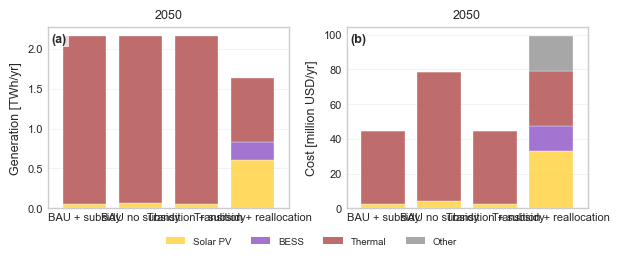

In [11]:
# Cross-scenario generation and cost figure
comparison_years = [year for year in [2030, 2050] if year in years]

def _norm_carrier(x):
    return str(x).strip().lower().replace(" ", "_").replace("-", "_")


def format_scenario_axis(ax, x, labels):
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=7)
    ax.tick_params(axis="x", pad=3)


def build_generation_group_df(df_year):
    """
    Annual electricity generation / dispatch by broad technology group [TWh/yr].

    Reconstructed directly from each optimized PyPSA network.
    """
    out = pd.DataFrame(0.0, index=df_year.index, columns=TECH_GROUPS)

    for idx, row in df_year.iterrows():
        scenario_code = row["scenario"]
        year = int(row["year"])
        net = scenario_results[scenario_code]["results"][year]["network"]

        try:
            weights = pd.Series(net.snapshot_weightings.objective, index=net.snapshots).astype(float)
        except Exception:
            weights = pd.Series(1.0, index=net.snapshots)

        # Generators
        if hasattr(net, "generators") and len(net.generators) > 0:
            p_gen = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0).clip(lower=0.0)

            for asset in net.generators.index:
                carrier = _norm_carrier(net.generators.loc[asset, "carrier"]) if "carrier" in net.generators.columns else ""
                group = GENERATOR_CARRIER_GROUP.get(carrier)

                energy_mwh = float((p_gen[asset] * weights).sum())

                if energy_mwh <= 1e-6:
                    continue

                if group is None:
                    group = "Other"

                out.loc[idx, group] += energy_mwh / 1e6

        # Storage-unit discharge
        if hasattr(net, "storage_units") and len(net.storage_units) > 0:
            p_su = net.storage_units_t.p.reindex(columns=net.storage_units.index, fill_value=0.0).clip(lower=0.0)

            for asset in net.storage_units.index:
                carrier = _norm_carrier(net.storage_units.loc[asset, "carrier"]) if "carrier" in net.storage_units.columns else ""
                group = STORAGE_UNIT_CARRIER_GROUP.get(carrier)

                energy_mwh = float((p_su[asset] * weights).sum())

                if energy_mwh <= 1e-6:
                    continue

                if group is None:
                    group = "Other"

                out.loc[idx, group] += energy_mwh / 1e6

        # Electricity-producing links
        if hasattr(net, "links") and len(net.links) > 0:
            for asset in net.links.index:
                carrier = _norm_carrier(net.links.loc[asset, "carrier"]) if "carrier" in net.links.columns else ""
                group = ELECTRICITY_OUTPUT_LINK_GROUP.get(carrier)

                if group is None:
                    continue

                # Link outputs are negative at output ports in PyPSA.
                output_candidates = []

                for port in ["p1", "p2", "p3", "p4"]:
                    if hasattr(net.links_t, port):
                        p = getattr(net.links_t, port)
                        if asset in p.columns:
                            s = (-p[asset]).clip(lower=0.0)
                            output_candidates.append(s)

                if not output_candidates:
                    continue

                output = max(output_candidates, key=lambda s: float((s * weights).sum()))
                energy_mwh = float((output * weights).sum())

                if energy_mwh <= 1e-6:
                    continue

                out.loc[idx, group] += energy_mwh / 1e6

    return out[TECH_GROUPS]


def build_cost_group_df(df_year):
    """
    Build system cost by broad technology group [million USD/yr],
    reconstructed directly from scenario_results.
    """
    out = pd.DataFrame(0.0, index=df_year.index, columns=TECH_GROUPS)

    for idx, row in df_year.iterrows():
        scenario_code = row["scenario"]
        year = int(row["year"])

        net = scenario_results[scenario_code]["results"][year]["network"]
        costs = estimate_cost_breakdown_from_network(net)
        if costs.empty:
            continue

        grouped = costs.groupby("group")["total_cost"].sum()

        for group, value in grouped.items():
            if group not in out.columns:
                out.loc[idx, "Other"] += float(value)
            else:
                out.loc[idx, group] += float(value)

    return out[TECH_GROUPS] / 1e6


def plot_stacked_bars(ax, stack_df, groups, colors, labels, ylabel):
    """Plot a stacked bar chart and return the displayed groups."""
    x = np.arange(len(stack_df))
    bottom = np.zeros(len(stack_df))
    plotted_groups = []

    for group in groups:
        if group not in stack_df.columns:
            continue
        values = stack_df[group].fillna(0.0).values
        if np.allclose(values.sum(), 0.0):
            continue
        ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.78,
            color=colors.get(group, "#999999"),
            alpha=0.90,
            label=group,
            edgecolor="white",
            linewidth=0.25,
        )
        bottom += values
        plotted_groups.append(group)

    format_scenario_axis(ax, x, labels)
    finish_axis(ax, ylabel=ylabel)
    ax.grid(False)
    ax.yaxis.grid(True, alpha=0.22)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.65, len(stack_df) - 0.35)
    return plotted_groups


if not comparison_years:
    raise ValueError("None of the requested comparison years are available.")

nrows = len(comparison_years)
fig, axes = plt.subplots(
    nrows,
    2,
    figsize=(WORD_DOUBLE_COL_IN, 2.45 * nrows),
    squeeze=False,
)

used_groups = set()

for row_i, year in enumerate(comparison_years):
    df_y = scenario_comparison[scenario_comparison["year"] == year].copy()

    df_y = df_y[df_y["scenario"].isin(SCENARIO_TECH_LABELS.keys())].copy()

    if df_y.empty:
        raise ValueError(f"No selected scenarios found for year {year}.")

    df_y["_order"] = df_y["scenario"].map(SCENARIO_ORDER_RANK)
    df_y = df_y.sort_values("_order").drop(columns="_order").reset_index(drop=True)

    df_y["label"] = df_y["scenario"].map(SCENARIO_TECH_LABELS).fillna(df_y["scenario"].astype(str))

    generation_group_df = build_generation_group_df(df_y)
    cost_group_df = build_cost_group_df(df_y)

    ax_gen = axes[row_i, 0]
    groups = plot_stacked_bars(
        ax_gen,
        generation_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Generation [TWh/yr]",
    )
    used_groups.update(groups)
    panel_label(ax_gen, f"({chr(97 + 2 * row_i)})")
    ax_gen.text(
        0.5,
        1.03,
        str(year),
        transform=ax_gen.transAxes,
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )

    ax_cost = axes[row_i, 1]
    groups = plot_stacked_bars(
        ax_cost,
        cost_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel=COST_AXIS_LABEL,
    )
    used_groups.update(groups)
    panel_label(ax_cost, f"({chr(98 + 2 * row_i)})")
    ax_cost.text(
        0.5,
        1.03,
        str(year),
        transform=ax_cost.transAxes,
        ha="center",
        va="bottom",
        fontsize=9,
        clip_on=False,
    )


# Shared legend
legend_handles = []
legend_labels = []

for group in TECH_GROUPS:
    if group not in used_groups:
        continue

    handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=TECH_COLORS_GROUPED.get(group, "#999999"),
        edgecolor="none",
        alpha=0.90,
    )
    legend_handles.append(handle)
    legend_labels.append(group)

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=4,
    frameon=False,
    fontsize=7,
)

plt.tight_layout()
fig.subplots_adjust(top=0.94, bottom=0.20 if nrows == 1 else 0.14, hspace=0.28, wspace=0.24)

years_tag = "_".join(str(year) for year in comparison_years)
fig_path = save_paper_figure(
    fig,
    f"figure_cross_scenario_generation_cost_{years_tag}.png",
)
plt.show()


Saved figure: output\output_punta_arenas_2\figures\cross_scenario_all_years\figure_supp_cross_scenario_decomposition_2025.png


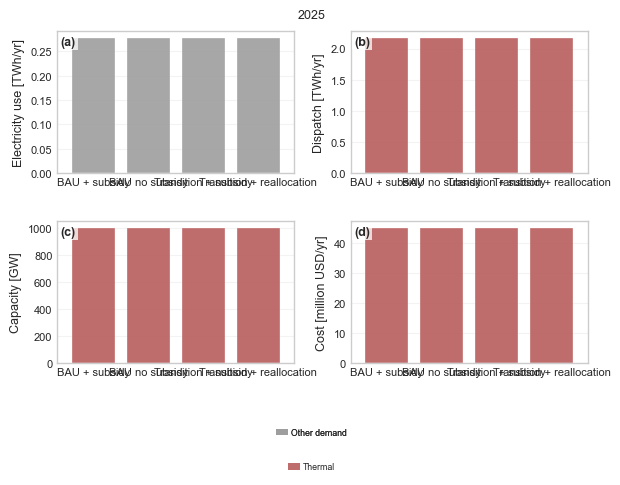

Saved figure: output\output_punta_arenas_2\figures\cross_scenario_all_years\figure_supp_cross_scenario_decomposition_2050.png


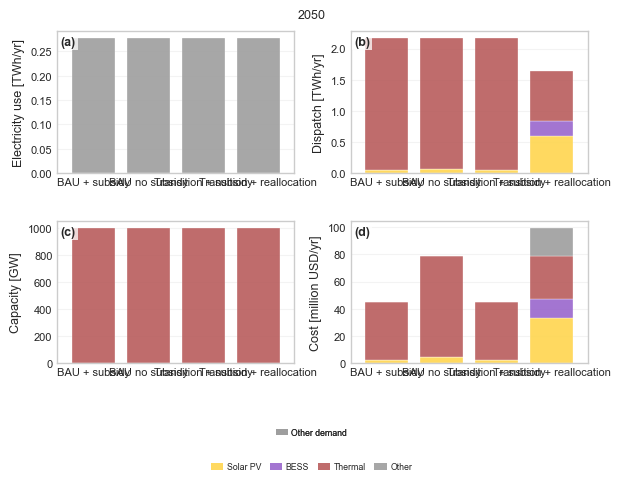

In [12]:
# Supplementary cross-scenario decomposition
cross_scenario_years_to_plot = years
cross_scenario_export_dir = PAPER_FIGURE_DIR / "cross_scenario_all_years"
cross_scenario_export_dir.mkdir(parents=True, exist_ok=True)


def build_demand_group_df(df_year):
    """Build electricity-use decomposition [TWh/yr]."""
    out = pd.DataFrame(index=df_year.index)

    if demand_breakdown_summary.empty:
        raise ValueError("Demand breakdown is empty. Run the previous section first.")

    demand_y = demand_breakdown_summary[
        demand_breakdown_summary["year"] == int(df_year["year"].iloc[0])
    ].copy()
    demand_y = apply_scenario_order(demand_y)
    demand_y = demand_y.set_index("scenario").reindex(df_year["scenario"])

    mapping = {
        "Base load": "demand_base_load_mwh",
        "Heating": "demand_heating_mwh",
        "EVs": "demand_ev_mwh",
        "Cooking": "demand_cooking_mwh",
        "Process electrification": "demand_process_electrification_mwh",
        "Electrolyser": "electrolyser_input_mwh",
        "PtX auxiliaries": "ptx_aux_electricity_mwh",
        "Other local demand": "demand_other_mwh",
    }

    for group, col in mapping.items():
        if col in demand_y.columns:
            out[group] = demand_y[col].fillna(0.0).values / 1e6
        else:
            out[group] = 0.0

    for group in DEMAND_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[DEMAND_GROUPS]


def build_dispatch_group_df(df_year):
    """Build annual electricity dispatch by technology [TWh/yr]."""
    out = pd.DataFrame(index=df_year.index)

    out["Wind"] = df_year.get("generation_wind_mwh", 0.0) / 1e6
    out["Solar PV"] = df_year.get("generation_solar_mwh", 0.0) / 1e6
    out["BESS"] = df_year.get("bess_discharge_mwh", 0.0) / 1e6

    thermal_cols = [
        "generation_ocgt_mwh",
        "generation_gas_mwh",
        "generation_natural_gas_mwh",
        "generation_diesel_mwh",
    ]
    valid_thermal_cols = [c for c in thermal_cols if c in df_year.columns]
    out["Thermal"] = (
        df_year[valid_thermal_cols].fillna(0.0).sum(axis=1) / 1e6
        if valid_thermal_cols else 0.0
    )

    if "h2_to_power_mwh" in df_year.columns:
        out["Hydrogen"] = df_year["h2_to_power_mwh"].fillna(0.0) / 1e6
    else:
        h2_cols = ["h2_fuel_cell_output_mwh", "h2_turbine_output_mwh"]
        valid_h2_cols = [c for c in h2_cols if c in df_year.columns]
        out["Hydrogen"] = (
            df_year[valid_h2_cols].fillna(0.0).sum(axis=1) / 1e6
            if valid_h2_cols else 0.0
        )

    out["PtX"] = 0.0
    out["Slack"] = df_year.get("generation_slack_mwh", 0.0) / 1e6
    out["Other"] = 0.0

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]


def build_capacity_group_df(df_year):
    """Build installed capacity by technology [GW]."""
    out = pd.DataFrame(index=df_year.index)

    out["Wind"] = df_year.get("cap_wind_mw", 0.0) / 1e3
    out["Solar PV"] = df_year.get("cap_solar_mw", 0.0) / 1e3
    out["BESS"] = df_year.get("cap_bess_mw", 0.0) / 1e3

    thermal_cols = ["cap_ocgt_mw", "cap_gas_mw", "cap_natural_gas_mw", "cap_diesel_mw"]
    valid_thermal_cols = [c for c in thermal_cols if c in df_year.columns]
    out["Thermal"] = (
        df_year[valid_thermal_cols].fillna(0.0).sum(axis=1) / 1e3
        if valid_thermal_cols else 0.0
    )

    hydrogen_cols = [
        "linkcap_electrolyzer_mw",
        "linkcap_h2_fuel_cell_mw",
        "linkcap_h2_turbine_mw",
    ]
    valid_hydrogen_cols = [c for c in hydrogen_cols if c in df_year.columns]
    out["Hydrogen"] = (
        df_year[valid_hydrogen_cols].fillna(0.0).sum(axis=1) / 1e3
        if valid_hydrogen_cols else 0.0
    )

    out["PtX"] = 0.0
    out["Slack"] = 0.0
    out["Other"] = 0.0

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]


def plot_cross_scenario_supplementary(comparison_year, save_figure=True, show_figure=True):
    df_y = scenario_comparison[scenario_comparison["year"] == comparison_year].copy()

    if df_y.empty:
        raise ValueError(f"No scenario comparison data found for {comparison_year}.")

    df_y = apply_scenario_order(df_y).reset_index(drop=True)
    df_y["label"] = df_y["scenario"].map(SCENARIO_TECH_LABELS).fillna(df_y["scenario"].astype(str))

    demand_group_df = build_demand_group_df(df_y)
    dispatch_group_df = build_dispatch_group_df(df_y)
    capacity_group_df = build_capacity_group_df(df_y)
    cost_group_df = build_cost_group_df(df_y)

    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_PAPER_2X2)

    used_demand_groups = set()
    used_tech_groups = set()

    used = plot_stacked_bars(
        axes[0, 0],
        demand_group_df,
        DEMAND_GROUPS,
        DEMAND_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Electricity use [TWh/yr]",
    )
    used_demand_groups.update(used)
    panel_label(axes[0, 0], "(a)")

    used = plot_stacked_bars(
        axes[0, 1],
        dispatch_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Dispatch [TWh/yr]",
    )
    used_tech_groups.update(used)
    panel_label(axes[0, 1], "(b)")

    used = plot_stacked_bars(
        axes[1, 0],
        capacity_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel="Capacity [GW]",
    )
    used_tech_groups.update(used)
    panel_label(axes[1, 0], "(c)")

    used = plot_stacked_bars(
        axes[1, 1],
        cost_group_df,
        TECH_GROUPS,
        TECH_COLORS_GROUPED,
        df_y["label"].tolist(),
        ylabel=COST_AXIS_LABEL,
    )
    used_tech_groups.update(used)
    panel_label(axes[1, 1], "(d)")

    fig.text(
        0.5,
        0.975,
        str(comparison_year),
        ha="center",
        va="top",
        fontsize=9,
    )

    # Figure-level legends
    demand_handles = []
    demand_labels = []
    for group in DEMAND_GROUPS:
        if group not in used_demand_groups:
            continue

        demand_handles.append(
            plt.Rectangle(
                (0, 0), 1, 1,
                facecolor=DEMAND_COLORS_GROUPED.get(group, "#999999"),
                edgecolor="none",
                alpha=0.90,
            )
        )
        demand_labels.append(DEMAND_LEGEND_LABELS.get(group, group))

    tech_handles = []
    tech_labels = []

    for group in TECH_GROUPS:
        if group not in used_tech_groups:
            continue

        tech_handles.append(
            plt.Rectangle(
                (0, 0), 1, 1,
                facecolor=TECH_COLORS_GROUPED.get(group, "#999999"),
                edgecolor="none",
                alpha=0.90,
            )
        )
        tech_labels.append(TECH_LEGEND_LABELS.get(group, group))

    leg1 = fig.legend(
        demand_handles,
        demand_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.095),
        ncol=4,
        frameon=False,
        fontsize=6.3,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.4,
    )
    fig.add_artist(leg1)

    fig.legend(
        tech_handles,
        tech_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.025),
        ncol=4,
        frameon=False,
        fontsize=6.3,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.4,
    )
    plt.tight_layout()
    fig.subplots_adjust(top=0.93, bottom=0.26, hspace=0.34, wspace=0.24)

    out_path = None
    if save_figure:
        out_path = save_paper_figure(
            fig,
            f"figure_supp_cross_scenario_decomposition_{comparison_year}.png",
            folder=cross_scenario_export_dir,
        )

    if show_figure:
        plt.show()
    else:
        plt.close(fig)

    return out_path


for comparison_year in cross_scenario_years_to_plot:
    plot_cross_scenario_supplementary(comparison_year)


In [13]:
# Former Figure 6 retired: retain only reliability indicators
#
# Storage/flexibility capacity and operation are now reported in the table
# exported by Figure 5 and in each scenario's *_bess_by_year.csv file.
comparison_year = detailed_year
df_y = scenario_comparison[scenario_comparison["year"] == comparison_year].copy()
if df_y.empty:
    raise ValueError(f"No scenario comparison data found for {comparison_year}.")
df_y = apply_scenario_order(df_y).reset_index(drop=True)

reliability_check = pd.DataFrame({
    "scenario": df_y["scenario"],
    "paper_id": df_y["paper_id"] if "paper_id" in df_y.columns else "",
    "year": df_y["year"],
    "slack_generation_gwh": df_y["slack_generation_mwh"].fillna(0.0) / 1e3,
    "curtailment_gwh": df_y["curtailment_total_mwh"].fillna(0.0) / 1e3,
})
display(reliability_check.round(3))


,scenario,paper_id,year,slack_generation_gwh,curtailment_gwh
0,BAU_SUB,S1,2050,0.0,0.372
1,BAU_NOSUB,S2,2050,0.0,9.378
2,TRANS_SUB,S3,2050,0.0,0.372
3,TRANS_NOSUB,S4,2050,0.0,50.616


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 5 — Demand, electricity supply, flexibility, capacity, and cost
#
# (a) Hourly local-demand components and PtX electricity use
# (b) Annual electricity supply
# (c) Annual flexible electricity supply
# (d) Installed power capacity
# (e) Annual system cost
#
# The former Figure 6 is exported below as a numerical table.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.dates as mdates


# ── Configuration ────────────────────────────────────────────────────────────
comparison_year = detailed_year

figure5_export_dir = (
    PAPER_FIGURE_DIR
    / "cross_scenario_all_years"
)

figure5_export_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Prefer the explicit PtX scenario for panel (a).
profile_scenario = (
    "PTX_base"
    if "PTX_base" in scenario_results
    else None
)

# Otherwise, find the first scenario with PtX enabled.
if profile_scenario is None:
    profile_scenario = next(
        (
            scenario_code
            for scenario_code, package in scenario_results.items()
            if package.get("metadata", {}).get("enable_ptx", False)
        ),
        None,
    )

if profile_scenario is None:
    pass#raise ValueError(
    #    "No PtX-enabled scenario was found for panel (a)."
    #)


# ── Validation and scenario ordering ─────────────────────────────────────────
df_y = scenario_comparison[
    scenario_comparison["year"] == comparison_year
].copy()

if df_y.empty:
    raise ValueError(
        f"No scenario comparison data found for {comparison_year}."
    )

df_y = (
    apply_scenario_order(df_y)
    .reset_index(drop=True)
)

df_y["label"] = (
    df_y["scenario"]
    .map(SCENARIO_TECH_LABELS)
    .fillna(
        df_y["scenario"]
        .astype(str)
        .str.replace("_", " ", regex=False)
    )
)


# ── General helpers ──────────────────────────────────────────────────────────
def column_or_zero(df, column):
    """Return a numeric column or a zero-valued Series."""
    if column in df.columns:
        return (
            pd.to_numeric(
                df[column],
                errors="coerce",
            )
            .fillna(0.0)
        )

    return pd.Series(
        0.0,
        index=df.index,
        dtype=float,
    )


def link_input_series(net, carriers):
    """Aggregate positive p0 electricity input for selected links [MW]."""
    snapshots = pd.Index(net.snapshots)

    if (
        len(net.links) == 0
        or not hasattr(net.links_t, "p0")
    ):
        return pd.Series(
            0.0,
            index=snapshots,
        )

    carriers = set(carriers)

    selected_links = net.links.index[
        net.links["carrier"]
        .astype(str)
        .isin(carriers)
    ]

    if len(selected_links) == 0:
        return pd.Series(
            0.0,
            index=snapshots,
        )

    return (
        net.links_t.p0
        .reindex(
            index=snapshots,
            columns=selected_links,
            fill_value=0.0,
        )
        .clip(lower=0.0)
        .sum(axis=1)
    )


# ── Annual electricity supply ────────────────────────────────────────────────
def build_dispatch_group_df(df_year):
    """Build annual electricity supply by technology [TWh/yr]."""
    out = pd.DataFrame(index=df_year.index)

    out["Wind"] = (
        column_or_zero(df_year, "generation_wind_mwh")
        / 1e6
    )

    out["Solar PV"] = (
        column_or_zero(df_year, "generation_solar_mwh")
        / 1e6
    )

    out["BESS"] = (
        column_or_zero(df_year, "bess_discharge_mwh")
        / 1e6
    )

    thermal_columns = [
        "generation_ocgt_mwh",
        "generation_gas_mwh",
        "generation_natural_gas_mwh",
        "generation_diesel_mwh",
    ]

    valid_thermal_columns = [
        column
        for column in thermal_columns
        if column in df_year.columns
    ]

    if valid_thermal_columns:
        out["Thermal"] = (
            df_year[valid_thermal_columns]
            .fillna(0.0)
            .sum(axis=1)
            / 1e6
        )
    else:
        out["Thermal"] = (
            column_or_zero(
                df_year,
                "thermal_generation_mwh",
            )
            / 1e6
        )

    if "h2_to_power_mwh" in df_year.columns:
        out["Hydrogen"] = (
            column_or_zero(
                df_year,
                "h2_to_power_mwh",
            )
            / 1e6
        )
    else:
        out["Hydrogen"] = (
            column_or_zero(
                df_year,
                "h2_fuel_cell_output_mwh",
            )
            + column_or_zero(
                df_year,
                "h2_turbine_output_mwh",
            )
        ) / 1e6

    out["PtX"] = 0.0

    out["Slack"] = (
        column_or_zero(
            df_year,
            "generation_slack_mwh",
        )
        / 1e6
    )

    out["Other"] = 0.0

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]


# ── Annual flexible electricity supply ──────────────────────────────────────
FLEXIBILITY_GROUPS = [
    "Thermal",
    "BESS",
    "Hydrogen",
]


def build_flexibility_group_df(df_year):
    """
    Build annual flexible electricity supplied by thermal generation,
    BESS discharge, and hydrogen-to-power [GWh/yr].
    """
    out = pd.DataFrame(index=df_year.index)

    out["Thermal"] = (
        column_or_zero(
            df_year,
            "thermal_generation_mwh",
        )
        / 1e3
    )

    out["BESS"] = (
        column_or_zero(
            df_year,
            "bess_discharge_mwh",
        )
        / 1e3
    )

    out["Hydrogen"] = (
        column_or_zero(
            df_year,
            "h2_to_power_mwh",
        )
        / 1e3
    )

    return out[FLEXIBILITY_GROUPS]


# ── Installed capacity ───────────────────────────────────────────────────────
def build_capacity_group_df(df_year):
    """Build installed power capacity by technology [GW]."""
    out = pd.DataFrame(index=df_year.index)

    out["Wind"] = (
        column_or_zero(df_year, "cap_wind_mw")
        / 1e3
    )

    out["Solar PV"] = (
        column_or_zero(df_year, "cap_solar_mw")
        / 1e3
    )

    out["BESS"] = (
        column_or_zero(df_year, "cap_bess_mw")
        / 1e3
    )

    thermal_columns = [
        "cap_ocgt_mw",
        "cap_gas_mw",
        "cap_natural_gas_mw",
        "cap_diesel_mw",
    ]

    valid_thermal_columns = [
        column
        for column in thermal_columns
        if column in df_year.columns
    ]

    out["Thermal"] = (
        df_year[valid_thermal_columns]
        .fillna(0.0)
        .sum(axis=1)
        / 1e3
        if valid_thermal_columns
        else 0.0
    )

    hydrogen_columns = [
        "linkcap_electrolyzer_mw",
        "linkcap_h2_fuel_cell_mw",
        "linkcap_h2_turbine_mw",
    ]

    valid_hydrogen_columns = [
        column
        for column in hydrogen_columns
        if column in df_year.columns
    ]

    out["Hydrogen"] = (
        df_year[valid_hydrogen_columns]
        .fillna(0.0)
        .sum(axis=1)
        / 1e3
        if valid_hydrogen_columns
        else 0.0
    )

    out["PtX"] = 0.0
    out["Slack"] = 0.0
    out["Other"] = 0.0

    for group in TECH_GROUPS:
        if group not in out.columns:
            out[group] = 0.0

    return out[TECH_GROUPS]


# ── Prepare annual panel data ────────────────────────────────────────────────
dispatch_group_df = build_dispatch_group_df(df_y)
flexibility_group_df = build_flexibility_group_df(df_y)
capacity_group_df = build_capacity_group_df(df_y)
cost_group_df = build_cost_group_df(df_y)


# ── Prepare hourly demand-component and PtX profiles ─────────────────────────
profile_package = scenario_results[profile_scenario]

if comparison_year not in profile_package["results"]:
    raise ValueError(
        f"{profile_scenario} has no result for {comparison_year}."
    )

profile_result = profile_package["results"][comparison_year]
profile_net = profile_result["network"]


def normalise_profile_index(values):
    """Return a timezone-naive DatetimeIndex for profile alignment."""
    index = pd.DatetimeIndex(
        pd.to_datetime(values)
    )

    if index.tz is not None:
        index = index.tz_localize(None)

    return index


profile_snapshots = normalise_profile_index(
    profile_net.snapshots
)

demand_components_df, demand_components_path, _ = (
    load_demand_components_for_scenario(
        profile_scenario,
        package=profile_package,
    )
)

if demand_components_df.empty:
    raise FileNotFoundError(
        "Panel (a) requires demand_components_<scenario>.csv. "
        f"No component file was found for {profile_scenario}."
    )

if "timestamp" not in demand_components_df.columns:
    raise ValueError(
        f"{demand_components_path} has no 'timestamp' column."
    )

component_year = demand_components_df[
    demand_components_df["year"]
    .astype(int)
    .eq(int(comparison_year))
].copy()

if component_year.empty:
    raise ValueError(
        f"{demand_components_path} has no demand components for "
        f"{comparison_year}."
    )

component_year["component_key"] = (
    component_year["component"]
    .map(_safe_component_name)
)

component_profiles = (
    component_year
    .pivot_table(
        index="timestamp",
        columns="component_key",
        values="demand_mw",
        aggfunc="sum",
        fill_value=0.0,
    )
    .sort_index()
)

component_profiles.index = normalise_profile_index(
    component_profiles.index
)

# Sum duplicated timestamps, if any, after aggregating zones.
component_profiles = (
    component_profiles
    .groupby(level=0)
    .sum()
    .sort_index()
)

# If the CSV uses another calendar year but preserves the hourly sequence,
# align it by position with the solved network.
if not component_profiles.index.equals(profile_snapshots):
    if len(component_profiles) != len(profile_snapshots):
        raise ValueError(
            "Demand-component profiles cannot be aligned with the solved "
            f"network: {len(component_profiles)} component timestamps versus "
            f"{len(profile_snapshots)} network snapshots."
        )

    component_profiles.index = profile_snapshots

component_profiles = (
    component_profiles
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .clip(lower=0.0)
)

# Stable paper order, followed automatically by any future component.
active_components = [
    component
    for component in component_profiles.columns
    if component_profiles[component].abs().max() > 1e-9
]

preferred_component_order = [
    "base_load",
    "heating",
    "ev",
    "cooking",
    "process_electrification",
    "other",
]

profile_component_order = [
    component
    for component in preferred_component_order
    if component in active_components
]

profile_component_order += sorted(
    component
    for component in active_components
    if component not in profile_component_order
)

if not profile_component_order:
    raise ValueError(
        f"No active electricity-demand components were found for "
        f"{comparison_year} in {demand_components_path}."
    )

component_profiles = component_profiles[
    profile_component_order
]

component_rolling = (
    component_profiles
    .rolling(
        window=168,
        center=True,
        min_periods=24,
    )
    .mean()
)

# PtX remains separate because it is optimised flexible electricity use,
# rather than an exogenous component from demand_components_<scenario>.csv.
electrolyser_use = link_input_series(
    profile_net,
    ["electrolyzer"],
)

ptx_aux_use = link_input_series(
    profile_net,
    ["asu", "dac"],
)

ptx_profile = pd.DataFrame(
    {
        "Electrolyser": electrolyser_use.to_numpy(),
        "PtX auxiliaries": ptx_aux_use.to_numpy(),
    },
    index=profile_snapshots,
)

ptx_profile = (
    ptx_profile
    .sort_index()
    .clip(lower=0.0)
)

ptx_rolling = (
    ptx_profile
    .rolling(
        window=168,
        center=True,
        min_periods=24,
    )
    .mean()
)

ptx_total = (
    ptx_profile["Electrolyser"]
    + ptx_profile["PtX auxiliaries"]
)

ptx_total_rolling = (
    ptx_rolling["Electrolyser"]
    + ptx_rolling["PtX auxiliaries"]
)


# ── Figure layout ────────────────────────────────────────────────────────────
n_profile_axes = len(profile_component_order) + 1
additional_profile_axes = max(0, n_profile_axes - 2)

# Increase figure height as new demand components appear.
figure_height = 7.20 + 0.72 * additional_profile_axes
profile_height_ratio = 1.18 * n_profile_axes / 2.0

fig = plt.figure(
    figsize=(
        WORD_DOUBLE_COL_IN,
        figure_height,
    )
)

outer_gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[
        profile_height_ratio,
        1.0,
        1.0,
    ],
    hspace=0.48,
    wspace=0.27,
)

# One strip per local-demand component, followed by a separate PtX strip.
profile_gs = outer_gs[0, :].subgridspec(
    nrows=n_profile_axes,
    ncols=1,
    height_ratios=[1.0] * n_profile_axes,
    hspace=0.10,
)

profile_axes = []

for row_index in range(len(profile_component_order)):
    axis = fig.add_subplot(
        profile_gs[row_index, 0],
        sharex=profile_axes[0] if profile_axes else None,
    )
    profile_axes.append(axis)

ax_a_ptx = fig.add_subplot(
    profile_gs[-1, 0],
    sharex=profile_axes[0],
)

ax_b = fig.add_subplot(outer_gs[1, 0])
ax_c = fig.add_subplot(outer_gs[1, 1])
ax_d = fig.add_subplot(outer_gs[2, 0])
ax_e = fig.add_subplot(outer_gs[2, 1])


# ── (a) Hourly local-demand components and PtX electricity use ───────────────
electrolyser_color = DEMAND_COLORS_GROUPED.get(
    "Electrolyser",
    TECH_COLORS.get(
        "electrolyzer",
        "#00897b",
    ),
)

ptx_aux_color = DEMAND_COLORS_GROUPED.get(
    "PtX auxiliaries",
    TECH_COLORS.get(
        "asu",
        "#80cbc4",
    ),
)

fallback_component_colors = plt.get_cmap("tab10")

for component_index, (axis, component) in enumerate(
    zip(
        profile_axes,
        profile_component_order,
    )
):
    component_label = DEMAND_COMPONENT_LABELS.get(
        component,
        component.replace("_", " ").title(),
    )

    component_color = DEMAND_COMPONENT_COLORS.get(
        component,
        fallback_component_colors(
            component_index % 10
        ),
    )

    # Thin line: hourly profile.
    axis.plot(
        component_profiles.index,
        component_profiles[component],
        color=component_color,
        linewidth=0.35,
        alpha=0.28,
    )

    # Thick line: seven-day rolling average.
    axis.plot(
        component_rolling.index,
        component_rolling[component],
        color=component_color,
        linewidth=1.35,
    )

    axis.set_ylabel(
        f"{component_label}\n[MW]"
    )

    axis.set_ylim(bottom=0.0)

    axis.grid(
        axis="y",
        alpha=0.22,
    )

    axis.set_axisbelow(True)

    axis.tick_params(
        axis="x",
        labelbottom=False,
    )

panel_label(
    profile_axes[0],
    "(a)",
)

# PtX electricity use: stacked hourly areas and seven-day total mean.
ax_a_ptx.fill_between(
    ptx_profile.index,
    0.0,
    ptx_profile["Electrolyser"],
    color=electrolyser_color,
    alpha=0.82,
    linewidth=0.0,
    step="mid",
    label="Electrolyser",
)

ax_a_ptx.fill_between(
    ptx_profile.index,
    ptx_profile["Electrolyser"],
    ptx_total,
    color=ptx_aux_color,
    alpha=0.82,
    linewidth=0.0,
    step="mid",
    label="PtX auxiliaries",
)

ax_a_ptx.plot(
    ptx_total_rolling.index,
    ptx_total_rolling,
    color="black",
    linewidth=1.05,
    linestyle="--",
    label="Total PtX: 7-day mean",
)

ax_a_ptx.set_ylabel(
    "PtX use\n[MW]"
)

ax_a_ptx.set_ylim(bottom=0.0)

ax_a_ptx.set_xlabel(
    "Month"
)

ax_a_ptx.grid(
    axis="y",
    alpha=0.22,
)

ax_a_ptx.set_axisbelow(True)

ax_a_ptx.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax_a_ptx.xaxis.set_major_formatter(
    mdates.DateFormatter("%b")
)

ax_a_ptx.set_xlim(
    profile_snapshots.min(),
    profile_snapshots.max(),
)

ax_a_ptx.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.36),
    ncol=3,
    frameon=False,
    fontsize=FONT_SIZE_SMALL,
    columnspacing=1.1,
    handlelength=1.5,
    handletextpad=0.4,
)


# ── (b) Annual electricity supply ───────────────────────────────────────────
used_tech_groups = set()

used = plot_stacked_bars(
    ax_b,
    dispatch_group_df,
    TECH_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel="Electricity supply [TWh/yr]",
)

used_tech_groups.update(used)

panel_label(
    ax_b,
    "(b)",
)


# ── (c) Annual flexible electricity supply ──────────────────────────────────
used = plot_stacked_bars(
    ax_c,
    flexibility_group_df,
    FLEXIBILITY_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel="Dispatchable supply [GWh/yr]",
)

used_tech_groups.update(used)

panel_label(
    ax_c,
    "(c)",
)


# ── (d) Installed power capacity ─────────────────────────────────────────────
used = plot_stacked_bars(
    ax_d,
    capacity_group_df,
    TECH_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel="Capacity [GW]",
)

used_tech_groups.update(used)

panel_label(
    ax_d,
    "(d)",
)


# ── (e) Annual system cost ───────────────────────────────────────────────────
used = plot_stacked_bars(
    ax_e,
    cost_group_df,
    TECH_GROUPS,
    TECH_COLORS_GROUPED,
    df_y["label"].tolist(),
    ylabel=COST_AXIS_LABEL,
)

used_tech_groups.update(used)

panel_label(
    ax_e,
    "(e)",
)


# ── Shared technology legend ─────────────────────────────────────────────────
tech_handles = []
tech_labels = []

for group in TECH_GROUPS:
    if group not in used_tech_groups:
        continue

    tech_handles.append(
        plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=TECH_COLORS_GROUPED.get(
                group,
                "#999999",
            ),
            edgecolor="none",
            alpha=0.90,
        )
    )

    tech_labels.append(
        TECH_LEGEND_LABELS.get(
            group,
            group,
        )
    )

fig.legend(
    tech_handles,
    tech_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.018),
    ncol=5,
    frameon=False,
    fontsize=FONT_SIZE_SMALL,
    columnspacing=1.0,
    handlelength=1.4,
    handletextpad=0.4,
)


# ── Final figure spacing ─────────────────────────────────────────────────────
fig.subplots_adjust(
    top=0.985,
    bottom=0.12,
    left=0.105,
    right=0.985,
)


# ── Export Figure 5 ──────────────────────────────────────────────────────────
figure5_paths = []

for extension in [
    "png",
    "svg",
    "pdf",
]:
    figure5_paths.append(
        save_paper_figure(
            fig,
            (
                f"figure05_system_design_"
                f"{comparison_year}.{extension}"
            ),
            folder=figure5_export_dir,
        )
    )

plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Table replacing the former Figure 6
# ─────────────────────────────────────────────────────────────────────────────
bess_power_mw = column_or_zero(
    df_y,
    "cap_bess_mw",
)

bess_energy_mwh = column_or_zero(
    df_y,
    "energy_bess_mwh",
)

bess_duration_h = (
    bess_energy_mwh
    .div(
        bess_power_mw.replace(
            0.0,
            np.nan,
        )
    )
    .fillna(0.0)
)

flexibility_table = pd.DataFrame(
    {
        "Scenario": df_y["label"],
        "Thermal generation [GWh/yr]": (
            column_or_zero(
                df_y,
                "thermal_generation_mwh",
            )
            / 1e3
        ),
        "BESS discharge [GWh/yr]": (
            column_or_zero(
                df_y,
                "bess_discharge_mwh",
            )
            / 1e3
        ),
        "BESS power capacity [MW]": bess_power_mw,
        "BESS energy capacity [GWh]": (
            bess_energy_mwh
            / 1e3
        ),
        "BESS duration [h]": bess_duration_h,
        "H2-to-power output [GWh/yr]": (
            column_or_zero(
                df_y,
                "h2_to_power_mwh",
            )
            / 1e3
        ),
        "H2 tank/other capacity [GWh]": (
            column_or_zero(
                df_y,
                "h2_storage_total_mwh",
            )
            / 1e3
        ),
        "UHS capacity [GWh]": (
            column_or_zero(
                df_y,
                "uhs_storage_total_mwh",
            )
            / 1e3
        ),
    }
)

flexibility_table["BESS equivalent cycles [1/yr]"] = (
    flexibility_table["BESS discharge [GWh/yr]"]
    .div(
        flexibility_table["BESS energy capacity [GWh]"]
        .replace(0.0, np.nan)
    )
    .fillna(0.0)
)

flexibility_table_path = (
    TABLE_EXPORT_DIR
    / f"table_flexibility_requirements_{comparison_year}.csv"
)

flexibility_table.to_csv(
    flexibility_table_path,
    index=False,
)

display(
    flexibility_table.round(3)
)

print(
    f"Saved flexibility table to: "
    f"{flexibility_table_path}"
)

KeyError: None

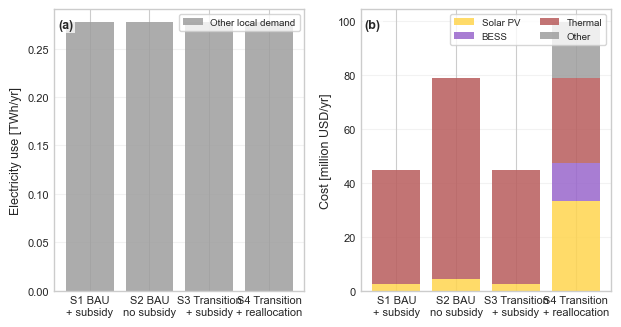

In [15]:
# Demand and cost decomposition figure
if demand_breakdown_summary.empty:
    raise ValueError("Run the demand/cost breakdown cell first.")

demand_y = apply_scenario_order(demand_breakdown_summary[demand_breakdown_summary["year"] == breakdown_year])
demand_y["label"] = [scenario_axis_label(s) for s in demand_y["scenario"]]

x = np.arange(len(demand_y))
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_2COL)

# (a) Electricity-use decomposition from demand_profiles_scenarios + PtX link use
ax = axes[0]
component_stack = [
    ("demand_base_load_mwh", "Base load", DEMAND_COMPONENT_COLORS.get("base_load", "#4c78a8")),
    ("demand_heating_mwh", "Heating", DEMAND_COMPONENT_COLORS.get("heating", "#f58518")),
    ("demand_ev_mwh", "EVs", DEMAND_COMPONENT_COLORS.get("ev", "#54a24b")),
    ("demand_cooking_mwh", "Cooking", DEMAND_COMPONENT_COLORS.get("cooking", "#b279a2")),
    ("demand_process_electrification_mwh", "Process electrification", DEMAND_COMPONENT_COLORS.get("process_electrification", "#e45756")),
    ("demand_other_mwh", "Other local demand", DEMAND_COMPONENT_COLORS.get("other", "#9e9e9e")),
    ("electrolyser_input_mwh", "Electrolyser", DEMAND_COMPONENT_COLORS.get("electrolyser", TECH_COLORS.get("electrolyzer", "#00897b"))),
    ("ptx_aux_electricity_mwh", "PtX auxiliaries", DEMAND_COMPONENT_COLORS.get("ptx_aux", TECH_COLORS.get("asu", "#80cbc4"))),
]
component_stack = [
    item for item in component_stack
    if item[0] in demand_y.columns and demand_y[item[0]].fillna(0).sum() > 1e-6
]

bottom = np.zeros(len(demand_y))
for col, label, color in component_stack:
    vals = demand_y[col].fillna(0).values / 1e6
    ax.bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(demand_y["label"], rotation=0, ha="center")
finish_axis(ax, ylabel="Electricity use [TWh/yr]")
ax.legend(frameon=True, ncol=2, fontsize=7)
panel_label(ax, "(a)")

# (b) Approximate cost decomposition
ax = axes[1]
if cost_breakdown_summary.empty:
    ax.text(0.5, 0.5, "No cost breakdown available", ha="center", va="center", transform=ax.transAxes)
else:
    cost_y = cost_breakdown_summary[cost_breakdown_summary["year"] == breakdown_year].copy()
    group_order = TECH_GROUPS
    pivot = (
        cost_y.pivot_table(index="scenario", columns="group", values="total_cost", aggfunc="sum")
        .reindex(demand_y["scenario"])
        .fillna(0.0)
    )
    bottom = np.zeros(len(pivot))
    for group in [g for g in group_order if g in pivot.columns and pivot[g].sum() > 0]:
        vals = pivot[group].values / 1e6
        ax.bar(x, vals, bottom=bottom, label=group, color=TECH_COLORS_GROUPED.get(group, "#999999"), alpha=0.85)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(demand_y["label"], rotation=0, ha="center")
finish_axis(ax, ylabel=COST_AXIS_LABEL)
ax.legend(frameon=True, ncol=2, fontsize=7)
panel_label(ax, "(b)")

plt.tight_layout()
plt.show()


## 7. Renewable scarcity and critical-event dispatch

Daily wind and solar capacity factors identify low-renewable periods and the longest simultaneous scarcity event. Dispatch is then reconstructed from the exported CSV files for the same event window across scenarios.

In [16]:
# Renewable-scarcity helper functions

def _prepare_cf_series(cf_df: pd.DataFrame) -> pd.Series:
    """Average capacity-factor profiles across zones."""
    if cf_df is None or cf_df.empty:
        raise ValueError("No capacity-factor data are available.")

    cf = cf_df.copy()
    if not isinstance(cf.index, pd.DatetimeIndex):
        cf.index = pd.to_datetime(cf.index)

    return cf.mean(axis=1)


def _daily_mean_series(cf_series: pd.Series) -> pd.Series:
    return cf_series.resample("D").mean()


def _monthly_max_consecutive_low_days(
    daily_cf: pd.Series,
    threshold: float,
) -> pd.Series:
    month_labels = [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
    result = pd.Series(0.0, index=month_labels)

    for month_num, month_data in daily_cf.groupby(daily_cf.index.month):
        maximum = 0
        current = 0
        for is_low in month_data.lt(threshold):
            current = current + 1 if is_low else 0
            maximum = max(maximum, current)
        result.iloc[month_num - 1] = maximum

    return result


def _longest_true_run(mask: pd.Series) -> tuple[pd.Timestamp | None, pd.Timestamp | None, int]:
    """Return the start, end, and duration of the longest True run."""
    mask = mask.astype(bool)
    best_start = best_end = current_start = None
    best_length = current_length = 0

    for timestamp, value in mask.items():
        if value:
            if current_start is None:
                current_start = timestamp
            current_length += 1
            if current_length > best_length:
                best_start = current_start
                best_end = timestamp
                best_length = current_length
        else:
            current_start = None
            current_length = 0

    return best_start, best_end, best_length



Plotting combined Figure 4 for TRANS_NOSUB – 2050...
Saved figure: output\output_punta_arenas_2\figures\figure04_capacity_factor_combined\figure04_combined_TRANS_NOSUB_2050.png
Saved figure: output\output_punta_arenas_2\figures\figure04_capacity_factor_combined\figure04_combined_TRANS_NOSUB_2050.svg
Saved figure: output\output_punta_arenas_2\figures\figure04_capacity_factor_combined\figure04_combined_TRANS_NOSUB_2050.pdf


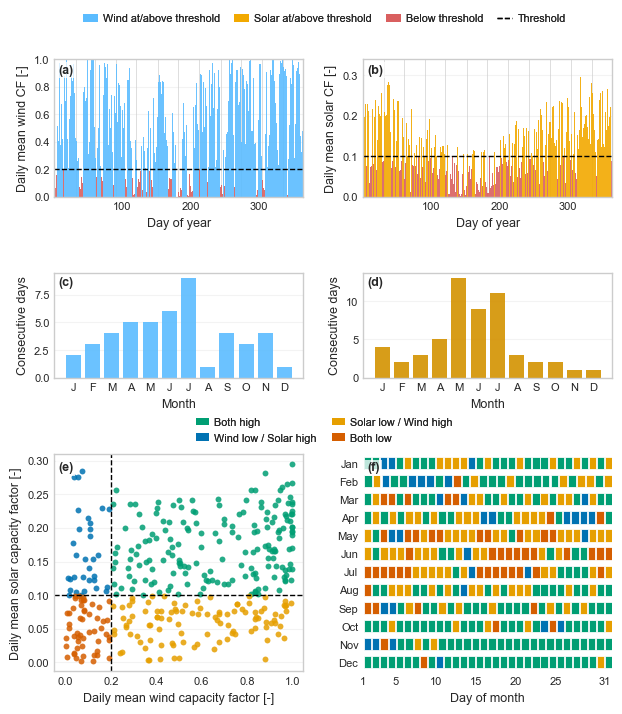

In [17]:
# Combined renewable-scarcity figure
cf_combined_scenario = active_scenario
cf_combined_years = [detailed_year]   # one representative planning year
cf_combined_export_dir = PAPER_FIGURE_DIR / "figure04_capacity_factor_combined"
cf_combined_export_dir.mkdir(parents=True, exist_ok=True)

RESOURCE_LABELS = [
    "Both high",
    "Wind low / Solar high",
    "Solar low / Wind high",
    "Both low",
]
RESOURCE_COLORS = ["#009e73", "#0072b2", "#e69f00", "#d55e00"]


def _resource_calendar_dataframe(wind_daily, solar_daily, wind_threshold, solar_threshold):
    df = pd.DataFrame({"wind": wind_daily, "solar": solar_daily}).dropna().copy()
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["category"] = np.select(
        [
            (df["wind"] >= wind_threshold) & (df["solar"] >= solar_threshold),
            (df["wind"] < wind_threshold) & (df["solar"] >= solar_threshold),
            (df["wind"] >= wind_threshold) & (df["solar"] < solar_threshold),
            (df["wind"] < wind_threshold) & (df["solar"] < solar_threshold),
        ],
        [0, 1, 2, 3],
        default=np.nan,
    )
    return df


def _add_month_separators_embedded(ax, daily_index):
    month_starts = pd.Series(index=daily_index, data=1).resample("MS").first().index
    month_start_days = month_starts.dayofyear.values
    for day in month_start_days:
        ax.axvline(day, color="#bcbcbc", linewidth=0.7, alpha=0.5, zorder=0)
    return ax


def _month_bar_axis(ax, series, color, ylabel, panel):
    month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
    month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    x = np.arange(len(month_labels))
    vals = series.reindex(month_order).fillna(0.0).values

    ax.bar(x, vals, color=color, alpha=0.90, width=0.78)
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=7)
    finish_axis(ax, xlabel="Month", ylabel=ylabel)
    ax.grid(False)
    ax.yaxis.grid(True, alpha=0.22)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    panel_label(ax, panel)


def _draw_resource_calendar_blocks(ax, calendar_df, panel):
    """
    Draw daily resource-category blocks month by month.

    Each month row spans the same total width, but daily blocks are wider
    in shorter months, so February/April/June/etc. align with 31-day months.
    """
    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    # Use the actual year to handle leap years correctly.
    plot_year = int(calendar_df.index[0].year)

    max_days_axis = 31.0

    ax.set_xlim(0, max_days_axis)
    ax.set_ylim(-0.5, 11.5)
    ax.invert_yaxis()

    for month_idx in range(12):
        month_num = month_idx + 1
        n_days = monthrange(plot_year, month_num)[1]

        # Daily blocks are stretched so each month row spans 31 axis units.
        cell_width = max_days_axis / n_days
        block_width = cell_width * 0.88
        x_pad = (cell_width - block_width) / 2

        month_df = calendar_df[calendar_df["month"] == month_num]

        for _, row in month_df.iterrows():
            day = int(row["day"])
            cat = int(row["category"])

            x0 = (day - 1) * cell_width + x_pad

            rect = Rectangle(
                (x0, month_idx - 0.34),
                block_width,
                0.68,
                facecolor=RESOURCE_COLORS[cat],
                edgecolor="white",
                linewidth=0.55,
            )
            ax.add_patch(rect)

    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(month_labels, fontsize=8)

    # These are approximate day-of-month reference labels on a 31-day axis.
    ax.set_xticks([0, 4, 9, 14, 19, 24, 30])
    ax.set_xticklabels([1, 5, 10, 15, 20, 25, 31], fontsize=7)

    finish_axis(ax, xlabel="Day of month", ylabel=None)
    ax.grid(False)
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    panel_label(ax, panel)


def plot_combined_cf_figure(scenario_code, year, save_figure=True, show_figure=True):
    result = scenario_results[scenario_code]["results"][year]
    wind_cf_local = result["wind_cf"]
    solar_cf_local = result["solar_cf"]

    wind_series_local = _prepare_cf_series(wind_cf_local)
    solar_series_local = _prepare_cf_series(solar_cf_local)
    wind_daily_local = _daily_mean_series(wind_series_local)
    solar_daily_local = _daily_mean_series(solar_series_local)

    wind_streak_local = _monthly_max_consecutive_low_days(wind_daily_local, LOW_WIND_THRESHOLD)
    solar_streak_local = _monthly_max_consecutive_low_days(solar_daily_local, LOW_SOLAR_THRESHOLD)

    scatter_df = pd.DataFrame({"wind": wind_daily_local, "solar": solar_daily_local}).dropna()
    calendar_df = _resource_calendar_dataframe(
        wind_daily_local,
        solar_daily_local,
        LOW_WIND_THRESHOLD,
        LOW_SOLAR_THRESHOLD,
    )

    # Slightly tighter figure, but still enough room for shared legends
    fig = plt.figure(figsize=(7.2, 8.5))
    gs = fig.add_gridspec(
        3, 2,
        height_ratios=[1.00, 0.76, 1.58],
        hspace=0.50,
        wspace=0.24,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])
    ax_e = fig.add_subplot(gs[2, 0])
    ax_f = fig.add_subplot(gs[2, 1])

    # Colors for threshold panels
    wind_high_color = TECH_COLORS.get("wind", "#5bbcff")
    solar_high_color = "#f2a900"
    low_color = "#d95f5f"

    # (a) Daily wind CF
    day_w = wind_daily_local.index.dayofyear
    colors_w = np.where(
        wind_daily_local.values < LOW_WIND_THRESHOLD,
        low_color,
        wind_high_color,
    )
    ax_a.bar(day_w, wind_daily_local.values, color=colors_w, width=1.0, alpha=0.90)
    ax_a.axhline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax_a.set_xlim(1, int(day_w.max()))
    ax_a.set_ylim(0, 1.0)
    finish_axis(ax_a, xlabel="Day of year", ylabel="Daily mean wind CF [-]")
    ax_a.grid(False)
    ax_a.yaxis.grid(True, alpha=0.22)
    ax_a.xaxis.grid(False)
    _add_month_separators_embedded(ax_a, wind_daily_local.index)
    panel_label(ax_a, "(a)")

    # (b) Daily solar CF
    day_s = solar_daily_local.index.dayofyear
    colors_s = np.where(
        solar_daily_local.values < LOW_SOLAR_THRESHOLD,
        low_color,
        solar_high_color,
    )
    ax_b.bar(day_s, solar_daily_local.values, color=colors_s, width=1.0, alpha=0.90)
    ax_b.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax_b.set_xlim(1, int(day_s.max()))
    ax_b.set_ylim(0, max(0.32, float(solar_daily_local.max()) * 1.15))
    finish_axis(ax_b, xlabel="Day of year", ylabel="Daily mean solar CF [-]")
    ax_b.grid(False)
    ax_b.yaxis.grid(True, alpha=0.22)
    ax_b.xaxis.grid(False)
    _add_month_separators_embedded(ax_b, solar_daily_local.index)
    panel_label(ax_b, "(b)")

    # (c) Longest low-wind streak per month
    _month_bar_axis(
        ax_c,
        wind_streak_local,
        wind_high_color,
        "Consecutive days",
        "(c)",
    )

    # (d) Longest low-solar streak per month
    _month_bar_axis(
        ax_d,
        solar_streak_local,
        "#d39200",
        "Consecutive days",
        "(d)",
    )

    # (e) Scatter of daily wind vs solar CF
    conditions = [
        (scatter_df["wind"] >= LOW_WIND_THRESHOLD) & (scatter_df["solar"] >= LOW_SOLAR_THRESHOLD),
        (scatter_df["wind"] < LOW_WIND_THRESHOLD) & (scatter_df["solar"] >= LOW_SOLAR_THRESHOLD),
        (scatter_df["wind"] >= LOW_WIND_THRESHOLD) & (scatter_df["solar"] < LOW_SOLAR_THRESHOLD),
        (scatter_df["wind"] < LOW_WIND_THRESHOLD) & (scatter_df["solar"] < LOW_SOLAR_THRESHOLD),
    ]

    for mask, lab, col in zip(conditions, RESOURCE_LABELS, RESOURCE_COLORS):
        ax_e.scatter(
            scatter_df.loc[mask, "wind"],
            scatter_df.loc[mask, "solar"],
            s=18,
            alpha=0.85,
            color=col,
            label=lab,
            linewidths=0,
        )

    ax_e.axvline(LOW_WIND_THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax_e.axhline(LOW_SOLAR_THRESHOLD, color="black", linestyle="--", linewidth=1)
    finish_axis(
        ax_e,
        xlabel="Daily mean wind capacity factor [-]",
        ylabel="Daily mean solar capacity factor [-]",
    )
    ax_e.grid(False)
    ax_e.yaxis.grid(True, alpha=0.22)
    ax_e.xaxis.grid(False)
    panel_label(ax_e, "(e)")

    # (f) Resource category calendar
    _draw_resource_calendar_blocks(ax_f, calendar_df, "(f)")

    # Shared legend for panels (a) and (b), above first row
    threshold_legend_items = [
        Patch(facecolor=wind_high_color, label="Wind at/above threshold"),
        Patch(facecolor=solar_high_color, label="Solar at/above threshold"),
        Patch(facecolor=low_color, label="Below threshold"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1, label="Threshold"),
    ]
    leg_top = fig.legend(
        handles=threshold_legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=4,
        fontsize=7.8,
        frameon=False,
        columnspacing=1.25,
        handlelength=1.4,
        handletextpad=0.5,
    )
    fig.add_artist(leg_top)

    # Shared legend for panels (e) and (f), just above third row
    resource_legend_items = [
        Patch(facecolor=RESOURCE_COLORS[0], label="Both high"),
        Patch(facecolor=RESOURCE_COLORS[1], label="Wind low / Solar high"),
        Patch(facecolor=RESOURCE_COLORS[2], label="Solar low / Wind high"),
        Patch(facecolor=RESOURCE_COLORS[3], label="Both low"),
    ]
    leg_mid = fig.legend(
        handles=resource_legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.51),
        ncol=2,
        fontsize=7.8,
        frameon=False,
        columnspacing=1.35,
        handlelength=1.2,
        handletextpad=0.5,
    )
    fig.add_artist(leg_mid)

    if not PAPER_MODE:
        fig.suptitle(
            f"{scenario_label(scenario_code)} – renewable scarcity ({year})",
            fontsize=FONT_SIZE_LABEL + 1,
            y=0.997,
        )
        fig.subplots_adjust(top=0.92, bottom=0.07)
    else:
        fig.subplots_adjust(top=0.92, bottom=0.20)

    out_path = None
    if save_figure:
        out_path = save_paper_figure(
            fig,
            f"figure04_combined_{scenario_code}_{year}.png",
            folder=cf_combined_export_dir,
        )
        out_path = save_paper_figure(
            fig,
            f"figure04_combined_{scenario_code}_{year}.svg",
            folder=cf_combined_export_dir,
        )
        out_path = save_paper_figure(
            fig,
            f"figure04_combined_{scenario_code}_{year}.pdf",
            folder=cf_combined_export_dir,
        )

    if show_figure:
        plt.show()
    else:
        plt.close(fig)

    return out_path


for year in cf_combined_years:
    print(f"\nPlotting combined Figure 4 for {cf_combined_scenario} – {year}...")
    plot_combined_cf_figure(cf_combined_scenario, year)


In [18]:
# Longest simultaneous low-wind and low-solar event
def identify_simultaneous_low_event(
    wind_cf,
    solar_cf,
    wind_threshold=LOW_WIND_THRESHOLD,
    solar_threshold=LOW_SOLAR_THRESHOLD,
):
    wind_series = wind_cf.mean(axis=1).copy()
    solar_series = solar_cf.mean(axis=1).copy()

    wind_series.index = pd.to_datetime(wind_series.index)
    solar_series.index = pd.to_datetime(solar_series.index)

    wind_daily = wind_series.resample("D").mean()
    solar_daily = solar_series.resample("D").mean()

    low_event_mask = (wind_daily < wind_threshold) & (solar_daily < solar_threshold)
    start, end, duration_days = _longest_true_run(low_event_mask)

    event_table = pd.DataFrame({
        "wind_daily_cf": wind_daily,
        "solar_daily_cf": solar_daily,
        "simultaneous_low": low_event_mask,
    })

    if start is None:
        raise ValueError("No simultaneous low-wind and low-solar event found with the selected thresholds.")

    return {
        "start_day": start,
        "end_day": end,
        "duration_days": duration_days,
        "start_hour": pd.Timestamp(start),
        "end_hour": pd.Timestamp(end) + pd.Timedelta(hours=23),
        "event_table": event_table,
    }


critical_event = identify_simultaneous_low_event(
    wind_cf,
    solar_cf,
    wind_threshold=LOW_WIND_THRESHOLD,
    solar_threshold=LOW_SOLAR_THRESHOLD,
)

critical_event_start = critical_event["start_hour"]
critical_event_end = critical_event["end_hour"]

print("Critical simultaneous low-renewable event:")
print(f"  Start: {critical_event_start}")
print(f"  End:   {critical_event_end}")
print(f"  Duration: {critical_event['duration_days']} days")

display(
    critical_event["event_table"]
    .loc[critical_event["start_day"]:critical_event["end_day"]]
    .round(3)
)

# Export event table for traceability
critical_event_table_path = TABLE_EXPORT_DIR / f"critical_event_daily_table_{base_case_name}_{active_scenario}_{detailed_year}.csv"
critical_event["event_table"].to_csv(critical_event_table_path)
print(f"Saved daily event table to: {critical_event_table_path}")


Critical simultaneous low-renewable event:
  Start: 2050-06-28 00:00:00
  End:   2050-07-06 23:00:00
  Duration: 9 days


,wind_daily_cf,solar_daily_cf,simultaneous_low
index,,,
2050-06-28,0.077,0.097,True
2050-06-29,0.000,0.037,True
2050-06-30,0.000,0.024,True
2050-07-01,0.037,0.014,True
2050-07-02,0.075,0.010,True
2050-07-03,0.005,0.009,True
2050-07-04,0.064,0.040,True
2050-07-05,0.041,0.098,True
2050-07-06,0.050,0.022,True


Saved daily event table to: output\output_punta_arenas_2\tables\critical_event_daily_table_punta_arenas_TRANS_NOSUB_2050.csv


Saved figure: output\output_punta_arenas_2\figures\figure_critical_event_dispatch_negative_loads_2050.png


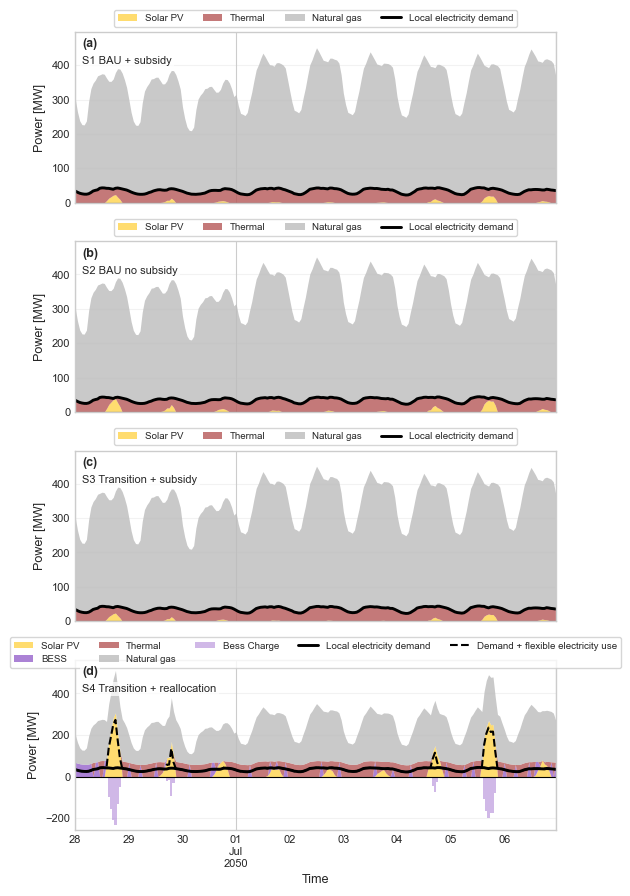

C:\Users\vse23\AppData\Local\Temp\ipykernel_19612\3917644934.py:234: UserWarning:

obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.



,scenario,paper_label,event_start,event_end,event_demand_mwh,event_supply_mwh,event_flexible_electricity_use_mwh,supply_solar_mwh,supply_bess_mwh,supply_ocgt_mwh,supply_natural_gas_mwh,supply_slack_mwh,supply_biogas_mwh,supply_pellets_mwh,negative_bess_charge_mwh
0,BAU_SUB,S1 BAU + subsidy,2050-06-28,2050-07-06 23:00:00,7506.282,75456.325,0.000,389.745,0.000,7116.537,67950.042,0.0,NaN,NaN,NaN
1,BAU_NOSUB,S2 BAU no subsidy,2050-06-28,2050-07-06 23:00:00,7506.282,75456.325,0.000,640.082,0.000,6866.200,67950.042,0.0,NaN,NaN,NaN
2,TRANS_SUB,S3 Transition + subsidy,2050-06-28,2050-07-06 23:00:00,7506.282,75456.325,0.000,389.745,0.000,7116.537,67950.042,0.0,0.0,0.0,NaN
3,TRANS_NOSUB,S4 Transition + reallocation,2050-06-28,2050-07-06 23:00:00,7506.282,56140.404,2094.902,5078.069,2352.691,9594.788,39114.856,0.0,0.0,0.0,2094.902


Saved event summary to: output\output_punta_arenas_2\tables\critical_event_dispatch_summary_negative_loads_2050.csv


In [19]:
# Dispatch during the critical low-renewable event
selected_scenarios_for_event = [s for s in SCENARIO_PLOT_ORDER if s in scenario_results]
if not selected_scenarios_for_event:
    selected_scenarios_for_event = list(scenario_results.keys())[:2]

event_year = detailed_year


def _series_like_snapshots(net, value=0.0):
    return pd.Series(float(value), index=pd.to_datetime(net.snapshots))


def _link_input_power_by_carrier(net, carrier: str) -> pd.Series:
    """Positive input power at p0 for links of a given carrier [MW]."""
    if len(net.links) == 0 or not hasattr(net.links_t, "p0"):
        return _series_like_snapshots(net)

    links = net.links.index[net.links["carrier"].astype(str) == carrier]
    if len(links) == 0:
        return _series_like_snapshots(net)

    data = net.links_t.p0.reindex(columns=links, fill_value=0.0)
    return data.clip(lower=0.0).sum(axis=1)


def _link_output_power_by_carrier(net, carrier: str) -> pd.Series:
    """Positive useful output power at p1 for links of a given carrier [MW]."""
    if len(net.links) == 0 or not hasattr(net.links_t, "p1"):
        return _series_like_snapshots(net)

    links = net.links.index[net.links["carrier"].astype(str) == carrier]
    if len(links) == 0:
        return _series_like_snapshots(net)

    data = -net.links_t.p1.reindex(columns=links, fill_value=0.0)
    return data.clip(lower=0.0).sum(axis=1)


def _electricity_balance_for_network(net):
    """
    Return positive electricity supply and negative flexible electricity
    consumption. This avoids hiding BESS charging/electrolyser operation inside
    the positive dispatch stack.
    """
    # Positive generator dispatch
    if len(net.generators) > 0:
        gen_dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0).clip(lower=0.0)
        gen_carrier = net.generators["carrier"].astype(str)
        supply = gen_dispatch.T.groupby(gen_carrier).sum().T
    else:
        supply = pd.DataFrame(index=pd.to_datetime(net.snapshots))

    # BESS: PyPSA storage_units_t.p is positive when discharging and negative when charging.
    if len(net.storage_units) > 0:
        bess_power = net.storage_units_t.p.reindex(columns=net.storage_units.index, fill_value=0.0)
        supply["bess"] = bess_power.clip(lower=0.0).sum(axis=1)
        bess_charge = (-bess_power.clip(upper=0.0)).sum(axis=1)
    else:
        bess_charge = _series_like_snapshots(net)

    # Hydrogen-to-power output is positive supply on the electricity side.
    for carrier in ["h2_fuel_cell", "h2_turbine"]:
        output = _link_output_power_by_carrier(net, carrier)
        if output.sum() > 1e-6:
            supply[carrier] = output

    # Flexible electricity uses shown below zero.
    consumption = pd.DataFrame(index=supply.index)
    if bess_charge.sum() > 1e-6:
        consumption["bess_charge"] = bess_charge

    for carrier in ["electrolyzer", "asu", "dac"]:
        input_power = _link_input_power_by_carrier(net, carrier)
        if input_power.sum() > 1e-6:
            consumption[carrier] = input_power

    preferred_supply_order = [
        "wind", "solar", "bess", "h2_fuel_cell", "h2_turbine",
        "ocgt", "gas", "natural_gas", "diesel", "slack"
    ]
    supply_cols = [c for c in preferred_supply_order if c in supply.columns]
    supply_cols += [c for c in supply.columns if c not in supply_cols]
    supply = supply[supply_cols].clip(lower=0.0)

    preferred_consumption_order = ["bess_charge", "electrolyzer", "asu", "dac"]
    cons_cols = [c for c in preferred_consumption_order if c in consumption.columns]
    cons_cols += [c for c in consumption.columns if c not in cons_cols]
    consumption = consumption[cons_cols].clip(lower=0.0)

    return supply, consumption


def _plot_event_balance(ax, supply_event, consumption_event, load_event, scenario_code, panel=None):
    # Positive electricity supply stack
    supply_cols = [c for c in supply_event.columns if supply_event[c].sum() > 1e-6]
    supply_colors = [TECH_COLORS.get(c, "#999999") for c in supply_cols]

    if supply_cols:
        supply_event[supply_cols].plot.area(
            ax=ax,
            stacked=True,
            color=supply_colors,
            alpha=0.82,
            linewidth=0,
        )

    # Negative flexible electricity use, stacked below zero.
    # Matplotlib's area plot often keeps autoscaling from zero upward, so the
    # y-limits are set explicitly after this block.
    negative_stack = pd.Series(0.0, index=consumption_event.index)
    for col in consumption_event.columns:
        s = consumption_event[col].fillna(0.0)
        if s.sum() <= 1e-6:
            continue

        color_key = "bess" if col == "bess_charge" else col
        lower = -negative_stack.values
        upper = -(negative_stack + s).values

        ax.fill_between(
            s.index,
            lower,
            upper,
            step="mid",
            color=TECH_COLORS.get(color_key, "#999999"),
            alpha=0.46,
            linewidth=0,
            label=clean_technology_label(col),
        )
        negative_stack = negative_stack + s

    # Demand lines
    local_load = load_event
    flexible_use = consumption_event.sum(axis=1) if len(consumption_event.columns) > 0 else pd.Series(0.0, index=load_event.index)
    effective_load = local_load + flexible_use

    local_load.plot(ax=ax, color="black", linewidth=2.1, label="Local electricity demand")
    if hasattr(effective_load, "sum") and flexible_use.sum() > 1e-6:
        effective_load.plot(
            ax=ax, color="black", linewidth=1.5, linestyle="--",
            label="Demand + flexible electricity use"
        )

    # Force the negative part to be visible.
    positive_max = max(
        float(supply_event.sum(axis=1).max()) if not supply_event.empty else 0.0,
        float(effective_load.max()) if hasattr(effective_load, "max") else 0.0,
        1.0,
    )
    negative_max = float(negative_stack.max()) if hasattr(negative_stack, "max") else 0.0
    ymin = -1.12 * negative_max if negative_max > 1e-6 else 0.0
    ymax = 1.10 * positive_max
    ax.set_ylim(ymin, ymax)

    ax.axhline(0, color="black", linewidth=0.8)
    finish_axis(ax, ylabel="Power [MW]")
    ax.text(
        0.015, 0.86,
        scenario_label(scenario_code),
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=FONT_SIZE_SMALL,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    )

    if panel:
        panel_label(ax, panel)

    # Clean legend labels
    handles, labels = ax.get_legend_handles_labels()
    clean_labels = [clean_technology_label(l) for l in labels]
    by_label = dict(zip(clean_labels, handles))
    ax.legend(
        by_label.values(), by_label.keys(),
        loc="upper center", bbox_to_anchor=(0.5, 1.16),
        ncol=5, fontsize=7, frameon=True
    )


missing_scenarios = [s for s in selected_scenarios_for_event if s not in scenario_results]
if missing_scenarios:
    raise ValueError(f"These scenarios are not available in scenario_results: {missing_scenarios}")


nrows = len(selected_scenarios_for_event)
fig, axes = plt.subplots(nrows, 1, figsize=(WORD_DOUBLE_COL_IN, max(2.25 * nrows, 3.5)), sharex=True)

if nrows == 1:
    axes = [axes]

event_rows = []
panel_letters = [f"({chr(97+i)})" for i in range(nrows)]

for ax, scenario_code, letter in zip(axes, selected_scenarios_for_event, panel_letters):
    package = scenario_results[scenario_code]
    result = package["results"][event_year]
    net = result["network"]

    supply, consumption = _electricity_balance_for_network(net)

    supply_event = supply.loc[critical_event_start:critical_event_end]
    consumption_event = consumption.loc[critical_event_start:critical_event_end]
    load_event = result["load"].sum(axis=1).loc[critical_event_start:critical_event_end]

    _plot_event_balance(
        ax, supply_event, consumption_event, load_event,
        scenario_code=scenario_code,
        panel=letter,
    )

    row = {
        "scenario": scenario_code,
        "paper_label": scenario_label(scenario_code),
        "event_start": critical_event_start,
        "event_end": critical_event_end,
        "event_demand_mwh": float(load_event.sum()),
        "event_supply_mwh": float(supply_event.sum().sum()),
        "event_flexible_electricity_use_mwh": float(consumption_event.sum().sum()) if not consumption_event.empty else 0.0,
    }
    for col in supply_event.columns:
        row[f"supply_{col}_mwh"] = float(supply_event[col].sum())
    for col in consumption_event.columns:
        row[f"negative_{col}_mwh"] = float(consumption_event[col].sum())
    event_rows.append(row)

axes[-1].set_xlabel("Time")

plt.tight_layout()

fig_path = save_paper_figure(fig, f"figure_critical_event_dispatch_negative_loads_{event_year}.png")
plt.show()

event_summary = pd.DataFrame(event_rows)
display(event_summary.round(3))

event_summary_path = TABLE_EXPORT_DIR / f"critical_event_dispatch_summary_negative_loads_{event_year}.csv"
event_summary.to_csv(event_summary_path, index=False)
print(f"Saved event summary to: {event_summary_path}")


Saved figure: output\output_punta_arenas_2\figures\figure_dispatch_favourable_vs_critical_2050.png


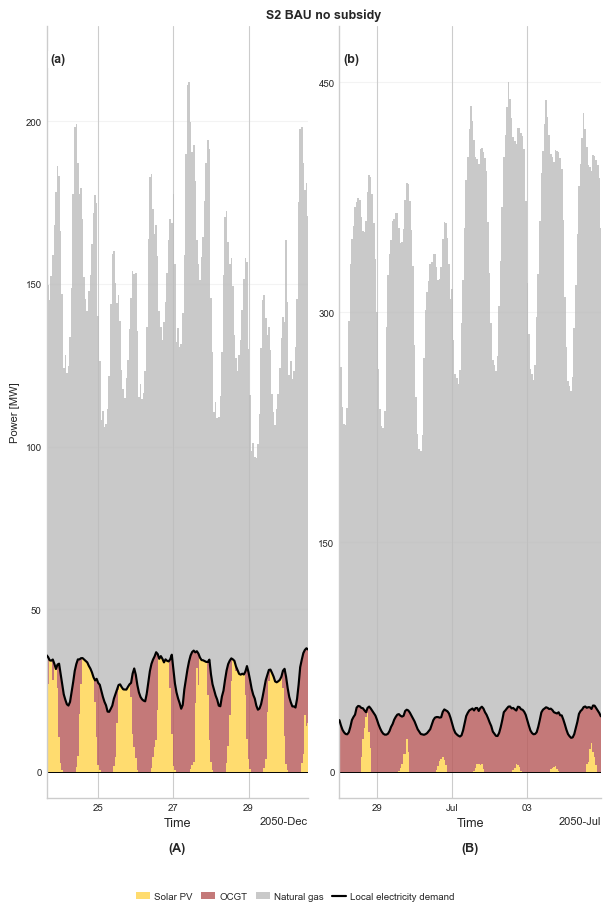

Saved figure to: output\output_punta_arenas_2\figures\figure_dispatch_favourable_vs_critical_2050.png
(A) Favourable summer period selected from BAU: 23 Dec 2050 15:00 to 30 Dec 2050 14:00.
(B) Critical-event period: 28 Jun 2050 00:00 to 04 Jul 2050 23:00.
Both columns show approximately 7 days of operation.

Power-axis limits by column and scenario group:

(A) Favourable summer period:
  BAU–RT: -8.0 to 229.2 MW

(B) Critical low-renewable generation event:
  BAU–RT: -17.0 to 486.6 MW


C:\Users\vse23\AppData\Local\Temp\ipykernel_19612\483781591.py:1787: UserWarning:

obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.



,scenario,paper_label,period,period_start,period_end,local_demand_mwh,electricity_supply_mwh,flexible_electricity_use_mwh,supply_solar_mwh,supply_bess_mwh,supply_ocgt_mwh,supply_natural_gas_mwh,supply_slack_mwh
0,BAU_NOSUB,BAU,summer_period,2050-12-23 15:00:00,2050-12-30 14:00:00,4861.064,24714.848,0.0,2224.296,0.0,2636.768,19853.784,0.0
1,BAU_NOSUB,BAU,critical_event,2050-06-28 00:00:00,2050-07-04 23:00:00,5841.265,57928.222,0.0,420.874,0.0,5420.391,52086.957,0.0


Saved dispatch comparison summary to: output\output_punta_arenas_2\tables\dispatch_favourable_vs_critical_summary_2050.csv


In [20]:
# Electricity dispatch across scenarios:
# favourable 7-day summer period versus 7-day critical-event period

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator


# ── Configuration ─────────────────────────────────────────────────────────────
dispatch_comparison_year = globals().get(
    "detailed_year",
    2050,
)

SUMMER_MONTHS = (12, 1, 2)
SUMMER_WINDOW_DAYS = 7
CRITICAL_WINDOW_DAYS = 7

# Leave as None for automatic selection.
# Example:
# SUMMER_PERIOD_START = f"{dispatch_comparison_year}-01-15 00:00"
SUMMER_PERIOD_START = None

figure_width = globals().get(
    "WORD_DOUBLE_COL_IN",
    7.2,
)

small_font = globals().get(
    "FONT_SIZE_SMALL",
    8,
)


# ── Scenario selection and labels ─────────────────────────────────────────────
def _short_scenario_label(scenario_code):
    """Return BAU, RT, RE, RH or PtX."""
    text = (
        str(scenario_code)
        .upper()
        .replace("-", "_")
    )

    parts = [
        part
        for part in text.split("_")
        if part
    ]

    if "PTX" in parts or "PTX" in text:
        return "PtX"

    for label in [
        "BAU",
        "RT",
        "RE",
        "RH",
    ]:
        if label in parts:
            return label

    return (
        str(scenario_code)
        .replace("_base", "")
        .replace("_BASE", "")
    )


def _scenario_row_label(scenario_code):
    """
    Use the paper scenario label when available;
    otherwise fall back to BAU, RT, RE, RH or PtX.
    """
    if callable(
        globals().get("scenario_label")
    ):
        return scenario_label(
            scenario_code
        )

    return _short_scenario_label(
        scenario_code
    )


scenario_order = [
    "BAU",
    "RT",
    "RE",
    "RH",
    "PtX",
]

available_scenarios = list(
    scenario_results.keys()
)

dispatch_comparison_scenarios = []

for desired_label in scenario_order:
    matching_scenarios = [
        scenario_code
        for scenario_code in available_scenarios
        if _short_scenario_label(
            scenario_code
        ) == desired_label
    ]

    if not matching_scenarios:
        continue

    # Prefer the base pathway if more than one variant exists.
    matching_scenarios.sort(
        key=lambda scenario_code: (
            not str(
                scenario_code
            ).upper().endswith(
                "_BASE"
            ),
            str(scenario_code),
        )
    )

    dispatch_comparison_scenarios.append(
        matching_scenarios[0]
    )


if not dispatch_comparison_scenarios:
    raise ValueError(
        "No BAU, RT, RE, RH or PtX scenarios were found."
    )


def _scale_group_label(scenario_code):
    """
    BAU and RT share a scale.

    RE, RH and PtX use independent scales so that their
    operational detail is not compressed by another scenario.
    """
    label = _short_scenario_label(
        scenario_code
    )

    if label in {
        "BAU",
        "RT",
    }:
        return "BAU–RT"

    return label


# ── General helpers ───────────────────────────────────────────────────────────
def _naive_datetime_index(values):
    index = pd.DatetimeIndex(
        pd.to_datetime(values)
    )

    if index.tz is not None:
        index = index.tz_localize(None)

    return index


def _naive_timestamp(value):
    timestamp = pd.Timestamp(
        value
    )

    if timestamp.tz is not None:
        timestamp = timestamp.tz_localize(
            None
        )

    return timestamp


def _normalise_timeseries_index(values):
    output = values.copy()

    output.index = _naive_datetime_index(
        output.index
    )

    return output.sort_index()


def _total_local_load(result):
    load = result["load"]

    if isinstance(
        load,
        pd.Series,
    ):
        return load.copy()

    return load.sum(
        axis=1
    )


def _format_period(start, end):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    if (
        start.year == end.year
        and start.month == end.month
    ):
        return (
            f"{start.day}–{end.day} "
            f"{start:%b %Y}"
        )

    if start.year == end.year:
        return (
            f"{start.day} {start:%b}–"
            f"{end.day} {end:%b %Y}"
        )

    return (
        f"{start.day} {start:%b %Y}–"
        f"{end.day} {end:%b %Y}"
    )


def _snapshot_hours(index):
    index = pd.DatetimeIndex(
        index
    )

    if len(index) == 0:
        return pd.Series(
            dtype=float,
            index=index,
        )

    timestamp_series = pd.Series(
        index,
        index=index,
    )

    durations = (
        timestamp_series.shift(-1)
        - timestamp_series
    )

    typical_duration = (
        durations
        .dropna()
        .median()
    )

    if pd.isna(
        typical_duration
    ):
        typical_duration = pd.Timedelta(
            hours=1
        )

    durations.iloc[-1] = (
        typical_duration
    )

    return (
        durations
        .dt.total_seconds()
        .div(3600.0)
    )


# ── Renewable potential for summer-period selection ──────────────────────────
def _renewable_potential_and_load(
    scenario_code,
    model_year,
):
    """
    Return available wind + solar generation potential
    and local electricity load [MW].

    Potential is installed capacity multiplied by p_max_pu,
    rather than realised dispatch.
    """
    result = (
        scenario_results[scenario_code]
        ["results"][model_year]
    )

    network = result["network"]

    generator_carriers = (
        network.generators["carrier"]
        .astype(str)
    )

    renewable_generators = (
        network.generators.index[
            generator_carriers.str.contains(
                r"wind|solar|pv",
                case=False,
                regex=True,
            )
        ]
    )

    if len(
        renewable_generators
    ) == 0:
        return None, None

    p_nom_fallback = pd.to_numeric(
        network.generators.get(
            "p_nom",
            pd.Series(
                0.0,
                index=network.generators.index,
            ),
        ),
        errors="coerce",
    ).fillna(0.0)

    p_nom = pd.to_numeric(
        network.generators.get(
            "p_nom_opt",
            pd.Series(
                np.nan,
                index=network.generators.index,
            ),
        ),
        errors="coerce",
    ).fillna(
        p_nom_fallback
    )

    p_nom = (
        p_nom
        .reindex(
            renewable_generators
        )
        .fillna(0.0)
    )

    static_p_max_pu = pd.to_numeric(
        network.generators.get(
            "p_max_pu",
            pd.Series(
                1.0,
                index=network.generators.index,
            ),
        ),
        errors="coerce",
    ).fillna(1.0)

    dynamic_p_max_pu = getattr(
        network.generators_t,
        "p_max_pu",
        pd.DataFrame(
            index=network.snapshots
        ),
    )

    p_max_pu = (
        dynamic_p_max_pu
        .reindex(
            index=network.snapshots,
            columns=renewable_generators,
        )
        .copy()
    )

    for generator in renewable_generators:
        p_max_pu[generator] = (
            pd.to_numeric(
                p_max_pu[generator],
                errors="coerce",
            )
            .fillna(
                float(
                    static_p_max_pu.get(
                        generator,
                        1.0,
                    )
                )
            )
        )

    renewable_potential = (
        p_max_pu
        .multiply(
            p_nom,
            axis=1,
        )
        .sum(axis=1)
    )

    renewable_potential.index = (
        _naive_datetime_index(
            renewable_potential.index
        )
    )

    local_load = _total_local_load(
        result
    )

    local_load.index = (
        _naive_datetime_index(
            local_load.index
        )
    )

    local_load = (
        local_load
        .reindex(
            renewable_potential.index
        )
        .fillna(0.0)
    )

    return (
        renewable_potential.sort_index(),
        local_load.sort_index(),
    )


# Prefer RE for selecting the favourable weather period.
summer_reference_rank = {
    "RE": 0,
    "RH": 1,
    "PtX": 2,
    "RT": 3,
    "BAU": 4,
}

summer_reference_preferences = sorted(
    dispatch_comparison_scenarios,
    key=lambda scenario_code: (
        summer_reference_rank.get(
            _short_scenario_label(
                scenario_code
            ),
            99,
        )
    ),
)

summer_reference_scenario = None
reference_renewable_potential = None
reference_local_load = None

for candidate in summer_reference_preferences:
    if (
        dispatch_comparison_year
        not in scenario_results[
            candidate
        ]["results"]
    ):
        continue

    candidate_potential, candidate_load = (
        _renewable_potential_and_load(
            candidate,
            dispatch_comparison_year,
        )
    )

    if (
        candidate_potential is not None
        and candidate_potential.max() > 1e-6
    ):
        summer_reference_scenario = candidate
        reference_renewable_potential = (
            candidate_potential
        )
        reference_local_load = candidate_load

        break


if summer_reference_scenario is None:
    raise ValueError(
        "No scenario with wind or solar capacity was found "
        "to identify the favourable summer period."
    )


# ── Determine snapshot interval ───────────────────────────────────────────────
reference_index = (
    reference_renewable_potential.index
)

if len(reference_index) < 2:
    raise ValueError(
        "Not enough snapshots to select comparison periods."
    )

snapshot_interval = (
    reference_index
    .to_series()
    .diff()
    .dropna()
    .median()
)

if (
    pd.isna(snapshot_interval)
    or snapshot_interval <= pd.Timedelta(0)
):
    raise ValueError(
        "Could not determine the snapshot interval."
    )


# ── Select the favourable 7-day summer period ────────────────────────────────
summer_window_steps = int(
    round(
        pd.Timedelta(
            days=SUMMER_WINDOW_DAYS
        )
        / snapshot_interval
    )
)

summer_window_steps = max(
    summer_window_steps,
    1,
)


if SUMMER_PERIOD_START is not None:
    summer_period_start = _naive_timestamp(
        SUMMER_PERIOD_START
    )

    matching_positions = np.flatnonzero(
        reference_index
        == summer_period_start
    )

    if len(matching_positions) == 0:
        raise ValueError(
            f"SUMMER_PERIOD_START={SUMMER_PERIOD_START} "
            "is not a model snapshot."
        )

    start_position = int(
        matching_positions[0]
    )

    end_position = (
        start_position
        + summer_window_steps
        - 1
    )

    if end_position >= len(
        reference_index
    ):
        raise ValueError(
            "The manually selected summer period extends "
            "beyond the available snapshots."
        )

    summer_period_end = (
        reference_index[end_position]
    )

else:
    summer_snapshot_mask = pd.Series(
        reference_index.month.isin(
            SUMMER_MONTHS
        ).astype(float),
        index=reference_index,
    )

    complete_summer_window = (
        summer_snapshot_mask
        .rolling(
            window=summer_window_steps,
            min_periods=summer_window_steps,
        )
        .sum()
        .eq(
            float(
                summer_window_steps
            )
        )
    )

    rolling_renewable_potential = (
        reference_renewable_potential
        .rolling(
            window=summer_window_steps,
            min_periods=summer_window_steps,
        )
        .sum()
    )

    rolling_local_load = (
        reference_local_load
        .rolling(
            window=summer_window_steps,
            min_periods=summer_window_steps,
        )
        .sum()
    )

    favourable_period_score = (
        rolling_renewable_potential
        .div(
            rolling_local_load.replace(
                0.0,
                np.nan,
            )
        )
        .where(
            complete_summer_window
        )
    )

    valid_scores = (
        favourable_period_score
        .dropna()
    )

    if valid_scores.empty:
        raise ValueError(
            "No complete seven-day summer period was found."
        )

    summer_period_end = (
        valid_scores.idxmax()
    )

    end_position = int(
        reference_index.get_loc(
            summer_period_end
        )
    )

    start_position = (
        end_position
        - summer_window_steps
        + 1
    )

    summer_period_start = (
        reference_index[start_position]
    )


# ── Select the first 7 days of the critical event ─────────────────────────────
critical_event_start_clean = _naive_timestamp(
    critical_event_start
)

critical_event_end_clean = _naive_timestamp(
    critical_event_end
)

critical_period_start = (
    critical_event_start_clean
)

critical_candidate_end = (
    critical_period_start
    + pd.Timedelta(
        days=CRITICAL_WINDOW_DAYS
    )
    - snapshot_interval
)

critical_period_end = min(
    critical_event_end_clean,
    critical_candidate_end,
)


# ── Period definitions: left (A), right (B) ──────────────────────────────────
period_definitions = [
    {
        "key": "summer_period",
        "column_label": "(A)",
        "description": (
            "Favourable summer period"
        ),
        "start": summer_period_start,
        "end": summer_period_end,
    },
    {
        "key": "critical_event",
        "column_label": "(B)",
        "description": (
            "Critical low-renewable generation event"
        ),
        "start": critical_period_start,
        "end": critical_period_end,
    },
]


# ── Prepare dispatch data ─────────────────────────────────────────────────────
dispatch_period_data = {}
dispatch_comparison_rows = []

for scenario_code in dispatch_comparison_scenarios:
    package = scenario_results[
        scenario_code
    ]

    if (
        dispatch_comparison_year
        not in package["results"]
    ):
        raise ValueError(
            f"{scenario_code} has no result for "
            f"{dispatch_comparison_year}."
        )

    result = package["results"][
        dispatch_comparison_year
    ]

    network = result["network"]

    supply, consumption = (
        _electricity_balance_for_network(
            network
        )
    )

    supply = (
        _normalise_timeseries_index(
            supply
        )
        .fillna(0.0)
    )

    consumption = (
        _normalise_timeseries_index(
            consumption
        )
        .fillna(0.0)
    )

    local_load = (
        _normalise_timeseries_index(
            _total_local_load(
                result
            )
        )
        .fillna(0.0)
    )

    consumption = (
        consumption
        .reindex(
            supply.index,
            fill_value=0.0,
        )
        .fillna(0.0)
    )

    local_load = (
        local_load
        .reindex(
            supply.index
        )
        .fillna(0.0)
    )

    for period in period_definitions:
        period_mask = (
            (supply.index >= period["start"])
            & (supply.index <= period["end"])
        )

        supply_period = (
            supply
            .loc[period_mask]
            .copy()
        )

        consumption_period = (
            consumption
            .loc[period_mask]
            .copy()
        )

        load_period = (
            local_load
            .loc[period_mask]
            .copy()
        )

        if supply_period.empty:
            raise ValueError(
                f"No snapshots found for {scenario_code}, "
                f"{period['description']}: "
                f"{period['start']} to {period['end']}."
            )

        dispatch_period_data[
            (
                scenario_code,
                period["key"],
            )
        ] = {
            "supply": supply_period,
            "consumption": consumption_period,
            "load": load_period,
        }

        snapshot_hours = _snapshot_hours(
            supply_period.index
        )

        supply_energy = (
            supply_period
            .mul(
                snapshot_hours,
                axis=0,
            )
        )

        consumption_energy = (
            consumption_period
            .mul(
                snapshot_hours,
                axis=0,
            )
        )

        load_energy = (
            load_period
            * snapshot_hours
        )

        summary_row = {
            "scenario": scenario_code,
            "paper_label": (
                _short_scenario_label(
                    scenario_code
                )
            ),
            "period": period["key"],
            "period_start": (
                supply_period.index.min()
            ),
            "period_end": (
                supply_period.index.max()
            ),
            "local_demand_mwh": float(
                load_energy.sum()
            ),
            "electricity_supply_mwh": float(
                supply_energy.sum().sum()
            ),
            "flexible_electricity_use_mwh": float(
                consumption_energy.sum().sum()
            ),
        }

        for column in supply_energy.columns:
            summary_row[
                f"supply_{column}_mwh"
            ] = float(
                supply_energy[
                    column
                ].sum()
            )

        for column in consumption_energy.columns:
            summary_row[
                f"negative_{column}_mwh"
            ] = float(
                consumption_energy[
                    column
                ].sum()
            )

        dispatch_comparison_rows.append(
            summary_row
        )


# ── Grouped y-axis limits within each column ──────────────────────────────────
scale_group_members = {}

for scenario_code in dispatch_comparison_scenarios:
    group_label = _scale_group_label(
        scenario_code
    )

    scale_group_members.setdefault(
        group_label,
        [],
    ).append(
        scenario_code
    )


def _calculate_group_ylim(
    period_key,
    scenario_codes,
):
    positive_max = 1.0
    negative_max = 0.0

    for scenario_code in scenario_codes:
        data = dispatch_period_data[
            (
                scenario_code,
                period_key,
            )
        ]

        supply_period = (
            data["supply"]
            .clip(lower=0.0)
        )

        consumption_period = (
            data["consumption"]
            .clip(lower=0.0)
        )

        load_period = (
            data["load"]
            .clip(lower=0.0)
        )

        flexible_use = (
            consumption_period
            .sum(axis=1)
        )

        total_supply = (
            supply_period
            .sum(axis=1)
        )

        total_electricity_use = (
            load_period
            + flexible_use
        )

        positive_max = max(
            positive_max,
            float(
                total_supply.max()
            ),
            float(
                load_period.max()
            ),
            float(
                total_electricity_use.max()
            ),
        )

        negative_max = max(
            negative_max,
            float(
                flexible_use.max()
            ),
        )

    upper_limit = (
        1.08
        * positive_max
    )

    if negative_max > 1e-6:
        lower_limit = (
            -1.08
            * negative_max
        )
    else:
        lower_limit = (
            -0.035
            * upper_limit
        )

    return (
        lower_limit,
        upper_limit,
    )


period_group_y_limits = {}

for period in period_definitions:
    for (
        group_label,
        scenario_codes,
    ) in scale_group_members.items():
        period_group_y_limits[
            (
                period["key"],
                group_label,
            )
        ] = _calculate_group_ylim(
            period["key"],
            scenario_codes,
        )


# ── Plotting colours and labels ───────────────────────────────────────────────
fallback_colors = {
    "wind": "#5bbcff",
    "solar": "#ffd54f",
    "hydro": "#4fc3f7",
    "bess": "#8e6bbf",
    "h2_fuel_cell": "#2ca58d",
    "h2_turbine": "#158f75",
    "ocgt": "#7f7f7f",
    "gas": "#9e9e9e",
    "natural_gas": "#9e9e9e",
    "diesel": "#4d4d4d",
    "slack": "#d62728",
    "electrolyzer": "#00a6a6",
    "electrolyser": "#00a6a6",
    "asu": "#e67e22",
    "dac": "#c44e52",
}

plot_colors = fallback_colors.copy()

plot_colors.update(
    globals().get(
        "TECH_COLORS",
        {},
    )
)


def _dispatch_color(carrier):
    color_key = (
        "bess"
        if carrier == "bess_charge"
        else carrier
    )

    return plot_colors.get(
        color_key,
        "#999999",
    )


def _dispatch_legend_label(carrier):
    label_overrides = {
        "bess": "BESS discharge",
        "bess_charge": "BESS charge",
        "electrolyzer": "Electrolyser",
        "electrolyser": "Electrolyser",
        "asu": "ASU",
        "dac": "DAC",
        "h2_fuel_cell": (
            r"H$_2$ fuel cell"
        ),
        "h2_turbine": (
            r"H$_2$ turbine"
        ),
        "ocgt": "OCGT",
        "slack": "Slack",
    }

    if carrier in label_overrides:
        return label_overrides[
            carrier
        ]

    if callable(
        globals().get(
            "clean_technology_label"
        )
    ):
        return clean_technology_label(
            carrier
        )

    return (
        str(carrier)
        .replace("_", " ")
        .title()
    )


def _add_panel_label(
    ax,
    text,
):
    if callable(
        globals().get(
            "panel_label"
        )
    ):
        panel_label(
            ax,
            text,
        )

    else:
        ax.text(
            0.012,
            0.97,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=small_font,
            fontweight="bold",
        )


# ── Individual panel ──────────────────────────────────────────────────────────
def _plot_dispatch_panel(
    ax,
    supply_period,
    consumption_period,
    load_period,
    y_limits,
    panel_text,
    show_ylabel,
):
    active_supply_columns = [
        column
        for column in supply_period.columns
        if (
            supply_period[column]
            .clip(lower=0.0)
            .sum()
            > 1e-6
        )
    ]

    if active_supply_columns:
        ax.stackplot(
            supply_period.index,
            *[
                (
                    supply_period[column]
                    .fillna(0.0)
                    .clip(lower=0.0)
                    .to_numpy()
                )
                for column
                in active_supply_columns
            ],
            colors=[
                _dispatch_color(
                    column
                )
                for column
                in active_supply_columns
            ],
            alpha=0.82,
            linewidth=0.0,
            step="mid",
        )

    negative_stack = np.zeros(
        len(consumption_period),
        dtype=float,
    )

    for column in consumption_period.columns:
        values = (
            consumption_period[column]
            .fillna(0.0)
            .clip(lower=0.0)
            .to_numpy()
        )

        if values.sum() <= 1e-6:
            continue

        previous_stack = (
            negative_stack.copy()
        )

        negative_stack += values

        ax.fill_between(
            consumption_period.index,
            -previous_stack,
            -negative_stack,
            step="mid",
            color=_dispatch_color(
                column
            ),
            alpha=0.46,
            linewidth=0.0,
        )

    flexible_use = (
        consumption_period
        .clip(lower=0.0)
        .sum(axis=1)
    )

    total_electricity_use = (
        load_period
        + flexible_use
    )

    ax.plot(
        load_period.index,
        load_period,
        color="black",
        linewidth=1.55,
        zorder=5,
    )

    if flexible_use.sum() > 1e-6:
        ax.plot(
            total_electricity_use.index,
            total_electricity_use,
            color="black",
            linewidth=1.15,
            linestyle="--",
            zorder=5,
        )

    ax.axhline(
        0.0,
        color="black",
        linewidth=0.70,
    )

    ax.set_xlim(
        supply_period.index.min(),
        supply_period.index.max(),
    )

    ax.set_ylim(
        y_limits
    )

    ax.yaxis.set_major_locator(
        MaxNLocator(
            nbins=5,
        )
    )

    ax.margins(
        x=0.0
    )

    ax.set_ylabel(
        "Power [MW]"
        if show_ylabel
        else "",
        fontsize=small_font,
    )

    ax.grid(
        axis="y",
        alpha=0.22,
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        labelsize=small_font - 1,
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    _add_panel_label(
        ax,
        panel_text,
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()


# ── Shared legend ─────────────────────────────────────────────────────────────
def _combined_dispatch_legend():
    used_supply_carriers = set()
    used_consumption_carriers = set()
    has_flexible_use = False

    for scenario_code in dispatch_comparison_scenarios:
        for period in period_definitions:
            data = dispatch_period_data[
                (
                    scenario_code,
                    period["key"],
                )
            ]

            for column in data[
                "supply"
            ].columns:
                if (
                    data["supply"][column]
                    .clip(lower=0.0)
                    .sum()
                    > 1e-6
                ):
                    used_supply_carriers.add(
                        column
                    )

            for column in data[
                "consumption"
            ].columns:
                if (
                    data["consumption"][column]
                    .clip(lower=0.0)
                    .sum()
                    > 1e-6
                ):
                    used_consumption_carriers.add(
                        column
                    )

                    has_flexible_use = True

    preferred_supply_order = [
        "wind",
        "solar",
        "hydro",
        "bess",
        "h2_fuel_cell",
        "h2_turbine",
        "ocgt",
        "gas",
        "natural_gas",
        "diesel",
        "slack",
    ]

    ordered_supply_carriers = [
        carrier
        for carrier in preferred_supply_order
        if carrier in used_supply_carriers
    ]

    ordered_supply_carriers += sorted(
        carrier
        for carrier in used_supply_carriers
        if carrier not in ordered_supply_carriers
    )

    preferred_consumption_order = [
        "bess_charge",
        "electrolyzer",
        "electrolyser",
        "asu",
        "dac",
    ]

    ordered_consumption_carriers = [
        carrier
        for carrier in preferred_consumption_order
        if carrier in used_consumption_carriers
    ]

    ordered_consumption_carriers += sorted(
        carrier
        for carrier in used_consumption_carriers
        if carrier not in ordered_consumption_carriers
    )

    handles = []
    labels = []
    seen_labels = set()

    for carrier in ordered_supply_carriers:
        label = _dispatch_legend_label(
            carrier
        )

        if label in seen_labels:
            continue

        handles.append(
            Patch(
                facecolor=_dispatch_color(
                    carrier
                ),
                edgecolor="none",
                alpha=0.82,
            )
        )

        labels.append(label)
        seen_labels.add(label)

    for carrier in ordered_consumption_carriers:
        label = _dispatch_legend_label(
            carrier
        )

        if label in seen_labels:
            continue

        handles.append(
            Patch(
                facecolor=_dispatch_color(
                    carrier
                ),
                edgecolor="none",
                alpha=0.46,
            )
        )

        labels.append(label)
        seen_labels.add(label)

    handles.append(
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=1.55,
        )
    )

    labels.append(
        "Local electricity demand"
    )

    if has_flexible_use:
        handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=1.15,
                linestyle="--",
            )
        )

        labels.append(
            "Demand + flexible electricity use"
        )

    return handles, labels


# ── Combined figure ───────────────────────────────────────────────────────────
number_of_rows = len(
    dispatch_comparison_scenarios
)

fig, axes = plt.subplots(
    nrows=number_of_rows,
    ncols=2,
    figsize=(
        figure_width,
        9.3,
    ),
    sharex="col",
    sharey=False,
    squeeze=False,
)

subplot_letters = list(
    "abcdefghijklmnopqrst"
)

letter_index = 0
scenario_row_axes = []


for row_index, scenario_code in enumerate(
    dispatch_comparison_scenarios
):
    group_label = _scale_group_label(
        scenario_code
    )

    for column_index, period in enumerate(
        period_definitions
    ):
        axis = axes[
            row_index,
            column_index,
        ]

        data = dispatch_period_data[
            (
                scenario_code,
                period["key"],
            )
        ]

        y_limits = period_group_y_limits[
            (
                period["key"],
                group_label,
            )
        ]

        _plot_dispatch_panel(
            ax=axis,
            supply_period=data["supply"],
            consumption_period=data[
                "consumption"
            ],
            load_period=data["load"],
            y_limits=y_limits,
            panel_text=(
                f"("
                f"{subplot_letters[letter_index]}"
                f")"
            ),
            show_ylabel=(
                column_index == 0
            ),
        )

        letter_index += 1

    scenario_row_axes.append(
        (
            axes[row_index, 0],
            axes[row_index, 1],
            _scenario_row_label(
                scenario_code
            ),
        )
    )


# Hide x labels except on the bottom row.
for row_index in range(
    number_of_rows - 1
):
    for column_index in range(2):
        axes[
            row_index,
            column_index,
        ].tick_params(
            axis="x",
            labelbottom=False,
        )


# Independent date formatting for each column.
for column_index in range(2):
    date_locator = mdates.AutoDateLocator(
        minticks=3,
        maxticks=5,
    )

    axes[
        -1,
        column_index,
    ].xaxis.set_major_locator(
        date_locator
    )

    axes[
        -1,
        column_index,
    ].xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(
            date_locator
        )
    )

    axes[
        -1,
        column_index,
    ].set_xlabel(
        "Time"
    )


# ── Layout ────────────────────────────────────────────────────────────────────
fig.subplots_adjust(
    top=0.97,
    bottom=0.14,
    left=0.105,
    right=0.985,
    hspace=0.28,
    wspace=0.12,
)

fig.canvas.draw()


# Horizontal scenario labels above each row.
for (
    left_axis,
    right_axis,
    label,
) in scenario_row_axes:
    left_position = (
        left_axis.get_position()
    )

    right_position = (
        right_axis.get_position()
    )

    row_centre = (
        left_position.x0
        + right_position.x1
    ) / 2.0

    row_top = max(
        left_position.y1,
        right_position.y1,
    )

    fig.text(
        row_centre,
        row_top + 0.005,
        label,
        ha="center",
        va="bottom",
        fontsize=small_font + 1,
        fontweight="bold",
    )


# ── Column labels (A) and (B) ─────────────────────────────────────────────────
left_position = axes[-1, 0].get_position()
right_position = axes[-1, 1].get_position()

left_column_centre = (
    left_position.x0
    + left_position.x1
) / 2.0

right_column_centre = (
    right_position.x0
    + right_position.x1
) / 2.0

fig.text(
    left_column_centre,
    0.086,
    "(A)",
    ha="center",
    va="center",
    fontsize=small_font + 1,
    fontweight="bold",
)

fig.text(
    right_column_centre,
    0.086,
    "(B)",
    ha="center",
    va="center",
    fontsize=small_font + 1,
    fontweight="bold",
)


# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles, legend_labels = (
    _combined_dispatch_legend()
)

legend_ncol = min(
    5,
    max(
        1,
        len(legend_labels),
    ),
)

fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        0.02,
    ),
    ncol=legend_ncol,
    frameon=False,
    fontsize=small_font - 1,
    columnspacing=0.9,
    handlelength=1.45,
    handletextpad=0.4,
)


# ── Export figure ─────────────────────────────────────────────────────────────
figure_filename = (
    "figure_dispatch_favourable_vs_critical_"
    f"{dispatch_comparison_year}.png"
)

if callable(
    globals().get(
        "save_paper_figure"
    )
):
    dispatch_comparison_figure_path = (
        save_paper_figure(
            fig,
            figure_filename,
        )
    )

else:
    dispatch_comparison_figure_path = Path(
        figure_filename
    )

    fig.savefig(
        dispatch_comparison_figure_path,
        dpi=300,
        bbox_inches="tight",
    )

plt.show()

print(
    "Saved figure to: "
    f"{dispatch_comparison_figure_path}"
)


# ── Period and scale information ──────────────────────────────────────────────
print(
    "(A) Favourable summer period selected from "
    f"{_short_scenario_label(summer_reference_scenario)}: "
    f"{summer_period_start:%d %b %Y %H:%M} to "
    f"{summer_period_end:%d %b %Y %H:%M}."
)

print(
    "(B) Critical-event period: "
    f"{critical_period_start:%d %b %Y %H:%M} to "
    f"{critical_period_end:%d %b %Y %H:%M}."
)

print(
    f"Both columns show approximately "
    f"{SUMMER_WINDOW_DAYS} days of operation."
)

print("\nPower-axis limits by column and scenario group:")

for period in period_definitions:
    print(
        f"\n{period['column_label']} "
        f"{period['description']}:"
    )

    for group_label in scale_group_members:
        limits = period_group_y_limits[
            (
                period["key"],
                group_label,
            )
        ]

        print(
            f"  {group_label}: "
            f"{limits[0]:.1f} to "
            f"{limits[1]:.1f} MW"
        )


# ── Export comparison summary ─────────────────────────────────────────────────
dispatch_comparison_summary = pd.DataFrame(
    dispatch_comparison_rows
)

display(
    dispatch_comparison_summary.round(3)
)

table_export_dir = Path(
    globals().get(
        "TABLE_EXPORT_DIR",
        ".",
    )
)

table_export_dir.mkdir(
    parents=True,
    exist_ok=True,
)

dispatch_comparison_summary_path = (
    table_export_dir
    / (
        "dispatch_favourable_vs_critical_summary_"
        f"{dispatch_comparison_year}.csv"
    )
)

dispatch_comparison_summary.to_csv(
    dispatch_comparison_summary_path,
    index=False,
)

print(
    "Saved dispatch comparison summary to: "
    f"{dispatch_comparison_summary_path}"
)

## 8. Curtailment

Curtailment is calculated as available wind and solar generation minus dispatched generation, using optimized capacities and exported time-dependent availability.

In [21]:
# Curtailment calculation

def _get_nominal_capacity_for_curtailment(net, gen_ids):
    """
    Return optimized capacity when available, otherwise nominal capacity.
    Works for both expansion runs and fixed-capacity re-operation.
    """
    gens = net.generators.loc[gen_ids].copy()

    if "p_nom_opt" in gens.columns:
        p_nom = gens["p_nom_opt"].copy()
        p_nom = p_nom.fillna(gens["p_nom"])
    else:
        p_nom = gens["p_nom"].copy()

    return p_nom.astype(float).fillna(0.0)


def build_vre_curtailment_table(net, freq="YS"):
    """
    Build a wind and solar curtailment table.

    Curtailment is calculated as:
        available VRE = p_nom * p_max_pu
        curtailed VRE = max(available VRE - dispatched VRE, 0)

    Parameters
    ----------
    net : pypsa.Network
    freq : str
        "YS" for annual, "MS" for monthly, "D" for daily, "h" for hourly.
    """
    if len(net.generators) == 0:
        return pd.DataFrame()

    rows = []

    vre_carriers = ["wind", "solar"]

    for carrier in vre_carriers:
        gen_ids = net.generators.index[
            net.generators["carrier"].astype(str).str.lower() == carrier
        ].tolist()

        if not gen_ids:
            continue

        # Safer check: do not silently assume p_max_pu = 1 if missing.
        missing_profiles = [g for g in gen_ids if g not in net.generators_t.p_max_pu.columns]
        if missing_profiles:
            raise ValueError(
                f"Missing p_max_pu profiles for {carrier}: {missing_profiles}. "
                "Do not calculate curtailment with assumed p_max_pu = 1.0."
            )

        p_nom = _get_nominal_capacity_for_curtailment(net, gen_ids)

        available = net.generators_t.p_max_pu[gen_ids].clip(lower=0.0).multiply(p_nom, axis=1)
        dispatch = net.generators_t.p[gen_ids].fillna(0.0).clip(lower=0.0)

        curtailed = (available - dispatch).clip(lower=0.0)

        for gen_id in gen_ids:
            bus = net.generators.loc[gen_id, "bus"]

            tmp = pd.DataFrame({
                "available_mwh": available[gen_id],
                "dispatch_mwh": dispatch[gen_id],
                "curtailment_mwh": curtailed[gen_id],
            })

            if freq is not None:
                tmp = tmp.resample(freq).sum()

            for ts, r in tmp.iterrows():
                rows.append({
                    "period": ts,
                    "carrier": carrier,
                    "generator": gen_id,
                    "bus": bus,
                    "available_mwh": float(r["available_mwh"]),
                    "dispatch_mwh": float(r["dispatch_mwh"]),
                    "curtailment_mwh": float(r["curtailment_mwh"]),
                })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out["curtailment_share_available_pct"] = np.where(
        out["available_mwh"] > 0,
        100 * out["curtailment_mwh"] / out["available_mwh"],
        np.nan,
    )

    return out


In [22]:
# Curtailment summary tables
curtailment_selection = "all"   # "all", one scenario code, or a list


def _resolve_selection(selection):
    if selection == "all":
        return list(scenario_results.keys())
    if isinstance(selection, str):
        return [selection]
    return list(selection)


curtailment_annual_tables = []
curtailment_monthly_tables = []

for scenario_code in _resolve_selection(curtailment_selection):
    package = scenario_results[scenario_code]
    paper_id = package["metadata"].get("paper_id", "")
    label = scenario_label(scenario_code, paper_id=paper_id)

    for year in years:
        net = package["results"][year]["network"]

        annual_df = build_vre_curtailment_table(net, freq="YS")
        if not annual_df.empty:
            annual_df = annual_df.copy()
            annual_df["scenario"] = scenario_code
            annual_df["paper_id"] = paper_id
            annual_df["scenario_label"] = label
            annual_df["year"] = year
            curtailment_annual_tables.append(annual_df)

        monthly_df = build_vre_curtailment_table(net, freq="MS")
        if not monthly_df.empty:
            monthly_df = monthly_df.copy()
            monthly_df["scenario"] = scenario_code
            monthly_df["paper_id"] = paper_id
            monthly_df["scenario_label"] = label
            monthly_df["year"] = year
            monthly_df["month_num"] = monthly_df["period"].dt.month
            monthly_df["month"] = monthly_df["period"].dt.strftime("%b")
            curtailment_monthly_tables.append(monthly_df)

curtailment_annual_all = pd.concat(curtailment_annual_tables, ignore_index=True) if curtailment_annual_tables else pd.DataFrame()
curtailment_monthly_all = pd.concat(curtailment_monthly_tables, ignore_index=True) if curtailment_monthly_tables else pd.DataFrame()

if not curtailment_annual_all.empty:
    curtailment_annual_summary = (
        curtailment_annual_all
        .groupby(["scenario", "paper_id", "scenario_label", "year", "carrier"], as_index=False)
        [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
        .sum()
    )
    curtailment_annual_summary["curtailment_share_available_pct"] = np.where(
        curtailment_annual_summary["available_mwh"] > 0,
        100 * curtailment_annual_summary["curtailment_mwh"] / curtailment_annual_summary["available_mwh"],
        np.nan,
    )

    curtailment_annual_total = (
        curtailment_annual_summary
        .groupby(["scenario", "paper_id", "scenario_label", "year"], as_index=False)
        [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
        .sum()
    )
    curtailment_annual_total["curtailment_share_available_pct"] = np.where(
        curtailment_annual_total["available_mwh"] > 0,
        100 * curtailment_annual_total["curtailment_mwh"] / curtailment_annual_total["available_mwh"],
        np.nan,
    )
else:
    curtailment_annual_summary = pd.DataFrame()
    curtailment_annual_total = pd.DataFrame()

if not curtailment_monthly_all.empty:
    curtailment_monthly_summary = (
        curtailment_monthly_all
        .groupby(["scenario", "paper_id", "scenario_label", "year", "month_num", "month", "carrier"], as_index=False)
        [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
        .sum()
    )
    curtailment_monthly_summary["curtailment_share_available_pct"] = np.where(
        curtailment_monthly_summary["available_mwh"] > 0,
        100 * curtailment_monthly_summary["curtailment_mwh"] / curtailment_monthly_summary["available_mwh"],
        np.nan,
    )
else:
    curtailment_monthly_summary = pd.DataFrame()

print("Curtailment annual summary rows:", len(curtailment_annual_summary))
print("Curtailment monthly summary rows:", len(curtailment_monthly_summary))
if not curtailment_annual_total.empty:
    display(curtailment_annual_total.head())


Curtailment annual summary rows: 4
Curtailment monthly summary rows: 48


,scenario,paper_id,scenario_label,year,available_mwh,dispatch_mwh,curtailment_mwh,curtailment_share_available_pct
0,BAU_NOSUB,S2,S2 BAU no subsidy,2050,82042.715852,72664.240154,9378.475698,11.431211
1,BAU_SUB,S1,S1 BAU + subsidy,2050,49955.729390,49583.620373,372.109017,0.744878
2,TRANS_NOSUB,S4,S4 Transition + reallocation,2050,650883.397519,600267.633922,50615.763598,7.776472
3,TRANS_SUB,S3,S3 Transition + subsidy,2050,49955.729390,49583.620373,372.109017,0.744878


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


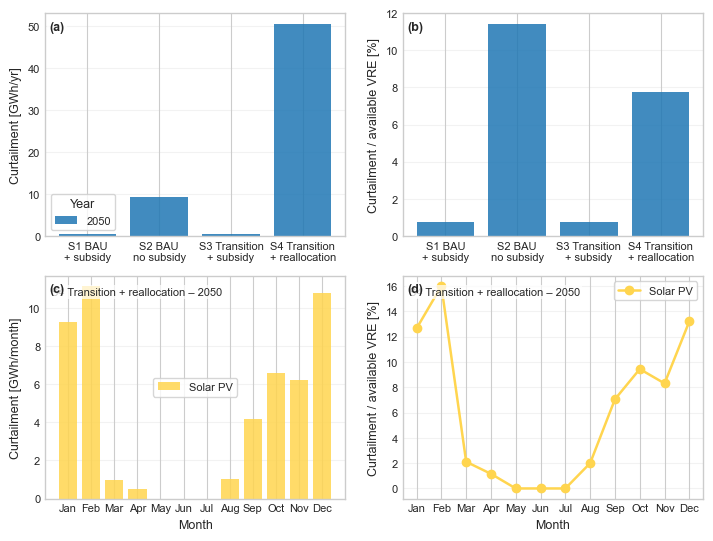

In [23]:
# Curtailment figures
curtailment_focus_scenario = active_scenario
curtailment_focus_year = detailed_year

if curtailment_annual_total.empty:
    raise ValueError("No curtailment summary available. Run the previous cell first.")

# Ordered labels for the annual plots
scenario_order = [s for s in SCENARIO_PLOT_ORDER if s in curtailment_annual_total["scenario"].unique()]
plot_df = curtailment_annual_total.copy()
plot_df["scenario"] = pd.Categorical(plot_df["scenario"], categories=scenario_order, ordered=True)
plot_df = plot_df.sort_values(["scenario", "year"]).copy()
plot_df["x_label"] = [scenario_axis_label(s) for s in plot_df["scenario"]]

unique_scenarios = plot_df[["scenario", "paper_id", "x_label"]].drop_duplicates().sort_values("scenario")
scenario_codes = unique_scenarios["scenario"].tolist()
xlabels = [scenario_axis_label(s) for s in unique_scenarios["scenario"].tolist()]
unique_years = sorted(plot_df["year"].unique())
x = np.arange(len(scenario_codes))
bar_width = 0.8 / max(len(unique_years), 1)

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_2COL_LARGE)

# (a) Total annual curtailment [GWh/yr]
ax = axes[0, 0]
for i, year in enumerate(unique_years):
    tmp = plot_df[plot_df["year"] == year].set_index("scenario").reindex(scenario_codes)
    values = tmp["curtailment_mwh"].fillna(0).values / 1e3
    ax.bar(x + (i - (len(unique_years)-1)/2) * bar_width, values, width=bar_width, label=str(year), alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=0, ha="center")
finish_axis(ax, ylabel="Curtailment [GWh/yr]")
ax.legend(title="Year", ncol=2, frameon=True)
panel_label(ax, "(a)")

# (b) Curtailment share of available VRE [%]
ax = axes[0, 1]
for i, year in enumerate(unique_years):
    tmp = plot_df[plot_df["year"] == year].set_index("scenario").reindex(scenario_codes)
    values = tmp["curtailment_share_available_pct"].fillna(0).values
    ax.bar(x + (i - (len(unique_years)-1)/2) * bar_width, values, width=bar_width, label=str(year), alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=0, ha="center")
finish_axis(ax, ylabel="Curtailment / available VRE [%]")
panel_label(ax, "(b)")

# Monthly deep-dive for a selected scenario/year
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_focus = curtailment_monthly_summary[
    (curtailment_monthly_summary["scenario"] == curtailment_focus_scenario) &
    (curtailment_monthly_summary["year"] == curtailment_focus_year)
].copy()
monthly_focus["month"] = pd.Categorical(monthly_focus["month"], categories=month_order, ordered=True)
monthly_focus = monthly_focus.sort_values(["month", "carrier"])

# (c) Monthly curtailment [GWh/month]
ax = axes[1, 0]
if not monthly_focus.empty:
    pivot_gwh = monthly_focus.pivot_table(index="month", columns="carrier", values="curtailment_mwh", aggfunc="sum").fillna(0) / 1e3
    bottom = np.zeros(len(pivot_gwh))
    for carrier in [c for c in ["wind", "solar"] if c in pivot_gwh.columns]:
        vals = pivot_gwh[carrier].values
        ax.bar(pivot_gwh.index.astype(str), vals, bottom=bottom, color=TECH_COLORS.get(carrier, "#999999"), alpha=0.85, label=clean_technology_label(carrier))
        bottom += vals
    ax.legend(frameon=True)
finish_axis(ax, xlabel="Month", ylabel="Curtailment [GWh/month]")
ax.tick_params(axis="x", rotation=0)
ax.text(0.02, 0.95, f"{scenario_label(curtailment_focus_scenario)} – {curtailment_focus_year}", transform=ax.transAxes, ha="left", va="top", fontsize=FONT_SIZE_SMALL, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.2))
panel_label(ax, "(c)")

# (d) Monthly curtailment share [%]
ax = axes[1, 1]
if not monthly_focus.empty:
    pivot_pct = monthly_focus.pivot_table(index="month", columns="carrier", values="curtailment_share_available_pct", aggfunc="sum").fillna(0)
    for carrier in [c for c in ["wind", "solar"] if c in pivot_pct.columns]:
        ax.plot(pivot_pct.index.astype(str), pivot_pct[carrier].values, marker="o", linewidth=1.8, label=clean_technology_label(carrier), color=TECH_COLORS.get(carrier, "#999999"))
    ax.legend(frameon=True)
finish_axis(ax, xlabel="Month", ylabel="Curtailment / available VRE [%]")
ax.tick_params(axis="x", rotation=0)
ax.text(0.02, 0.95, f"{scenario_label(curtailment_focus_scenario)} – {curtailment_focus_year}", transform=ax.transAxes, ha="left", va="top", fontsize=FONT_SIZE_SMALL, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.2))
panel_label(ax, "(d)")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 9. Hydrogen and UHS operation

This section reports hydrogen conversion, storage inventories, installed capacities, and annual operation for the active scenario and detailed year.

In [24]:
if not RUN_HYDROGEN_ANALYSIS:
    print('Hydrogen/UHS analysis disabled for the residential heat/subsidy study.')
else:
    # Hydrogen and UHS operation
    analysis_year = detailed_year
    hydrogen_link_carriers = ["electrolyzer", "h2_fuel_cell", "h2_turbine", "uhs_injection", "uhs_withdrawal"]
    hydrogen_store_carriers = ["hydrogen_storage", "uhs_storage"]

    hydrogen_links = n.links[n.links["carrier"].isin(hydrogen_link_carriers)].copy()
    hydrogen_stores = n.stores[n.stores["carrier"].isin(hydrogen_store_carriers)].copy()

    if hydrogen_links.empty and hydrogen_stores.empty:
        print(
            f"No hydrogen/UHS assets in the network for {analysis_year}. "
            f"enable_hydrogen={scenario_results[active_scenario]['metadata']['enable_hydrogen']}."
        )
    else:

        def _zero_series() -> pd.Series:
            """Return a zero-valued series aligned with the network snapshots."""
            return pd.Series(0.0, index=n.snapshots)

        def _link_input_series(link_index: pd.Index) -> pd.Series:
            """Aggregate electricity input (p0) for the given link indices."""
            if len(link_index) == 0:
                return _zero_series()
            return n.links_t.p0[link_index].clip(lower=0).sum(axis=1)

        def _link_output_series(link_index: pd.Index) -> pd.Series:
            """Aggregate useful output (p0 * efficiency) for the given link indices."""
            if len(link_index) == 0:
                return _zero_series()
            efficiency = n.links.loc[link_index, 'efficiency'].fillna(1.0)
            dispatch = n.links_t.p0[link_index].clip(lower=0)
            return dispatch.multiply(efficiency, axis=1).sum(axis=1)

        electrolyzer_links = hydrogen_links.index[hydrogen_links["carrier"] == "electrolyzer"]
        fuel_cell_links = hydrogen_links.index[hydrogen_links["carrier"] == "h2_fuel_cell"]
        turbine_links = hydrogen_links.index[hydrogen_links["carrier"] == "h2_turbine"]
        uhs_injection_links = hydrogen_links.index[hydrogen_links["carrier"] == "uhs_injection"]
        uhs_withdrawal_links = hydrogen_links.index[hydrogen_links["carrier"] == "uhs_withdrawal"]

        electrolyzer_power = _link_input_series(electrolyzer_links)
        hydrogen_production = _link_output_series(electrolyzer_links)
        fuel_cell_power = _link_output_series(fuel_cell_links)
        turbine_power = _link_output_series(turbine_links)
        hydrogen_to_power = fuel_cell_power + turbine_power
        hydrogen_reconversion_input = _link_input_series(fuel_cell_links) + _link_input_series(turbine_links)

        uhs_injection_power = _link_input_series(uhs_injection_links)
        uhs_withdrawal_power = _link_output_series(uhs_withdrawal_links)

        tank_stores = hydrogen_stores.index[hydrogen_stores["carrier"] == "hydrogen_storage"]
        uhs_stores = hydrogen_stores.index[hydrogen_stores["carrier"] == "uhs_storage"]

        tank_inventory = _zero_series() if len(tank_stores) == 0 else n.stores_t.e[tank_stores].sum(axis=1)
        uhs_inventory = _zero_series() if len(uhs_stores) == 0 else n.stores_t.e[uhs_stores].sum(axis=1)
        hydrogen_inventory = tank_inventory + uhs_inventory

        tank_inventory_ton = tank_inventory / H2_LHV_MWH_PER_TON
        uhs_inventory_ton = uhs_inventory / H2_LHV_MWH_PER_TON
        hydrogen_inventory_ton = hydrogen_inventory / H2_LHV_MWH_PER_TON

        fig, axes = plt.subplots(4, 1, figsize=(WORD_DOUBLE_COL_IN, 8.5), sharex=True)

        axes[0].fill_between(
            electrolyzer_power.index, 0, electrolyzer_power,
            color=TECH_COLORS.get("electrolyzer", '#00897b'), alpha=0.65,
            label="Electrolyser electricity input", step="mid"
        )
        axes[0].plot(
            hydrogen_production.index, hydrogen_production,
            color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), linewidth=1.8,
            label='Hydrogen production',
        )
        axes[0].fill_between(
            uhs_injection_power.index, 0, uhs_injection_power,
            color=TECH_COLORS.get("uhs_injection", '#1e88e5'), alpha=0.35,
            label='UHS injection (H2 -> UHS)', step="mid"
        )
        axes[0].set_title(f'Hydrogen/UHS operation {analysis_year}: production and UHS injection', fontsize=12, pad=15)
        axes[0].set_ylabel("Power [MW]", fontsize=11)
        axes[0].legend(loc="best", fontsize=9)
        axes[0].grid(True, alpha=0.3)

        axes[1].fill_between(
            fuel_cell_power.index, 0, fuel_cell_power,
            color=TECH_COLORS.get("h2_fuel_cell", '#ff8f00'), alpha=0.65,
            label='Fuel cell electricity output', step="mid"
        )
        axes[1].fill_between(
            turbine_power.index, fuel_cell_power, hydrogen_to_power,
            color=TECH_COLORS.get("h2_turbine", '#6d4c41'), alpha=0.65,
            label='H2 turbine electricity output', step="mid"
        )
        axes[1].plot(
            hydrogen_reconversion_input.index, hydrogen_reconversion_input,
            color="black", linewidth=1.5, linestyle="--",
            label='Hydrogen input to reconversion'
        )
        axes[1].plot(
            uhs_withdrawal_power.index, uhs_withdrawal_power,
            color=TECH_COLORS.get("uhs_withdrawal", '#3949ab'), linewidth=1.7,
            label='UHS withdrawal (UHS -> H2)'
        )
        axes[1].set_title(f'Hydrogen/UHS operation {analysis_year}: power reconversion and UHS withdrawal', fontsize=12, pad=15)
        axes[1].set_ylabel("Power [MW]", fontsize=11)
        axes[1].legend(loc="best", fontsize=9)
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(
            tank_inventory.index, tank_inventory,
            color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), linewidth=2,
            label='Tank inventory'
        )
        axes[2].plot(
            uhs_inventory.index, uhs_inventory,
            color=TECH_COLORS.get("uhs_storage", '#8e24aa'), linewidth=2,
            label='UHS inventory'
        )
        axes[2].plot(
            hydrogen_inventory.index, hydrogen_inventory,
            color="black", linewidth=1.4, linestyle="--",
            label='Total H2 inventory'
        )
        axes[2].fill_between(
            tank_inventory.index, 0, tank_inventory,
            color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), alpha=0.2
        )
        axes[2].fill_between(
            uhs_inventory.index, 0, uhs_inventory,
            color=TECH_COLORS.get("uhs_storage", '#8e24aa'), alpha=0.15
        )
        axes[2].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory', fontsize=12, pad=15)
        axes[2].set_ylabel("Stored energy [MWh]", fontsize=11)
        axes[2].legend(loc="best", fontsize=9)
        axes[2].grid(True, alpha=0.3)

        axes[3].plot(
            tank_inventory_ton.index, tank_inventory_ton,
            color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), linewidth=2,
            label='Tank inventory'
        )
        axes[3].plot(
            uhs_inventory_ton.index, uhs_inventory_ton,
            color=TECH_COLORS.get("uhs_storage", '#8e24aa'), linewidth=2,
            label='UHS inventory'
        )
        axes[3].plot(
            hydrogen_inventory_ton.index, hydrogen_inventory_ton,
            color="black", linewidth=1.4, linestyle="--",
            label='Total H2 inventory'
        )
        axes[3].fill_between(
            tank_inventory_ton.index, 0, tank_inventory_ton,
            color=TECH_COLORS.get("hydrogen_storage", '#26a69a'), alpha=0.2
        )
        axes[3].fill_between(
            uhs_inventory_ton.index, 0, uhs_inventory_ton,
            color=TECH_COLORS.get("uhs_storage", '#8e24aa'), alpha=0.15
        )
        axes[3].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory (LHV = {H2_LHV_MWH_PER_TON} MWh/t)', fontsize=12, pad=15)
        axes[3].set_ylabel("Stored hydrogen [t]", fontsize=11)
        axes[3].set_xlabel("Time", fontsize=11)
        axes[3].legend(loc="best", fontsize=9)
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        link_capacity_column = "p_nom_opt" if "p_nom_opt" in hydrogen_links.columns else "p_nom"
        link_caps = hydrogen_links[["carrier", "bus0", "bus1", "efficiency"]].copy()
        link_caps["capacity_mw"] = hydrogen_links[link_capacity_column]

        store_caps = pd.DataFrame()
        if not hydrogen_stores.empty:
            store_capacity_column = "e_nom_opt" if "e_nom_opt" in hydrogen_stores.columns else "e_nom"
            store_caps = hydrogen_stores[["carrier", "bus", "standing_loss"]].copy()
            store_caps["energy_capacity_mwh"] = hydrogen_stores[store_capacity_column]

        operation_summary = pd.Series({
            "electrolyser_input_mwh": electrolyzer_power.sum(),
            "hydrogen_production_mwh": hydrogen_production.sum(),
            "uhs_injection_mwh": uhs_injection_power.sum(),
            "uhs_withdrawal_mwh": uhs_withdrawal_power.sum(),
            "hydrogen_reconversion_input_mwh": hydrogen_reconversion_input.sum(),
            "fuel_cell_output_mwh": fuel_cell_power.sum(),
            "h2_turbine_output_mwh": turbine_power.sum(),
            "peak_tank_inventory_mwh": tank_inventory.max(),
            "peak_uhs_inventory_mwh": uhs_inventory.max(),
            "peak_total_h2_inventory_mwh": hydrogen_inventory.max(),
            "peak_tank_inventory_ton": tank_inventory_ton.max(),
            "peak_uhs_inventory_ton": uhs_inventory_ton.max(),
            "peak_total_h2_inventory_ton": hydrogen_inventory_ton.max(),
        }, name="value").to_frame()

        display(link_caps.sort_values(["carrier", "capacity_mw"], ascending=[True, False]))
        if not store_caps.empty:
            display(store_caps.sort_values(["carrier", "energy_capacity_mwh"], ascending=[True, False]))
        display(operation_summary.round(3))


Hydrogen/UHS analysis disabled for the residential heat/subsidy study.


In [25]:
if not RUN_HYDROGEN_ANALYSIS:
    print('Hydrogen/UHS analysis disabled for the residential heat/subsidy study.')
else:
    # Multiscale BESS and hydrogen/UHS operation panel
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch


    # ── Configuration ─────────────────────────────────────────────────────────────
    operation_year = detailed_year

    BESS_SCENARIO = "RE_base"
    H2_SCENARIO = "RH_base"

    # Use both as "RH_base" to analyse BESS and H2 within the same system.
    n_bess = scenario_results[BESS_SCENARIO]["results"][operation_year]["network"]
    n_h2 = scenario_results[H2_SCENARIO]["results"][operation_year]["network"]

    event_start = pd.Timestamp(critical_event_start)
    event_end = pd.Timestamp(critical_event_end)

    if event_start.tz is not None:
        event_start = event_start.tz_localize(None)

    if event_end.tz is not None:
        event_end = event_end.tz_localize(None)

    tech_colors = globals().get("TECH_COLORS", {})
    small_font = globals().get("FONT_SIZE_SMALL", 8)
    figure_width = globals().get("WORD_DOUBLE_COL_IN", 7.2)

    colors = {
        "BESS discharge": tech_colors.get("bess", "#8e5cc7"),
        "BESS charge": tech_colors.get("bess", "#8e5cc7"),
        "BESS SOC": "#4a2373",
        "H2 production": tech_colors.get("electrolyzer", "#00897b"),
        "Tank withdrawal": tech_colors.get("hydrogen_storage", "#26a69a"),
        "UHS withdrawal": tech_colors.get("uhs_withdrawal", "#3949ab"),
        "H2-to-power input": tech_colors.get("h2_fuel_cell", "#ff8f00"),
        "Tank charging": "#80cbc4",
        "UHS injection": tech_colors.get("uhs_injection", "#64b5f6"),
        "Tank inventory": tech_colors.get("hydrogen_storage", "#00897b"),
        "UHS inventory": tech_colors.get("uhs_storage", "#8e24aa"),
    }


    # ── Extraction helpers ────────────────────────────────────────────────────────
    def _normalise(values):
        out = values.copy()
        out.index = pd.DatetimeIndex(
            pd.to_datetime(out.index)
        )

        if out.index.tz is not None:
            out.index = out.index.tz_localize(None)

        return out.sort_index()


    def _zero(net):
        return _normalise(
            pd.Series(
                0.0,
                index=net.snapshots,
            )
        )


    def _link_flow(
        net,
        carriers,
        port,
    ):
        """
        Return positive link input at p0 or useful output at p1 [MW].
        """
        links = net.links.index[
            net.links["carrier"]
            .astype(str)
            .isin(carriers)
        ]

        if len(links) == 0:
            return _zero(net)

        values = getattr(
            net.links_t,
            port,
        ).reindex(
            index=net.snapshots,
            columns=links,
            fill_value=0.0,
        )

        # PyPSA p1 is negative when energy leaves the link.
        if port == "p1":
            values = -values

        return _normalise(
            values.clip(lower=0.0).sum(axis=1)
        )


    def _effective_capacity(
        table,
        index,
        optimised_column,
        fixed_column,
    ):
        fixed = pd.to_numeric(
            table.loc[index, fixed_column],
            errors="coerce",
        ).fillna(0.0)

        if optimised_column not in table.columns:
            return fixed

        optimised = pd.to_numeric(
            table.loc[index, optimised_column],
            errors="coerce",
        )

        return optimised.fillna(fixed)


    def _store_data(
        net,
        carrier,
    ):
        """
        Return discharge, charging, inventory percentage, and capacity.

        Store p > 0: discharge.
        Store p < 0: charging.
        """
        stores = net.stores.index[
            net.stores["carrier"].astype(str) == carrier
        ]

        if len(stores) == 0:
            zero = _zero(net)

            return (
                zero,
                zero.copy(),
                zero * np.nan,
                0.0,
            )

        power = net.stores_t.p.reindex(
            index=net.snapshots,
            columns=stores,
            fill_value=0.0,
        )

        inventory = (
            net.stores_t.e
            .reindex(
                index=net.snapshots,
                columns=stores,
                fill_value=0.0,
            )
            .sum(axis=1)
        )

        energy_capacity = _effective_capacity(
            net.stores,
            stores,
            "e_nom_opt",
            "e_nom",
        ).sum()

        discharge = (
            power
            .clip(lower=0.0)
            .sum(axis=1)
        )

        charging = -(
            power
            .clip(upper=0.0)
            .sum(axis=1)
        )

        if energy_capacity > 0.0:
            inventory_pct = (
                100.0
                * inventory
                / energy_capacity
            )
        else:
            inventory_pct = inventory * np.nan

        return (
            _normalise(discharge),
            _normalise(charging),
            _normalise(inventory_pct),
            float(energy_capacity),
        )


    # ── BESS operation ────────────────────────────────────────────────────────────
    bess_carrier = (
        n_bess.storage_units["carrier"]
        .astype(str)
        .str.lower()
    )

    bess_units = n_bess.storage_units.index[
        bess_carrier.str.contains(
            r"bess|battery",
            regex=True,
        )
    ]

    # Compatibility with older networks using a generic carrier.
    if len(bess_units) == 0:
        bess_units = n_bess.storage_units.index

    if len(bess_units) == 0:
        raise ValueError(
            f"No BESS StorageUnits found in "
            f"{BESS_SCENARIO}, {operation_year}."
        )

    bess_power_by_unit = (
        n_bess.storage_units_t.p
        .reindex(
            index=n_bess.snapshots,
            columns=bess_units,
            fill_value=0.0,
        )
    )

    bess_soc_mwh = (
        n_bess.storage_units_t.state_of_charge
        .reindex(
            index=n_bess.snapshots,
            columns=bess_units,
            fill_value=0.0,
        )
        .sum(axis=1)
    )

    bess_p_nom = _effective_capacity(
        n_bess.storage_units,
        bess_units,
        "p_nom_opt",
        "p_nom",
    )

    bess_max_hours = pd.to_numeric(
        n_bess.storage_units.loc[
            bess_units,
            "max_hours",
        ],
        errors="coerce",
    ).fillna(0.0)

    bess_energy_mwh = float(
        (
            bess_p_nom
            * bess_max_hours
        ).sum()
    )

    if bess_energy_mwh <= 0.0:
        raise ValueError(
            f"{BESS_SCENARIO} has no installed BESS energy capacity "
            f"in {operation_year}."
        )

    # Separate charging and discharging before aggregation.
    bess_flow = _normalise(
        pd.DataFrame(
            {
                "BESS discharge": (
                    bess_power_by_unit
                    .clip(lower=0.0)
                    .sum(axis=1)
                ),
                "BESS charge": (
                    bess_power_by_unit
                    .clip(upper=0.0)
                    .sum(axis=1)
                ),
            }
        )
    )

    bess_soc = _normalise(
        100.0
        * bess_soc_mwh
        / bess_energy_mwh
    )


    # ── Hydrogen/UHS operation ────────────────────────────────────────────────────
    (
        tank_withdrawal,
        tank_charging,
        tank_inventory,
        tank_capacity_mwh,
    ) = _store_data(
        n_h2,
        "hydrogen_storage",
    )

    (
        _,
        _,
        uhs_inventory,
        uhs_capacity_mwh,
    ) = _store_data(
        n_h2,
        "uhs_storage",
    )

    # All flows are expressed on the H2-energy side:
    # sources positive; storage/reconversion uses negative.
    h2_flow = _normalise(
        pd.DataFrame(
            {
                "H2 production": _link_flow(
                    n_h2,
                    [
                        "electrolyzer",
                        "electrolyser",
                    ],
                    "p1",
                ),
                "Tank withdrawal": tank_withdrawal,
                "UHS withdrawal": _link_flow(
                    n_h2,
                    ["uhs_withdrawal"],
                    "p1",
                ),
                "H2-to-power input": -(
                    _link_flow(
                        n_h2,
                        ["h2_fuel_cell"],
                        "p0",
                    )
                    + _link_flow(
                        n_h2,
                        ["h2_turbine"],
                        "p0",
                    )
                ),
                "Tank charging": -tank_charging,
                "UHS injection": -_link_flow(
                    n_h2,
                    ["uhs_injection"],
                    "p0",
                ),
            }
        ).fillna(0.0)
    )

    h2_inventory = _normalise(
        pd.DataFrame(
            {
                "Tank inventory": tank_inventory,
                "UHS inventory": uhs_inventory,
            }
        )
    )

    if h2_flow.abs().sum().sum() <= 1e-6:
        raise ValueError(
            f"{H2_SCENARIO} has no H2/UHS operation in "
            f"{operation_year}. Select another scenario or verify "
            "that hydrogen capacity was actually built."
        )


    # ── Mean daily BESS profile ───────────────────────────────────────────────────
    bess_daily = bess_flow.copy()
    bess_daily["SOC"] = bess_soc
    bess_daily["hour"] = (
        bess_daily.index.hour
        + bess_daily.index.minute / 60.0
    )

    bess_mean = (
        bess_daily
        .groupby("hour")
        .mean()
    )

    bess_soc_q25 = (
        bess_daily
        .groupby("hour")["SOC"]
        .quantile(0.25)
    )

    bess_soc_q75 = (
        bess_daily
        .groupby("hour")["SOC"]
        .quantile(0.75)
    )


    # ── Monthly hydrogen flows ────────────────────────────────────────────────────
    snapshot_duration = (
        h2_flow.index.to_series().shift(-1)
        - h2_flow.index.to_series()
    )

    typical_duration = (
        snapshot_duration
        .dropna()
        .median()
    )

    if pd.isna(typical_duration):
        typical_duration = pd.Timedelta(hours=1)

    snapshot_duration.iloc[-1] = typical_duration

    snapshot_hours = (
        snapshot_duration
        .dt.total_seconds()
        / 3600.0
    )

    h2_monthly = (
        h2_flow
        .mul(
            snapshot_hours,
            axis=0,
        )
        .groupby(
            h2_flow.index.month
        )
        .sum()
        .reindex(
            range(1, 13),
            fill_value=0.0,
        )
        / 1e3
    )

    h2_inventory_monthly = (
        h2_inventory
        .groupby(
            h2_inventory.index.month
        )
        .last()
        .reindex(range(1, 13))
        .ffill()
    )


    # ── Critical-event data ───────────────────────────────────────────────────────
    bess_event_mask = (
        (bess_flow.index >= event_start)
        & (bess_flow.index <= event_end)
    )

    h2_event_mask = (
        (h2_flow.index >= event_start)
        & (h2_flow.index <= event_end)
    )

    bess_event = bess_flow.loc[
        bess_event_mask
    ]

    bess_soc_event = bess_soc.loc[
        bess_event_mask
    ]

    h2_event = h2_flow.loc[
        h2_event_mask
    ]

    h2_inventory_event = h2_inventory.loc[
        h2_event_mask
    ]

    if bess_event.empty or h2_event.empty:
        raise ValueError(
            "The critical-event dates do not overlap "
            "the selected networks."
        )


    # ── Plot helpers ──────────────────────────────────────────────────────────────
    def _stack_signed(
        ax,
        frame,
        bars=False,
    ):
        """
        Stack positive and negative flows independently.

        Positive: production, discharge, withdrawal.
        Negative: charging, injection, reconversion input.
        """
        x = (
            np.arange(1, 13)
            if bars
            else frame.index
        )

        positive_bottom = np.zeros(
            len(frame)
        )

        negative_bottom = np.zeros(
            len(frame)
        )

        for column in frame.columns:
            raw = (
                frame[column]
                .fillna(0.0)
                .to_numpy()
            )

            positive = raw.sum() >= 0.0

            values = np.clip(
                raw if positive else -raw,
                0.0,
                None,
            )

            if values.sum() <= 1e-9:
                continue

            bottom = (
                positive_bottom
                if positive
                else negative_bottom
            )

            alpha = (
                0.82
                if positive
                else 0.55
            )

            if bars:
                ax.bar(
                    x,
                    values if positive else -values,
                    bottom=(
                        bottom
                        if positive
                        else -bottom
                    ),
                    width=0.76,
                    color=colors[column],
                    alpha=alpha,
                    linewidth=0.0,
                )
            else:
                ax.fill_between(
                    x,
                    (
                        bottom
                        if positive
                        else -bottom
                    ),
                    (
                        bottom + values
                        if positive
                        else -(bottom + values)
                    ),
                    step="mid",
                    color=colors[column],
                    alpha=alpha,
                    linewidth=0.0,
                )

            if positive:
                positive_bottom += values
            else:
                negative_bottom += values

        # Symmetric primary axis: zero remains at the vertical centre.
        limit = max(
            positive_bottom.max(),
            negative_bottom.max(),
            1e-6,
        )

        ax.set_ylim(
            -1.10 * limit,
            1.10 * limit,
        )


    def _format_percentage_axis(
        ax,
        ylabel,
    ):
        """
        Align 0% with 0 on the symmetric primary axis.

        The negative half is retained internally for alignment but
        negative percentage ticks are not displayed.
        """
        ax.set_ylim(
            -105.0,
            105.0,
        )

        ax.set_yticks(
            [0, 20, 40, 60, 80, 100]
        )

        ax.set_ylabel(
            ylabel,
            fontsize=small_font,
        )

        ax.grid(False)


    def _plot_inventory(
        ax,
        inventory,
        x=None,
    ):
        active = []

        for column, linestyle in [
            ("Tank inventory", "--"),
            ("UHS inventory", "-"),
        ]:
            if inventory[column].notna().sum() == 0:
                continue

            xx = (
                inventory.index
                if x is None
                else x
            )

            ax.plot(
                xx,
                inventory[column],
                color=colors[column],
                linestyle=linestyle,
                linewidth=1.35,
                marker=(
                    "o"
                    if x is not None
                    else None
                ),
                markersize=2.5,
            )

            active.append(column)

        _format_percentage_axis(
            ax,
            "Inventory [%]",
        )

        return active


    def _scenario_label(code):
        if callable(
            globals().get("scenario_label")
        ):
            return scenario_label(code)

        return code.replace(
            "_base",
            "",
        )


    def _add_panel_label(
        ax,
        text,
    ):
        if callable(
            globals().get("panel_label")
        ):
            panel_label(
                ax,
                text,
            )
        else:
            ax.text(
                0.01,
                0.98,
                text,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontweight="bold",
            )


    # ── Figure ────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            figure_width,
            7.0,
        ),
    )

    ax_a, ax_b, ax_c, ax_d = axes.ravel()


    # (a) Mean daily BESS operation
    _stack_signed(
        ax_a,
        bess_mean[
            [
                "BESS discharge",
                "BESS charge",
            ]
        ],
    )

    ax_a_soc = ax_a.twinx()

    ax_a_soc.fill_between(
        bess_mean.index,
        bess_soc_q25,
        bess_soc_q75,
        color=colors["BESS SOC"],
        alpha=0.10,
        linewidth=0.0,
    )

    ax_a_soc.plot(
        bess_mean.index,
        bess_mean["SOC"],
        color=colors["BESS SOC"],
        linewidth=1.35,
    )

    _format_percentage_axis(
        ax_a_soc,
        "SOC [%]",
    )

    ax_a.set_xlim(
        0.0,
        23.0,
    )

    ax_a.set_xticks(
        [0, 4, 8, 12, 16, 20, 23]
    )

    ax_a.set_xlabel(
        "Hour of day"
    )

    ax_a.set_ylabel(
        r"Power [MW$_e$]"
    )

    ax_a.set_title(
        (
            "Mean daily BESS operation — "
            f"{_scenario_label(BESS_SCENARIO)}"
        ),
        fontsize=small_font + 1,
    )

    _add_panel_label(
        ax_a,
        "(a)",
    )


    # (b) Monthly hydrogen/UHS operation
    _stack_signed(
        ax_b,
        h2_monthly,
        bars=True,
    )

    ax_b_inventory = ax_b.twinx()

    active_inventory = _plot_inventory(
        ax_b_inventory,
        h2_inventory_monthly,
        x=np.arange(1, 13),
    )

    ax_b.set_xticks(
        np.arange(1, 13),
        [
            "Jan", "Feb", "Mar",
            "Apr", "May", "Jun",
            "Jul", "Aug", "Sep",
            "Oct", "Nov", "Dec",
        ],
    )

    ax_b.set_xlim(
        0.45,
        12.55,
    )

    ax_b.set_xlabel(
        "Month"
    )

    ax_b.set_ylabel(
        r"H$_2$ flow [GWh$_{H2}$/month]"
    )

    ax_b.set_title(
        (
            "Monthly hydrogen/UHS operation — "
            f"{_scenario_label(H2_SCENARIO)}"
        ),
        fontsize=small_font + 1,
    )

    _add_panel_label(
        ax_b,
        "(b)",
    )


    # (c) BESS during the critical event
    _stack_signed(
        ax_c,
        bess_event,
    )

    ax_c_soc = ax_c.twinx()

    ax_c_soc.plot(
        bess_soc_event.index,
        bess_soc_event,
        color=colors["BESS SOC"],
        linewidth=1.35,
    )

    _format_percentage_axis(
        ax_c_soc,
        "SOC [%]",
    )

    ax_c.set_xlabel(
        "Time"
    )

    ax_c.set_ylabel(
        r"Power [MW$_e$]"
    )

    ax_c.set_title(
        (
            "BESS during critical event — "
            f"{event_start:%d %b}–{event_end:%d %b %Y}"
        ),
        fontsize=small_font + 1,
    )

    _add_panel_label(
        ax_c,
        "(c)",
    )


    # (d) Hydrogen/UHS during the same critical event
    _stack_signed(
        ax_d,
        h2_event,
    )

    ax_d_inventory = ax_d.twinx()

    _plot_inventory(
        ax_d_inventory,
        h2_inventory_event,
    )

    ax_d.set_xlabel(
        "Time"
    )

    ax_d.set_ylabel(
        r"H$_2$ flow [MW$_{H2}$]"
    )

    ax_d.set_title(
        (
            "Hydrogen/UHS during the same event — "
            f"{_scenario_label(H2_SCENARIO)}"
        ),
        fontsize=small_font + 1,
    )

    _add_panel_label(
        ax_d,
        "(d)",
    )


    # Shared axis formatting
    for ax in axes.ravel():
        ax.axhline(
            0.0,
            color="black",
            linewidth=0.7,
        )

        ax.grid(
            axis="y",
            alpha=0.22,
        )

        ax.set_axisbelow(True)

        ax.tick_params(
            labelsize=small_font - 1,
        )

        ax.margins(
            x=0.0,
        )


    # Critical-event date formatting
    for ax in [
        ax_c,
        ax_d,
    ]:
        locator = mdates.AutoDateLocator(
            minticks=4,
            maxticks=7,
        )

        ax.xaxis.set_major_locator(
            locator
        )

        ax.xaxis.set_major_formatter(
            mdates.ConciseDateFormatter(
                locator
            )
        )


    # ── Shared legend ─────────────────────────────────────────────────────────────
    legend_handles = [
        Patch(
            facecolor=colors["BESS discharge"],
            edgecolor="none",
            alpha=0.82,
            label="BESS discharge (+)",
        ),
        Patch(
            facecolor=colors["BESS charge"],
            edgecolor="none",
            alpha=0.38,
            label="BESS charge (−)",
        ),
        Line2D(
            [0],
            [0],
            color=colors["BESS SOC"],
            linewidth=1.35,
            label="BESS SOC",
        ),
    ]

    for column in h2_flow.columns:
        if h2_flow[column].abs().sum() <= 1e-6:
            continue

        positive = h2_flow[column].sum() >= 0.0

        legend_handles.append(
            Patch(
                facecolor=colors[column],
                edgecolor="none",
                alpha=(
                    0.82
                    if positive
                    else 0.55
                ),
                label=(
                    f"{column} "
                    f"({'+' if positive else '−'})"
                ),
            )
        )

    for column, linestyle in [
        ("Tank inventory", "--"),
        ("UHS inventory", "-"),
    ]:
        if column not in active_inventory:
            continue

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=colors[column],
                linestyle=linestyle,
                linewidth=1.35,
                label=column,
            )
        )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            0.012,
        ),
        ncol=4,
        frameon=False,
        fontsize=small_font - 1,
        columnspacing=1.0,
        handlelength=1.5,
        handletextpad=0.4,
    )

    fig.subplots_adjust(
        top=0.94,
        bottom=0.19,
        left=0.10,
        right=0.90,
        hspace=0.42,
        wspace=0.48,
    )


    # ── Export ────────────────────────────────────────────────────────────────────
    if callable(
        globals().get("save_paper_figure")
    ):
        figure_path = save_paper_figure(
            fig,
            (
                "figure_storage_operation_multiscale_"
                f"{operation_year}.png"
            ),
        )

        print(
            f"Saved figure to: {figure_path}"
        )

    plt.show()

    print(
        f"BESS: {bess_p_nom.sum():.2f} MW / "
        f"{bess_energy_mwh:.2f} MWh"
    )

    print(
        f"H2 storage: tank={tank_capacity_mwh / 1e3:.3f} GWh_H2; "
        f"UHS={uhs_capacity_mwh / 1e3:.3f} GWh_H2"
    )

Hydrogen/UHS analysis disabled for the residential heat/subsidy study.


In [26]:
if not RUN_HYDROGEN_ANALYSIS:
    print('Hydrogen/UHS analysis disabled for the residential heat/subsidy study.')
else:
    # BESS operation across scenarios:
    # 10-day favourable summer period versus critical-event period

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch


    # ── Configuration ─────────────────────────────────────────────────────────────
    operation_year = detailed_year

    BESS_SCENARIOS = [
        "RT_base",
        "RE_base",
        "RH_base",
        "PTX_base",
    ]

    # Ten-day favourable summer period.
    summer_plot_start = pd.Timestamp(f"{operation_year}-12-17 00:00")
    summer_plot_end = pd.Timestamp(f"{operation_year}-12-26 23:00")

    # The identified event spans approximately nine days.
    # Add one preceding day to show how each BESS enters the event.
    event_plot_start = pd.Timestamp(critical_event_start) - pd.Timedelta(days=1)
    event_plot_end = pd.Timestamp(critical_event_end)

    for timestamp_name in [
        "summer_plot_start",
        "summer_plot_end",
        "event_plot_start",
        "event_plot_end",
    ]:
        timestamp = locals()[timestamp_name]

        if timestamp.tz is not None:
            locals()[timestamp_name] = timestamp.tz_localize(None)

    tech_colors = globals().get("TECH_COLORS", {})
    small_font = globals().get("FONT_SIZE_SMALL", 8)
    figure_width = globals().get("WORD_DOUBLE_COL_IN", 7.2)

    bess_color = tech_colors.get("bess", "#9c6ade")
    soc_color = "#4a2373"


    # ── Helpers ───────────────────────────────────────────────────────────────────
    def _normalise_index(series_or_frame):
        output = series_or_frame.copy()
        output.index = pd.DatetimeIndex(pd.to_datetime(output.index))

        if output.index.tz is not None:
            output.index = output.index.tz_localize(None)

        return output.sort_index()


    def _effective_capacity(
        table,
        index,
        optimised_column,
        fixed_column,
    ):
        fixed = pd.to_numeric(
            table.loc[index, fixed_column],
            errors="coerce",
        ).fillna(0.0)

        if optimised_column not in table.columns:
            return fixed

        optimised = pd.to_numeric(
            table.loc[index, optimised_column],
            errors="coerce",
        )

        return optimised.fillna(fixed)


    def _scenario_label(code):
        if callable(globals().get("scenario_label")):
            return scenario_label(code)

        return code.replace("_base", "").replace("_", " ")


    def extract_bess_operation(network):
        carrier = (
            network.storage_units["carrier"]
            .astype(str)
            .str.lower()
        )

        units = network.storage_units.index[
            carrier.str.contains(
                r"bess|battery",
                regex=True,
            )
        ]

        # Compatibility with older networks using a generic storage carrier.
        if len(units) == 0:
            units = network.storage_units.index

        if len(units) == 0:
            raise ValueError("No BESS StorageUnits were found.")

        power_by_unit = (
            network.storage_units_t.p
            .reindex(
                index=network.snapshots,
                columns=units,
                fill_value=0.0,
            )
        )

        power = pd.DataFrame(
            {
                "BESS discharge": (
                    power_by_unit
                    .clip(lower=0.0)
                    .sum(axis=1)
                ),
                "BESS charge": (
                    power_by_unit
                    .clip(upper=0.0)
                    .sum(axis=1)
                ),
            }
        )

        soc_mwh = (
            network.storage_units_t.state_of_charge
            .reindex(
                index=network.snapshots,
                columns=units,
                fill_value=0.0,
            )
            .sum(axis=1)
        )

        p_nom = _effective_capacity(
            network.storage_units,
            units,
            "p_nom_opt",
            "p_nom",
        )

        max_hours = pd.to_numeric(
            network.storage_units.loc[units, "max_hours"],
            errors="coerce",
        ).fillna(0.0)

        energy_capacity_mwh = float(
            (p_nom * max_hours).sum()
        )

        if energy_capacity_mwh <= 0.0:
            raise ValueError(
                "Installed BESS energy capacity is zero."
            )

        soc_pct = (
            100.0
            * soc_mwh
            / energy_capacity_mwh
        )

        return (
            _normalise_index(power),
            _normalise_index(soc_pct),
            float(p_nom.sum()),
            energy_capacity_mwh,
        )


    def select_period(
        frame,
        start,
        end,
    ):
        return frame.loc[
            (frame.index >= start)
            & (frame.index <= end)
        ]


    def scenario_power_limit(
        power,
        periods,
    ):
        """
        Return one symmetric power limit for both columns of a scenario.

        Limits differ between scenarios, preventing the small RT BESS
        from being compressed by the much larger RE/RH/PtX systems.
        """
        maximum = 0.0

        for start, end in periods:
            selected = select_period(
                power,
                start,
                end,
            )

            if selected.empty:
                continue

            maximum = max(
                maximum,
                float(
                    selected["BESS discharge"].max()
                ),
                float(
                    abs(
                        selected["BESS charge"].min()
                    )
                ),
            )

        maximum = max(maximum, 1e-3)

        # Round the limit upwards to a readable value.
        raw_limit = 1.10 * maximum

        if raw_limit <= 10:
            step = 2
        elif raw_limit <= 50:
            step = 10
        elif raw_limit <= 150:
            step = 25
        else:
            step = 50

        return (
            np.ceil(raw_limit / step)
            * step
        )


    def plot_bess_period(
        ax,
        power,
        soc,
        start,
        end,
        power_limit,
        show_left_ylabel=False,
        show_right_ylabel=False,
    ):
        period_power = select_period(
            power,
            start,
            end,
        )

        period_soc = select_period(
            soc,
            start,
            end,
        )

        if period_power.empty:
            raise ValueError(
                f"No BESS data available between {start} and {end}."
            )

        ax.fill_between(
            period_power.index,
            0.0,
            period_power["BESS discharge"],
            step="mid",
            color=bess_color,
            alpha=0.85,
            linewidth=0.0,
        )

        ax.fill_between(
            period_power.index,
            0.0,
            period_power["BESS charge"],
            step="mid",
            color=bess_color,
            alpha=0.42,
            linewidth=0.0,
        )

        ax.axhline(
            0.0,
            color="black",
            linewidth=0.7,
        )

        ax.set_ylim(
            -power_limit,
            power_limit,
        )

        if show_left_ylabel:
            ax.set_ylabel(
                r"Power [MW$_e$]",
                fontsize=small_font,
            )
        else:
            ax.set_ylabel("")

        ax_soc = ax.twinx()

        ax_soc.plot(
            period_soc.index,
            period_soc,
            color=soc_color,
            linewidth=1.25,
        )

        ax_soc.set_ylim(
            0.0,
            100.0,
        )

        ax_soc.set_yticks(
            [0, 25, 50, 75, 100]
        )

        if show_right_ylabel:
            ax_soc.set_ylabel(
                "SOC [%]",
                fontsize=small_font,
            )
        else:
            ax_soc.set_ylabel("")
            ax_soc.tick_params(
                labelright=False,
            )

        ax.grid(
            axis="y",
            alpha=0.22,
        )

        ax.set_axisbelow(True)
        ax.margins(x=0.0)

        locator = mdates.AutoDateLocator(
            minticks=3,
            maxticks=5,
        )

        ax.xaxis.set_major_locator(locator)

        ax.xaxis.set_major_formatter(
            mdates.ConciseDateFormatter(locator)
        )

        ax.tick_params(
            labelsize=small_font - 1,
        )

        ax_soc.tick_params(
            labelsize=small_font - 1,
        )

        return ax_soc


    # ── Extract scenarios ─────────────────────────────────────────────────────────
    bess_results = {}

    for scenario in BESS_SCENARIOS:
        network = (
            scenario_results[scenario]
            ["results"]
            [operation_year]
            ["network"]
        )

        try:
            bess_results[scenario] = extract_bess_operation(
                network
            )

        except ValueError as error:
            print(
                f"{scenario}: {error}"
            )

            bess_results[scenario] = None


    # ── Figure ────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        len(BESS_SCENARIOS),
        2,
        figsize=(
            figure_width,
            7.6,
        ),
        sharex="col",
        sharey=False,
    )

    subplot_letters = list("abcdefgh")
    letter_index = 0

    scenario_row_axes = []

    for row, scenario in enumerate(BESS_SCENARIOS):
        result = bess_results[scenario]

        if result is None:
            for column in range(2):
                axes[row, column].text(
                    0.5,
                    0.5,
                    "No BESS installed",
                    transform=axes[row, column].transAxes,
                    ha="center",
                    va="center",
                    fontsize=small_font,
                )

            continue

        (
            power,
            soc,
            power_capacity,
            energy_capacity,
        ) = result

        power_limit = scenario_power_limit(
            power,
            [
                (
                    summer_plot_start,
                    summer_plot_end,
                ),
                (
                    event_plot_start,
                    event_plot_end,
                ),
            ],
        )

        plot_bess_period(
            axes[row, 0],
            power,
            soc,
            summer_plot_start,
            summer_plot_end,
            power_limit=power_limit,
            show_left_ylabel=True,
            show_right_ylabel=False,
        )

        plot_bess_period(
            axes[row, 1],
            power,
            soc,
            event_plot_start,
            event_plot_end,
            power_limit=power_limit,
            show_left_ylabel=False,
            show_right_ylabel=True,
        )

        # Installed capacity annotation.
        axes[row, 0].text(
            0.03,
            0.89,
            (
                f"{power_capacity:.0f} MW / "
                f"{energy_capacity / 1e3:.2f} GWh"
            ),
            transform=axes[row, 0].transAxes,
            ha="left",
            va="top",
            fontsize=small_font - 1,
        )

        # Individual subplot labels: (a)–(h).
        for column in range(2):
            axes[row, column].text(
                0.015,
                0.98,
                f"({subplot_letters[letter_index]})",
                transform=axes[row, column].transAxes,
                ha="left",
                va="top",
                fontsize=small_font,
                fontweight="bold",
            )

            letter_index += 1

        scenario_row_axes.append(
            (
                axes[row, 0],
                axes[row, 1],
                _scenario_label(scenario),
            )
        )


    axes[-1, 0].set_xlabel(
        "Time"
    )

    axes[-1, 1].set_xlabel(
        "Time"
    )


    # ── Layout before figure-coordinate labels ────────────────────────────────────
    fig.subplots_adjust(
        top=0.965,
        bottom=0.175,
        left=0.105,
        right=0.90,
        hspace=0.34,
        wspace=0.15,
    )

    # Draw once so subplot positions are available.
    fig.canvas.draw()


    # Horizontal scenario labels above each row.
    for left_ax, right_ax, label in scenario_row_axes:
        left_position = left_ax.get_position()
        right_position = right_ax.get_position()

        row_centre = (
            left_position.x0
            + right_position.x1
        ) / 2.0

        row_top = max(
            left_position.y1,
            right_position.y1,
        )

        fig.text(
            row_centre,
            row_top + 0.008,
            label,
            ha="center",
            va="bottom",
            fontsize=small_font + 1,
            fontweight="bold",
        )


    # ── Column labels below plots ─────────────────────────────────────────────────
    left_position = axes[-1, 0].get_position()
    right_position = axes[-1, 1].get_position()

    fig.text(
        (
            left_position.x0
            + left_position.x1
        ) / 2.0,
        0.105,
        "(A)",
        ha="center",
        va="center",
        fontsize=small_font + 1,
        fontweight="bold",
    )

    fig.text(
        (
            right_position.x0
            + right_position.x1
        ) / 2.0,
        0.105,
        "(B)",
        ha="center",
        va="center",
        fontsize=small_font + 1,
        fontweight="bold",
    )


    # ── Shared legend ─────────────────────────────────────────────────────────────
    legend_handles = [
        Patch(
            facecolor=bess_color,
            edgecolor="none",
            alpha=0.85,
            label="BESS discharge (+)",
        ),
        Patch(
            facecolor=bess_color,
            edgecolor="none",
            alpha=0.42,
            label="BESS charge (−)",
        ),
        Line2D(
            [0],
            [0],
            color=soc_color,
            linewidth=1.25,
            label="BESS SOC",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            0.045,
        ),
        ncol=3,
        frameon=False,
        fontsize=small_font,
        columnspacing=1.2,
        handlelength=1.6,
        handletextpad=0.5,
    )


    # ── Export ────────────────────────────────────────────────────────────────────
    if callable(
        globals().get("save_paper_figure")
    ):
        figure_path = save_paper_figure(
            fig,
            (
                "figure_bess_summer_and_critical_event_"
                f"{operation_year}.png"
            ),
        )

        print(
            f"Saved figure to: {figure_path}"
        )

    plt.show()


    # ── Period information ────────────────────────────────────────────────────────
    print(
        "(A) Favourable summer period: "
        f"{summer_plot_start:%d %b %Y %H:%M} to "
        f"{summer_plot_end:%d %b %Y %H:%M}"
    )

    print(
        "(B) Critical-event period: "
        f"{event_plot_start:%d %b %Y %H:%M} to "
        f"{event_plot_end:%d %b %Y %H:%M}"
    )

    print(
        "Note: panel (B) begins one day before the identified "
        "critical event to show the incoming BESS SOC."
    )

Hydrogen/UHS analysis disabled for the residential heat/subsidy study.


In [27]:
if not RUN_HYDROGEN_ANALYSIS:
    print('Hydrogen/UHS analysis disabled for the residential heat/subsidy study.')
else:
    # Hydrogen storage operation across RH and PtX:
    # monthly H2 balance versus critical-event storage operation
    # All hydrogen flows are expressed in tonnes of H2.

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch


    # ── Configuration ─────────────────────────────────────────────────────────────
    operation_year = detailed_year

    H2_SCENARIOS = [
        "RH_base",
        "PTX_base",
    ]

    # Same period used in the BESS figure:
    # one day before the identified critical event until its end.
    event_plot_start = (
        pd.Timestamp(critical_event_start)
        - pd.Timedelta(days=1)
    )

    event_plot_end = pd.Timestamp(
        critical_event_end
    )

    if event_plot_start.tz is not None:
        event_plot_start = event_plot_start.tz_localize(None)

    if event_plot_end.tz is not None:
        event_plot_end = event_plot_end.tz_localize(None)

    small_font = globals().get(
        "FONT_SIZE_SMALL",
        8,
    )

    figure_width = globals().get(
        "WORD_DOUBLE_COL_IN",
        7.2,
    )

    # Lower heating value used to convert hydrogen energy to mass.
    H2_LHV_MWH_PER_T = 33.33

    # Semantic colour families:
    # green     = H2 production
    # blue      = tank operation
    # orange    = H2 consumed for electricity generation
    # purple    = H2 consumed by PtX
    # dark grey = tank inventory
    colors = {
        "H2 production": "#009688",
        "Tank withdrawal": "#1976D2",
        "Tank charging": "#90CAF9",
        "H2 consumed for power": "#F57C00",
        "PtX H2 input": "#7E57C2",
        "Tank inventory": "#263238",
    }

    legend_labels = {
        "H2 production": r"H$_2$ production (+)",
        "Tank withdrawal": "Tank withdrawal (+)",
        "Tank charging": "Tank charging (−)",
        "H2 consumed for power": (
            r"H$_2$ consumed for power (−)"
        ),
        "PtX H2 input": (
            r"PtX H$_2$ input (−)"
        ),
        "Tank inventory": "Tank inventory",
    }


    # ── Helpers ───────────────────────────────────────────────────────────────────
    def _normalise_index(series_or_frame):
        output = series_or_frame.copy()

        output.index = pd.DatetimeIndex(
            pd.to_datetime(output.index)
        )

        if output.index.tz is not None:
            output.index = output.index.tz_localize(None)

        return output.sort_index()


    def _zero_series(network):
        return _normalise_index(
            pd.Series(
                0.0,
                index=network.snapshots,
            )
        )


    def _scenario_label(code):
        if callable(
            globals().get("scenario_label")
        ):
            return scenario_label(code)

        return (
            code.replace("_base", "")
            .replace("_", " ")
        )


    def _effective_capacity(
        table,
        index,
        optimised_column,
        fixed_column,
    ):
        fixed = pd.to_numeric(
            table.loc[index, fixed_column],
            errors="coerce",
        ).fillna(0.0)

        if optimised_column not in table.columns:
            return fixed

        optimised = pd.to_numeric(
            table.loc[index, optimised_column],
            errors="coerce",
        )

        return optimised.fillna(fixed)


    def _link_flow(
        network,
        carriers,
        port,
    ):
        """
        Aggregate selected Link flows.

        p0:
            Positive energy input to the Link.

        p1:
            Converted to positive useful output from the Link.
        """
        links = network.links.index[
            network.links["carrier"]
            .astype(str)
            .isin(carriers)
        ]

        if len(links) == 0:
            return _zero_series(network)

        values = getattr(
            network.links_t,
            port,
        ).reindex(
            index=network.snapshots,
            columns=links,
            fill_value=0.0,
        )

        # PyPSA p1 is negative when energy leaves the Link.
        if port == "p1":
            values = -values

        return _normalise_index(
            values.clip(lower=0.0).sum(axis=1)
        )


    def extract_tank_operation(network):
        """
        Extract surface H2-tank operation.

        The original time series are returned in MW_H2.

        Positive:
        - H2 production
        - tank withdrawal

        Negative:
        - tank charging
        - H2 consumed by fuel cells/turbines
        - H2 consumed by PtX synthesis
        """
        tank_stores = network.stores.index[
            network.stores["carrier"]
            .astype(str)
            .eq("hydrogen_storage")
        ]

        if len(tank_stores) == 0:
            raise ValueError(
                "No surface hydrogen-storage Store was found."
            )

        tank_power = (
            network.stores_t.p
            .reindex(
                index=network.snapshots,
                columns=tank_stores,
                fill_value=0.0,
            )
        )

        tank_inventory_mwh = (
            network.stores_t.e
            .reindex(
                index=network.snapshots,
                columns=tank_stores,
                fill_value=0.0,
            )
            .sum(axis=1)
        )

        tank_capacity_mwh = float(
            _effective_capacity(
                network.stores,
                tank_stores,
                "e_nom_opt",
                "e_nom",
            ).sum()
        )

        if tank_capacity_mwh <= 0.0:
            raise ValueError(
                "Hydrogen tank energy capacity is zero."
            )

        tank_withdrawal = (
            tank_power
            .clip(lower=0.0)
            .sum(axis=1)
        )

        tank_charging = -(
            tank_power
            .clip(upper=0.0)
            .sum(axis=1)
        )

        h2_production = _link_flow(
            network,
            [
                "electrolyzer",
                "electrolyser",
            ],
            "p1",
        )

        # Hydrogen-energy input to fuel cells/turbines,
        # not their electricity output.
        h2_consumed_for_power = (
            _link_flow(
                network,
                ["h2_fuel_cell"],
                "p0",
            )
            + _link_flow(
                network,
                ["h2_turbine"],
                "p0",
            )
        )

        ptx_h2_input = _link_flow(
            network,
            [
                "methanol_synthesis",
                "ammonia_synthesis",
                "ptx_synthesis",
            ],
            "p0",
        )

        flows_mw_h2 = _normalise_index(
            pd.DataFrame(
                {
                    "H2 production": h2_production,
                    "Tank withdrawal": tank_withdrawal,
                    "Tank charging": -tank_charging,
                    "H2 consumed for power": (
                        -h2_consumed_for_power
                    ),
                    "PtX H2 input": -ptx_h2_input,
                }
            ).fillna(0.0)
        )

        inventory_pct = _normalise_index(
            100.0
            * tank_inventory_mwh
            / tank_capacity_mwh
        )

        return (
            flows_mw_h2,
            inventory_pct,
            tank_capacity_mwh,
        )


    def _snapshot_hours(index):
        durations = (
            index.to_series().shift(-1)
            - index.to_series()
        )

        typical_duration = (
            durations.dropna().median()
        )

        if pd.isna(typical_duration):
            typical_duration = pd.Timedelta(
                hours=1
            )

        durations.iloc[-1] = typical_duration

        return (
            durations.dt.total_seconds()
            / 3600.0
        )


    def monthly_hydrogen_mass(flow_mw_h2):
        """
        Convert MW_H2 time series to tonnes of H2 per month.

        MW_H2 × hours = MWh_H2
        MWh_H2 / (MWh_H2 per tonne) = tonnes H2
        """
        hours = _snapshot_hours(
            flow_mw_h2.index
        )

        monthly_mwh_h2 = (
            flow_mw_h2
            .mul(
                hours,
                axis=0,
            )
            .groupby(flow_mw_h2.index.month)
            .sum()
            .reindex(
                range(1, 13),
                fill_value=0.0,
            )
        )

        return (
            monthly_mwh_h2
            / H2_LHV_MWH_PER_T
        )


    def hourly_hydrogen_mass_flow(flow_mw_h2):
        """
        Convert MW_H2 to tonnes of H2 per hour.
        """
        return (
            flow_mw_h2
            / H2_LHV_MWH_PER_T
        )


    def monthly_inventory(inventory):
        """
        End-of-month tank inventory.
        """
        return (
            inventory
            .groupby(inventory.index.month)
            .last()
            .reindex(range(1, 13))
            .ffill()
        )


    def _nice_symmetric_limit(
        positive_bottom,
        negative_bottom,
    ):
        maximum = max(
            float(positive_bottom.max()),
            float(negative_bottom.max()),
            1e-6,
        )

        raw_limit = 1.10 * maximum

        if raw_limit <= 2:
            step = 0.5
        elif raw_limit <= 10:
            step = 2
        elif raw_limit <= 50:
            step = 10
        elif raw_limit <= 150:
            step = 25
        elif raw_limit <= 500:
            step = 50
        elif raw_limit <= 1500:
            step = 250
        else:
            step = 500

        return (
            np.ceil(raw_limit / step)
            * step
        )


    def _stack_signed(
        ax,
        frame,
        bars=False,
    ):
        """
        Stack positive and negative flows independently.
        """
        x = (
            np.arange(1, 13)
            if bars
            else frame.index
        )

        positive_bottom = np.zeros(
            len(frame)
        )

        negative_bottom = np.zeros(
            len(frame)
        )

        active_columns = []

        for column in frame.columns:
            raw = (
                frame[column]
                .fillna(0.0)
                .to_numpy()
            )

            if np.abs(raw).sum() <= 1e-9:
                continue

            active_columns.append(column)

            positive_values = np.clip(
                raw,
                0.0,
                None,
            )

            negative_values = np.clip(
                -raw,
                0.0,
                None,
            )

            if positive_values.sum() > 1e-9:
                if bars:
                    ax.bar(
                        x,
                        positive_values,
                        bottom=positive_bottom,
                        width=0.76,
                        color=colors[column],
                        alpha=0.88,
                        linewidth=0.0,
                    )
                else:
                    ax.fill_between(
                        x,
                        positive_bottom,
                        (
                            positive_bottom
                            + positive_values
                        ),
                        step="mid",
                        color=colors[column],
                        alpha=0.88,
                        linewidth=0.0,
                    )

                positive_bottom += positive_values

            if negative_values.sum() > 1e-9:
                if bars:
                    ax.bar(
                        x,
                        -negative_values,
                        bottom=-negative_bottom,
                        width=0.76,
                        color=colors[column],
                        alpha=0.70,
                        linewidth=0.0,
                    )
                else:
                    ax.fill_between(
                        x,
                        -negative_bottom,
                        -(
                            negative_bottom
                            + negative_values
                        ),
                        step="mid",
                        color=colors[column],
                        alpha=0.70,
                        linewidth=0.0,
                    )

                negative_bottom += negative_values

        limit = _nice_symmetric_limit(
            positive_bottom,
            negative_bottom,
        )

        ax.set_ylim(
            -limit,
            limit,
        )

        return active_columns


    def _plot_inventory(
        ax,
        inventory,
        x=None,
        show_ticklabels=True,
        show_ylabel=False,
    ):
        xx = (
            inventory.index
            if x is None
            else x
        )

        ax.plot(
            xx,
            inventory,
            color=colors["Tank inventory"],
            linewidth=1.45,
            marker=(
                "o"
                if x is not None
                else None
            ),
            markersize=3.0,
            zorder=5,
        )

        ax.set_ylim(
            0.0,
            100.0,
        )

        ax.set_yticks(
            [0, 25, 50, 75, 100]
        )

        if show_ylabel:
            ax.set_ylabel(
                "Tank inventory [%]",
                fontsize=small_font,
                labelpad=6,
            )
        else:
            ax.set_ylabel("")

        if not show_ticklabels:
            ax.tick_params(
                labelright=False,
            )

        ax.tick_params(
            labelsize=small_font - 1,
        )

        ax.grid(False)


    # ── Extract scenario data ─────────────────────────────────────────────────────
    h2_results = {}

    for scenario in H2_SCENARIOS:
        network = (
            scenario_results[scenario]
            ["results"]
            [operation_year]
            ["network"]
        )

        try:
            (
                flows_mw_h2,
                inventory,
                capacity_mwh,
            ) = extract_tank_operation(
                network
            )

            monthly_flows_t = monthly_hydrogen_mass(
                flows_mw_h2
            )

            # Monthly panel:
            # show production and final H2 uses.
            # Tank charging/withdrawal is represented by
            # the variation in tank inventory.
            monthly_balance_t = monthly_flows_t[
                [
                    "H2 production",
                    "H2 consumed for power",
                    "PtX H2 input",
                ]
            ].copy()

            h2_results[scenario] = {
                "flows_mw_h2": flows_mw_h2,
                "inventory": inventory,
                "capacity_mwh": capacity_mwh,
                "capacity_t_h2": (
                    capacity_mwh
                    / H2_LHV_MWH_PER_T
                ),
                "monthly_balance_t": monthly_balance_t,
                "monthly_inventory": monthly_inventory(
                    inventory
                ),
            }

        except ValueError as error:
            print(
                f"{scenario}: {error}"
            )

            h2_results[scenario] = None


    # ── Figure ────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        len(H2_SCENARIOS),
        2,
        figsize=(
            figure_width,
            4.9,
        ),
        sharex="col",
        sharey=False,
    )

    subplot_letters = list("abcd")
    letter_index = 0

    scenario_row_axes = []
    active_legend_columns = []


    for row, scenario in enumerate(H2_SCENARIOS):
        result = h2_results[scenario]

        if result is None:
            for column in range(2):
                axes[row, column].text(
                    0.5,
                    0.5,
                    "No hydrogen storage installed",
                    transform=(
                        axes[row, column]
                        .transAxes
                    ),
                    ha="center",
                    va="center",
                    fontsize=small_font,
                )

            continue

        monthly_balance_t = result[
            "monthly_balance_t"
        ]

        monthly_inventory_pct = result[
            "monthly_inventory"
        ]

        event_mask = (
            (
                result["flows_mw_h2"].index
                >= event_plot_start
            )
            & (
                result["flows_mw_h2"].index
                <= event_plot_end
            )
        )

        event_flows_t_per_h = (
            hourly_hydrogen_mass_flow(
                result["flows_mw_h2"]
                .loc[event_mask]
            )
        )

        event_inventory = (
            result["inventory"]
            .loc[event_mask]
        )

        if event_flows_t_per_h.empty:
            raise ValueError(
                f"No H2 data available for {scenario} "
                "during the selected event period."
            )

        # ── Column A: monthly H2 balance ──────────────────────────────────────────
        active_monthly = _stack_signed(
            axes[row, 0],
            monthly_balance_t,
            bars=True,
        )

        monthly_inventory_axis = (
            axes[row, 0].twinx()
        )

        _plot_inventory(
            monthly_inventory_axis,
            monthly_inventory_pct,
            x=np.arange(1, 13),
            show_ticklabels=False,
            show_ylabel=False,
        )

        axes[row, 0].set_xticks(
            np.arange(1, 13),
            [
                "J",
                "F",
                "M",
                "A",
                "M",
                "J",
                "J",
                "A",
                "S",
                "O",
                "N",
                "D",
            ],
        )

        axes[row, 0].set_xlim(
            0.45,
            12.55,
        )

        axes[row, 0].set_ylabel(
            r"Hydrogen flow "
            r"[t$_{H_2}$/month]",
            fontsize=small_font,
            labelpad=3,
        )

        # ── Column B: critical-event storage operation ───────────────────────────
        active_event = _stack_signed(
            axes[row, 1],
            event_flows_t_per_h,
            bars=False,
        )

        event_inventory_axis = (
            axes[row, 1].twinx()
        )

        _plot_inventory(
            event_inventory_axis,
            event_inventory,
            show_ticklabels=True,
            show_ylabel=True,
        )

        axes[row, 1].set_ylabel(
            r"Hydrogen flow "
            r"[t$_{H_2}$/h]",
            fontsize=small_font,
            labelpad=3,
        )

        tick_start = (
            event_plot_start.normalize()
            + pd.Timedelta(days=2)
        )

        tick_end = event_plot_end.normalize()

        event_ticks = pd.date_range(
            tick_start,
            tick_end,
            freq="2D",
        )

        axes[row, 1].set_xticks(event_ticks)

        axes[row, 1].xaxis.set_major_formatter(
            mdates.DateFormatter("%d")
        )

        # Tank-capacity annotation in tonnes of H2.
        axes[row, 0].text(
            0.085,
            0.965,
            (
                "Tank: "
                f"{result['capacity_t_h2']:.0f} "
                r"t$_{H_2}$"
            ),
            transform=axes[row, 0].transAxes,
            ha="left",
            va="top",
            fontsize=small_font - 1,
        )

        # Individual subplot labels.
        for column in range(2):
            axes[row, column].text(
                0.015,
                0.98,
                (
                    f"("
                    f"{subplot_letters[letter_index]}"
                    f")"
                ),
                transform=(
                    axes[row, column]
                    .transAxes
                ),
                ha="left",
                va="top",
                fontsize=small_font,
                fontweight="bold",
            )

            letter_index += 1

        scenario_row_axes.append(
            (
                axes[row, 0],
                axes[row, 1],
                _scenario_label(scenario),
            )
        )

        for column in (
            active_monthly
            + active_event
        ):
            if column not in active_legend_columns:
                active_legend_columns.append(
                    column
                )


    axes[-1, 0].set_xlabel(
        "Month"
    )

    axes[-1, 1].set_xlabel(
        "Time"
    )

    # Show x-axis tick labels also on the top row.
    if len(H2_SCENARIOS) > 1:
        axes[0, 0].tick_params(labelbottom=True)
        axes[0, 1].tick_params(labelbottom=True)


    # ── Shared formatting ─────────────────────────────────────────────────────────
    for ax in axes.ravel():
        ax.axhline(
            0.0,
            color="black",
            linewidth=0.7,
        )

        ax.grid(
            axis="y",
            alpha=0.22,
        )

        ax.set_axisbelow(True)

        ax.tick_params(
            labelsize=small_font - 1,
        )

        ax.margins(
            x=0.0,
        )


    # Intermediate spacing: compact but not crowded.
    fig.subplots_adjust(
        top=0.945,
        bottom=0.205,
        left=0.11,
        right=0.865,
        hspace=0.34,
        wspace=0.34,
    )

    fig.canvas.draw()


    # ── Horizontal scenario labels ────────────────────────────────────────────────
    for left_ax, right_ax, label in scenario_row_axes:
        left_position = (
            left_ax.get_position()
        )

        right_position = (
            right_ax.get_position()
        )

        row_centre = (
            left_position.x0
            + right_position.x1
        ) / 2.0

        row_top = max(
            left_position.y1,
            right_position.y1,
        )

        fig.text(
            row_centre,
            row_top + 0.012,
            label,
            ha="center",
            va="bottom",
            fontsize=small_font + 1,
            fontweight="bold",
        )


    # ── Column labels (A) and (B) ─────────────────────────────────────────────────
    left_position = axes[-1, 0].get_position()
    right_position = axes[-1, 1].get_position()

    left_column_centre = (
        left_position.x0
        + left_position.x1
    ) / 2.0

    right_column_centre = (
        right_position.x0
        + right_position.x1
    ) / 2.0

    fig.text(
        left_column_centre,
        0.125,
        "(A)",
        ha="center",
        va="center",
        fontsize=small_font + 1,
        fontweight="bold",
    )

    fig.text(
        right_column_centre,
        0.125,
        "(B)",
        ha="center",
        va="center",
        fontsize=small_font + 1,
        fontweight="bold",
    )


    # ── Shared legend ─────────────────────────────────────────────────────────────
    legend_handles = []

    legend_order = [
        "H2 production",
        "Tank withdrawal",
        "Tank charging",
        "H2 consumed for power",
        "PtX H2 input",
    ]

    for column in legend_order:
        if column not in active_legend_columns:
            continue

        positive = column in [
            "H2 production",
            "Tank withdrawal",
        ]

        legend_handles.append(
            Patch(
                facecolor=colors[column],
                edgecolor="none",
                alpha=(
                    0.88
                    if positive
                    else 0.70
                ),
                label=legend_labels[column],
            )
        )

    legend_handles.append(
        Line2D(
            [0],
            [0],
            color=colors["Tank inventory"],
            linewidth=1.45,
            marker="o",
            markersize=3,
            label=legend_labels[
                "Tank inventory"
            ],
        )
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            0.012,
        ),
        ncol=3,
        frameon=False,
        fontsize=small_font - 1,
        columnspacing=0.9,
        handlelength=1.4,
        handletextpad=0.35,
    )


    # ── Export ────────────────────────────────────────────────────────────────────
    if callable(
        globals().get("save_paper_figure")
    ):
        figure_path = save_paper_figure(
            fig,
            (
                "figure_hydrogen_monthly_and_"
                f"critical_event_{operation_year}.png"
            ),
        )

        print(
            f"Saved figure to: {figure_path}"
        )

    plt.show()


    # ── Period information ────────────────────────────────────────────────────────
    print(
        "(A) Monthly hydrogen balance: "
        f"January–December {operation_year}."
    )

    print(
        "(B) Critical-event period: "
        f"{event_plot_start:%d %b %Y %H:%M} to "
        f"{event_plot_end:%d %b %Y %H:%M}."
    )

    print(
        "Hydrogen-energy flows were converted to mass using "
        f"an H2 LHV of {H2_LHV_MWH_PER_T:.2f} MWh/t."
    )

    print(
        "'H2 consumed for power' represents the hydrogen input "
        "to fuel cells and turbines, not their electricity output."
    )

    print(
        "Panel (B) begins one day before the identified critical "
        "event to show the incoming tank inventory."
    )

Hydrogen/UHS analysis disabled for the residential heat/subsidy study.


## 10. Weather-year robustness (optional)

Set `RUN_ROBUSTNESS=True` to re-operate the fixed RH design across available meteorological years. This section loads the exported `network.nc` for the selected design; all standard analysis above remains CSV-based.

In [28]:
RUN_ROBUSTNESS = globals().get('RUN_ROBUSTNESS', False)

def run_weather_year_robustness():
    """Re-operate a fixed optimized design across alternative weather years."""
    robustness_scenario_code = "RH_base"
    robustness_target_year = 2050
    robustness_weather_years = list(range(2016, 2026))

    robustness_cutout_base_dir = Path("data")
    robustness_cutout_prefix = "magallanes"

    solver_name_robustness = solver_name
    time_limit_robustness = time_limit
    mip_gap_robustness = mip_gap
    threads_robustness = threads
    fallback_to_highs_robustness = fallback_to_highs

    missing_cutouts = []

    for wy in robustness_weather_years:
        p = robustness_cutout_base_dir / f"{robustness_cutout_prefix}_{wy}.nc"
        if not p.exists():
            missing_cutouts.append(p)

    if missing_cutouts:
        raise FileNotFoundError(
            "Some robustness cutouts are missing. Check the folder/path before running:\n"
            + "\n".join(str(p.resolve()) for p in missing_cutouts)
        )

    if robustness_scenario_code not in scenario_results:
        raise KeyError(
            f"{robustness_scenario_code} not found in scenario_results. "
            "Run the selected robustness scenario before running this section."
        )

    base_package = scenario_results[robustness_scenario_code]
    base_result = base_package["results"][robustness_target_year]

    network_netcdf = base_result.get("network_netcdf")
    if network_netcdf is None or not Path(network_netcdf).exists():
        raise FileNotFoundError(
            "The robustness run requires the exported network.nc file. "
            "Set EXPORT_NETWORK_NETCDF=True and rerun the selected base scenario."
        )

    base_net = pypsa.Network(network_netcdf)
    base_nodes = base_result["nodes"].load()

    critical_weather_year_used = base_result.get("weather_year", critical_weather_year)

    print(
        "\nUsing fixed capacities from "
        f"scenario {robustness_scenario_code}, "
        f"model year {robustness_target_year}, "
        f"optimised with weather year {critical_weather_year_used}."
    )

    def _copy_optimized_capacities_to_nominal(net):
        """
        Convert an optimised expansion network into a fixed-capacity operation network.

        This avoids deepcopy errors caused by solver/linopy/Gurobi objects stored
        inside net.model after optimisation.
        """
        with tempfile.TemporaryDirectory() as tmpdir:
            tmp_path = Path(tmpdir) / "fixed_capacity_template.nc"
            exported_path = export_network_netcdf_safe(net, tmp_path, strict=True)
            net_fixed = pypsa.Network(exported_path)

        net = net_fixed

        # Generators
        if len(net.generators) > 0:
            if "p_nom_opt" in net.generators.columns:
                mask = net.generators["p_nom_opt"].notna()
                net.generators.loc[mask, "p_nom"] = net.generators.loc[mask, "p_nom_opt"]

            if "p_nom_extendable" in net.generators.columns:
                net.generators["p_nom_extendable"] = False

        # StorageUnits, e.g. BESS
        if len(net.storage_units) > 0:
            if "p_nom_opt" in net.storage_units.columns:
                mask = net.storage_units["p_nom_opt"].notna()
                net.storage_units.loc[mask, "p_nom"] = net.storage_units.loc[mask, "p_nom_opt"]

            if "p_nom_extendable" in net.storage_units.columns:
                net.storage_units["p_nom_extendable"] = False

        # Links, e.g. transmission, electrolysers, fuel cells, H2 turbines
        if len(net.links) > 0:
            if "p_nom_opt" in net.links.columns:
                mask = net.links["p_nom_opt"].notna()
                net.links.loc[mask, "p_nom"] = net.links.loc[mask, "p_nom_opt"]

            if "p_nom_extendable" in net.links.columns:
                net.links["p_nom_extendable"] = False

        # Stores, e.g. H2 tank / UHS
        if len(net.stores) > 0:
            if "e_nom_opt" in net.stores.columns:
                mask = net.stores["e_nom_opt"].notna()
                net.stores.loc[mask, "e_nom"] = net.stores.loc[mask, "e_nom_opt"]

            if "e_nom_extendable" in net.stores.columns:
                net.stores["e_nom_extendable"] = False

        # Remove any old optimisation model if present
        if hasattr(net, "model"):
            try:
                delattr(net, "model")
            except Exception:
                pass

        return net

    def _replace_vre_profiles_for_weather_year(net, weather_year):
        """
        Replace wind and solar p_max_pu using an existing cutout:
        data/magallanes_{weather_year}.nc

        This bypasses config.get_case_cutout to avoid creating/downloading new cutouts.
        """
        cutout_path = robustness_cutout_base_dir / f"{robustness_cutout_prefix}_{weather_year}.nc"

        if not cutout_path.exists():
            raise FileNotFoundError(
                f"Cutout not found: {cutout_path.resolve()}\n"
                "Check robustness_cutout_base_dir and robustness_cutout_prefix."
            )

        print(f"Using existing cutout: {cutout_path}")

        cutout = atlite.Cutout(str(cutout_path))

        wind_cf_hist, solar_cf_hist = config.get_vre_profiles_from_cutout(
            cutout=cutout,
            nodes_df=base_nodes,
            method=vre_profile_method,
            wind_turbine=wind_turbine,
            solar_panel=solar_panel,
            solar_orientation=solar_orientation,
        )

        wind_cf = config.map_weather_year(wind_cf_hist, target_year=robustness_target_year)
        solar_cf = config.map_weather_year(solar_cf_hist, target_year=robustness_target_year)

        # Ensure all generator columns exist in p_max_pu
        if net.generators_t.p_max_pu.empty:
            net.generators_t.p_max_pu = pd.DataFrame(
                1.0,
                index=net.snapshots,
                columns=net.generators.index,
            )
        else:
            net.generators_t.p_max_pu = net.generators_t.p_max_pu.reindex(
                index=net.snapshots,
                columns=net.generators.index,
                fill_value=1.0,
            )

        # Replace only VRE profiles
        replaced = []

        for gen_id, row in net.generators.iterrows():
            carrier = str(row.get("carrier", "")).lower()
            zone = str(row.get("bus", "")).replace("elec_", "")

            if carrier == "wind" and zone in wind_cf.columns:
                net.generators_t.p_max_pu[gen_id] = (
                    wind_cf[zone].reindex(net.snapshots).fillna(0.0)
                )
                replaced.append(gen_id)

            elif carrier == "solar" and zone in solar_cf.columns:
                net.generators_t.p_max_pu[gen_id] = (
                    solar_cf[zone].reindex(net.snapshots).fillna(0.0)
                )
                replaced.append(gen_id)

        print(f"Updated VRE profiles for {len(replaced)} generators.")

        return net, wind_cf, solar_cf

    def _build_solver_options_for_robustness(target_solver):
        opts = {}

        if target_solver == "gurobi":
            if time_limit_robustness is not None:
                opts["TimeLimit"] = float(time_limit_robustness)
            if mip_gap_robustness is not None:
                opts["MIPGap"] = float(mip_gap_robustness)
            if threads_robustness is not None:
                opts["Threads"] = int(threads_robustness)

            opts["OutputFlag"] = 0
            opts["LogToConsole"] = 0

        elif target_solver == "highs":
            if time_limit_robustness is not None:
                opts["time_limit"] = float(time_limit_robustness)
            if mip_gap_robustness is not None:
                opts["mip_rel_gap"] = float(mip_gap_robustness)
            if threads_robustness is not None:
                opts["threads"] = int(threads_robustness)

        return opts

    def _run_fixed_capacity_operation(net):
        """
        Optimise operation only, with all capacities fixed.
        """
        opts = _build_solver_options_for_robustness(solver_name_robustness)

        optimize_kwargs = {"solver_name": solver_name_robustness}
        if opts:
            optimize_kwargs["solver_options"] = opts

        extra_fun = getattr(config, "add_custom_constraints", None)

        try:
            if extra_fun is not None:
                status, condition = net.optimize(
                    extra_functionality=extra_fun,
                    **optimize_kwargs,
                )
            else:
                status, condition = net.optimize(**optimize_kwargs)

            used_solver = solver_name_robustness

        except Exception as exc:
            if fallback_to_highs_robustness and solver_name_robustness == "gurobi":
                print(f"Gurobi failed during robustness run: {exc}. Trying HiGHS.")

                fallback_kwargs = {"solver_name": "highs"}
                fallback_opts = _build_solver_options_for_robustness("highs")
                if fallback_opts:
                    fallback_kwargs["solver_options"] = fallback_opts

                if extra_fun is not None:
                    status, condition = net.optimize(
                        extra_functionality=extra_fun,
                        **fallback_kwargs,
                    )
                else:
                    status, condition = net.optimize(**fallback_kwargs)

                used_solver = "highs"
            else:
                raise

        return status, condition, used_solver

    def _generation_by_carrier(net):
        if len(net.generators) == 0:
            return pd.Series(dtype=float)

        gen = (
            net.generators_t.p
            .reindex(columns=net.generators.index, fill_value=0.0)
            .clip(lower=0.0)
        )
        carriers = net.generators["carrier"].astype(str)

        return gen.T.groupby(carriers).sum().T.sum().sort_values(ascending=False)

    def _vre_curtailment_mwh(net):
        if len(net.generators) == 0:
            return 0.0

        total_curtailment = 0.0

        for carrier in ["wind", "solar"]:
            gens = net.generators.index[
                net.generators["carrier"].astype(str).str.lower() == carrier
            ]

            for gen_id in gens:
                p_nom = float(net.generators.loc[gen_id, "p_nom"])
                available = (
                    net.generators_t.p_max_pu[gen_id]
                    .fillna(0.0)
                    .clip(lower=0.0)
                    * p_nom
                )
                actual = net.generators_t.p[gen_id].fillna(0.0).clip(lower=0.0)
                total_curtailment += float((available - actual).clip(lower=0.0).sum())

        return total_curtailment

    def _storage_metrics(net):
        bess_charge = 0.0
        bess_discharge = 0.0
        bess_energy_capacity = 0.0

        if len(net.storage_units) > 0:
            p = net.storage_units_t.p.reindex(
                columns=net.storage_units.index,
                fill_value=0.0,
            )
            bess_charge = float((-p.clip(upper=0.0)).sum().sum())
            bess_discharge = float(p.clip(lower=0.0).sum().sum())

            if "max_hours" in net.storage_units.columns:
                bess_energy_capacity = float(
                    (net.storage_units["p_nom"] * net.storage_units["max_hours"]).sum()
                )

        h2_store_energy = 0.0
        uhs_store_energy = 0.0

        if len(net.stores) > 0:
            for _, row in net.stores.iterrows():
                carrier = str(row.get("carrier", "")).lower()
                e_nom = float(row.get("e_nom", 0.0))

                if carrier == "hydrogen_storage":
                    h2_store_energy += e_nom
                elif carrier == "uhs_storage":
                    uhs_store_energy += e_nom

        return {
            "bess_charge_mwh": bess_charge,
            "bess_discharge_mwh": bess_discharge,
            "bess_energy_capacity_mwh": bess_energy_capacity,
            "h2_store_energy_mwh": h2_store_energy,
            "uhs_store_energy_mwh": uhs_store_energy,
        }

    def _h2_link_metrics(net):
        """
        Annual operation of hydrogen-related links.
        Positive p0 is input at bus0. Positive p1 is usually output at bus1
        with sign convention depending on PyPSA. We use p0 for consumption-side
        technologies and -p1 where useful for output-side energy.
        """
        out = {
            "electrolyzer_input_gwh": 0.0,
            "h2_fuel_cell_output_gwh": 0.0,
            "h2_turbine_output_gwh": 0.0,
            "uhs_injection_gwh": 0.0,
            "uhs_withdrawal_gwh": 0.0,
        }

        if len(net.links) == 0:
            return out

        p0 = net.links_t.p0.reindex(columns=net.links.index, fill_value=0.0)
        p1 = net.links_t.p1.reindex(columns=net.links.index, fill_value=0.0)

        for link_id, row in net.links.iterrows():
            carrier = str(row.get("carrier", "")).lower()

            if carrier == "electrolyzer":
                out["electrolyzer_input_gwh"] += float(p0[link_id].clip(lower=0.0).sum() / 1e3)

            elif carrier == "h2_fuel_cell":
                out["h2_fuel_cell_output_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

            elif carrier == "h2_turbine":
                out["h2_turbine_output_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

            elif carrier == "uhs_injection":
                out["uhs_injection_gwh"] += float(p0[link_id].clip(lower=0.0).sum() / 1e3)

            elif carrier == "uhs_withdrawal":
                out["uhs_withdrawal_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

        return out

    def _transmission_metrics(net):
        if len(net.links) == 0:
            return {
                "tx_capacity_mw": 0.0,
                "tx_gross_flow_mwh": 0.0,
                "tx_net_abs_flow_mwh": 0.0,
            }

        tx = net.links[
            (net.links["carrier"].astype(str) == "electricity")
            & net.links["bus0"].astype(str).str.startswith("elec_")
            & net.links["bus1"].astype(str).str.startswith("elec_")
        ]

        if tx.empty:
            return {
                "tx_capacity_mw": 0.0,
                "tx_gross_flow_mwh": 0.0,
                "tx_net_abs_flow_mwh": 0.0,
            }

        p0 = net.links_t.p0.reindex(columns=tx.index, fill_value=0.0)

        # Avoid double-counting fwd/rev pair capacity
        counted_links = []
        for link_id in tx.index:
            name = str(link_id)
            if name.endswith("_rev") and f"{name[:-4]}_fwd" in tx.index:
                continue
            counted_links.append(link_id)

        tx_capacity = float(tx.loc[counted_links, "p_nom"].sum())

        # Gross flow counts all directed flows
        gross_flow = float(p0.clip(lower=0.0).sum().sum())

        # Net absolute flow for fwd/rev pairs where possible
        used = set()
        net_abs_flow = 0.0

        for link_id in tx.index:
            name = str(link_id)

            if name in used:
                continue

            if name.endswith("_fwd") and f"{name[:-4]}_rev" in tx.index:
                rev = f"{name[:-4]}_rev"
                net = p0[link_id].clip(lower=0.0) - p0[rev].clip(lower=0.0)
                net_abs_flow += float(net.abs().sum())
                used.add(link_id)
                used.add(rev)

            elif name.endswith("_rev") and f"{name[:-4]}_fwd" in tx.index:
                continue

            else:
                net_abs_flow += float(p0[link_id].clip(lower=0.0).sum())
                used.add(link_id)

        return {
            "tx_capacity_mw": tx_capacity,
            "tx_gross_flow_mwh": gross_flow,
            "tx_net_abs_flow_mwh": net_abs_flow,
        }

    def _summarise_robustness_result(net, weather_year, status, condition, used_solver):
        load_mwh = float(base_result["load"].sum().sum())

        gen_by_carrier = _generation_by_carrier(net)

        slack_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.contains("slack", case=False)
            ].sum()
        )

        thermal_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.lower().isin(
                    ["ocgt", "gas", "natural_gas", "diesel"]
                )
            ].sum()
        )

        wind_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.lower() == "wind"
            ].sum()
        )

        solar_mwh = float(
            gen_by_carrier[
                gen_by_carrier.index.astype(str).str.lower() == "solar"
            ].sum()
        )

        curtailment_mwh = _vre_curtailment_mwh(net)
        vre_available_mwh = wind_mwh + solar_mwh + curtailment_mwh

        storage = _storage_metrics(net)
        h2_links = _h2_link_metrics(net)
        tx = _transmission_metrics(net)

        objective = float(net.objective) if net.objective is not None else np.nan

        return {
            "weather_year": weather_year,
            "model_year": robustness_target_year,
            "status": status,
            "condition": condition,
            "solver": used_solver,
            "objective": objective,
            "demand_gwh": load_mwh / 1e3,
            "wind_generation_gwh": wind_mwh / 1e3,
            "solar_generation_gwh": solar_mwh / 1e3,
            "thermal_generation_gwh": thermal_mwh / 1e3,
            "slack_gwh": slack_mwh / 1e3,
            "slack_share_pct": 100.0 * slack_mwh / load_mwh if load_mwh > 0 else np.nan,
            "curtailment_gwh": curtailment_mwh / 1e3,
            "curtailment_share_vre_available_pct": (
                100.0 * curtailment_mwh / vre_available_mwh
                if vre_available_mwh > 0 else np.nan
            ),
            "bess_charge_gwh": storage["bess_charge_mwh"] / 1e3,
            "bess_discharge_gwh": storage["bess_discharge_mwh"] / 1e3,
            "bess_energy_capacity_gwh": storage["bess_energy_capacity_mwh"] / 1e3,
            "h2_store_energy_gwh": storage["h2_store_energy_mwh"] / 1e3,
            "uhs_store_energy_gwh": storage["uhs_store_energy_mwh"] / 1e3,
            "electrolyzer_input_gwh": h2_links["electrolyzer_input_gwh"],
            "h2_fuel_cell_output_gwh": h2_links["h2_fuel_cell_output_gwh"],
            "h2_turbine_output_gwh": h2_links["h2_turbine_output_gwh"],
            "uhs_injection_gwh": h2_links["uhs_injection_gwh"],
            "uhs_withdrawal_gwh": h2_links["uhs_withdrawal_gwh"],
            "tx_capacity_mw": tx["tx_capacity_mw"],
            "tx_gross_flow_gwh": tx["tx_gross_flow_mwh"] / 1e3,
            "tx_net_abs_flow_gwh": tx["tx_net_abs_flow_mwh"] / 1e3,
        }

    weather_robustness_results = {}
    weather_robustness_summary_rows = []

    for wy in robustness_weather_years:
        print(
            f"\nRobustness run: {robustness_scenario_code}, "
            f"model year {robustness_target_year}, weather year {wy}"
        )

        net_wy = _copy_optimized_capacities_to_nominal(base_net)
        net_wy, wind_cf_wy, solar_cf_wy = _replace_vre_profiles_for_weather_year(net_wy, wy)

        status, condition, used_solver = _run_fixed_capacity_operation(net_wy)

        weather_robustness_results[wy] = {
            "network": net_wy,
            "wind_cf": wind_cf_wy,
            "solar_cf": solar_cf_wy,
            "status": status,
            "condition": condition,
            "solver": used_solver,
        }

        summary_row = _summarise_robustness_result(
            net=net_wy,
            weather_year=wy,
            status=status,
            condition=condition,
            used_solver=used_solver,
        )
        weather_robustness_summary_rows.append(summary_row)

    weather_robustness_summary = (
        pd.DataFrame(weather_robustness_summary_rows)
        .sort_values("weather_year")
        .reset_index(drop=True)
    )

    display(weather_robustness_summary.round(3))

    robustness_output_csv = ROBUSTNESS_EXPORT_DIR / (
        f"weather_robustness_{robustness_scenario_code}_{robustness_target_year}.csv"
    )
    weather_robustness_summary.to_csv(robustness_output_csv, index=False)
    print(f"Saved robustness summary: {robustness_output_csv}")

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["slack_share_pct"],
    )
    ax.set_title(f"Unserved energy under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Slack / demand [%]")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["curtailment_share_vre_available_pct"],
    )
    ax.set_title(f"Renewable curtailment under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Curtailment / available VRE [%]")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["wind_generation_gwh"],
        marker="o",
        label="Wind",
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["solar_generation_gwh"],
        marker="o",
        label="Solar",
    )
    ax.set_title(f"Renewable generation under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Generation [GWh]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["bess_discharge_gwh"],
        marker="o",
        label="BESS discharge",
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["h2_fuel_cell_output_gwh"]
        + weather_robustness_summary["h2_turbine_output_gwh"],
        marker="o",
        label="H2-to-power",
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["uhs_withdrawal_gwh"],
        marker="o",
        label="UHS withdrawal",
    )
    ax.set_title(f"Flexibility use under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Annual operation [GWh]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["tx_net_abs_flow_gwh"],
        marker="o",
        label="Net absolute flow",
    )
    ax.plot(
        weather_robustness_summary["weather_year"].astype(str),
        weather_robustness_summary["tx_gross_flow_gwh"],
        marker="o",
        label="Gross flow",
    )
    ax.set_title(f"Transmission use under fixed {robustness_scenario_code} design - {robustness_target_year}")
    ax.set_xlabel("Meteorological year")
    ax.set_ylabel("Flow [GWh]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return weather_robustness_results, weather_robustness_summary

if RUN_ROBUSTNESS:
    weather_robustness_results, weather_robustness_summary = run_weather_year_robustness()
else:
    print(
        "Weather-year robustness is disabled. Set RUN_ROBUSTNESS = True to run it."
    )


Weather-year robustness is disabled. Set RUN_ROBUSTNESS = True to run it.


Corrected system-cost accounting:


,scenario_label,year,raw_objective_MUSD,pypsa_investment_charge_MUSD,corrected_investment_charge_MUSD,non_investment_cost_MUSD,corrected_system_cost_MUSD
0,BAU + subsidy,2025,44.878,0.000,0.000,44.878,44.878
1,BAU + subsidy,2050,44.663,2.541,2.541,42.121,44.663
2,BAU no subsidy,2025,44.878,0.000,0.000,44.878,44.878
3,BAU no subsidy,2050,78.664,4.173,4.173,74.490,78.664
4,Transition + subsidy,2025,44.878,0.000,0.000,44.878,44.878
5,Transition + subsidy,2050,44.663,2.541,2.541,42.121,44.663
6,Transition + reallocation,2025,44.878,0.000,0.000,44.878,44.878
7,Transition + reallocation,2050,65.448,67.880,67.880,-2.433,65.448



Investment additions by planning year:


,scenario_label,investment_year,component,carrier,capacity_addition,annualised_cost_MUSD
0,BAU + subsidy,2050,Generator,solar,46.360,2.541
1,BAU no subsidy,2050,Generator,solar,76.137,4.173
2,Transition + reallocation,2050,Generator,solar,604.029,33.110
3,Transition + reallocation,2050,Link,electric_boiler,80.409,1.250
4,Transition + reallocation,2050,Link,electric_water_heater,8.628,0.134
5,Transition + reallocation,2050,Link,heat_pump,31.207,17.807
6,Transition + reallocation,2050,Link,heat_pump_water_heater,3.165,1.426
7,Transition + reallocation,2050,StorageUnit,bess,240.275,14.153
8,Transition + subsidy,2050,Generator,solar,46.360,2.541


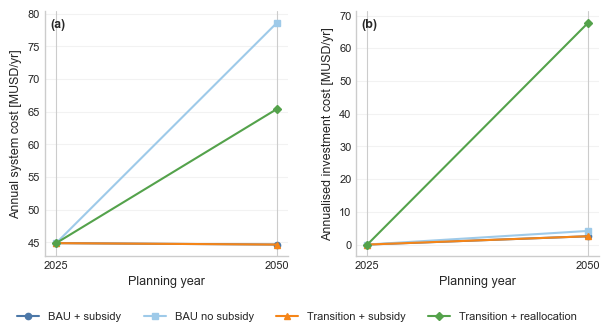


Saved:
  output/corrected_system_cost_by_investment_year.csv
  output/investment_year_ledger.csv


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Corrected annual system cost with investment-year accounting
#
# Each new capacity addition keeps the annualised capital_cost of the year
# in which it was built. Previous investments remain active in later
# planning years because the model uses myopic year-linking.
#
# No lifetime-based retirement is applied here, consistent with the current
# model formulation.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ── Scenario labels / styling ─────────────────────────────────────────────────
SCENARIO_LABELS_COST = {
    "BAU_SUB": "BAU + subsidy",
    "BAU_NOSUB": "BAU no subsidy",
    "TRANS_SUB": "Transition + subsidy",
    "TRANS_NOSUB": "Transition + reallocation",
}

SCENARIO_ORDER_COST = [s for s in SCENARIO_PLOT_ORDER if s in scenario_results]

SCENARIO_COLORS_COST = {
    "BAU + subsidy": "#4C78A8",
    "BAU no subsidy": "#9ECAE9",
    "Transition + subsidy": "#F58518",
    "Transition + reallocation": "#54A24B",
}

SCENARIO_MARKERS_COST = {
    "BAU + subsidy": "o",
    "BAU no subsidy": "s",
    "Transition + subsidy": "^",
    "Transition + reallocation": "D",
}



# ── Components with endogenous nominal capacity ───────────────────────────────
COMPONENT_SPECS_COST = {
    "Generator": {
        "table": "generators",
        "nom": "p_nom",
        "opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "Link": {
        "table": "links",
        "nom": "p_nom",
        "opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "StorageUnit": {
        "table": "storage_units",
        "nom": "p_nom",
        "opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "Store": {
        "table": "stores",
        "nom": "e_nom",
        "opt": "e_nom_opt",
        "extendable": "e_nom_extendable",
    },
    "Line": {
        "table": "lines",
        "nom": "s_nom",
        "opt": "s_nom_opt",
        "extendable": "s_nom_extendable",
    },
    "Transformer": {
        "table": "transformers",
        "nom": "s_nom",
        "opt": "s_nom_opt",
        "extendable": "s_nom_extendable",
    },
}


def _safe_bool_series(values, index):
    if values is None:
        return pd.Series(False, index=index)

    return values.reindex(index).fillna(False).astype(bool)


def _extract_cost_assets(network):
    """
    Return one row per capacity-bearing asset.

    capital_cost is assumed to already be annualised [USD/(nominal unit·yr)],
    consistent with the PyPSA objective.
    """
    rows = []

    for component, spec in COMPONENT_SPECS_COST.items():
        table = getattr(
            network,
            spec["table"],
            None,
        )

        if table is None or table.empty:
            continue

        fixed_nom = pd.to_numeric(
            table.get(
                spec["nom"],
                pd.Series(
                    0.0,
                    index=table.index,
                ),
            ),
            errors="coerce",
        ).fillna(0.0)

        if spec["opt"] in table.columns:
            opt_nom = pd.to_numeric(
                table[spec["opt"]],
                errors="coerce",
            ).fillna(fixed_nom)
        else:
            opt_nom = fixed_nom.copy()

        extendable = _safe_bool_series(
            table.get(
                spec["extendable"],
                None,
            ),
            table.index,
        )

        capital_cost = pd.to_numeric(
            table.get(
                "capital_cost",
                pd.Series(
                    0.0,
                    index=table.index,
                ),
            ),
            errors="coerce",
        ).fillna(0.0)

        carrier = (
            table.get(
                "carrier",
                pd.Series(
                    component,
                    index=table.index,
                ),
            )
            .fillna(component)
            .astype(str)
        )

        for asset_name in table.index:
            rows.append(
                {
                    "asset_id": (f"{component}::{asset_name}"),
                    "component": component,
                    "asset": str(asset_name),
                    "carrier": carrier.loc[asset_name],
                    "capacity": float(opt_nom.loc[asset_name]),
                    "capital_cost": float(capital_cost.loc[asset_name]),
                    "extendable": bool(extendable.loc[asset_name]),
                }
            )

    return pd.DataFrame(rows)


# ── Reconstruct investment additions ──────────────────────────────────────────
investment_rows = []
annual_cost_rows = []

for scenario_code in SCENARIO_ORDER_COST:
    if scenario_code not in scenario_results:
        continue

    package = scenario_results[scenario_code]

    scenario_label = SCENARIO_LABELS_COST.get(
        scenario_code,
        scenario_code,
    )

    planning_years = sorted(int(year) for year in package["results"].keys())

    previous_capacity = {}

    # Stores every investment addition made so far.
    active_investments = []

    for year in planning_years:
        result = package["results"][year]

        network = result["network"]

        assets = _extract_cost_assets(network)

        # ── Identify additions relative to previous planning year ─────────────
        if not assets.empty:
            for _, row in assets.iterrows():
                asset_id = row["asset_id"]

                current_capacity = float(row["capacity"])

                previous = float(
                    previous_capacity.get(
                        asset_id,
                        0.0,
                    )
                )

                addition = max(
                    current_capacity - previous,
                    0.0,
                )

                if row["extendable"] and addition > 1e-6:
                    annualised_cost = addition * float(row["capital_cost"])

                    investment = {
                        "scenario": scenario_code,
                        "scenario_label": (scenario_label),
                        "investment_year": year,
                        "component": (row["component"]),
                        "asset": row["asset"],
                        "carrier": row["carrier"],
                        "capacity_addition": (addition),
                        "capital_cost_at_investment": (float(row["capital_cost"])),
                        "annualised_cost": (annualised_cost),
                    }

                    active_investments.append(investment)

                    investment_rows.append(investment)

                # Preserve highest installed capacity reached.
                previous_capacity[asset_id] = max(
                    previous,
                    current_capacity,
                )

        # ── Investment charge currently represented in this PyPSA network ─────
        #
        # This values all accumulated extendable capacity using the
        # capital_cost of the CURRENT planning year.
        #
        pypsa_investment_charge = 0.0

        if not assets.empty:
            extendable_assets = assets[assets["extendable"]]

            pypsa_investment_charge = float((extendable_assets["capacity"] * extendable_assets["capital_cost"]).sum())

        # ── Correct accumulated investment cost ───────────────────────────────
        #
        # Every addition keeps the cost from its own investment year.
        #
        corrected_investment_charge = float(
            sum(inv["annualised_cost"] for inv in active_investments if (inv["investment_year"] <= year))
        )

        raw_objective = float(
            result.get(
                "objective",
                network.objective,
            )
        )

        # Everything not identified as nominal-capacity investment is preserved
        # from the solved objective.
        non_investment_cost = raw_objective - pypsa_investment_charge

        corrected_system_cost = corrected_investment_charge + non_investment_cost

        annual_cost_rows.append(
            {
                "scenario": (scenario_code),
                "scenario_label": (scenario_label),
                "year": year,
                "raw_objective": (raw_objective),
                "pypsa_investment_charge": (pypsa_investment_charge),
                "corrected_investment_charge": (corrected_investment_charge),
                "non_investment_cost": (non_investment_cost),
                "corrected_system_cost": (corrected_system_cost),
            }
        )


investment_year_ledger = pd.DataFrame(investment_rows)

corrected_system_cost_summary = pd.DataFrame(annual_cost_rows)


# ── Diagnostics ────────────────────────────────────────────────────────────────
diagnostic = corrected_system_cost_summary.copy()

for column in [
    "raw_objective",
    "pypsa_investment_charge",
    "corrected_investment_charge",
    "non_investment_cost",
    "corrected_system_cost",
]:
    diagnostic[f"{column}_MUSD"] = diagnostic[column] / 1e6


print("Corrected system-cost accounting:")

display(
    diagnostic[
        [
            "scenario_label",
            "year",
            "raw_objective_MUSD",
            "pypsa_investment_charge_MUSD",
            "corrected_investment_charge_MUSD",
            "non_investment_cost_MUSD",
            "corrected_system_cost_MUSD",
        ]
    ].round(3)
)


# ── Investment additions by year ──────────────────────────────────────────────
if not investment_year_ledger.empty:
    investment_summary = investment_year_ledger.groupby(
        [
            "scenario_label",
            "investment_year",
            "component",
            "carrier",
        ],
        as_index=False,
    ).agg(
        capacity_addition=(
            "capacity_addition",
            "sum",
        ),
        annualised_cost=(
            "annualised_cost",
            "sum",
        ),
    )

    investment_summary["annualised_cost_MUSD"] = investment_summary["annualised_cost"] / 1e6

    print("\nInvestment additions by planning year:")

    display(
        investment_summary[
            [
                "scenario_label",
                "investment_year",
                "component",
                "carrier",
                "capacity_addition",
                "annualised_cost_MUSD",
            ]
        ].round(3)
    )


# ── Special PtX diagnostic ────────────────────────────────────────────────────
if "PTX_base" in corrected_system_cost_summary["scenario"].values:
    print("\nPtX annual cost evolution:")

    display(
        diagnostic.loc[
            diagnostic["scenario"].eq("PTX_base"),
            [
                "year",
                "raw_objective_MUSD",
                "pypsa_investment_charge_MUSD",
                "corrected_investment_charge_MUSD",
                "non_investment_cost_MUSD",
                "corrected_system_cost_MUSD",
            ],
        ].round(3)
    )


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        globals().get(
            "WORD_DOUBLE_COL_IN",
            7.2,
        ),
        3.3,
    ),
)


for scenario_code in SCENARIO_ORDER_COST:
    df = corrected_system_cost_summary.loc[corrected_system_cost_summary["scenario"].eq(scenario_code)].sort_values(
        "year"
    )

    if df.empty:
        continue

    label = SCENARIO_LABELS_COST[scenario_code]

    axes[0].plot(
        df["year"],
        (df["corrected_system_cost"] / 1e6),
        marker=(SCENARIO_MARKERS_COST[label]),
        color=(SCENARIO_COLORS_COST[label]),
        linewidth=1.5,
        markersize=4.5,
        label=label,
    )

    axes[1].plot(
        df["year"],
        (df["corrected_investment_charge"] / 1e6),
        marker=(SCENARIO_MARKERS_COST[label]),
        color=(SCENARIO_COLORS_COST[label]),
        linewidth=1.5,
        markersize=4.5,
        label=label,
    )


axes[0].set_ylabel("Annual system cost [MUSD/yr]")

axes[1].set_ylabel("Annualised investment cost [MUSD/yr]")

for ax in axes:
    ax.set_xlabel("Planning year")

    ax.set_xticks(sorted(corrected_system_cost_summary["year"].unique()))

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)


axes[0].text(
    0.02,
    0.97,
    "(a)",
    transform=(axes[0].transAxes),
    ha="left",
    va="top",
    fontweight="bold",
)

axes[1].text(
    0.02,
    0.97,
    "(b)",
    transform=(axes[1].transAxes),
    ha="left",
    va="top",
    fontweight="bold",
)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        -0.01,
    ),
    ncol=5,
    frameon=False,
)


fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.96,
    bottom=0.22,
    wspace=0.28,
)

plt.show()


# ── Export tables ──────────────────────────────────────────────────────────────
output_root = Path("output")

output_root.mkdir(
    parents=True,
    exist_ok=True,
)

corrected_system_cost_summary.to_csv(
    output_root / "corrected_system_cost_by_investment_year.csv",
    index=False,
)

investment_year_ledger.to_csv(
    output_root / "investment_year_ledger.csv",
    index=False,
)

print("\nSaved:")

print("  output/corrected_system_cost_by_investment_year.csv")

print("  output/investment_year_ledger.csv")

,scenario_label,year,raw_objective_MUSD,current_investment_MUSD,corrected_investment_MUSD,non_investment_MUSD,corrected_objective_MUSD
0,BAU,2025,44.878,0.000,0.000,44.878,44.878
1,BAU,2050,44.663,2.541,2.541,42.121,44.663
2,BAU,2025,44.878,0.000,0.000,44.878,44.878
3,BAU,2050,78.664,4.173,4.173,74.490,78.664
4,TRANS_SUB,2025,44.878,0.000,0.000,44.878,44.878
5,TRANS_SUB,2050,44.663,2.541,2.541,42.121,44.663
6,TRANS_NOSUB,2025,44.878,0.000,0.000,44.878,44.878
7,TRANS_NOSUB,2050,65.448,67.880,67.880,-2.433,65.448



Capacity additions by investment year:


,scenario_label,build_year,component,carrier,capacity_addition,annual_cost_MUSD
0,BAU,2050,Generator,solar,122.496,6.715
1,TRANS_NOSUB,2050,Generator,solar,604.029,33.110
2,TRANS_NOSUB,2050,Link,electric_boiler,80.409,1.250
3,TRANS_NOSUB,2050,Link,electric_water_heater,8.628,0.134
4,TRANS_NOSUB,2050,Link,heat_pump,31.207,17.807
5,TRANS_NOSUB,2050,Link,heat_pump_water_heater,3.165,1.426
6,TRANS_NOSUB,2050,StorageUnit,bess,240.275,14.153
7,TRANS_SUB,2050,Generator,solar,46.360,2.541


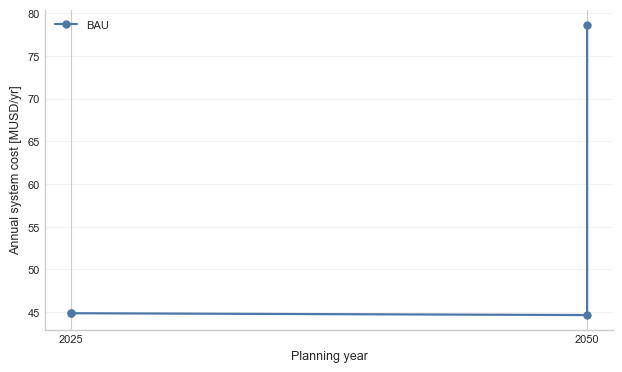

In [30]:
# Corrected investment-cost accounting by build year
# Tracks each capacity addition at the annualised capital cost
# applicable in the year in which it was built.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# ── Configuration ─────────────────────────────────────────────────────────────
scenario_order = [
    "BAU",
    "RT",
    "RE",
    "RH",
    "PtX",
]

small_font = globals().get(
    "FONT_SIZE_SMALL",
    8,
)

figure_width = globals().get(
    "WORD_DOUBLE_COL_IN",
    7.2,
)

scenario_colors = {
    "BAU": "#4C78A8",
    "RT": "#F58518",
    "RE": "#54A24B",
    "RH": "#E45756",
    "PtX": "#8E6CBE",
}

scenario_markers = {
    "BAU": "o",
    "RT": "s",
    "RE": "^",
    "RH": "D",
    "PtX": "P",
}


# ── Helpers ───────────────────────────────────────────────────────────────────
def _label_scenario(code):
    text = str(code).upper()

    if "PTX" in text:
        return "PtX"

    for label in [
        "BAU",
        "RT",
        "RE",
        "RH",
    ]:
        if label in text:
            return label

    return str(code)


COMPONENTS = {
    "Generator": {
        "table": "generators",
        "capacity": "p_nom",
        "capacity_opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "Link": {
        "table": "links",
        "capacity": "p_nom",
        "capacity_opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "StorageUnit": {
        "table": "storage_units",
        "capacity": "p_nom",
        "capacity_opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "Store": {
        "table": "stores",
        "capacity": "e_nom",
        "capacity_opt": "e_nom_opt",
        "extendable": "e_nom_extendable",
    },
}


def _asset_table(network, component_name):
    specification = COMPONENTS[component_name]

    table = getattr(
        network,
        specification["table"],
    )

    if table.empty:
        return pd.DataFrame()

    fixed_capacity = pd.to_numeric(
        table[specification["capacity"]],
        errors="coerce",
    ).fillna(0.0)

    if specification["capacity_opt"] in table.columns:
        capacity = pd.to_numeric(
            table[specification["capacity_opt"]],
            errors="coerce",
        ).fillna(fixed_capacity)
    else:
        capacity = fixed_capacity

    if specification["extendable"] in table.columns:
        extendable = table[specification["extendable"]].fillna(False).astype(bool)
    else:
        extendable = pd.Series(
            False,
            index=table.index,
        )

    capital_cost = pd.to_numeric(
        table.get(
            "capital_cost",
            pd.Series(
                0.0,
                index=table.index,
            ),
        ),
        errors="coerce",
    ).fillna(0.0)

    carrier = table.get(
        "carrier",
        pd.Series(
            component_name,
            index=table.index,
        ),
    ).astype(str)

    result = pd.DataFrame(
        {
            "asset": (component_name + "::" + table.index.astype(str)),
            "component": component_name,
            "carrier": carrier.values,
            "capacity": capacity.values,
            "capital_cost": capital_cost.values,
            "extendable": extendable.values,
        },
        index=table.index,
    )

    return result


def _extract_all_assets(network):
    frames = []

    for component_name in COMPONENTS:
        try:
            frame = _asset_table(
                network,
                component_name,
            )
        except Exception:
            continue

        if not frame.empty:
            frames.append(frame)

    if not frames:
        return pd.DataFrame()

    return pd.concat(
        frames,
        ignore_index=True,
    )


# ── Track capacity additions by build year ────────────────────────────────────
build_records = []
corrected_cost_rows = []

for scenario_code, package in scenario_results.items():
    scenario_label = _label_scenario(scenario_code)

    years = sorted(int(year) for year in package["results"].keys())

    previous_capacity = {}

    # Each entry remains active in later planning years.
    active_builds = []

    for year in years:
        network = package["results"][year]["network"]

        assets = _extract_all_assets(network)

        # ── Identify new additions ─────────────────────────────────────────────
        for _, asset in assets.iterrows():
            asset_id = asset["asset"]

            current_capacity = float(asset["capacity"])

            previous = float(
                previous_capacity.get(
                    asset_id,
                    0.0,
                )
            )

            addition = max(
                current_capacity - previous,
                0.0,
            )

            if bool(asset["extendable"]) and addition > 1e-6:
                annual_cost = addition * float(asset["capital_cost"])

                build = {
                    "scenario": scenario_code,
                    "scenario_label": scenario_label,
                    "build_year": year,
                    "asset": asset_id,
                    "component": asset["component"],
                    "carrier": asset["carrier"],
                    "capacity_addition": addition,
                    "capital_cost_at_build": float(asset["capital_cost"]),
                    "annual_cost": annual_cost,
                }

                active_builds.append(build)

                build_records.append(build)

            previous_capacity[asset_id] = max(
                previous,
                current_capacity,
            )

        # ── Correct investment accounting ──────────────────────────────────────
        #
        # Annual investment payment = sum of all active build-year annualities.
        #
        corrected_investment_cost = sum(build["annual_cost"] for build in active_builds if build["build_year"] <= year)

        # What PyPSA is currently charging for investment in this year:
        #
        # current total capacity × current-year capital_cost
        current_investment_cost = 0.0

        for _, asset in assets.iterrows():
            if not bool(asset["extendable"]):
                continue

            current_investment_cost += float(asset["capacity"]) * float(asset["capital_cost"])

        objective = float(network.objective)

        # Preserve all non-investment terms from the solved objective.
        non_investment_cost = objective - current_investment_cost

        corrected_objective = non_investment_cost + corrected_investment_cost

        corrected_cost_rows.append(
            {
                "scenario": scenario_code,
                "scenario_label": scenario_label,
                "year": year,
                "raw_objective": objective,
                "current_investment_cost": (current_investment_cost),
                "corrected_investment_cost": (corrected_investment_cost),
                "non_investment_cost": (non_investment_cost),
                "corrected_objective": (corrected_objective),
            }
        )


build_ledger = pd.DataFrame(build_records)

corrected_cost_summary = pd.DataFrame(corrected_cost_rows)


# ── Diagnostic table ──────────────────────────────────────────────────────────
display(
    corrected_cost_summary.assign(
        raw_objective_MUSD=lambda df: df["raw_objective"] / 1e6,
        current_investment_MUSD=lambda df: df["current_investment_cost"] / 1e6,
        corrected_investment_MUSD=lambda df: df["corrected_investment_cost"] / 1e6,
        non_investment_MUSD=lambda df: df["non_investment_cost"] / 1e6,
        corrected_objective_MUSD=lambda df: df["corrected_objective"] / 1e6,
    )[
        [
            "scenario_label",
            "year",
            "raw_objective_MUSD",
            "current_investment_MUSD",
            "corrected_investment_MUSD",
            "non_investment_MUSD",
            "corrected_objective_MUSD",
        ]
    ].round(3)
)


print("\nCapacity additions by investment year:")

if not build_ledger.empty:
    display(
        build_ledger.groupby(
            [
                "scenario_label",
                "build_year",
                "component",
                "carrier",
            ],
            as_index=False,
        )
        .agg(
            capacity_addition=(
                "capacity_addition",
                "sum",
            ),
            annual_cost_MUSD=(
                "annual_cost",
                lambda x: x.sum() / 1e6,
            ),
        )
        .round(3)
    )


# ── Plot corrected annual system cost ─────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(
        figure_width,
        3.8,
    )
)

for scenario_label in scenario_order:
    data = corrected_cost_summary.loc[corrected_cost_summary["scenario_label"].eq(scenario_label)].sort_values("year")

    if data.empty:
        continue

    ax.plot(
        data["year"],
        data["corrected_objective"] / 1e6,
        marker=scenario_markers[scenario_label],
        color=scenario_colors[scenario_label],
        linewidth=1.6,
        markersize=5,
        label=scenario_label,
    )


ax.set_xlabel("Planning year")

ax.set_ylabel("Annual system cost [MUSD/yr]")

ax.set_xticks(sorted(corrected_cost_summary["year"].unique()))

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    ncol=5,
    fontsize=small_font,
)

fig.tight_layout()

plt.show()

Average system cost using corrected investment-year accounting:


,scenario_label,year,system_cost_MUSD_yr,local_demand_MWh,ptx_use_MWh,local_plus_ptx_MWh,system_cost_local_usd_per_mwh,system_cost_local_plus_ptx_usd_per_mwh
0,BAU + subsidy,2025,44.88,277235.99,0.0,277235.99,161.88,161.88
1,BAU + subsidy,2050,44.66,277235.99,0.0,277235.99,161.10,161.10
2,BAU no subsidy,2025,44.88,277235.99,0.0,277235.99,161.88,161.88
3,BAU no subsidy,2050,78.66,277235.99,0.0,277235.99,283.74,283.74
4,Transition + subsidy,2025,44.88,277235.99,0.0,277235.99,161.88,161.88
5,Transition + subsidy,2050,44.66,277235.99,0.0,277235.99,161.10,161.10
6,Transition + reallocation,2025,44.88,277235.99,0.0,277235.99,161.88,161.88
7,Transition + reallocation,2050,65.45,277235.99,0.0,277235.99,236.07,236.07


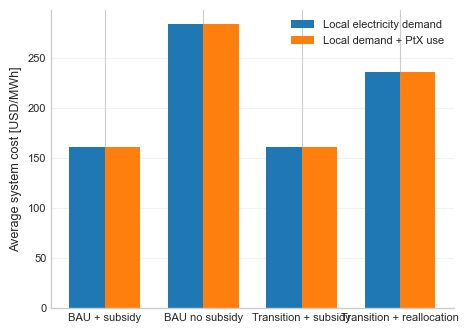


Saved:
  output/corrected_average_system_cost_usd_per_mwh.csv


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 9 candidate panel — Average system cost [USD/MWh]
#
# Uses corrected_system_cost_summary from the investment-year/vintage
# accounting cell above.
#
# Two normalisations:
#   1. Corrected system cost / local electricity demand
#   2. Corrected system cost / (local electricity demand + PtX electricity use)
#
# IMPORTANT:
# - BESS charging is NOT counted in the denominator.
# - Electrolysis in RH is NOT counted as final electricity use.
# - PtX electricity use is added only for PtX-enabled scenarios.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ── Configuration ─────────────────────────────────────────────────────────────
COST_PER_MWH_YEAR = globals().get(
    "detailed_year",
    2050,
)

SCENARIO_ORDER_USD_MWH = [s for s in SCENARIO_PLOT_ORDER if s in scenario_results]

SCENARIO_LABELS_USD_MWH = {
    "BAU_SUB": "BAU + subsidy",
    "BAU_NOSUB": "BAU no subsidy",
    "TRANS_SUB": "Transition + subsidy",
    "TRANS_NOSUB": "Transition + reallocation",
}


# ── Validation ────────────────────────────────────────────────────────────────
if "corrected_system_cost_summary" not in globals() or corrected_system_cost_summary.empty:
    raise ValueError(
        "corrected_system_cost_summary is not available. Run the corrected investment-year cost cell first."
    )


# ── Helpers ───────────────────────────────────────────────────────────────────
def _fig9_snapshot_weights(net, index):
    """Return one-dimensional annual snapshot weights."""

    sw = net.snapshot_weightings

    try:
        values = sw["objective"]
    except (KeyError, TypeError, IndexError):
        try:
            values = sw.objective
        except AttributeError:
            values = sw

    values = np.asarray(
        values,
        dtype=float,
    )

    if values.ndim == 2:
        values = values[:, 0]

    values = values.reshape(-1)

    if len(values) != len(index):
        raise ValueError(f"Snapshot-weight length mismatch: {len(values)} weights for {len(index)} snapshots.")

    return pd.Series(
        values,
        index=index,
        dtype=float,
    )


def _fig9_local_load(result):
    """
    Total exogenous/local electricity demand [MW].

    Uses result['load'] when available, otherwise net.loads_t.p_set.
    """
    load = result.get(
        "load",
        None,
    )

    net = result["network"]

    if load is None:
        load = getattr(
            net.loads_t,
            "p_set",
            pd.DataFrame(index=net.snapshots),
        )

    if isinstance(
        load,
        pd.Series,
    ):
        output = load.copy()

    else:
        output = (
            load.apply(
                pd.to_numeric,
                errors="coerce",
            )
            .fillna(0.0)
            .sum(axis=1)
        )

    output = (
        pd.to_numeric(
            output,
            errors="coerce",
        )
        .fillna(0.0)
        .clip(lower=0.0)
    )

    return output


def _fig9_link_input(net, carriers):
    """
    Positive electricity input to selected links [MW].

    p0 is assumed to be the electricity-side input for the selected
    PtX conversion links, consistent with the Figure 5 calculation.
    """
    snapshots = pd.Index(net.snapshots)

    if len(net.links) == 0 or not hasattr(
        net.links_t,
        "p0",
    ):
        return pd.Series(
            0.0,
            index=snapshots,
        )

    carrier_series = (
        net.links.get(
            "carrier",
            pd.Series(
                "",
                index=net.links.index,
            ),
        )
        .astype(str)
        .str.lower()
    )

    requested = {str(carrier).lower() for carrier in carriers}

    selected_links = net.links.index[carrier_series.isin(requested)]

    selected_links = [link for link in selected_links if link in net.links_t.p0.columns]

    if not selected_links:
        return pd.Series(
            0.0,
            index=snapshots,
        )

    return (
        net.links_t.p0.reindex(
            index=snapshots,
            columns=selected_links,
            fill_value=0.0,
        )
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
        .clip(lower=0.0)
        .sum(axis=1)
    )


# ── Build energy denominators ─────────────────────────────────────────────────
energy_rows = []

for scenario_code in SCENARIO_ORDER_USD_MWH:
    if scenario_code not in scenario_results:
        continue

    package = scenario_results[scenario_code]

    enable_ptx = bool(
        package.get(
            "metadata",
            {},
        ).get(
            "enable_ptx",
            "PTX" in scenario_code.upper(),
        )
    )

    for year, result in sorted(package["results"].items()):
        year = int(year)

        net = result["network"]

        local_load = _fig9_local_load(result).reindex(net.snapshots).fillna(0.0)

        weights = _fig9_snapshot_weights(
            net,
            local_load.index,
        )

        local_demand_mwh = float((local_load * weights).sum())

        # ── PtX electricity use ──────────────────────────────────────────────
        #
        # Only added for PtX-enabled scenarios.
        #
        # Consistent with Figure 5:
        #   electrolyser + PtX auxiliaries (ASU/DAC)
        #
        if enable_ptx:
            electrolyser_use = _fig9_link_input(
                net,
                [
                    "electrolyzer",
                    "electrolyser",
                ],
            )

            ptx_aux_use = _fig9_link_input(
                net,
                [
                    "asu",
                    "dac",
                ],
            )

            ptx_use = electrolyser_use + ptx_aux_use

            ptx_use_mwh = float((ptx_use * weights).sum())

        else:
            ptx_use_mwh = 0.0

        local_plus_ptx_mwh = local_demand_mwh + ptx_use_mwh

        energy_rows.append(
            {
                "scenario": scenario_code,
                "scenario_label": (
                    SCENARIO_LABELS_USD_MWH.get(
                        scenario_code,
                        scenario_code,
                    )
                ),
                "year": year,
                "local_demand_mwh": (local_demand_mwh),
                "ptx_electricity_use_mwh": (ptx_use_mwh),
                "local_plus_ptx_mwh": (local_plus_ptx_mwh),
            }
        )


fig9_energy_summary = pd.DataFrame(energy_rows)


# ── Merge with corrected cost accounting ──────────────────────────────────────
fig9_cost_per_mwh = corrected_system_cost_summary[
    [
        "scenario",
        "scenario_label",
        "year",
        "corrected_system_cost",
        "corrected_investment_charge",
        "non_investment_cost",
    ]
].merge(
    fig9_energy_summary[
        [
            "scenario",
            "year",
            "local_demand_mwh",
            "ptx_electricity_use_mwh",
            "local_plus_ptx_mwh",
        ]
    ],
    on=[
        "scenario",
        "year",
    ],
    how="left",
)


# ── Calculate USD/MWh indicators ──────────────────────────────────────────────
fig9_cost_per_mwh["system_cost_local_usd_per_mwh"] = fig9_cost_per_mwh["corrected_system_cost"] / fig9_cost_per_mwh[
    "local_demand_mwh"
].replace(
    0.0,
    np.nan,
)

fig9_cost_per_mwh["system_cost_local_plus_ptx_usd_per_mwh"] = fig9_cost_per_mwh[
    "corrected_system_cost"
] / fig9_cost_per_mwh["local_plus_ptx_mwh"].replace(
    0.0,
    np.nan,
)


# ── Diagnostics ────────────────────────────────────────────────────────────────
display_columns = [
    "scenario_label",
    "year",
    "corrected_system_cost",
    "local_demand_mwh",
    "ptx_electricity_use_mwh",
    "local_plus_ptx_mwh",
    "system_cost_local_usd_per_mwh",
    "system_cost_local_plus_ptx_usd_per_mwh",
]

fig9_diagnostic = fig9_cost_per_mwh[display_columns].copy()

fig9_diagnostic["corrected_system_cost"] /= 1e6

fig9_diagnostic = fig9_diagnostic.rename(
    columns={
        "corrected_system_cost": "system_cost_MUSD_yr",
        "local_demand_mwh": "local_demand_MWh",
        "ptx_electricity_use_mwh": "ptx_use_MWh",
        "local_plus_ptx_mwh": "local_plus_ptx_MWh",
    }
)

print("Average system cost using corrected investment-year accounting:")

display(fig9_diagnostic.round(2))


# ── Plot selected year ────────────────────────────────────────────────────────
plot_data = fig9_cost_per_mwh.loc[fig9_cost_per_mwh["year"].eq(COST_PER_MWH_YEAR)].copy()

scenario_position = {scenario_code: position for position, scenario_code in enumerate(SCENARIO_ORDER_USD_MWH)}

plot_data["_order"] = plot_data["scenario"].map(scenario_position).fillna(99)

plot_data = plot_data.sort_values("_order").reset_index(drop=True)


fig, ax = plt.subplots(
    figsize=(
        globals().get(
            "WORD_SINGLE_COL_IN",
            4.8,
        ),
        3.4,
    )
)

x = np.arange(len(plot_data))

bar_width = 0.36


# Local electricity demand denominator
ax.bar(
    x - bar_width / 2,
    plot_data["system_cost_local_usd_per_mwh"],
    width=bar_width,
    label="Local electricity demand",
)


# Local + PtX electricity-use denominator
ax.bar(
    x + bar_width / 2,
    plot_data["system_cost_local_plus_ptx_usd_per_mwh"],
    width=bar_width,
    label="Local demand + PtX use",
)


ax.set_xticks(x)

ax.set_xticklabels(plot_data["scenario_label"])

ax.set_ylabel("Average system cost [USD/MWh]")

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=8,
)

fig.tight_layout()

plt.show()


# ── Export numerical data ─────────────────────────────────────────────────────
output_root = Path("output")

output_root.mkdir(
    parents=True,
    exist_ok=True,
)

fig9_cost_per_mwh.to_csv(
    output_root / "corrected_average_system_cost_usd_per_mwh.csv",
    index=False,
)

print("\nSaved:")

print("  output/corrected_average_system_cost_usd_per_mwh.csv")

Corrected Figure 9 cost accounting:


,scenario_label,year,investment_MUSD_yr,opex_MUSD_yr,system_cost_MUSD_yr,raw_objective_MUSD_yr,old_residual_MUSD_yr,local_demand_MWh,ptx_use_MWh,cost_local_USD_MWh,cost_local_plus_PtX_USD_MWh
0,BAU + subsidy,2025,0.00,44.88,44.88,44.88,44.88,277235.99,0.0,161.88,161.88
1,BAU + subsidy,2050,2.54,42.12,44.66,44.66,42.12,277235.99,0.0,161.10,161.10
2,BAU no subsidy,2025,0.00,44.88,44.88,44.88,44.88,277235.99,0.0,161.88,161.88
3,BAU no subsidy,2050,4.17,74.49,78.66,78.66,74.49,277235.99,0.0,283.74,283.74
4,Transition + subsidy,2025,0.00,44.88,44.88,44.88,44.88,277235.99,0.0,161.88,161.88
5,Transition + subsidy,2050,2.54,42.12,44.66,44.66,42.12,277235.99,0.0,161.10,161.10
6,Transition + reallocation,2025,0.00,44.88,44.88,44.88,44.88,277235.99,0.0,161.88,161.88
7,Transition + reallocation,2050,67.88,31.51,99.39,65.45,-2.43,277235.99,0.0,358.50,358.50



Maximum accounting identity error: 0.000000 USD

Explicit operating-cost breakdown [MUSD/yr]:


component                       Generator  Link  StorageUnit charge  \
scenario_label            year                                        
BAU + subsidy             2025     44.878   0.0                 0.0   
                          2050     42.121   0.0                 0.0   
BAU no subsidy            2025     44.878   0.0                 0.0   
                          2050     74.490   0.0                 0.0   
Transition + reallocation 2025     44.878   0.0                 0.0   
                          2050     31.507   0.0                 0.0   
Transition + subsidy      2025     44.878   0.0                 0.0   
                          2050     42.121   0.0                 0.0   

component                       StorageUnit discharge  
scenario_label            year                         
BAU + subsidy             2025                    0.0  
                          2050                    0.0  
BAU no subsidy            2025                    0.0  
                          2050                    0.0  
Transition + reallocation 2025                    0.0  
                          2050                    0.0  
Transition + subsidy      2025                    0.0  
                          2050                    0.0

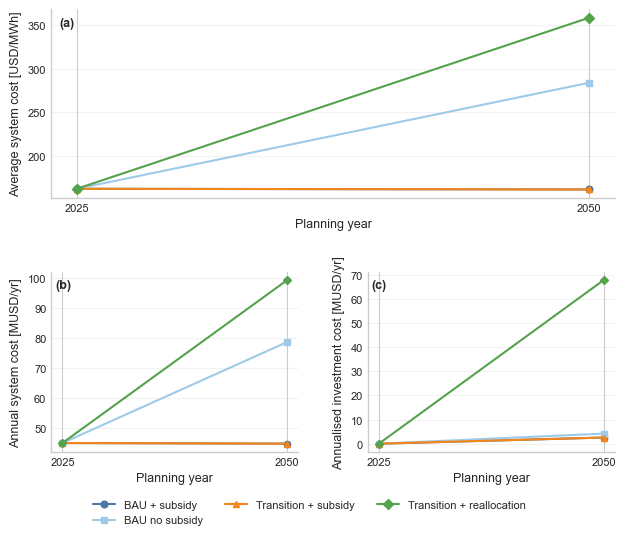


Saved:
  output/figure9_corrected_system_cost_summary.csv
  output/figure9_investment_year_ledger.csv
  output/figure9_operating_cost_detail.csv


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 9 — Corrected system costs with investment-year accounting
#
# SELF-CONTAINED CELL
#
# Annual system cost =
#     annualised cost of ALL active investment vintages
#   + explicitly reconstructed annual operating cost
#
# IMPORTANT:
# - Investments made in 2030 continue contributing annualised costs in
#   2040 and 2050.
# - Each vintage keeps the capital_cost of its investment year.
# - No lifetime-based retirement is applied, consistent with the current
#   myopic year-linking formulation.
# - The PyPSA objective is used ONLY as a diagnostic, not to reconstruct OPEX.
#
# Figure 9:
#   (a) Average system cost [USD/MWh]
#   (b) Annual system cost [MUSD/yr]
#   (c) Annualised investment cost [MUSD/yr]
#
# PtX dashed line in (a):
#   system cost / (local electricity demand + PtX electricity use)
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.gridspec import GridSpec


# ══════════════════════════════════════════════════════════════════════════════
# 0. CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

SCENARIO_LABELS_COST = {
    "BAU_SUB": "BAU + subsidy",
    "BAU_NOSUB": "BAU no subsidy",
    "TRANS_SUB": "Transition + subsidy",
    "TRANS_NOSUB": "Transition + reallocation",
}

SCENARIO_ORDER_COST = [s for s in SCENARIO_PLOT_ORDER if s in scenario_results]

SCENARIO_COLORS_COST = {
    "BAU + subsidy": "#4C78A8",
    "BAU no subsidy": "#9ECAE9",
    "Transition + subsidy": "#F58518",
    "Transition + reallocation": "#54A24B",
}

SCENARIO_MARKERS_COST = {
    "BAU + subsidy": "o",
    "BAU no subsidy": "s",
    "Transition + subsidy": "^",
    "Transition + reallocation": "D",
}



# Components with endogenous nominal capacity
COMPONENT_SPECS_COST = {
    "Generator": {
        "table": "generators",
        "nom": "p_nom",
        "opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "Link": {
        "table": "links",
        "nom": "p_nom",
        "opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "StorageUnit": {
        "table": "storage_units",
        "nom": "p_nom",
        "opt": "p_nom_opt",
        "extendable": "p_nom_extendable",
    },
    "Store": {
        "table": "stores",
        "nom": "e_nom",
        "opt": "e_nom_opt",
        "extendable": "e_nom_extendable",
    },
    "Line": {
        "table": "lines",
        "nom": "s_nom",
        "opt": "s_nom_opt",
        "extendable": "s_nom_extendable",
    },
    "Transformer": {
        "table": "transformers",
        "nom": "s_nom",
        "opt": "s_nom_opt",
        "extendable": "s_nom_extendable",
    },
}


# ══════════════════════════════════════════════════════════════════════════════
# 1. GENERAL HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _safe_bool_series(values, index):

    if values is None:
        return pd.Series(False, index=index)

    return (
        values
        .reindex(index)
        .fillna(False)
        .astype(bool)
    )


def _snapshot_weights(net, index):
    """
    Objective snapshot weights used for annual operating costs / energy.
    """

    sw = net.snapshot_weightings

    try:
        values = sw["objective"]

    except (KeyError, TypeError, IndexError):

        try:
            values = sw.objective

        except AttributeError:
            values = sw

    values = np.asarray(
        values,
        dtype=float,
    )

    if values.ndim == 2:
        values = values[:, 0]

    values = values.reshape(-1)

    if len(values) != len(index):
        raise ValueError(
            "Snapshot-weight length mismatch: "
            f"{len(values)} weights for {len(index)} snapshots."
        )

    return pd.Series(
        values,
        index=index,
        dtype=float,
    )


# ══════════════════════════════════════════════════════════════════════════════
# 2. INVESTMENT ASSETS
# ══════════════════════════════════════════════════════════════════════════════

def _extract_cost_assets(network):
    """
    Return one row per capacity-bearing asset.

    capital_cost is assumed to already be annualised
    [USD/(nominal unit·yr)].
    """

    rows = []

    for component, spec in COMPONENT_SPECS_COST.items():

        table = getattr(
            network,
            spec["table"],
            None,
        )

        if table is None or table.empty:
            continue

        fixed_nom = pd.to_numeric(
            table.get(
                spec["nom"],
                pd.Series(
                    0.0,
                    index=table.index,
                ),
            ),
            errors="coerce",
        ).fillna(0.0)

        if spec["opt"] in table.columns:

            opt_nom = pd.to_numeric(
                table[spec["opt"]],
                errors="coerce",
            ).fillna(fixed_nom)

        else:
            opt_nom = fixed_nom.copy()

        extendable = _safe_bool_series(
            table.get(
                spec["extendable"],
                None,
            ),
            table.index,
        )

        capital_cost = pd.to_numeric(
            table.get(
                "capital_cost",
                pd.Series(
                    0.0,
                    index=table.index,
                ),
            ),
            errors="coerce",
        ).fillna(0.0)

        carrier = (
            table.get(
                "carrier",
                pd.Series(
                    component,
                    index=table.index,
                ),
            )
            .fillna(component)
            .astype(str)
        )

        for asset_name in table.index:

            rows.append(
                {
                    "asset_id":
                        f"{component}::{asset_name}",

                    "component":
                        component,

                    "asset":
                        str(asset_name),

                    "carrier":
                        carrier.loc[asset_name],

                    "capacity":
                        float(opt_nom.loc[asset_name]),

                    "capital_cost":
                        float(capital_cost.loc[asset_name]),

                    "extendable":
                        bool(extendable.loc[asset_name]),
                }
            )

    return pd.DataFrame(rows)


# ══════════════════════════════════════════════════════════════════════════════
# 3. OPERATING COST HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _marginal_cost_matrix(
    net,
    static_table_name,
    time_series_container,
    columns,
    snapshots,
    attribute="marginal_cost",
):
    """
    Construct hourly marginal-cost matrix.

    Uses static marginal_cost unless a time-varying series is available.
    """

    table = getattr(
        net,
        static_table_name,
        pd.DataFrame(),
    )

    if (
        table is None
        or table.empty
        or len(columns) == 0
    ):
        return pd.DataFrame(
            0.0,
            index=snapshots,
            columns=columns,
        )

    static_cost = pd.to_numeric(
        table.get(
            attribute,
            pd.Series(
                0.0,
                index=table.index,
            ),
        ),
        errors="coerce",
    ).fillna(0.0)

    static_cost = (
        static_cost
        .reindex(columns)
        .fillna(0.0)
    )

    cost_matrix = pd.DataFrame(
        np.tile(
            static_cost.to_numpy(),
            (
                len(snapshots),
                1,
            ),
        ),
        index=snapshots,
        columns=columns,
        dtype=float,
    )

    # Time-varying marginal costs, if defined
    dynamic_cost = getattr(
        time_series_container,
        attribute,
        None,
    )

    if (
        isinstance(dynamic_cost, pd.DataFrame)
        and not dynamic_cost.empty
    ):

        common_columns = [
            col
            for col in columns
            if col in dynamic_cost.columns
        ]

        if common_columns:

            dynamic = (
                dynamic_cost
                .reindex(
                    index=snapshots,
                    columns=common_columns,
                )
                .apply(
                    pd.to_numeric,
                    errors="coerce",
                )
            )

            for col in common_columns:

                cost_matrix[col] = (
                    dynamic[col]
                    .fillna(
                        static_cost.loc[col]
                    )
                )

    return cost_matrix


def _weighted_operating_cost(
    flow,
    marginal_cost,
    weights,
):
    """
    Annual weighted operating cost [USD/yr].
    """

    if (
        flow is None
        or flow.empty
    ):
        return 0.0

    flow = (
        flow
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
    )

    marginal_cost = (
        marginal_cost
        .reindex(
            index=flow.index,
            columns=flow.columns,
            fill_value=0.0,
        )
        .fillna(0.0)
    )

    weighted = (
        flow
        * marginal_cost
    ).mul(
        weights,
        axis=0,
    )

    return float(
        weighted.sum().sum()
    )


def _explicit_operating_cost(net):
    """
    Reconstruct annual operating cost directly from dispatch.

    Included:
      - Generator dispatch × marginal_cost
      - Link input flow × marginal_cost
      - StorageUnit discharge × marginal_cost
      - StorageUnit charging × marginal_cost_storage, if defined
      - Store discharge × marginal_cost

    This avoids using:
        raw_objective - estimated_investment_cost
    which can become inconsistent under myopic year-linking.
    """

    snapshots = pd.Index(
        net.snapshots
    )

    weights = _snapshot_weights(
        net,
        snapshots,
    )

    rows = []

    total = 0.0


    # ── Generators ────────────────────────────────────────────────────────────
    if (
        not net.generators.empty
        and hasattr(
            net.generators_t,
            "p",
        )
    ):

        p = (
            net.generators_t.p
            .reindex(
                index=snapshots
            )
            .fillna(0.0)
        )

        columns = [
            col
            for col in p.columns
            if col in net.generators.index
        ]

        p = p[
            columns
        ].clip(
            lower=0.0
        )

        mc = _marginal_cost_matrix(
            net,
            "generators",
            net.generators_t,
            columns,
            snapshots,
            "marginal_cost",
        )

        cost = _weighted_operating_cost(
            p,
            mc,
            weights,
        )

        rows.append(
            {
                "component": "Generator",
                "operating_cost": cost,
            }
        )

        total += cost


    # ── Links ─────────────────────────────────────────────────────────────────
    if (
        not net.links.empty
        and hasattr(
            net.links_t,
            "p0",
        )
    ):

        p0 = (
            net.links_t.p0
            .reindex(
                index=snapshots
            )
            .fillna(0.0)
        )

        columns = [
            col
            for col in p0.columns
            if col in net.links.index
        ]

        # Positive input-side flow.
        p0 = p0[
            columns
        ].clip(
            lower=0.0
        )

        mc = _marginal_cost_matrix(
            net,
            "links",
            net.links_t,
            columns,
            snapshots,
            "marginal_cost",
        )

        cost = _weighted_operating_cost(
            p0,
            mc,
            weights,
        )

        rows.append(
            {
                "component": "Link",
                "operating_cost": cost,
            }
        )

        total += cost


    # ── Storage Units: discharge ──────────────────────────────────────────────
    if not net.storage_units.empty:

        if hasattr(
            net.storage_units_t,
            "p_dispatch",
        ):

            p_discharge = (
                net.storage_units_t.p_dispatch
                .reindex(
                    index=snapshots
                )
                .fillna(0.0)
            )

        elif hasattr(
            net.storage_units_t,
            "p",
        ):

            p_discharge = (
                net.storage_units_t.p
                .reindex(
                    index=snapshots
                )
                .fillna(0.0)
                .clip(
                    lower=0.0
                )
            )

        else:

            p_discharge = pd.DataFrame(
                index=snapshots
            )

        columns = [
            col
            for col in p_discharge.columns
            if col in net.storage_units.index
        ]

        p_discharge = (
            p_discharge[
                columns
            ]
            .clip(
                lower=0.0
            )
        )

        mc = _marginal_cost_matrix(
            net,
            "storage_units",
            net.storage_units_t,
            columns,
            snapshots,
            "marginal_cost",
        )

        cost = _weighted_operating_cost(
            p_discharge,
            mc,
            weights,
        )

        rows.append(
            {
                "component": "StorageUnit discharge",
                "operating_cost": cost,
            }
        )

        total += cost


        # Optional storage charging cost
        if (
            hasattr(
                net.storage_units_t,
                "p_store",
            )
            and "marginal_cost_storage"
            in net.storage_units.columns
        ):

            p_store = (
                net.storage_units_t.p_store
                .reindex(
                    index=snapshots
                )
                .fillna(0.0)
            )

            columns_store = [
                col
                for col in p_store.columns
                if col in net.storage_units.index
            ]

            p_store = (
                p_store[
                    columns_store
                ]
                .clip(
                    lower=0.0
                )
            )

            mc_store = _marginal_cost_matrix(
                net,
                "storage_units",
                net.storage_units_t,
                columns_store,
                snapshots,
                "marginal_cost_storage",
            )

            storage_charge_cost = (
                _weighted_operating_cost(
                    p_store,
                    mc_store,
                    weights,
                )
            )

            rows.append(
                {
                    "component": "StorageUnit charge",
                    "operating_cost": storage_charge_cost,
                }
            )

            total += storage_charge_cost


    # ── Stores ────────────────────────────────────────────────────────────────
    if (
        not net.stores.empty
        and hasattr(
            net.stores_t,
            "p",
        )
    ):

        p_store_dispatch = (
            net.stores_t.p
            .reindex(
                index=snapshots
            )
            .fillna(0.0)
        )

        columns = [
            col
            for col in p_store_dispatch.columns
            if col in net.stores.index
        ]

        # Positive Store p = withdrawal / discharge.
        p_store_dispatch = (
            p_store_dispatch[
                columns
            ]
            .clip(
                lower=0.0
            )
        )

        mc = _marginal_cost_matrix(
            net,
            "stores",
            net.stores_t,
            columns,
            snapshots,
            "marginal_cost",
        )

        cost = _weighted_operating_cost(
            p_store_dispatch,
            mc,
            weights,
        )

        rows.append(
            {
                "component": "Store",
                "operating_cost": cost,
            }
        )

        total += cost


    detail = pd.DataFrame(
        rows
    )

    return total, detail


# ══════════════════════════════════════════════════════════════════════════════
# 4. RECONSTRUCT INVESTMENT VINTAGES + EXPLICIT OPEX
# ══════════════════════════════════════════════════════════════════════════════

investment_rows = []
annual_cost_rows = []
operating_cost_rows = []

for scenario_code in SCENARIO_ORDER_COST:

    if scenario_code not in scenario_results:
        continue

    package = scenario_results[
        scenario_code
    ]

    scenario_label = (
        SCENARIO_LABELS_COST.get(
            scenario_code,
            scenario_code,
        )
    )

    planning_years = sorted(
        int(year)
        for year
        in package[
            "results"
        ].keys()
    )

    previous_capacity = {}

    # Every investment made in previous model years
    active_investments = []

    for year in planning_years:

        result = package[
            "results"
        ][year]

        net = result[
            "network"
        ]

        assets = _extract_cost_assets(
            net
        )


        # ── Identify new capacity additions ──────────────────────────────────
        if not assets.empty:

            for _, row in assets.iterrows():

                asset_id = row[
                    "asset_id"
                ]

                current_capacity = float(
                    row[
                        "capacity"
                    ]
                )

                previous = float(
                    previous_capacity.get(
                        asset_id,
                        0.0,
                    )
                )

                addition = max(
                    current_capacity
                    - previous,
                    0.0,
                )

                if (
                    row[
                        "extendable"
                    ]
                    and addition > 1e-6
                ):

                    annualised_cost = (
                        addition
                        * float(
                            row[
                                "capital_cost"
                            ]
                        )
                    )

                    investment = {
                        "scenario":
                            scenario_code,

                        "scenario_label":
                            scenario_label,

                        "investment_year":
                            year,

                        "component":
                            row[
                                "component"
                            ],

                        "asset":
                            row[
                                "asset"
                            ],

                        "carrier":
                            row[
                                "carrier"
                            ],

                        "capacity_addition":
                            addition,

                        "capital_cost_at_investment":
                            float(
                                row[
                                    "capital_cost"
                                ]
                            ),

                        "annualised_cost":
                            annualised_cost,
                    }

                    active_investments.append(
                        investment
                    )

                    investment_rows.append(
                        investment
                    )

                previous_capacity[
                    asset_id
                ] = max(
                    previous,
                    current_capacity,
                )


        # ── Annualised cost of ALL active vintages ────────────────────────────
        corrected_investment_charge = float(
            sum(
                investment[
                    "annualised_cost"
                ]
                for investment
                in active_investments
                if investment[
                    "investment_year"
                ] <= year
            )
        )


        # ── Direct annual operating cost ──────────────────────────────────────
        explicit_opex, opex_detail = (
            _explicit_operating_cost(
                net
            )
        )

        if not opex_detail.empty:

            for _, op_row in opex_detail.iterrows():

                operating_cost_rows.append(
                    {
                        "scenario":
                            scenario_code,

                        "scenario_label":
                            scenario_label,

                        "year":
                            year,

                        "component":
                            op_row[
                                "component"
                            ],

                        "operating_cost":
                            float(
                                op_row[
                                    "operating_cost"
                                ]
                            ),
                    }
                )


        # ── Correct annual system cost ────────────────────────────────────────
        corrected_system_cost = (
            corrected_investment_charge
            + explicit_opex
        )


        # ── PyPSA objective only for diagnostics ──────────────────────────────
        raw_objective = float(
            result.get(
                "objective",
                getattr(
                    net,
                    "objective",
                    np.nan,
                ),
            )
        )


        # Current-year PyPSA-style capacity charge:
        # diagnostic only.
        pypsa_investment_charge = 0.0

        if not assets.empty:

            extendable_assets = assets.loc[
                assets[
                    "extendable"
                ]
            ]

            pypsa_investment_charge = float(
                (
                    extendable_assets[
                        "capacity"
                    ]
                    * extendable_assets[
                        "capital_cost"
                    ]
                ).sum()
            )


        objective_implied_noninvestment = (
            raw_objective
            - pypsa_investment_charge
        )


        annual_cost_rows.append(
            {
                "scenario":
                    scenario_code,

                "scenario_label":
                    scenario_label,

                "year":
                    year,

                "corrected_investment_charge":
                    corrected_investment_charge,

                "explicit_operating_cost":
                    explicit_opex,

                "corrected_system_cost":
                    corrected_system_cost,

                # Diagnostics only:
                "raw_objective":
                    raw_objective,

                "pypsa_investment_charge":
                    pypsa_investment_charge,

                "objective_implied_noninvestment":
                    objective_implied_noninvestment,
            }
        )


investment_year_ledger = pd.DataFrame(
    investment_rows
)

operating_cost_detail = pd.DataFrame(
    operating_cost_rows
)

corrected_system_cost_summary = pd.DataFrame(
    annual_cost_rows
)


# ══════════════════════════════════════════════════════════════════════════════
# 5. ELECTRICITY DEMAND / PtX DENOMINATORS
# ══════════════════════════════════════════════════════════════════════════════

def _local_electricity_load(result):

    net = result[
        "network"
    ]

    load = result.get(
        "load",
        None,
    )

    if load is None:

        load = getattr(
            net.loads_t,
            "p_set",
            pd.DataFrame(
                index=net.snapshots
            ),
        )

    if isinstance(
        load,
        pd.Series,
    ):

        output = load.copy()

    else:

        output = (
            load
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .fillna(0.0)
            .sum(
                axis=1
            )
        )

    return (
        pd.to_numeric(
            output,
            errors="coerce",
        )
        .fillna(0.0)
        .clip(
            lower=0.0
        )
    )


def _ptx_electricity_input(net):
    """
    Electricity directly consumed by PtX processes.

    Includes electricity-input links associated with:
      electrolyser / electrolysis
      DAC
      ASU
      PtX / methanol

    Only applied to the PTX scenario.

    Excludes:
      BESS charging
      fuel-cell input
      hydrogen withdrawal
      RH electrolysis
    """

    snapshots = pd.Index(
        net.snapshots
    )

    zero = pd.Series(
        0.0,
        index=snapshots,
    )

    if (
        net.links.empty
        or not hasattr(
            net.links_t,
            "p0",
        )
    ):
        return zero


    keywords = (
        "electroly",
        "dac",
        "asu",
        "ptx",
        "methanol",
        "meoh",
    )

    selected = []

    for link in net.links.index:

        carrier = str(
            net.links.at[
                link,
                "carrier"
            ]
            if "carrier"
            in net.links.columns
            else ""
        ).lower()

        name = str(
            link
        ).lower()

        text = (
            carrier
            + " "
            + name
        )

        if not any(
            key in text
            for key in keywords
        ):
            continue


        # Exclude hydrogen-to-power conversion
        if any(
            phrase in text
            for phrase in [
                "fuel cell",
                "fuel_cell",
                "h2 power",
                "hydrogen power",
            ]
        ):
            continue


        if link not in net.links_t.p0.columns:
            continue


        bus0 = net.links.at[
            link,
            "bus0"
        ]

        bus_carrier = ""

        if (
            bus0 in net.buses.index
            and "carrier"
            in net.buses.columns
        ):

            bus_carrier = str(
                net.buses.at[
                    bus0,
                    "carrier"
                ]
            ).lower()


        is_electric_bus = (
            "elec"
            in bus_carrier
            or bus_carrier
            in {
                "ac",
                "electricity",
                "",
            }
        )

        if is_electric_bus:
            selected.append(
                link
            )


    if not selected:
        return zero


    return (
        net.links_t.p0
        .reindex(
            index=snapshots,
            columns=selected,
            fill_value=0.0,
        )
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
        .clip(
            lower=0.0
        )
        .sum(
            axis=1
        )
    )


energy_rows = []

for scenario_code in SCENARIO_ORDER_COST:

    if scenario_code not in scenario_results:
        continue

    package = scenario_results[
        scenario_code
    ]

    is_ptx = (
        scenario_code
        == "PTX_base"
    )

    for year, result in sorted(
        package[
            "results"
        ].items()
    ):

        year = int(
            year
        )

        net = result[
            "network"
        ]

        local_load = (
            _local_electricity_load(
                result
            )
            .reindex(
                net.snapshots
            )
            .fillna(0.0)
        )

        weights = _snapshot_weights(
            net,
            local_load.index,
        )

        local_demand_mwh = float(
            (
                local_load
                * weights
            ).sum()
        )


        if is_ptx:

            ptx_power = (
                _ptx_electricity_input(
                    net
                )
            )

            ptx_use_mwh = float(
                (
                    ptx_power
                    * weights
                ).sum()
            )

        else:

            ptx_use_mwh = 0.0


        energy_rows.append(
            {
                "scenario":
                    scenario_code,

                "year":
                    year,

                "local_demand_mwh":
                    local_demand_mwh,

                "ptx_electricity_use_mwh":
                    ptx_use_mwh,

                "local_plus_ptx_mwh":
                    (
                        local_demand_mwh
                        + ptx_use_mwh
                    ),
            }
        )


energy_summary = pd.DataFrame(
    energy_rows
)


# ══════════════════════════════════════════════════════════════════════════════
# 6. FINAL COST SUMMARY + USD/MWh
# ══════════════════════════════════════════════════════════════════════════════

cost_summary = (
    corrected_system_cost_summary
    .merge(
        energy_summary,
        on=[
            "scenario",
            "year",
        ],
        how="left",
    )
)


cost_summary[
    "cost_local_usd_per_mwh"
] = (
    cost_summary[
        "corrected_system_cost"
    ]
    / cost_summary[
        "local_demand_mwh"
    ].replace(
        0.0,
        np.nan,
    )
)


cost_summary[
    "cost_local_plus_ptx_usd_per_mwh"
] = (
    cost_summary[
        "corrected_system_cost"
    ]
    / cost_summary[
        "local_plus_ptx_mwh"
    ].replace(
        0.0,
        np.nan,
    )
)


# ══════════════════════════════════════════════════════════════════════════════
# 7. DIAGNOSTIC TABLES
# ══════════════════════════════════════════════════════════════════════════════

diagnostic = (
    cost_summary[
        [
            "scenario_label",
            "year",
            "corrected_investment_charge",
            "explicit_operating_cost",
            "corrected_system_cost",
            "raw_objective",
            "objective_implied_noninvestment",
            "local_demand_mwh",
            "ptx_electricity_use_mwh",
            "cost_local_usd_per_mwh",
            "cost_local_plus_ptx_usd_per_mwh",
        ]
    ]
    .copy()
)


for column in [
    "corrected_investment_charge",
    "explicit_operating_cost",
    "corrected_system_cost",
    "raw_objective",
    "objective_implied_noninvestment",
]:

    diagnostic[
        column
    ] /= 1e6


diagnostic = diagnostic.rename(
    columns={
        "corrected_investment_charge":
            "investment_MUSD_yr",

        "explicit_operating_cost":
            "opex_MUSD_yr",

        "corrected_system_cost":
            "system_cost_MUSD_yr",

        "raw_objective":
            "raw_objective_MUSD_yr",

        "objective_implied_noninvestment":
            "old_residual_MUSD_yr",

        "local_demand_mwh":
            "local_demand_MWh",

        "ptx_electricity_use_mwh":
            "ptx_use_MWh",

        "cost_local_usd_per_mwh":
            "cost_local_USD_MWh",

        "cost_local_plus_ptx_usd_per_mwh":
            "cost_local_plus_PtX_USD_MWh",
    }
)


print(
    "Corrected Figure 9 cost accounting:"
)

display(
    diagnostic.round(2)
)


# Check expected identity
check = (
    cost_summary[
        "corrected_system_cost"
    ]
    - (
        cost_summary[
            "corrected_investment_charge"
        ]
        + cost_summary[
            "explicit_operating_cost"
        ]
    )
).abs().max()

print(
    "\nMaximum accounting identity error:",
    f"{check:.6f} USD"
)


# Operating-cost breakdown
if not operating_cost_detail.empty:

    opex_table = (
        operating_cost_detail
        .pivot_table(
            index=[
                "scenario_label",
                "year",
            ],
            columns="component",
            values="operating_cost",
            aggfunc="sum",
            fill_value=0.0,
        )
        / 1e6
    )

    print(
        "\nExplicit operating-cost breakdown [MUSD/yr]:"
    )

    display(
        opex_table.round(3)
    )


# ══════════════════════════════════════════════════════════════════════════════
# 8. FIGURE 9
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(
    figsize=(
        globals().get(
            "WORD_DOUBLE_COL_IN",
            7.2,
        ),
        5.4,
    )
)


gs = GridSpec(
    2,
    2,
    figure=fig,
    height_ratios=[
        1.05,
        1.0,
    ],
    hspace=0.40,
    wspace=0.28,
)


ax_avg = fig.add_subplot(
    gs[0, :]
)

ax_system = fig.add_subplot(
    gs[1, 0]
)

ax_invest = fig.add_subplot(
    gs[1, 1]
)


# ── Scenario lines ────────────────────────────────────────────────────────────

for scenario_code in SCENARIO_ORDER_COST:

    df = (
        cost_summary.loc[
            cost_summary[
                "scenario"
            ].eq(
                scenario_code
            )
        ]
        .sort_values(
            "year"
        )
        .copy()
    )

    if df.empty:
        continue

    label = SCENARIO_LABELS_COST[
        scenario_code
    ]

    color = SCENARIO_COLORS_COST[
        label
    ]

    marker = SCENARIO_MARKERS_COST[
        label
    ]


    # (a) USD/MWh
    ax_avg.plot(
        df[
            "year"
        ],
        df[
            "cost_local_usd_per_mwh"
        ],
        marker=marker,
        color=color,
        linewidth=1.5,
        markersize=4.8,
        label=label,
    )


    # (b) Annual system cost
    ax_system.plot(
        df[
            "year"
        ],
        df[
            "corrected_system_cost"
        ] / 1e6,
        marker=marker,
        color=color,
        linewidth=1.5,
        markersize=4.5,
        label=label,
    )


    # (c) Annualised investment cost
    ax_invest.plot(
        df[
            "year"
        ],
        df[
            "corrected_investment_charge"
        ] / 1e6,
        marker=marker,
        color=color,
        linewidth=1.5,
        markersize=4.5,
        label=label,
    )


# ── PtX alternative normalisation ─────────────────────────────────────────────

ptx_cost = (
    cost_summary.loc[
        cost_summary[
            "scenario"
        ].eq(
            "PTX_base"
        )
    ]
    .sort_values(
        "year"
    )
)


if not ptx_cost.empty:

    ax_avg.plot(
        ptx_cost[
            "year"
        ],
        ptx_cost[
            "cost_local_plus_ptx_usd_per_mwh"
        ],
        marker="P",
        linestyle="--",
        linewidth=1.5,
        markersize=4.8,
        color=SCENARIO_COLORS_COST[
            "PtX"
        ],
        alpha=0.65,
        label="PtX – incl. PtX use",
    )


# ── Axis labels ────────────────────────────────────────────────────────────────

ax_avg.set_ylabel(
    "Average system cost [USD/MWh]"
)

ax_avg.set_xlabel(
    "Planning year"
)

ax_system.set_ylabel(
    "Annual system cost [MUSD/yr]"
)

ax_system.set_xlabel(
    "Planning year"
)

ax_invest.set_ylabel(
    "Annualised investment cost [MUSD/yr]"
)

ax_invest.set_xlabel(
    "Planning year"
)


planning_years = sorted(
    cost_summary[
        "year"
    ].unique()
)


for ax in [
    ax_avg,
    ax_system,
    ax_invest,
]:

    ax.set_xticks(
        planning_years
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    ax.set_axisbelow(
        True
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


# ── Panel labels ───────────────────────────────────────────────────────────────

for ax, panel_label in zip(
    [
        ax_avg,
        ax_system,
        ax_invest,
    ],
    [
        "(a)",
        "(b)",
        "(c)",
    ],
):

    ax.text(
        0.015,
        0.96,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
    )


# ── Shared legend ──────────────────────────────────────────────────────────────

handles_avg, labels_avg = (
    ax_avg.get_legend_handles_labels()
)

handles_system, labels_system = (
    ax_system.get_legend_handles_labels()
)


legend_map = {}

for handle, label in zip(
    handles_avg + handles_system,
    labels_avg + labels_system,
):

    if label not in legend_map:
        legend_map[
            label
        ] = handle


fig.legend(
    legend_map.values(),
    legend_map.keys(),
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        0.005,
    ),
    ncol=3,
    frameon=False,
)


fig.subplots_adjust(
    left=0.09,
    right=0.985,
    top=0.98,
    bottom=0.16,
)


plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 9. EXPORT
# ══════════════════════════════════════════════════════════════════════════════

output_root = Path(
    "output"
)

output_root.mkdir(
    parents=True,
    exist_ok=True,
)


cost_summary.to_csv(
    output_root
    / "figure9_corrected_system_cost_summary.csv",
    index=False,
)


investment_year_ledger.to_csv(
    output_root
    / "figure9_investment_year_ledger.csv",
    index=False,
)


operating_cost_detail.to_csv(
    output_root
    / "figure9_operating_cost_detail.csv",
    index=False,
)


print(
    "\nSaved:"
)

print(
    "  output/figure9_corrected_system_cost_summary.csv"
)

print(
    "  output/figure9_investment_year_ledger.csv"
)

print(
    "  output/figure9_operating_cost_detail.csv"
)

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# PtX weather-year design sensitivity
#
# Re-optimise the COMPLETE myopic PtX_base pathway for every meteorological year:
#
#   weather years : 2016–2025
#   planning years: 2025, 2030, 2040, 2050
#
# => 10 weather years × 4 planning years = 40 optimisations
#
# DIFFERENCE FROM THE PREVIOUS ROBUSTNESS TEST:
#   Previous:
#       optimise once with 2020 -> fix capacities -> re-dispatch other weather years
#
#   Here:
#       re-optimise capacities independently for EACH weather year,
#       while preserving the full 2025→2030→2040→2050 myopic pathway.
#
# IMPORTANT:
#   The same PtX scenario assumptions and the same CO2 caps used in the main
#   critical-weather-year run are retained for all weather years.
#   Therefore, weather is the only experimental dimension changed.
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
import gc
import inspect
import numpy as np
import pandas as pd


# ══════════════════════════════════════════════════════════════════════════════
# 0. CONTROLS
# ══════════════════════════════════════════════════════════════════════════════

RUN_PTX_WEATHER_DESIGN_SENSITIVITY = globals().get('RUN_OPERATIONAL_SENSITIVITY', False)

PTX_SENSITIVITY_SCENARIO = "PTX_base"

PTX_SENSITIVITY_WEATHER_YEARS = list(range(2016, 2026))

PTX_SENSITIVITY_PLANNING_YEARS = [
    2025,
    2030,
    2040,
    2050,
]

PTX_SENSITIVITY_REFERENCE_WEATHER_YEAR = 2020

PTX_SENSITIVITY_CUTOUT_DIR = Path("data")
PTX_SENSITIVITY_CUTOUT_PREFIX = "magallanes"

PTX_SENSITIVITY_OUTPUT_DIR = Path(OUTPUT_ROOT) / "ptx_weather_design_sensitivity"

PTX_SENSITIVITY_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Keep only the ten 2050 networks in memory.
# The complete 2025–2050 pathways are exported to CSV after each weather run.
KEEP_2050_NETWORKS = True

# Optional: save the ten 2050 networks as NetCDF if the notebook's safe
# exporter is available.
SAVE_2050_NETWORK_NETCDF = True


# ══════════════════════════════════════════════════════════════════════════════
# 1. CHECK REQUIRED NOTEBOOK OBJECTS
# ══════════════════════════════════════════════════════════════════════════════

required_globals = [
    "config",
    "scenario_results",
    "paths_base",
    "_demand_csv_for_scenario",
    "_scenario_optional_csv",
    "_load_ptx_monthly_demand_for_scenario",
    "base_case_name",
    "solver_name",
    "time_limit",
    "mip_gap",
    "threads",
    "enable_heat",
    "enable_year_linking",
    "fallback_to_highs",
    "vre_profile_method",
    "wind_turbine",
    "solar_panel",
    "solar_orientation",
]

missing_globals = [name for name in required_globals if name not in globals()]

if missing_globals:
    raise RuntimeError(
        "Run the main scenario-definition / simulation cells first. Missing objects:\n  " + "\n  ".join(missing_globals)
    )


if PTX_SENSITIVITY_SCENARIO not in scenario_results:
    raise KeyError(
        f"{PTX_SENSITIVITY_SCENARIO} is not available in scenario_results. Run the main PtX_base scenario first."
    )


# ══════════════════════════════════════════════════════════════════════════════
# 2. GET PtX SCENARIO AND HOLD POLICY ASSUMPTIONS FIXED
# ══════════════════════════════════════════════════════════════════════════════

ptx_reference_package = scenario_results[PTX_SENSITIVITY_SCENARIO]

ptx_scenario = dict(ptx_reference_package["metadata"])


# Keep the CO2 pathway from the main 2020 PtX run.
ptx_fixed_co2_caps = ptx_reference_package.get("co2_cap_tons")

if ptx_fixed_co2_caps is None:
    if "_co2_cap_from_policy" in globals() and "bau_co2_by_year" in globals():
        ptx_fixed_co2_caps = _co2_cap_from_policy(
            ptx_scenario["co2_policy"],
            bau_co2_by_year,
        )

    else:
        raise RuntimeError("Could not recover the PtX CO2-cap pathway. The main PTX_base run should be executed first.")


if isinstance(
    ptx_fixed_co2_caps,
    dict,
):
    ptx_fixed_co2_caps = {int(year): value for year, value in ptx_fixed_co2_caps.items()}


print("=" * 72)
print("PtX WEATHER-YEAR DESIGN SENSITIVITY")
print("=" * 72)

print(f"Scenario       : {PTX_SENSITIVITY_SCENARIO}")

print(f"Weather years  : {PTX_SENSITIVITY_WEATHER_YEARS[0]}–{PTX_SENSITIVITY_WEATHER_YEARS[-1]}")

print(f"Planning years : {PTX_SENSITIVITY_PLANNING_YEARS}")

print("CO2 caps       : fixed to the main PtX pathway")

print(f"Year-linking   : {enable_year_linking}")


# ══════════════════════════════════════════════════════════════════════════════
# 3. CHECK EXISTING WEATHER CUTOUTS
# ══════════════════════════════════════════════════════════════════════════════

missing_cutouts = []

for weather_year in PTX_SENSITIVITY_WEATHER_YEARS:
    cutout_path = PTX_SENSITIVITY_CUTOUT_DIR / (f"{PTX_SENSITIVITY_CUTOUT_PREFIX}_{weather_year}.nc")

    if not cutout_path.exists():
        missing_cutouts.append(cutout_path)


if missing_cutouts:
    raise FileNotFoundError(
        "The following existing ERA5 cutouts were not found:\n"
        + "\n".join(str(path.resolve()) for path in missing_cutouts)
    )


# Check that the current config supports an explicit cutout file.
run_signature = inspect.signature(config.run_case_multiple_years).parameters

if "cutout_file" not in run_signature:
    raise RuntimeError(
        "The current config.run_case_multiple_years does not expose "
        "'cutout_file'. Update/reload the current config.py before "
        "running this sensitivity."
    )


# ══════════════════════════════════════════════════════════════════════════════
# 4. PREPARE PtX INPUT FILES
# ══════════════════════════════════════════════════════════════════════════════

demand_file, demand_summary_file = _demand_csv_for_scenario(ptx_scenario)


ptx_paths = dict(paths_base)

ptx_paths["csv_demand"] = demand_file

ptx_paths["csv_demand_summary"] = demand_summary_file


# Scenario-specific files when available, base files otherwise.
for base_name, path_key in [
    (
        "generators_capacity",
        "csv_capacity",
    ),
    (
        "storage_capacity",
        "csv_storage",
    ),
    (
        "hydrogen_assets",
        "csv_hydrogen",
    ),
    (
        "costs",
        "csv_costs",
    ),
    (
        "ptx_assets",
        "csv_ptx_assets",
    ),
    (
        "ptx_monthly_demand",
        "csv_ptx_monthly_demand",
    ),
]:
    ptx_paths[path_key] = _scenario_optional_csv(
        base_name,
        PTX_SENSITIVITY_SCENARIO,
    )


ptx_monthly_demand_df = _load_ptx_monthly_demand_for_scenario(
    ptx_scenario,
    ptx_paths["csv_ptx_monthly_demand"],
)


# ══════════════════════════════════════════════════════════════════════════════
# 5. SUMMARY HELPERS
# ══════════════════════════════════════════════════════════════════════════════


def _opt_capacity(
    table,
    nominal_column,
    optimal_column,
):
    """Return solved/fixed nominal capacity."""

    if table is None or table.empty:
        return pd.Series(dtype=float)

    nominal = pd.to_numeric(
        table.get(
            nominal_column,
            pd.Series(
                0.0,
                index=table.index,
            ),
        ),
        errors="coerce",
    ).fillna(0.0)

    if optimal_column in table.columns:
        optimal = pd.to_numeric(
            table[optimal_column],
            errors="coerce",
        )

        return optimal.fillna(nominal)

    return nominal


def _asset_text(
    table,
):
    """Carrier + asset id, lowercase, for flexible matching."""

    if table is None or table.empty:
        return pd.Series(dtype=str)

    carrier = (
        table.get(
            "carrier",
            pd.Series(
                "",
                index=table.index,
            ),
        )
        .fillna("")
        .astype(str)
        .str.lower()
    )

    names = pd.Series(
        table.index.astype(str),
        index=table.index,
    ).str.lower()

    return carrier + " " + names


def _contains_any(
    text,
    patterns,
):
    if text.empty:
        return pd.Series(
            False,
            index=text.index,
        )

    pattern = "|".join(patterns)

    return text.str.contains(
        pattern,
        case=False,
        regex=True,
        na=False,
    )


def _snapshot_weights(
    net,
):
    """Annualisation weights."""

    index = pd.Index(net.snapshots)

    try:
        values = net.snapshot_weightings["objective"]

    except Exception:
        try:
            values = net.snapshot_weightings.objective

        except Exception:
            values = np.ones(len(index))

    values = np.asarray(
        values,
        dtype=float,
    ).reshape(-1)

    if len(values) != len(index):
        values = np.ones(len(index))

    return pd.Series(
        values,
        index=index,
    )


def _weighted_sum(
    series,
    weights,
):
    if series is None:
        return 0.0

    series = (
        pd.to_numeric(
            series,
            errors="coerce",
        )
        .fillna(0.0)
        .reindex(weights.index)
        .fillna(0.0)
    )

    return float((series * weights).sum())


def _transmission_capacity(
    net,
):
    """
    Installed electrical transfer capacity [MW].

    Avoid double-counting the standard *_fwd / *_rev pair.
    """

    total = 0.0

    # Link-based transmission
    if len(net.links) > 0:
        link_text = _asset_text(net.links)

        electrical = net.links["bus0"].astype(str).str.startswith("elec_") & net.links["bus1"].astype(
            str
        ).str.startswith("elec_")

        if "carrier" in net.links.columns:
            electrical &= net.links["carrier"].astype(str).str.lower().eq("electricity")

        tx = net.links.loc[electrical]

        capacities = _opt_capacity(
            tx,
            "p_nom",
            "p_nom_opt",
        )

        selected = []

        for link_id in tx.index:
            name = str(link_id)

            if name.endswith("_rev") and (f"{name[:-4]}_fwd" in tx.index):
                continue

            selected.append(link_id)

        total += float(capacities.reindex(selected).fillna(0.0).sum())

    # PyPSA Lines, if used
    if len(net.lines) > 0:
        line_capacity = _opt_capacity(
            net.lines,
            "s_nom",
            "s_nom_opt",
        )

        total += float(line_capacity.sum())

    return total


def _vre_curtailment(
    net,
):
    """
    Annual wind+solar curtailment [MWh] and [% of available VRE].
    """

    if len(net.generators) == 0:
        return 0.0, np.nan

    weights = _snapshot_weights(net)

    capacities = _opt_capacity(
        net.generators,
        "p_nom",
        "p_nom_opt",
    )

    carrier = net.generators["carrier"].astype(str).str.lower()

    curtailment_mwh = 0.0
    available_mwh = 0.0

    for generator in net.generators.index:
        if carrier.loc[generator] not in {
            "wind",
            "solar",
        }:
            continue

        p_nom = float(
            capacities.get(
                generator,
                0.0,
            )
        )

        if (
            hasattr(
                net.generators_t,
                "p_max_pu",
            )
            and generator in net.generators_t.p_max_pu.columns
        ):
            p_max_pu = net.generators_t.p_max_pu[generator].fillna(0.0).clip(lower=0.0)

        else:
            p_max_pu = pd.Series(
                float(
                    net.generators.loc[
                        generator,
                        "p_max_pu",
                    ]
                    if "p_max_pu" in net.generators.columns
                    else 1.0
                ),
                index=net.snapshots,
            )

        available = p_nom * p_max_pu

        actual = net.generators_t.p[generator].fillna(0.0).clip(lower=0.0)

        available_energy = _weighted_sum(
            available,
            weights,
        )

        actual_energy = _weighted_sum(
            actual,
            weights,
        )

        available_mwh += available_energy

        curtailment_mwh += max(
            available_energy - actual_energy,
            0.0,
        )

    curtailment_share = 100.0 * curtailment_mwh / available_mwh if available_mwh > 0 else np.nan

    return (
        curtailment_mwh,
        curtailment_share,
    )


def _summarise_design(
    result,
    weather_year,
    planning_year,
):
    """One summary row per weather-year × planning-year optimisation."""

    net = result["network"]

    weights = _snapshot_weights(net)

    # ── Generator capacities ────────────────────────────────────────────────
    gen_capacity = _opt_capacity(
        net.generators,
        "p_nom",
        "p_nom_opt",
    )

    gen_text = _asset_text(net.generators)

    wind_mask = _contains_any(
        gen_text,
        [
            r"\bwind\b",
        ],
    )

    solar_mask = _contains_any(
        gen_text,
        [
            r"\bsolar\b",
            r"\bpv\b",
        ],
    )

    thermal_mask = _contains_any(
        gen_text,
        [
            r"\bocgt\b",
            r"\bgas\b",
            r"natural_gas",
            r"diesel",
        ],
    )

    # ── BESS ────────────────────────────────────────────────────────────────
    su_capacity = _opt_capacity(
        net.storage_units,
        "p_nom",
        "p_nom_opt",
    )

    su_text = _asset_text(net.storage_units)

    bess_mask = _contains_any(
        su_text,
        [
            "bess",
            "battery",
        ],
    )

    bess_power_mw = float(su_capacity[bess_mask].sum() if not su_capacity.empty else 0.0)

    bess_energy_mwh = 0.0

    if len(net.storage_units) > 0 and not su_capacity.empty:
        max_hours = pd.to_numeric(
            net.storage_units.get(
                "max_hours",
                pd.Series(
                    0.0,
                    index=net.storage_units.index,
                ),
            ),
            errors="coerce",
        ).fillna(0.0)

        bess_energy_mwh = float((su_capacity[bess_mask] * max_hours[bess_mask]).sum())

    # ── Link capacities ─────────────────────────────────────────────────────
    link_capacity = _opt_capacity(
        net.links,
        "p_nom",
        "p_nom_opt",
    )

    link_text = _asset_text(net.links)

    electrolyser_mask = _contains_any(
        link_text,
        [
            "electroly",
        ],
    )

    h2_to_power_mask = _contains_any(
        link_text,
        [
            "h2_fuel_cell",
            "fuel cell",
            "fuel_cell",
            "h2_turbine",
            "hydrogen turbine",
        ],
    )

    ptx_aux_mask = _contains_any(
        link_text,
        [
            r"\basu\b",
            r"\bdac\b",
            "methanol",
            "meoh",
        ],
    )

    # ── H2 Store ────────────────────────────────────────────────────────────
    store_capacity = _opt_capacity(
        net.stores,
        "e_nom",
        "e_nom_opt",
    )

    store_text = _asset_text(net.stores)

    h2_store_mask = _contains_any(
        store_text,
        [
            r"\bh2\b",
            "hydrogen",
        ],
    ) & ~_contains_any(
        store_text,
        [
            "methanol",
            "meoh",
            "ptx_product",
        ],
    )

    h2_store_mwh = float(store_capacity[h2_store_mask].sum() if not store_capacity.empty else 0.0)

    # ── Generation / operation ──────────────────────────────────────────────
    wind_generation_mwh = 0.0
    solar_generation_mwh = 0.0
    slack_mwh = 0.0

    if len(net.generators) > 0:
        dispatch = (
            net.generators_t.p.reindex(
                columns=net.generators.index,
                fill_value=0.0,
            )
            .fillna(0.0)
            .clip(lower=0.0)
        )

        for generator in net.generators.index:
            energy = _weighted_sum(
                dispatch[generator],
                weights,
            )

            carrier = str(
                net.generators.loc[
                    generator,
                    "carrier",
                ]
            ).lower()

            name = str(generator).lower()

            if carrier == "wind":
                wind_generation_mwh += energy

            elif carrier == "solar":
                solar_generation_mwh += energy

            if "slack" in carrier or "slack" in name:
                slack_mwh += energy

    # ── BESS annual discharge ───────────────────────────────────────────────
    bess_discharge_mwh = 0.0

    if len(net.storage_units) > 0 and hasattr(
        net.storage_units_t,
        "p",
    ):
        storage_dispatch = (
            net.storage_units_t.p.reindex(
                columns=net.storage_units.index,
                fill_value=0.0,
            )
            .fillna(0.0)
            .clip(lower=0.0)
        )

        for asset in net.storage_units.index[bess_mask]:
            bess_discharge_mwh += _weighted_sum(
                storage_dispatch[asset],
                weights,
            )

    # ── H2-to-power annual output ───────────────────────────────────────────
    h2_to_power_mwh = 0.0

    if len(net.links) > 0 and hasattr(
        net.links_t,
        "p1",
    ):
        p1 = net.links_t.p1.reindex(
            columns=net.links.index,
            fill_value=0.0,
        ).fillna(0.0)

        for link_id in net.links.index[h2_to_power_mask]:
            output = (-p1[link_id]).clip(lower=0.0)

            h2_to_power_mwh += _weighted_sum(
                output,
                weights,
            )

    # ── PtX-chain electricity input ─────────────────────────────────────────
    ptx_electricity_input_mwh = 0.0

    if len(net.links) > 0 and hasattr(
        net.links_t,
        "p0",
    ):
        p0 = net.links_t.p0.reindex(
            columns=net.links.index,
            fill_value=0.0,
        ).fillna(0.0)

        ptx_input_mask = electrolyser_mask | ptx_aux_mask

        for link_id in net.links.index[ptx_input_mask]:
            bus0 = str(
                net.links.loc[
                    link_id,
                    "bus0",
                ]
            )

            if not bus0.startswith("elec_"):
                continue

            input_power = p0[link_id].clip(lower=0.0)

            ptx_electricity_input_mwh += _weighted_sum(
                input_power,
                weights,
            )

    # ── Demand ──────────────────────────────────────────────────────────────
    load = result.get("load")

    if isinstance(
        load,
        pd.Series,
    ):
        load_series = load

    elif isinstance(
        load,
        pd.DataFrame,
    ):
        load_series = load.sum(axis=1)

    else:
        load_series = net.loads_t.p_set.sum(axis=1)

    load_series = load_series.reindex(net.snapshots).fillna(0.0)

    demand_mwh = _weighted_sum(
        load_series,
        weights,
    )

    # ── Curtailment ─────────────────────────────────────────────────────────
    curtailment_mwh, curtailment_share = _vre_curtailment(net)

    return {
        "weather_year": int(weather_year),
        "planning_year": int(planning_year),
        "status": result.get("status"),
        "condition": result.get("condition"),
        "solver": result.get("solver"),
        # Raw PyPSA objective: diagnostic only.
        "raw_objective_musd": float(
            result.get(
                "objective",
                np.nan,
            )
        )
        / 1e6,
        # Power capacities
        "wind_mw": float(gen_capacity[wind_mask].sum()),
        "solar_mw": float(gen_capacity[solar_mask].sum()),
        "thermal_mw": float(gen_capacity[thermal_mask].sum()),
        "bess_power_mw": bess_power_mw,
        "electrolyser_mw": float(link_capacity[electrolyser_mask].sum() if not link_capacity.empty else 0.0),
        "h2_to_power_mw": float(link_capacity[h2_to_power_mask].sum() if not link_capacity.empty else 0.0),
        "ptx_aux_mw": float(link_capacity[ptx_aux_mask].sum() if not link_capacity.empty else 0.0),
        "transmission_mw": _transmission_capacity(net),
        # Energy capacities
        "bess_energy_gwh": bess_energy_mwh / 1e3,
        "h2_store_gwh": h2_store_mwh / 1e3,
        # Annual operation
        "demand_gwh": demand_mwh / 1e3,
        "wind_generation_gwh": wind_generation_mwh / 1e3,
        "solar_generation_gwh": solar_generation_mwh / 1e3,
        "bess_discharge_gwh": bess_discharge_mwh / 1e3,
        "h2_to_power_gwh": h2_to_power_mwh / 1e3,
        "ptx_electricity_input_gwh": ptx_electricity_input_mwh / 1e3,
        "curtailment_gwh": curtailment_mwh / 1e3,
        "curtailment_share_pct": curtailment_share,
        "slack_gwh": slack_mwh / 1e3,
        "slack_share_pct": (100.0 * slack_mwh / demand_mwh if demand_mwh > 0 else np.nan),
    }


def _capacity_long_table(
    net,
    weather_year,
    planning_year,
):
    """
    Long-form installed-capacity table.
    Useful later if we decide to redesign Figure 10.
    """

    rows = []

    component_specs = [
        (
            "Generator",
            net.generators,
            "p_nom",
            "p_nom_opt",
            "MW",
        ),
        (
            "StorageUnit",
            net.storage_units,
            "p_nom",
            "p_nom_opt",
            "MW",
        ),
        (
            "Link",
            net.links,
            "p_nom",
            "p_nom_opt",
            "MW",
        ),
        (
            "Store",
            net.stores,
            "e_nom",
            "e_nom_opt",
            "nominal energy unit",
        ),
        (
            "Line",
            net.lines,
            "s_nom",
            "s_nom_opt",
            "MW",
        ),
    ]

    for (
        component,
        table,
        nominal,
        optimal,
        unit,
    ) in component_specs:
        if table is None or table.empty:
            continue

        capacities = _opt_capacity(
            table,
            nominal,
            optimal,
        )

        carriers = (
            table.get(
                "carrier",
                pd.Series(
                    component,
                    index=table.index,
                ),
            )
            .fillna(component)
            .astype(str)
        )

        for asset in table.index:
            rows.append(
                {
                    "weather_year": int(weather_year),
                    "planning_year": int(planning_year),
                    "component": component,
                    "asset": str(asset),
                    "carrier": carriers.loc[asset],
                    "capacity": float(capacities.loc[asset]),
                    "unit": unit,
                }
            )

    return rows


# ══════════════════════════════════════════════════════════════════════════════
# 6. RUN THE 10 × 4 EXPERIMENT
# ══════════════════════════════════════════════════════════════════════════════

ptx_weather_design_summary_rows = []
ptx_weather_capacity_rows = []

# Ten 2050 networks only, rather than all 40.
ptx_weather_design_2050_networks = {}

ptx_weather_design_export_dirs = {}


if RUN_PTX_WEATHER_DESIGN_SENSITIVITY:
    for run_index, weather_year in enumerate(
        PTX_SENSITIVITY_WEATHER_YEARS,
        start=1,
    ):
        print("\n" + "=" * 72)

        print(f"PtX design sensitivity [{run_index}/{len(PTX_SENSITIVITY_WEATHER_YEARS)}]")

        print(f"Meteorological year: {weather_year}")

        print("=" * 72)

        cutout_filename = f"{PTX_SENSITIVITY_CUTOUT_PREFIX}_{weather_year}.nc"

        case_name_weather = f"{base_case_name}_{PTX_SENSITIVITY_SCENARIO}_WY{weather_year}"

        # All possible arguments.
        # They are filtered against the actual config.py signature below.
        run_kwargs = {
            "years": PTX_SENSITIVITY_PLANNING_YEARS,
            "weather_year": weather_year,
            "case_name": case_name_weather,
            "solver_name": solver_name,
            "time_limit": time_limit,
            "mip_gap": mip_gap,
            "threads": threads,
            "prepare_cutout": False,
            "fallback_to_highs": fallback_to_highs,
            "enable_year_linking": True,
            "enable_hydrogen": bool(
                ptx_scenario.get(
                    "enable_hydrogen",
                    True,
                )
            ),
            "enable_heat": enable_heat,
            "enable_ptx": True,
            "co2_cap_tons": ptx_fixed_co2_caps,
            "ptx_monthly_demand_df": ptx_monthly_demand_df,
            "vre_profile_method": vre_profile_method,
            "wind_turbine": wind_turbine,
            "solar_panel": solar_panel,
            "solar_orientation": solar_orientation,
            # Force use of the existing historical cutout.
            "cutout_base_dir": str(PTX_SENSITIVITY_CUTOUT_DIR),
            "cutout_file": cutout_filename,
        }

        # Add available CSV paths.
        for key, value in ptx_paths.items():
            if key in run_signature:
                run_kwargs[key] = value

        # Keep only arguments accepted by the current config.
        run_kwargs = {key: value for key, value in run_kwargs.items() if key in run_signature}

        # ── Full 2025 → 2050 optimisation pathway ────────────────────────────
        weather_results = config.run_case_multiple_years(**run_kwargs)

        # ── Summarise all four planning years ────────────────────────────────
        for planning_year in PTX_SENSITIVITY_PLANNING_YEARS:
            result = weather_results[planning_year]

            summary_row = _summarise_design(
                result=result,
                weather_year=weather_year,
                planning_year=planning_year,
            )

            ptx_weather_design_summary_rows.append(summary_row)

            capacity_rows = _capacity_long_table(
                net=result["network"],
                weather_year=weather_year,
                planning_year=planning_year,
            )

            ptx_weather_capacity_rows.extend(capacity_rows)

        # ── Export complete pathway to regular CSV bundle ────────────────────
        export_dir = config.export_results_to_csv(
            weather_results,
            case_name=case_name_weather,
            output_base_dir=str(PTX_SENSITIVITY_OUTPUT_DIR),
        )

        ptx_weather_design_export_dirs[weather_year] = export_dir

        # ── Keep/save only 2050 network ──────────────────────────────────────
        net_2050 = weather_results[2050]["network"]

        if KEEP_2050_NETWORKS:
            ptx_weather_design_2050_networks[weather_year] = net_2050

        if SAVE_2050_NETWORK_NETCDF and callable(globals().get("export_network_netcdf_safe")):
            netcdf_dir = PTX_SENSITIVITY_OUTPUT_DIR / "networks_2050"

            netcdf_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

            netcdf_path = netcdf_dir / (f"PTX_base_WY{weather_year}_2050.nc")

            export_network_netcdf_safe(
                net_2050,
                netcdf_path,
                strict=True,
            )

        # ── Checkpoint after EVERY meteorological year ───────────────────────
        partial_summary = pd.DataFrame(ptx_weather_design_summary_rows)

        partial_capacity = pd.DataFrame(ptx_weather_capacity_rows)

        partial_summary.to_csv(
            PTX_SENSITIVITY_OUTPUT_DIR / "ptx_weather_design_summary_CHECKPOINT.csv",
            index=False,
        )

        partial_capacity.to_csv(
            PTX_SENSITIVITY_OUTPUT_DIR / "ptx_weather_capacity_long_CHECKPOINT.csv",
            index=False,
        )

        print(f"Completed weather year {weather_year}.")

        print(f"Exported pathway to: {export_dir}")

        # Release the 2025/2030/2040 networks before next weather year.
        if KEEP_2050_NETWORKS:
            retained_net = ptx_weather_design_2050_networks[weather_year]

        del weather_results

        gc.collect()


else:
    print("PtX weather-year design sensitivity is disabled. Set RUN_PTX_WEATHER_DESIGN_SENSITIVITY=True.")


# ══════════════════════════════════════════════════════════════════════════════
# 7. FINAL TABLES
# ══════════════════════════════════════════════════════════════════════════════

ptx_weather_design_summary = (
    pd.DataFrame(ptx_weather_design_summary_rows)
    .sort_values(
        [
            "weather_year",
            "planning_year",
        ]
    )
    .reset_index(drop=True)
)


ptx_weather_capacity_long = pd.DataFrame(ptx_weather_capacity_rows)


# ── Add deviations from the 2020 design ──────────────────────────────────────
metrics_for_reference_comparison = [
    "wind_mw",
    "solar_mw",
    "bess_power_mw",
    "bess_energy_gwh",
    "electrolyser_mw",
    "h2_to_power_mw",
    "h2_store_gwh",
    "transmission_mw",
    "curtailment_share_pct",
]


reference_rows = ptx_weather_design_summary.loc[
    ptx_weather_design_summary["weather_year"].eq(PTX_SENSITIVITY_REFERENCE_WEATHER_YEAR)
].set_index("planning_year")


for metric in metrics_for_reference_comparison:
    if metric not in (ptx_weather_design_summary.columns):
        continue

    reference_map = reference_rows[metric].to_dict()

    reference_values = ptx_weather_design_summary["planning_year"].map(reference_map)

    ptx_weather_design_summary[f"{metric}_delta_pct_vs_2020"] = np.where(
        reference_values.abs() > 1e-9,
        100.0 * (ptx_weather_design_summary[metric] - reference_values) / reference_values,
        np.nan,
    )


# ══════════════════════════════════════════════════════════════════════════════
# 8. DISPLAY THE 2050 DESIGN SENSITIVITY
# ══════════════════════════════════════════════════════════════════════════════

ptx_weather_design_2050 = ptx_weather_design_summary.loc[ptx_weather_design_summary["planning_year"].eq(2050)].copy()


display_columns_2050 = [
    "weather_year",
    "wind_mw",
    "solar_mw",
    "bess_power_mw",
    "bess_energy_gwh",
    "electrolyser_mw",
    "h2_to_power_mw",
    "h2_store_gwh",
    "transmission_mw",
    "ptx_electricity_input_gwh",
    "curtailment_share_pct",
    "slack_share_pct",
]


print("\n2050 PtX design by meteorological year:")

display(ptx_weather_design_2050[display_columns_2050].round(3))


# Show percentage deviations from the critical-year design.
delta_columns = [
    "weather_year",
]

for metric in [
    "wind_mw",
    "solar_mw",
    "bess_power_mw",
    "bess_energy_gwh",
    "electrolyser_mw",
    "h2_to_power_mw",
    "h2_store_gwh",
    "transmission_mw",
]:
    column = f"{metric}_delta_pct_vs_2020"

    if column in (ptx_weather_design_2050.columns):
        delta_columns.append(column)


print("\n2050 design deviation relative to the 2020-weather design [%]:")

display(ptx_weather_design_2050[delta_columns].round(2))


# ══════════════════════════════════════════════════════════════════════════════
# 9. EXPORT FINAL SUMMARIES
# ══════════════════════════════════════════════════════════════════════════════

summary_path = PTX_SENSITIVITY_OUTPUT_DIR / "ptx_weather_design_summary.csv"

capacity_path = PTX_SENSITIVITY_OUTPUT_DIR / "ptx_weather_capacity_long.csv"

summary_2050_path = PTX_SENSITIVITY_OUTPUT_DIR / "ptx_weather_design_2050.csv"


ptx_weather_design_summary.to_csv(
    summary_path,
    index=False,
)

ptx_weather_capacity_long.to_csv(
    capacity_path,
    index=False,
)

ptx_weather_design_2050.to_csv(
    summary_2050_path,
    index=False,
)


print("\nSaved final sensitivity outputs:")

print(f"  {summary_path}")

print(f"  {capacity_path}")

print(f"  {summary_2050_path}")

print(
    "\nExperiment complete: "
    f"{len(PTX_SENSITIVITY_WEATHER_YEARS)} weather years × "
    f"{len(PTX_SENSITIVITY_PLANNING_YEARS)} planning years = "
    f"{len(PTX_SENSITIVITY_WEATHER_YEARS) * len(PTX_SENSITIVITY_PLANNING_YEARS)} "
    "optimisations."
)

KeyError: 'PTX_base is not available in scenario_results. Run the main PtX_base scenario first.'

Saved figure: output\output_punta_arenas\figures\figure10_ptx_weather_design_sensitivity_2050.svg


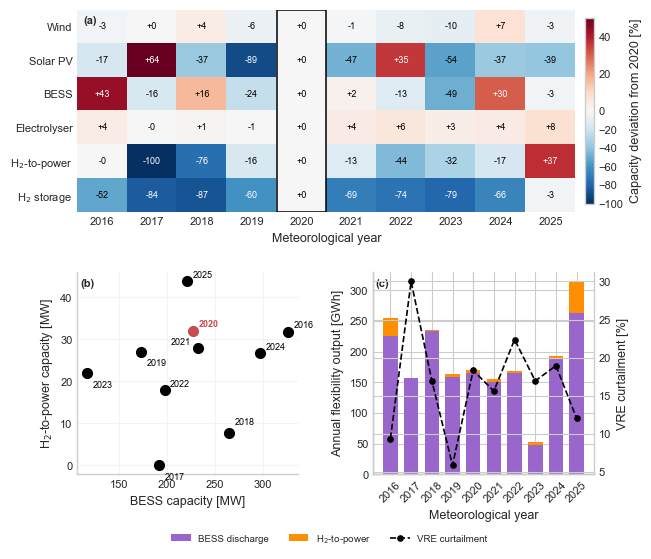

Saved Figure 10 to: output\output_punta_arenas\figures\figure10_ptx_weather_design_sensitivity_2050.svg

2050 weather-year sensitivity:


,minimum,maximum,2020
wind_mw,444.79,526.77,492.110974
solar_mw,46.58,709.60,432.917243
bess_power_mw,117.18,326.63,227.83275
electrolyser_mw,301.55,326.95,303.633924
h2_to_power_mw,0.00,43.75,31.934757
h2_store_gwh,0.73,5.42,5.417761
ptx_electricity_input_gwh,1807.16,1969.28,1831.784779
curtailment_share_pct,5.85,30.01,18.305148
slack_share_pct,0.00,0.00,0.0


In [ ]:
if not RUN_OPERATIONAL_SENSITIVITY:
    print('Operational/weather-design sensitivity disabled for the residential heat/subsidy study.')
else:
    # ─────────────────────────────────────────────────────────────────────────────
    # FIGURE 10 — Sensitivity of the PtX system design to meteorological year
    #
    # Uses the 10 × 4 PtX weather-year design sensitivity experiment.
    #
    # (a) 2050 capacity deviation relative to the 2020-weather design
    # (b) 2050 flexibility portfolio: BESS vs H2-to-power capacity
    # (c) Annual flexibility operation and VRE curtailment in 2050
    # ─────────────────────────────────────────────────────────────────────────────

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from pathlib import Path
    from matplotlib.gridspec import GridSpec
    from matplotlib.colors import TwoSlopeNorm
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch


    # ══════════════════════════════════════════════════════════════════════════════
    # 0. LOAD DATA
    # ══════════════════════════════════════════════════════════════════════════════

    FIG10_REFERENCE_WEATHER_YEAR = 2020


    fig10_data_path = (
        Path(OUTPUT_ROOT)
        / "ptx_weather_design_sensitivity"
        / "ptx_weather_design_2050.csv"
    )


    if (
        "ptx_weather_design_2050" in globals()
        and isinstance(
            ptx_weather_design_2050,
            pd.DataFrame,
        )
        and not ptx_weather_design_2050.empty
    ):

        fig10_df = (
            ptx_weather_design_2050
            .copy()
        )

    else:

        if not fig10_data_path.exists():

            raise FileNotFoundError(
                "Could not find the PtX weather-design sensitivity file:\n"
                f"{fig10_data_path.resolve()}"
            )

        fig10_df = pd.read_csv(
            fig10_data_path
        )


    fig10_df = (
        fig10_df
        .sort_values(
            "weather_year"
        )
        .reset_index(
            drop=True
        )
    )


    weather_years = (
        fig10_df[
            "weather_year"
        ]
        .astype(int)
        .tolist()
    )


    if (
        FIG10_REFERENCE_WEATHER_YEAR
        not in weather_years
    ):
        raise ValueError(
            f"Reference weather year "
            f"{FIG10_REFERENCE_WEATHER_YEAR} "
            "is missing from the sensitivity results."
        )


    # ══════════════════════════════════════════════════════════════════════════════
    # 1. RE-CALCULATE DEVIATIONS RELATIVE TO 2020
    #
    # Recalculate rather than relying on the saved delta columns.
    # ══════════════════════════════════════════════════════════════════════════════

    capacity_metrics = {
        "wind_mw":
            "Wind",

        "solar_mw":
            "Solar PV",

        "bess_power_mw":
            "BESS",

        "electrolyser_mw":
            "Electrolyser",

        "h2_to_power_mw":
            r"H$_2$-to-power",

        "h2_store_gwh":
            r"H$_2$ storage",
    }


    reference_row = (
        fig10_df.loc[
            fig10_df[
                "weather_year"
            ].eq(
                FIG10_REFERENCE_WEATHER_YEAR
            )
        ]
        .iloc[0]
    )


    delta_matrix = []

    for _, row in fig10_df.iterrows():

        row_values = []

        for metric in capacity_metrics:

            reference_value = float(
                reference_row[
                    metric
                ]
            )

            value = float(
                row[
                    metric
                ]
            )

            if abs(
                reference_value
            ) > 1e-9:

                delta = (
                    100.0
                    * (
                        value
                        - reference_value
                    )
                    / reference_value
                )

            else:
                delta = np.nan

            row_values.append(
                delta
            )

        delta_matrix.append(
            row_values
        )


    delta_matrix = np.asarray(
        delta_matrix,
        dtype=float,
    )


    # ══════════════════════════════════════════════════════════════════════════════
    # 2. COLOURS
    # ══════════════════════════════════════════════════════════════════════════════

    tech_colors_fig10 = (
        globals().get(
            "TECH_COLORS",
            {}
        )
    )


    bess_color = (
        tech_colors_fig10.get(
            "bess",
            "#8E6BBF",
        )
    )

    h2_color = (
        tech_colors_fig10.get(
            "h2_fuel_cell",
            "#2CA58D",
        )
    )

    reference_color = "#C44E52"


    # ══════════════════════════════════════════════════════════════════════════════
    # 3. FIGURE LAYOUT
    # ══════════════════════════════════════════════════════════════════════════════

    figure_width = globals().get(
        "WORD_DOUBLE_COL_IN",
        7.2,
    )


    fig = plt.figure(
        figsize=(
            figure_width,
            5.6,
        )
    )


    gs = GridSpec(
        2,
        2,
        figure=fig,
        height_ratios=[
            1.0,
            1.0,
        ],
        hspace=0.30,
        wspace=0.34,
    )


    ax_heat = fig.add_subplot(
        gs[0, :]
    )

    ax_portfolio = fig.add_subplot(
        gs[1, 0]
    )

    ax_operation = fig.add_subplot(
        gs[1, 1]
    )


    # ══════════════════════════════════════════════════════════════════════════════
    # 4. PANEL (a) — CAPACITY SENSITIVITY HEATMAP
    # ══════════════════════════════════════════════════════════════════════════════

    # Asymmetric limits are intentional:
    # reductions approach -100%, while positive deviations are smaller.
    norm = TwoSlopeNorm(
        vmin=-100,
        vcenter=0,
        vmax=50,
    )

    ax_heat.grid(False)
    ax_heat.tick_params(length=0)

    for spine in ax_heat.spines.values():
        spine.set_visible(False)

    im = ax_heat.imshow(
        delta_matrix.T,
        aspect="auto",
        cmap="RdBu_r",
        norm=norm,
    )


    ax_heat.set_xticks(
        np.arange(
            len(
                weather_years
            )
        )
    )

    ax_heat.set_xticklabels(
        weather_years
    )


    ax_heat.set_yticks(
        np.arange(
            len(
                capacity_metrics
            )
        )
    )

    ax_heat.set_yticklabels(
        list(
            capacity_metrics.values()
        )
    )


    ax_heat.set_xlabel(
        "Meteorological year"
    )

    ax_heat.set_ylabel(
        ""
    )


    # Annotate heatmap cells
    for metric_index in range(
        delta_matrix.shape[1]
    ):

        for year_index in range(
            delta_matrix.shape[0]
        ):

            value = (
                delta_matrix[
                    year_index,
                    metric_index,
                ]
            )

            if not np.isfinite(
                value
            ):
                continue

            # White text for strongly coloured cells
            text_color = (
                "white"
                if (
                    value < -55
                    or value > 30
                )
                else "black"
            )

            ax_heat.text(
                year_index,
                metric_index,
                f"{value:+.0f}",
                ha="center",
                va="center",
                fontsize=6.5,
                color=text_color,
            )


    # Highlight 2020 column
    reference_position = (
        weather_years.index(
            FIG10_REFERENCE_WEATHER_YEAR
        )
    )


    ax_heat.add_patch(
        plt.Rectangle(
            (
                reference_position - 0.5,
                -0.5,
            ),
            1.0,
            len(
                capacity_metrics
            ),
            fill=False,
            edgecolor="black",
            linewidth=1.1,
        )
    )


    colorbar = fig.colorbar(
        im,
        ax=ax_heat,
        fraction=0.018,
        pad=0.018,
    )


    colorbar.set_label(
        "Capacity deviation from 2020 [%]"
    )


    # ══════════════════════════════════════════════════════════════════════════════
    # 5. PANEL (b) — FLEXIBILITY PORTFOLIO
    # ══════════════════════════════════════════════════════════════════════════════

    # Manual offsets to reduce label overlap
    label_offsets = {
        2016: (4, 3),
        2017: (4, -10),
        2018: (4, 6),
        2019: (4, -10),
        2020: (4, 3),
        2021: (-20, 3),
        2022: (4, 3),
        2023: (4, -10),
        2024: (4, 3),
        2025: (4, 3),
    }

    for _, row in fig10_df.iterrows():

        weather_year = int(row["weather_year"])
        is_reference = (weather_year == FIG10_REFERENCE_WEATHER_YEAR)

        ax_portfolio.scatter(
            row["bess_power_mw"],
            row["h2_to_power_mw"],
            s=52,
            marker="o",
            facecolor=(reference_color if is_reference else "black"),
            edgecolor=(reference_color if is_reference else "black"),
            linewidth=0.8,
            zorder=3,
        )

        dx, dy = label_offsets.get(weather_year, (4, 3))

        ax_portfolio.annotate(
            str(weather_year),
            (row["bess_power_mw"], row["h2_to_power_mw"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=6.5,
            fontweight=("bold" if is_reference else "normal"),
            color=(reference_color if is_reference else "black"),
        )

    ax_portfolio.set_xlabel("BESS capacity [MW]")
    ax_portfolio.set_ylabel(r"H$_2$-to-power capacity [MW]")

    ax_portfolio.grid(alpha=0.22)
    ax_portfolio.set_axisbelow(True)


    # ══════════════════════════════════════════════════════════════════════════════
    # 6. PANEL (c) — FLEXIBILITY OPERATION + CURTAILMENT
    # ══════════════════════════════════════════════════════════════════════════════

    x = np.arange(
        len(
            weather_years
        )
    )


    bess_operation = (
        fig10_df[
            "bess_discharge_gwh"
        ]
        .to_numpy(
            dtype=float
        )
    )


    h2_operation = (
        fig10_df[
            "h2_to_power_gwh"
        ]
        .to_numpy(
            dtype=float
        )
    )


    curtailment = (
        fig10_df[
            "curtailment_share_pct"
        ]
        .to_numpy(
            dtype=float
        )
    )


    ax_operation.bar(
        x,
        bess_operation,
        width=0.70,
        color=bess_color,
        label="BESS discharge",
    )


    ax_operation.bar(
        x,
        h2_operation,
        width=0.70,
        bottom=bess_operation,
        color=h2_color,
        label=r"H$_2$-to-power",
    )


    ax_operation.set_xticks(
        x
    )

    ax_operation.set_xticklabels(
        weather_years,
        rotation=45,
    )


    ax_operation.set_xlabel(
        "Meteorological year"
    )

    ax_operation.set_ylabel(
        "Annual flexibility output [GWh]"
    )


    # Curtailment on secondary axis
    ax_curtailment = (
        ax_operation.twinx()
    )


    ax_curtailment.plot(
        x,
        curtailment,
        color="black",
        marker="o",
        markersize=3.8,
        linewidth=1.2,
        linestyle="--",
        label="VRE curtailment",
    )


    ax_curtailment.set_ylabel(
        "VRE curtailment [%]"
    )


    # Highlight 2020
    ax_operation.axvline(
        reference_position,
        color="0.35",
        linewidth=0.8,
        linestyle=":",
        zorder=0,
    )


    # ══════════════════════════════════════════════════════════════════════════════
    # 7. FORMATTING
    # ══════════════════════════════════════════════════════════════════════════════

    for ax in [
        ax_heat,
        ax_portfolio,
        ax_operation,
    ]:

        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )


    ax_curtailment.spines[
        "top"
    ].set_visible(
        False
    )


    # Panel labels
    for ax, label in zip(
        [
            ax_heat,
            ax_portfolio,
            ax_operation,
        ],
        [
            "(a)",
            "(b)",
            "(c)",
        ],
    ):

        ax.text(
            0.012,
            0.97,
            label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
            fontsize=8,
        )


    # Shared legend for panel (c)
    legend_handles = [
        Patch(
            facecolor=bess_color,
            edgecolor="none",
            label="BESS discharge",
        ),

        Patch(
            facecolor=h2_color,
            edgecolor="none",
            label=r"H$_2$-to-power",
        ),

        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            linestyle="--",
            linewidth=1.2,
            markersize=3.8,
            label="VRE curtailment",
        ),
    ]


    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(
            0.5,
            0.008,
        ),
        ncol=3,
        frameon=False,
        fontsize=7,
    )


    fig.subplots_adjust(
        left=0.10,
        right=0.92,
        top=0.98,
        bottom=0.15,
    )


    # ══════════════════════════════════════════════════════════════════════════════
    # 8. SAVE
    # ══════════════════════════════════════════════════════════════════════════════

    figure_filename = (
        "figure10_ptx_weather_design_sensitivity_2050.svg"
    )


    if callable(
        globals().get(
            "save_paper_figure"
        )
    ):

        figure10_path = (
            save_paper_figure(
                fig,
                figure_filename,
            )
        )

    else:

        figure10_path = (
            Path(OUTPUT_ROOT)
            / figure_filename
        )

        fig.savefig(
            figure10_path,
            dpi=300,
            bbox_inches="tight",
        )


    plt.show()


    print(
        f"Saved Figure 10 to: {figure10_path}"
    )


    # ══════════════════════════════════════════════════════════════════════════════
    # 9. QUICK NUMERICAL SUMMARY
    # ══════════════════════════════════════════════════════════════════════════════

    summary_metrics = [
        "wind_mw",
        "solar_mw",
        "bess_power_mw",
        "electrolyser_mw",
        "h2_to_power_mw",
        "h2_store_gwh",
        "ptx_electricity_input_gwh",
        "curtailment_share_pct",
        "slack_share_pct",
    ]


    summary_ranges = pd.DataFrame(
        {
            "minimum":
                fig10_df[
                    summary_metrics
                ].min(),

            "maximum":
                fig10_df[
                    summary_metrics
                ].max(),

            "2020":
                reference_row[
                    summary_metrics
                ],
        }
    )


    print(
        "\n2050 weather-year sensitivity:"
    )

    display(
        summary_ranges.round(2)
    )

## 11. Residential heat and gas-subsidy extension

This section **extends** the existing Punta Arenas workflow; it does not replace Sections 1–10.

The original scenario, cost, capacity, dispatch, curtailment, hydrogen/UHS, and weather-robustness analyses above remain available. The cells below add the residential thermal-demand and natural-gas-subsidy analysis required for the heat-transition study.

Final scope used here:

- residential sector only;
- useful thermal services: `space_heat` and `hot_water` (domestic hot water / ACS);
- cooking and non-residential gas uses are excluded from the thermal-demand model;
- the end-use split is created upstream in the demand-profile builder (currently 80.7% space heating and 7.7% domestic hot water of residential gas consumption), so **no end-use split is applied again in this notebook**;
- heat technologies and their eligible end uses are read from `heat_assets.csv`;
- technology costs and efficiencies are read from `costs.csv`;
- subsidy accounting is kept separate from the PyPSA objective unless a scenario-specific cost file explicitly changes the gas price used by the optimisation.

### 11.0 Policy scenarios and gas-cost assumptions

The residential heat extension uses four scenarios with **identical exogenous electricity, space-heating and DHW demand**.

| Scenario | Gas subsidy | Heat technologies | Reallocation policy |
|---|---|---|---|
| S1 `BAU_SUB` | Yes | Existing gas heating only | None |
| S2 `BAU_NOSUB` | No | Existing gas heating only | None |
| S3 `TRANS_SUB` | Yes | Gas + transition technologies | None |
| S4 `TRANS_NOSUB` | No | Gas + transition technologies | Former BAU gas-subsidy budget available for eligible clean investment |

The subsidy is treated consistently across the two modeled uses of natural gas:

1. **residential heat**, represented through the `natural_gas` fuel bus; and
2. **gas-fired electricity generation (GX)**, represented by OCGT/gas generators.

The recycled budget is calculated **year by year from `BAU_SUB` total modeled gas use**:

\[
B_y = \left(E^{gas,res}_y + E^{gas,GX}_y
ight)
      
rac{1000}{10.26}
      S_{gas},
\]

with the final currency conversion applied in the notebook. `BAU_NOSUB - BAU_SUB` remains a diagnostic comparison and is **not** used as the definition of public subsidy expenditure.

The current policy-accounting assumptions imply a gas subsidy of about **13.86 USD/MWh_fuel**. Therefore, the no-subsidy input files must remove the subsidy from both the residential-gas fuel cost and the OCGT/gas-generation cost. For the current OCGT proxy (55.596 USD/MWh_e, efficiency 0.38), applying the same subsidy intensity corresponds to about **92.08 USD/MWh_e** before any alternative non-subsidy cost evidence is introduced.

For S4, the generic model can use up to the BAU fiscal budget to cover **50% of the annualized capital cost of new eligible capacity**. Eligible technologies in the current sensitivity are wind, solar PV, BESS, heat pumps, heat-pump water heaters, electric boilers and electric water heaters. The budget is an upper bound, so unused public funds remain unused rather than forcing uneconomic investment.


In [34]:
# -----------------------------------------------------------------------------
# Residential heat / subsidy analysis controls
# -----------------------------------------------------------------------------
SUBSIDY_CASE_FOLDER = Path(case_folder)
OBSERVED_GAS_YEAR = 2025
SUBSIDY_RESULTS_YEAR = detailed_year
RESIDENTIAL_CITY = "punta_arenas"

SUBSIDY_OUTPUT_DIR = OUTPUT_ROOT / "subsidy_analysis"
SUBSIDY_TABLE_DIR = SUBSIDY_OUTPUT_DIR / "tables"
SUBSIDY_FIGURE_DIR = SUBSIDY_OUTPUT_DIR / "figures"
for _folder in (SUBSIDY_OUTPUT_DIR, SUBSIDY_TABLE_DIR, SUBSIDY_FIGURE_DIR):
    _folder.mkdir(parents=True, exist_ok=True)

# These shares are shown only for traceability/validation. They are NOT used
# to split model demand here; space_heat and hot_water must already exist as
# separate demand_type values in the demand-profile input.
REFERENCE_RESIDENTIAL_GAS_SHARES = {
    "space_heat": 0.807,
    "hot_water": 0.077,
}
REFERENCE_EXCLUDED_SHARE = 1.0 - sum(REFERENCE_RESIDENTIAL_GAS_SHARES.values())


def _first_existing(*candidates):
    for candidate in candidates:
        if candidate is None:
            continue
        path = Path(candidate)
        if path.exists():
            return path
    return None


GAS_HOURLY_FILE = _first_existing(
    SUBSIDY_CASE_FOLDER / "gas_hourly_by_sector.csv",
    SUBSIDY_CASE_FOLDER / "procesamiento_gas_natural" / "gas_hourly_by_sector.csv",
    Path("procesamiento_gas_natural") / "gas_hourly_by_sector.csv",
    Path("gas_hourly_by_sector.csv"),
)

# Prefer the standard combined demand file. If it is not available, use the
# electricity/heat scenario file associated with BAU_base as a read-only
# fallback for diagnostics.
DEMAND_PROFILE_FILE = _first_existing(
    SUBSIDY_CASE_FOLDER / "demand_profiles.csv",
    SUBSIDY_CASE_FOLDER / "demand_profiles_scenarios" / "demand_profiles_BAU_base.csv",
)

HEAT_ASSETS_FILE = _first_existing(
    SUBSIDY_CASE_FOLDER / "heat_assets.csv",
    Path("heat_assets.csv"),
)

COSTS_FILE = _first_existing(
    SUBSIDY_CASE_FOLDER / "costs.csv",
    Path("costs.csv"),
)

SUBSIDY_ASSUMPTIONS_FILE = _first_existing(
    SUBSIDY_CASE_FOLDER / "gas_subsidy.csv",
    SUBSIDY_CASE_FOLDER / "subsidy.csv",
    Path("gas_subsidy.csv"),
)

subsidy_input_catalog = pd.DataFrame(
    [
        ("hourly gas by sector", GAS_HOURLY_FILE),
        ("combined demand profiles", DEMAND_PROFILE_FILE),
        ("heat assets", HEAT_ASSETS_FILE),
        ("technology costs", COSTS_FILE),
        ("gas subsidy assumptions", SUBSIDY_ASSUMPTIONS_FILE),
    ],
    columns=["input", "path"],
)
subsidy_input_catalog["available"] = subsidy_input_catalog["path"].notna()
display(subsidy_input_catalog)
print("Reference residential-gas shares:", REFERENCE_RESIDENTIAL_GAS_SHARES)
print(f"Excluded residential gas share: {REFERENCE_EXCLUDED_SHARE:.1%}")

,input,path,available
0,hourly gas by sector,None,False
1,combined demand profiles,input_punta_arenas_2\demand_profiles.csv,True
2,heat assets,input_punta_arenas_2\heat_assets.csv,True
3,technology costs,input_punta_arenas_2\costs.csv,True
4,gas subsidy assumptions,None,False


Reference residential-gas shares: {'space_heat': 0.807, 'hot_water': 0.077}
Excluded residential gas share: 11.6%


### 11.1 Residential gas and useful-heat demand

The gas preprocessing is treated as an upstream data step. This section reads its hourly output and the combined model demand profiles, retains only the residential sector, and checks that the thermal services entering PyPSA are `space_heat` and `hot_water`.

No 80.7/7.7 split is performed below: the model input should already contain those two useful-demand time series.

In [35]:
def _normalise_text(series):
    return series.astype(str).str.strip().str.lower()


def load_residential_gas(path, city=RESIDENTIAL_CITY):
    if path is None:
        return pd.DataFrame()

    df = pd.read_csv(path)
    required = {"timestamp", "gas_m3"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path}: missing required columns {sorted(missing)}")

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["gas_m3"] = pd.to_numeric(df["gas_m3"], errors="coerce")
    df = df.dropna(subset=["timestamp", "gas_m3"]).copy()

    commune_col = "commune" if "commune" in df.columns else ("comuna" if "comuna" in df.columns else None)
    if commune_col is not None:
        df[commune_col] = _normalise_text(df[commune_col])
        city_key = str(city).strip().lower()
        df = df[df[commune_col].eq(city_key)].copy()

    if "sector" not in df.columns:
        raise ValueError(f"{path}: residential-only analysis requires a 'sector' column.")

    sector_norm = _normalise_text(df["sector"])
    residential_mask = sector_norm.str.contains("resid", regex=False, na=False)
    if not residential_mask.any():
        raise ValueError(
            f"{path}: no residential sector was identified. "
            f"Observed sector labels: {sorted(df['sector'].dropna().astype(str).unique())}"
        )

    df = df.loc[residential_mask].copy()
    df["sector"] = "residential"
    return df.sort_values("timestamp").reset_index(drop=True)


def load_thermal_demand_profiles(path):
    if path is None:
        return pd.DataFrame()

    df = pd.read_csv(path)
    required = {"timestamp", "demand_type", "demand_mw"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path}: missing required columns {sorted(missing)}")

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["demand_type"] = _normalise_text(df["demand_type"])
    df["demand_mw"] = pd.to_numeric(df["demand_mw"], errors="coerce")
    df = df.dropna(subset=["timestamp", "demand_mw"]).copy()

    thermal_types = {"space_heat", "hot_water"}
    available_types = set(df["demand_type"].dropna())
    unexpected_thermal = sorted(
        t for t in available_types
        if t not in {"electricity", *thermal_types}
    )

    heat = df[df["demand_type"].isin(thermal_types)].copy()

    if heat.empty:
        raise ValueError(
            f"{path}: no space_heat/hot_water demand was found. "
            f"Available demand_type values: {sorted(available_types)}"
        )

    print("Thermal demand types used:", sorted(heat["demand_type"].unique()))
    if unexpected_thermal:
        print(
            "Additional demand_type values are present but are not included in "
            "this residential-heat analysis:",
            unexpected_thermal,
        )

    return heat.sort_values("timestamp").reset_index(drop=True)


residential_gas = load_residential_gas(GAS_HOURLY_FILE)
thermal_demand = load_thermal_demand_profiles(DEMAND_PROFILE_FILE)

gas_summary = pd.DataFrame()
if not residential_gas.empty:
    gas_summary = (
        residential_gas
        .assign(year=residential_gas["timestamp"].dt.year)
        .groupby("year", as_index=False)["gas_m3"].sum()
        .rename(columns={"gas_m3": "residential_gas_m3"})
    )
    display(gas_summary)

heat_summary = pd.DataFrame()
if not thermal_demand.empty:
    heat_summary = (
        thermal_demand
        .assign(year=thermal_demand["timestamp"].dt.year)
        .groupby(["year", "demand_type"], as_index=False)["demand_mw"].sum()
        .rename(columns={"demand_mw": "useful_heat_mwh"})
    )
    display(heat_summary)

if not gas_summary.empty:
    gas_summary.to_csv(SUBSIDY_TABLE_DIR / "residential_gas_by_year.csv", index=False)
if not heat_summary.empty:
    heat_summary.to_csv(SUBSIDY_TABLE_DIR / "useful_heat_by_end_use_and_year.csv", index=False)

Thermal demand types used: ['hot_water', 'space_heat']


,year,demand_type,useful_heat_mwh
0,2025,hot_water,1.316492e+05
1,2025,space_heat,1.681572e+06
2,2030,hot_water,1.316492e+05
3,2030,space_heat,1.681572e+06
4,2040,hot_water,1.316492e+05
5,2040,space_heat,1.681572e+06
6,2050,hot_water,1.316492e+05
7,2050,space_heat,1.681572e+06


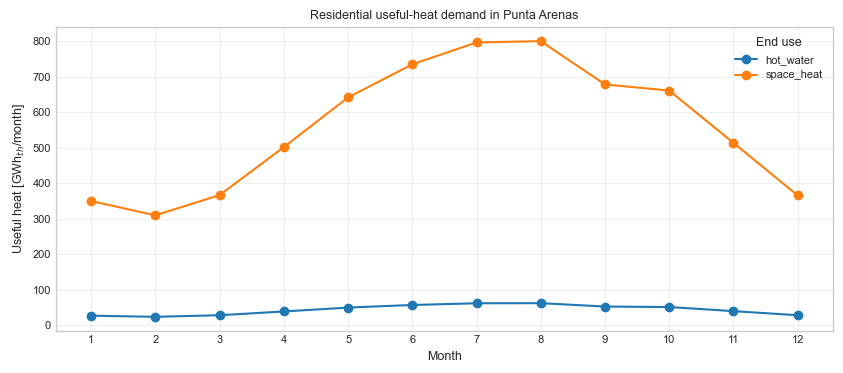

In [36]:
# Optional diagnostic figure: seasonal useful-heat demand.
# This is an input-characterisation figure, not intended to replace the
# system-cost/capacity/dispatch figures in the main Punta Arenas analysis.

if not thermal_demand.empty:
    _heat_plot = thermal_demand.copy()
    _heat_plot["month"] = _heat_plot["timestamp"].dt.month

    _monthly = (
        _heat_plot
        .groupby(["month", "demand_type"])["demand_mw"]
        .sum()
        .unstack(fill_value=0.0)
        / 1e3
    )

    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    _monthly.plot(ax=ax, marker="o")
    ax.set_xlabel("Month")
    ax.set_ylabel("Useful heat [GWh$_{th}$/month]")
    ax.set_title("Residential useful-heat demand in Punta Arenas")
    ax.set_xticks(range(1, 13))
    ax.grid(True, alpha=0.3)
    ax.legend(title="End use")
    plt.tight_layout()

    fig.savefig(
        SUBSIDY_FIGURE_DIR / "residential_heat_monthly_profiles.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

### 11.2 Heat technologies and subsidy assumptions

`heat_assets.csv` defines which conversion technologies can satisfy each thermal service. `costs.csv` remains the economic source of truth. The optional subsidy table is used only for policy accounting unless a scenario-specific `costs_<scenario>.csv` deliberately changes the gas price seen by the optimiser.

The subsidy table may provide either:

- `subsidy_clp_per_m3`; or
- `reference_price_clp_per_mwh` and `paid_price_clp_per_mwh`, together with a documented gas-energy conversion.

In [37]:
def _read_csv_optional(path):
    if path is None:
        return pd.DataFrame()
    return pd.read_csv(path)


heat_assets_subsidy = _read_csv_optional(HEAT_ASSETS_FILE)
costs_subsidy = _read_csv_optional(COSTS_FILE)
gas_subsidy_assumptions = _read_csv_optional(SUBSIDY_ASSUMPTIONS_FILE)

if not heat_assets_subsidy.empty:
    _ha = heat_assets_subsidy.copy()
    if "enabled" in _ha.columns:
        _ha = _ha[_ha["enabled"].astype(str).str.strip().str.lower().isin({"true", "1", "yes", "y", "t"})]
    if "end_use" in _ha.columns:
        _ha["end_use"] = _normalise_text(_ha["end_use"])
        _ha = _ha[_ha["end_use"].isin({"space_heat", "hot_water"})].copy()

    _show_cols = [
        c for c in [
            "asset_id", "zone", "technology", "input_carrier", "end_use",
            "installed_capacity_mw", "capacity_basis", "cost_key",
            "available_from_year", "commissioning_type", "enabled",
        ]
        if c in _ha.columns
    ]
    print("Enabled residential heat assets:")
    display(_ha[_show_cols] if _show_cols else _ha)

if not costs_subsidy.empty and not heat_assets_subsidy.empty:
    _keys = set()
    if "cost_key" in heat_assets_subsidy.columns:
        _keys |= set(heat_assets_subsidy["cost_key"].dropna().astype(str))
    if "input_carrier" in heat_assets_subsidy.columns:
        _keys |= set(heat_assets_subsidy["input_carrier"].dropna().astype(str))

    if "cost_key" in costs_subsidy.columns:
        _hc = costs_subsidy[costs_subsidy["cost_key"].astype(str).isin(_keys)].copy()
        _cols = [
            c for c in [
                "cost_key", "technology", "year", "capex", "capital_cost",
                "marginal_cost", "efficiency", "lifetime_years", "source",
                "source_url", "notes",
            ]
            if c in _hc.columns
        ]
        print("Cost rows used by residential heat assets / fuels:")
        display(_hc[_cols] if _cols else _hc)

if gas_subsidy_assumptions.empty:
    print(
        "No gas subsidy assumption table found yet. "
        "Heat/capacity/dispatch analysis can still run; monetary subsidy accounting will be skipped."
    )
else:
    display(gas_subsidy_assumptions)

Enabled residential heat assets:


,asset_id,zone,technology,input_carrier,end_use,installed_capacity_mw,capacity_basis,cost_key,available_from_year,commissioning_type,enabled
0,gas_boiler_space_pa,punta_arenas_centro,gas_boiler,natural_gas,space_heat,16.8,output,gas_boiler_existing,2025,fixed,True
1,gas_water_heater_pa,punta_arenas_centro,gas_water_heater,natural_gas,hot_water,8.4,output,gas_water_heater_existing,2025,fixed,True
3,heat_pump_space_pa,punta_arenas_centro,heat_pump,electricity,space_heat,0.0,output,heat_pump,2030,flexible,True
4,heat_pump_water_pa,punta_arenas_centro,heat_pump_water_heater,electricity,hot_water,0.0,output,heat_pump_water_heater,2030,flexible,True
5,electric_boiler_space_pa,punta_arenas_centro,electric_boiler,electricity,space_heat,0.0,output,electric_boiler,2030,flexible,True
6,electric_water_heater_pa,punta_arenas_centro,electric_water_heater,electricity,hot_water,0.0,output,electric_boiler,2030,flexible,True
8,biogas_boiler_space_pa,punta_arenas_centro,biogas_boiler,biogas,space_heat,0.0,output,gas_boiler,2030,flexible,True
11,pellet_boiler_space_pa,punta_arenas_centro,pellet_boiler,pellets,space_heat,0.0,output,pellet_boiler,2030,flexible,True


Cost rows used by residential heat assets / fuels:


,cost_key,technology,year,capex,marginal_cost,efficiency,lifetime_years,source,source_url,notes
36,natural_gas,natural_gas,2025,NaN,15.596,1.000,NaN,Derived from CNE SSMM Magallanes 2025 CVC,https://www.cne.cl/wp-content/uploads/2022/12/...,Current numeric value retained unchanged: 15.5...
37,natural_gas,natural_gas,2030,NaN,15.596,1.000,NaN,Derived from CNE SSMM Magallanes 2025 CVC,https://www.cne.cl/wp-content/uploads/2022/12/...,Current numeric value retained unchanged: 15.5...
38,natural_gas,natural_gas,2040,NaN,15.596,1.000,NaN,Derived from CNE SSMM Magallanes 2025 CVC,https://www.cne.cl/wp-content/uploads/2022/12/...,Current numeric value retained unchanged: 15.5...
39,natural_gas,natural_gas,2050,NaN,15.596,1.000,NaN,Derived from CNE SSMM Magallanes 2025 CVC,https://www.cne.cl/wp-content/uploads/2022/12/...,Current numeric value retained unchanged: 15.5...
40,heat_pump,heat_pump,2025,4730886.371,0.000,3.500,18.0,PyPSA technology-data v0.15.0; underlying Dani...,https://raw.githubusercontent.com/PyPSA/techno...,Source investment 1195.5438 EUR/kW_th converte...
41,gas_boiler,gas_boiler,2025,448304.653,0.000,0.975,20.0,PyPSA technology-data v0.15.0; underlying Dani...,https://raw.githubusercontent.com/PyPSA/techno...,Source investment 406.6864 EUR/kW_th converted...
42,heat_pump,heat_pump,2030,4621392.351,0.000,3.600,18.0,PyPSA technology-data v0.15.0; underlying Dani...,https://raw.githubusercontent.com/PyPSA/techno...,Source investment 1135.4326 EUR/kW_th converte...
43,gas_boiler,gas_boiler,2030,439312.588,0.000,0.980,20.0,PyPSA technology-data v0.15.0; underlying Dani...,https://raw.githubusercontent.com/PyPSA/techno...,Source investment 396.4958 EUR/kW_th converted...
44,heat_pump,heat_pump,2040,4498306.405,0.000,3.700,18.0,PyPSA technology-data v0.15.0; underlying Dani...,https://raw.githubusercontent.com/PyPSA/techno...,Source investment 1075.3215 EUR/kW_th converte...
45,gas_boiler,gas_boiler,2040,420494.248,0.000,0.985,20.0,PyPSA technology-data v0.15.0; underlying Dani...,https://raw.githubusercontent.com/PyPSA/techno...,Source investment 377.5851 EUR/kW_th converted...


No gas subsidy assumption table found yet. Heat/capacity/dispatch analysis can still run; monetary subsidy accounting will be skipped.


In [38]:
def estimate_residential_subsidy(
    residential_gas_df,
    subsidy_df,
    year=OBSERVED_GAS_YEAR,
    gas_kwh_per_m3=None,
):
    """
    Estimate observed residential-gas subsidy for one year.

    Accepted subsidy conventions:
      1) subsidy_clp_per_m3
      2) reference_price_clp_per_mwh - paid_price_clp_per_mwh,
         which additionally requires gas_kwh_per_m3.
    """
    if residential_gas_df.empty or subsidy_df.empty:
        return pd.DataFrame()

    gas = residential_gas_df[
        residential_gas_df["timestamp"].dt.year.eq(int(year))
    ].copy()
    if gas.empty:
        return pd.DataFrame()

    volume_m3 = float(gas["gas_m3"].sum())

    assumptions = subsidy_df.copy()
    if "year" in assumptions.columns:
        assumptions["year"] = pd.to_numeric(assumptions["year"], errors="coerce")
        assumptions = assumptions[
            assumptions["year"].isna() | assumptions["year"].eq(int(year))
        ].copy()

    if "sector" in assumptions.columns:
        _sec = assumptions["sector"].astype(str).str.strip().str.lower()
        _res = _sec.str.contains("resid", regex=False, na=False)
        if _res.any():
            assumptions = assumptions.loc[_res].copy()

    if assumptions.empty:
        return pd.DataFrame()

    row = assumptions.iloc[0]
    result = {
        "year": int(year),
        "residential_gas_m3": volume_m3,
        "subsidy_clp": np.nan,
        "subsidy_basis": None,
    }

    if "subsidy_clp_per_m3" in assumptions.columns and pd.notna(row["subsidy_clp_per_m3"]):
        intensity = float(row["subsidy_clp_per_m3"])
        result["subsidy_clp"] = volume_m3 * intensity
        result["subsidy_basis"] = "CLP/m3"
        result["subsidy_clp_per_m3"] = intensity

    elif {
        "reference_price_clp_per_mwh",
        "paid_price_clp_per_mwh",
    }.issubset(assumptions.columns):
        if gas_kwh_per_m3 is None:
            print(
                "Subsidy prices are expressed per MWh, but gas_kwh_per_m3 was not supplied. "
                "Monetary subsidy is left undefined rather than assuming a conversion factor."
            )
        else:
            ref_price = float(row["reference_price_clp_per_mwh"])
            paid_price = float(row["paid_price_clp_per_mwh"])
            gas_mwh = volume_m3 * float(gas_kwh_per_m3) / 1000.0
            result["gas_mwh_fuel"] = gas_mwh
            result["subsidy_clp"] = gas_mwh * (ref_price - paid_price)
            result["subsidy_basis"] = "CLP/MWh_fuel price gap"

    return pd.DataFrame([result])


# Deliberately left None unless the subsidy table itself already uses CLP/m3.
# If you use CLP/MWh prices, pass the documented gas conversion here.
GAS_KWH_PER_M3_FOR_SUBSIDY = None

observed_residential_subsidy = estimate_residential_subsidy(
    residential_gas,
    gas_subsidy_assumptions,
    year=OBSERVED_GAS_YEAR,
    gas_kwh_per_m3=GAS_KWH_PER_M3_FOR_SUBSIDY,
)

if not observed_residential_subsidy.empty:
    display(observed_residential_subsidy)
    observed_residential_subsidy.to_csv(
        SUBSIDY_TABLE_DIR / "observed_residential_gas_subsidy.csv",
        index=False,
    )

### 11.3 Heat supply, heat capacity, and energy inputs from the PyPSA results

This analysis uses the **same exported scenario results loaded in Section 4**. Heat technologies are discovered from `heat_assets.csv` and/or from links delivering to `space_heat_*` and `hot_water_*` buses, so adding another technology does not require editing a hardcoded technology list in this notebook.

In [39]:
def _as_dataframe(table):
    if table is None:
        return pd.DataFrame()
    if hasattr(table, "load") and callable(table.load):
        return table.load()
    if isinstance(table, pd.DataFrame):
        return table.copy()
    return pd.DataFrame(table)


def _snapshot_objective_weights(net, index):
    try:
        weights = _as_dataframe(net.snapshot_weightings)
    except Exception:
        weights = pd.DataFrame()

    if not weights.empty and "objective" in weights.columns:
        w = pd.to_numeric(weights["objective"], errors="coerce").reindex(index)
        return w.fillna(1.0)

    return pd.Series(1.0, index=index)


def _heat_link_mask(net, links, heat_assets_table=None):
    if links.empty:
        return pd.Series(False, index=links.index)

    mask = pd.Series(False, index=links.index)
    service_prefixes = ("space_heat_", "hot_water_")

    if "bus1" in links.columns:
        mask |= links["bus1"].astype(str).str.startswith(service_prefixes)

    if heat_assets_table is not None and not heat_assets_table.empty and "technology" in heat_assets_table.columns:
        techs = set(heat_assets_table["technology"].dropna().astype(str).str.strip().str.lower())
        if "carrier" in links.columns:
            mask |= links["carrier"].astype(str).str.strip().str.lower().isin(techs)

    return mask


def extract_heat_results_from_network(net, scenario, year, heat_assets_table=None):
    links = _as_dataframe(net.links)
    buses = _as_dataframe(net.buses)

    if links.empty:
        return pd.DataFrame()

    heat_mask = _heat_link_mask(net, links, heat_assets_table)
    heat_links = links.loc[heat_mask].copy()
    if heat_links.empty:
        return pd.DataFrame()

    try:
        p0 = _as_dataframe(net.links_t.p0)
    except Exception:
        p0 = pd.DataFrame(index=getattr(net, "snapshots", []))
    try:
        p1 = _as_dataframe(net.links_t.p1)
    except Exception:
        p1 = pd.DataFrame(index=p0.index)

    idx = p0.index if not p0.empty else p1.index
    weights = _snapshot_objective_weights(net, idx)

    bus_carrier = {}
    if not buses.empty and "carrier" in buses.columns:
        bus_carrier = buses["carrier"].astype(str).to_dict()

    rows = []
    for link_id, row in heat_links.iterrows():
        carrier = str(row.get("carrier", row.get("technology", link_id)))
        bus0 = str(row.get("bus0", ""))
        bus1 = str(row.get("bus1", ""))
        input_carrier = bus_carrier.get(bus0, bus0.split("_")[0] if bus0 else "")

        inp = (
            pd.to_numeric(p0[link_id], errors="coerce").clip(lower=0)
            if link_id in p0.columns
            else pd.Series(0.0, index=idx)
        )
        out = (
            pd.to_numeric(p1[link_id], errors="coerce").abs()
            if link_id in p1.columns
            else pd.Series(0.0, index=idx)
        )

        p_nom = row.get("p_nom_opt", np.nan)
        if pd.isna(p_nom):
            p_nom = row.get("p_nom", 0.0)
        p_nom = float(pd.to_numeric(pd.Series([p_nom]), errors="coerce").fillna(0.0).iloc[0])

        efficiency = float(
            pd.to_numeric(pd.Series([row.get("efficiency", 1.0)]), errors="coerce")
            .fillna(1.0)
            .iloc[0]
        )

        end_use = (
            "space_heat"
            if bus1.startswith("space_heat_")
            else "hot_water"
            if bus1.startswith("hot_water_")
            else "other"
        )

        rows.append(
            {
                "scenario": scenario,
                "year": int(year),
                "link": str(link_id),
                "technology": carrier,
                "end_use": end_use,
                "input_carrier": input_carrier,
                "capacity_input_mw": p_nom,
                "capacity_output_mw": p_nom * efficiency,
                "input_mwh": float((inp.reindex(weights.index, fill_value=0.0) * weights).sum()),
                "useful_heat_mwh": float((out.reindex(weights.index, fill_value=0.0) * weights).sum()),
            }
        )

    return pd.DataFrame(rows)


_heat_rows = []
for _scenario, _package in scenario_results.items():
    for _year, _result in _package["results"].items():
        _summary = extract_heat_results_from_network(
            _result["network"],
            scenario=_scenario,
            year=_year,
            heat_assets_table=heat_assets_subsidy,
        )
        if not _summary.empty:
            _heat_rows.append(_summary)

model_heat_results = (
    pd.concat(_heat_rows, ignore_index=True)
    if _heat_rows
    else pd.DataFrame()
)

if model_heat_results.empty:
    print(
        "No residential heat-conversion links were found in the currently loaded result bundles. "
        "Run the scenarios with enable_heat=True and heat-enabled demand profiles, then reload Section 4."
    )
else:
    display(model_heat_results.head(20))
    model_heat_results.to_csv(
        SUBSIDY_TABLE_DIR / "model_heat_supply_capacity_and_inputs.csv",
        index=False,
    )

,scenario,year,link,technology,end_use,input_carrier,capacity_input_mw,capacity_output_mw,input_mwh,useful_heat_mwh
0,BAU_SUB,2025,gas_boiler_space_pa,gas_boiler,space_heat,natural_gas,390.769231,381.0,1.724689e+06,1.681572e+06
1,BAU_SUB,2025,gas_water_heater_pa,gas_water_heater,hot_water,natural_gas,37.500000,30.0,1.645615e+05,1.316492e+05
2,BAU_SUB,2050,gas_boiler_space_pa,gas_boiler,space_heat,natural_gas,390.769231,381.0,1.724689e+06,1.681572e+06
3,BAU_SUB,2050,gas_water_heater_pa,gas_water_heater,hot_water,natural_gas,37.500000,30.0,1.645615e+05,1.316492e+05
4,BAU_NOSUB,2025,gas_boiler_space_pa,gas_boiler,space_heat,natural_gas,390.769231,381.0,1.724689e+06,1.681572e+06
5,BAU_NOSUB,2025,gas_water_heater_pa,gas_water_heater,hot_water,natural_gas,37.500000,30.0,1.645615e+05,1.316492e+05
6,BAU_NOSUB,2050,gas_boiler_space_pa,gas_boiler,space_heat,natural_gas,390.769231,381.0,1.724689e+06,1.681572e+06
7,BAU_NOSUB,2050,gas_water_heater_pa,gas_water_heater,hot_water,natural_gas,37.500000,30.0,1.645615e+05,1.316492e+05
8,TRANS_SUB,2025,gas_boiler_space_pa,gas_boiler,space_heat,natural_gas,390.769231,381.0,1.724689e+06,1.681572e+06
9,TRANS_SUB,2025,gas_water_heater_pa,gas_water_heater,hot_water,natural_gas,37.500000,30.0,1.645615e+05,1.316492e+05


In [40]:
if not model_heat_results.empty:
    model_heat_summary = (
        model_heat_results
        .groupby(["scenario", "year", "technology", "end_use", "input_carrier"], as_index=False)
        .agg(
            capacity_input_mw=("capacity_input_mw", "sum"),
            capacity_output_mw=("capacity_output_mw", "sum"),
            input_mwh=("input_mwh", "sum"),
            useful_heat_mwh=("useful_heat_mwh", "sum"),
        )
    )

    display(
        model_heat_summary[
            model_heat_summary["year"].eq(SUBSIDY_RESULTS_YEAR)
        ].round(3)
    )

    model_heat_summary.to_csv(
        SUBSIDY_TABLE_DIR / "heat_summary_by_scenario_year.csv",
        index=False,
    )
else:
    model_heat_summary = pd.DataFrame()

,scenario,year,technology,end_use,input_carrier,capacity_input_mw,capacity_output_mw,input_mwh,useful_heat_mwh
2,BAU_NOSUB,2050,gas_boiler,space_heat,natural_gas,390.769,381.000,1724689.493,1681572.256
3,BAU_NOSUB,2050,gas_water_heater,hot_water,natural_gas,37.500,30.000,164561.451,131649.161
6,BAU_SUB,2050,gas_boiler,space_heat,natural_gas,390.769,381.000,1724689.493,1681572.256
7,BAU_SUB,2050,gas_water_heater,hot_water,natural_gas,37.500,30.000,164561.451,131649.161
10,TRANS_NOSUB,2050,biogas_boiler,space_heat,biogas,0.000,0.000,0.000,0.000
11,TRANS_NOSUB,2050,electric_boiler,space_heat,electricity,80.409,72.369,116697.552,105027.797
12,TRANS_NOSUB,2050,electric_water_heater,hot_water,electricity,8.628,7.765,21425.652,19283.087
13,TRANS_NOSUB,2050,gas_boiler,space_heat,natural_gas,390.769,381.000,626802.636,611132.570
14,TRANS_NOSUB,2050,gas_water_heater,hot_water,natural_gas,37.500,30.000,50809.022,40647.217
15,TRANS_NOSUB,2050,heat_pump,space_heat,electricity,31.207,118.587,254055.760,965411.889


### 11.4 Recommended results figure for the extended abstract

For the extended abstract, use the **2050 policy comparison below** rather than the generic supplementary 2×2 decomposition. It is the most direct figure for the paper question because it combines:

- **costs with and without subsidy/reallocation**;
- **natural-gas use split between residential heat and electricity generation**;
- **residential heat capacity by technology**; and
- **whole-system electricity dispatch**.

Panel (a) shows the model objective together with public gas-subsidy and clean-investment support, so the fiscal transfer is visible instead of being hidden inside scenario-specific fuel or investment costs. Panel (b) uses total modeled gas consumption, consistent with the reallocation budget.

The figure is formatted for a two-column paper width and saves both the new publication filename and the previous filename for backward compatibility.


In [41]:
# Main comparison used in the subsidy paper
SUBSIDY_COMPARISON_SCENARIOS = [
    "BAU_SUB",
    "BAU_NOSUB",
    "TRANS_SUB",
    "TRANS_NOSUB",
]


def build_heat_policy_summary(
    scenario_results_catalogue,
    heat_summary,
    year=SUBSIDY_RESULTS_YEAR,
    subsidy_clp_per_m3=None,
    gas_kwh_per_m3=None,
    clp_per_usd=None,
):
    """Build policy-accounting quantities for the four subsidy scenarios."""
    rows = []

    for scenario, package in scenario_results_catalogue.items():
        if year not in package["results"]:
            continue

        result = package["results"][year]
        objective = pd.to_numeric(
            pd.Series([result.get("objective", np.nan)]),
            errors="coerce",
        ).iloc[0]

        metadata = package.get("metadata", {})
        row = {
            "scenario": scenario,
            "paper_id": metadata.get("paper_id", ""),
            "year": int(year),
            "gas_subsidized": gas_subsidized_in_year(metadata, year),
            "model_system_cost": float(objective) if pd.notna(objective) else np.nan,
        }

        hs = (
            heat_summary[
                heat_summary["scenario"].eq(scenario)
                & heat_summary["year"].eq(year)
            ].copy()
            if not heat_summary.empty
            else pd.DataFrame()
        )

        row["residential_heat_mwh"] = (
            float(hs["useful_heat_mwh"].sum()) if not hs.empty else 0.0
        )
        row["heat_capacity_output_mw"] = (
            float(hs["capacity_output_mw"].sum()) if not hs.empty else 0.0
        )

        # Use the same gas-accounting helpers as the simulation-stage budget.
        gas = _total_natural_gas_input_mwh(result)
        row["residential_gas_input_mwh"] = gas["residential_gas_input_mwh"]
        row["generation_gas_input_mwh"] = gas["generation_gas_input_mwh"]
        row["total_gas_input_mwh"] = gas["total_gas_input_mwh"]

        if not hs.empty:
            elec_input = hs.loc[
                hs["input_carrier"].astype(str).str.lower().eq("electricity"),
                "input_mwh",
            ].sum()
        else:
            elec_input = 0.0

        row["electricity_for_heat_mwh"] = float(elec_input)
        row["clean_support_budget_usd"] = float(
            result.get("investment_support_budget_usd_per_year", 0.0) or 0.0
        )
        row["clean_support_fraction"] = float(
            result.get("investment_support_fraction", 0.0) or 0.0
        )
        row["public_clean_support_usd"] = float(
            result.get("investment_support_used_usd_per_year", 0.0) or 0.0
        )
        row["unused_clean_support_budget_usd"] = float(
            result.get("investment_support_unused_usd_per_year", 0.0) or 0.0
        )

        if (
            subsidy_clp_per_m3 is not None
            and gas_kwh_per_m3 is not None
            and float(gas_kwh_per_m3) > 0
        ):
            residential_gas_m3 = (
                row["residential_gas_input_mwh"]
                * 1000.0
                / float(gas_kwh_per_m3)
            )
            generation_gas_m3 = (
                row["generation_gas_input_mwh"]
                * 1000.0
                / float(gas_kwh_per_m3)
            )
            total_gas_m3 = residential_gas_m3 + generation_gas_m3

            row["residential_gas_m3"] = residential_gas_m3
            row["generation_gas_m3"] = generation_gas_m3
            row["total_gas_m3"] = total_gas_m3
            row["public_subsidy_clp"] = (
                total_gas_m3 * float(subsidy_clp_per_m3)
                if row["gas_subsidized"]
                else 0.0
            )

            if clp_per_usd is not None and float(clp_per_usd) > 0:
                row["public_subsidy_usd"] = (
                    row["public_subsidy_clp"] / float(clp_per_usd)
                )
                row["public_gas_subsidy_usd"] = row["public_subsidy_usd"]

        row.setdefault("public_subsidy_usd", 0.0)
        row.setdefault("public_gas_subsidy_usd", row["public_subsidy_usd"])

        row["total_public_support_usd"] = (
            float(row["public_gas_subsidy_usd"])
            + float(row["public_clean_support_usd"])
        )

        # Accounting indicator: the model objective is net of whichever policy
        # support is active. Adding public support makes the fiscal transfer
        # explicit for cross-scenario comparison.
        row["system_cost_plus_public_support_usd"] = (
            row["model_system_cost"]
            + row["total_public_support_usd"]
        )
        row["system_cost_plus_public_subsidy_usd"] = (
            row["system_cost_plus_public_support_usd"]
        )

        rows.append(row)

    return pd.DataFrame(rows)


# Policy-accounting assumptions are defined once in Section 2 and reused here.
heat_policy_summary = build_heat_policy_summary(
    scenario_results,
    model_heat_summary,
    year=SUBSIDY_RESULTS_YEAR,
    subsidy_clp_per_m3=GAS_SUBSIDY_CLP_PER_M3,
    gas_kwh_per_m3=GAS_KWH_PER_M3_FOR_POLICY_ACCOUNTING,
    clp_per_usd=CLP_PER_USD_FOR_POLICY_ACCOUNTING,
)

display(heat_policy_summary.round(3))
heat_policy_summary.to_csv(
    SUBSIDY_TABLE_DIR / f"heat_policy_summary_{SUBSIDY_RESULTS_YEAR}.csv",
    index=False,
)


,scenario,paper_id,year,gas_subsidized,model_system_cost,residential_heat_mwh,heat_capacity_output_mw,residential_gas_input_mwh,generation_gas_input_mwh,total_gas_input_mwh,...,unused_clean_support_budget_usd,residential_gas_m3,generation_gas_m3,total_gas_m3,public_subsidy_clp,public_subsidy_usd,public_gas_subsidy_usd,total_public_support_usd,system_cost_plus_public_support_usd,system_cost_plus_public_subsidy_usd
0,BAU_SUB,S1,2050,True,4.466255e+07,1813221.417,411.000,1889250.944,599085.192,2488336.136,...,0.000,1.841375e+08,5.839037e+07,2.425279e+08,3.281262e+10,3.449425e+07,3.449425e+07,3.449425e+07,7.915680e+07,7.915680e+07
1,BAU_NOSUB,S2,2050,False,7.866369e+07,1813221.417,411.000,1889250.944,538346.719,2427597.663,...,0.000,1.841375e+08,5.247044e+07,2.366080e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.866369e+07,7.866369e+07
2,TRANS_SUB,S3,2050,True,4.466255e+07,1813221.417,411.000,1889250.944,599085.192,2488336.136,...,0.000,1.841375e+08,5.839037e+07,2.425279e+08,3.281262e+10,3.449425e+07,3.449425e+07,3.449425e+07,7.915680e+07,7.915680e+07
3,TRANS_NOSUB,S4,2050,False,6.544761e+07,1813221.417,619.215,677611.658,329995.116,1007606.774,...,554009.135,6.604402e+07,3.216327e+07,9.820729e+07,0.000000e+00,0.000000e+00,0.000000e+00,3.394024e+07,9.938785e+07,9.938785e+07


Saved: output\output_punta_arenas_2\subsidy_analysis\figures\figure_subsidy_policy_comparison_2050.svg


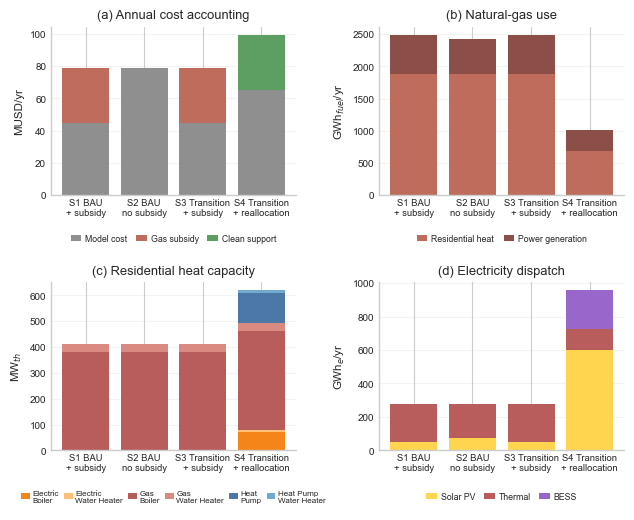

In [47]:
def _policy_electricity_dispatch_by_group(result) -> pd.Series:
    """Annual electricity dispatch by broad technology group [MWh_e/yr]."""
    net = result["network"]

    groups = {
        "Wind": 0.0,
        "Solar PV": 0.0,
        "Thermal": 0.0,
        "BESS": 0.0,
        "Slack": 0.0,
        "Other": 0.0,
    }

    generators = _policy_table_to_dataframe(net.generators)
    dispatch = _policy_table_to_dataframe(net.generators_t.p)

    if (
        not generators.empty
        and not dispatch.empty
        and {"carrier", "bus"}.issubset(generators.columns)
    ):
        elec_ids = generators.index[
            generators["bus"].astype(str).str.startswith("elec_")
        ].tolist()

        if elec_ids:
            dispatch = (
                dispatch
                .reindex(columns=elec_ids, fill_value=0.0)
                .apply(pd.to_numeric, errors="coerce")
                .fillna(0.0)
                .clip(lower=0.0)
            )

            weights = _policy_snapshot_weights(net, dispatch.index)
            annual = dispatch.mul(weights, axis=0).sum(axis=0)

            for asset_id, value in annual.items():
                carrier = (
                    str(generators.loc[asset_id, "carrier"])
                    .strip()
                    .lower()
                )

                if carrier.startswith("wind") or carrier in {"onwind", "offwind"}:
                    group = "Wind"

                elif carrier.startswith("solar") or carrier in {"pv", "solar_pv"}:
                    group = "Solar PV"

                elif carrier in {"ocgt", "gas", "natural_gas", "diesel"}:
                    group = "Thermal"

                elif carrier in {
                    "slack",
                    "load_shedding",
                    "unserved",
                    "lost_load",
                }:
                    group = "Slack"

                else:
                    group = "Other"

                groups[group] += float(value)

    storage_units = _policy_table_to_dataframe(net.storage_units)

    if not storage_units.empty:
        try:
            storage_p = _policy_table_to_dataframe(net.storage_units_t.p)
        except Exception:
            storage_p = pd.DataFrame()

        if not storage_p.empty:
            bess_ids = storage_units.index[
                storage_units.get(
                    "carrier",
                    pd.Series("", index=storage_units.index),
                )
                .astype(str)
                .str.lower()
                .isin({"bess", "battery", "battery_storage"})
            ].tolist()

            if bess_ids:
                storage_p = (
                    storage_p
                    .reindex(columns=bess_ids, fill_value=0.0)
                    .apply(pd.to_numeric, errors="coerce")
                    .fillna(0.0)
                    .clip(lower=0.0)
                )

                weights = _policy_snapshot_weights(net, storage_p.index)

                groups["BESS"] += float(
                    storage_p.mul(weights, axis=0).sum().sum()
                )

    return pd.Series(groups, dtype=float)


def plot_subsidy_cost_capacity_comparison(
    policy_summary,
    heat_summary,
    scenarios,
    year=SUBSIDY_RESULTS_YEAR,
    labels=None,
):
    """
    2x2 result figure for the extended abstract.

      (a) model cost + public support
      (b) natural-gas use: residential heat + electricity generation
      (c) installed residential heat capacity by technology
      (d) annual electricity dispatch by broad technology group

    Legends are placed in dedicated rows below each subplot.
    """

    if policy_summary.empty:
        raise ValueError("heat_policy_summary is empty.")

    scenarios = [
        s
        for s in scenarios
        if s in set(policy_summary["scenario"])
    ]

    if not scenarios:
        raise ValueError(
            "None of SUBSIDY_COMPARISON_SCENARIOS are available "
            "in the loaded results."
        )

    labels = labels or {}

    p = (
        policy_summary[
            policy_summary["scenario"].isin(scenarios)
            & policy_summary["year"].eq(year)
        ]
        .set_index("scenario")
        .reindex(scenarios)
    )

    xlabels = [
        SCENARIO_AXIS_LABELS.get(
            s,
            labels.get(s, s),
        )
        for s in scenarios
    ]

    h = heat_summary[
        heat_summary["scenario"].isin(scenarios)
        & heat_summary["year"].eq(year)
    ].copy()

    cap = (
        h.pivot_table(
            index="scenario",
            columns="technology",
            values="capacity_output_mw",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reindex(scenarios)
        .fillna(0.0)
    )

    dispatch = pd.DataFrame(
        {
            scenario: _policy_electricity_dispatch_by_group(
                scenario_results[scenario]["results"][year]
            )
            for scenario in scenarios
        }
    ).T.fillna(0.0)

    # ------------------------------------------------------------------
    # Layout
    #
    # Row 0 = upper plots
    # Row 1 = upper legends
    # Row 2 = lower plots
    # Row 3 = lower legends
    # ------------------------------------------------------------------

    figure_width = (
        FIGSIZE_PAPER_2X2[0]
        if "FIGSIZE_PAPER_2X2" in globals()
        else 7.2
    )

    fig = plt.figure(
        figsize=(figure_width, 5.25)
    )

    gs = fig.add_gridspec(
        nrows=4,
        ncols=2,
        height_ratios=[
            1.00,   # upper plots
            0.13,   # upper legends
            1.00,   # lower plots
            0.16,   # lower legends
        ],
        hspace=0.34,
        wspace=0.34,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])

    legend_a_ax = fig.add_subplot(gs[1, 0])
    legend_b_ax = fig.add_subplot(gs[1, 1])

    ax_c = fig.add_subplot(gs[2, 0])
    ax_d = fig.add_subplot(gs[2, 1])

    legend_c_ax = fig.add_subplot(gs[3, 0])
    legend_d_ax = fig.add_subplot(gs[3, 1])

    axes = np.array([
        [ax_a, ax_b],
        [ax_c, ax_d],
    ])

    for legend_ax in [
        legend_a_ax,
        legend_b_ax,
        legend_c_ax,
        legend_d_ax,
    ]:
        legend_ax.axis("off")

    # ------------------------------------------------------------------
    # (a) Annual cost accounting
    # ------------------------------------------------------------------

    model_cost = (
        p["model_system_cost"]
        .fillna(0.0)
        / 1e6
    )

    gas_support = (
        p.get(
            "public_gas_subsidy_usd",
            pd.Series(0.0, index=p.index),
        )
        .fillna(0.0)
        / 1e6
    )

    clean_support = (
        p.get(
            "public_clean_support_usd",
            pd.Series(0.0, index=p.index),
        )
        .fillna(0.0)
        / 1e6
    )

    ax_a.bar(
        xlabels,
        model_cost,
        label="Model cost",
        color="#8f8f8f",
    )

    ax_a.bar(
        xlabels,
        gas_support,
        bottom=model_cost,
        label="Gas subsidy",
        color="#c06c5c",
    )

    ax_a.bar(
        xlabels,
        clean_support,
        bottom=model_cost + gas_support,
        label="Clean support",
        color="#5d9f62",
    )

    ax_a.set_title(
        "(a) Annual cost accounting",
        fontsize=9.3,
        pad=6,
    )

    ax_a.set_ylabel(
        "MUSD/yr",
        fontsize=8.3,
    )

    handles, legend_labels = ax_a.get_legend_handles_labels()

    legend_a_ax.legend(
        handles,
        legend_labels,
        loc="center",
        ncol=len(legend_labels),
        fontsize=6.3,
        frameon=False,
        handlelength=1.2,
        handletextpad=0.45,
        columnspacing=1.0,
    )

    # ------------------------------------------------------------------
    # (b) Natural-gas use
    # ------------------------------------------------------------------

    residential_gas = (
        p["residential_gas_input_mwh"]
        .fillna(0.0)
        / 1e3
    )

    generation_gas = (
        p["generation_gas_input_mwh"]
        .fillna(0.0)
        / 1e3
    )

    ax_b.bar(
        xlabels,
        residential_gas,
        label="Residential heat",
        color="#c06c5c",
    )

    ax_b.bar(
        xlabels,
        generation_gas,
        bottom=residential_gas,
        label="Power generation",
        color="#8c4f47",
    )

    ax_b.set_title(
        "(b) Natural-gas use",
        fontsize=9.3,
        pad=6,
    )

    ax_b.set_ylabel(
        "GWh$_{fuel}$/yr",
        fontsize=8.3,
    )

    handles, legend_labels = ax_b.get_legend_handles_labels()

    legend_b_ax.legend(
        handles,
        legend_labels,
        loc="center",
        ncol=len(legend_labels),
        fontsize=6.3,
        frameon=False,
        handlelength=1.2,
        handletextpad=0.45,
        columnspacing=1.1,
    )

    # ------------------------------------------------------------------
    # (c) Residential heat capacity
    # ------------------------------------------------------------------

    heat_colors = {
        "gas_boiler": "#b85c5c",
        "gas_water_heater": "#d98b82",
        "heat_pump": "#4c78a8",
        "heat_pump_water_heater": "#72a9cf",
        "electric_boiler": "#f58518",
        "electric_water_heater": "#ffbf79",
        "biogas_boiler": "#54a24b",
        "biogas_water_heater": "#88c999",
        "pellet_boiler": "#8c6d5a",
        "solar_thermal": "#eeca3b",
    }

    if not cap.empty:
        bottom = np.zeros(len(cap))

        for tech in cap.columns:
            values = cap[tech].to_numpy(dtype=float)

            if np.allclose(values, 0.0):
                continue

            ax_c.bar(
                xlabels,
                values,
                bottom=bottom,
                label=clean_technology_label(tech),
                color=heat_colors.get(
                    tech,
                    "#9e9e9e",
                ),
            )

            bottom += values

    ax_c.set_title(
        "(c) Residential heat capacity",
        fontsize=9.3,
        pad=6,
    )

    ax_c.set_ylabel(
        "MW$_{th}$",
        fontsize=8.3,
    )

    handles, legend_labels = ax_c.get_legend_handles_labels()

    # Keep complete technology names, but wrap long names
    # to make one readable legend row possible.
    heat_legend_wrap = {
        "Electric Boiler":
            "Electric\nBoiler",

        "Electric Water Heater":
            "Electric\nWater Heater",

        "Gas Boiler":
            "Gas\nBoiler",

        "Gas Water Heater":
            "Gas\nWater Heater",

        "Heat Pump":
            "Heat\nPump",

        "Heat Pump Water Heater":
            "Heat Pump\nWater Heater",
    }

    legend_labels = [
        heat_legend_wrap.get(label, label)
        for label in legend_labels
    ]

    if handles:
        legend_c_ax.legend(
            handles,
            legend_labels,
            loc="center",
            ncol=len(legend_labels),
            fontsize=5.8,
            frameon=False,
            handlelength=1.05,
            handletextpad=0.35,
            columnspacing=0.65,
            labelspacing=0.15,
        )

    # ------------------------------------------------------------------
    # (d) Electricity dispatch
    # ------------------------------------------------------------------

    dispatch_order = [
        "Wind",
        "Solar PV",
        "Thermal",
        "BESS",
        "Slack",
        "Other",
    ]

    bottom = np.zeros(len(dispatch))

    for group in dispatch_order:
        if group not in dispatch.columns:
            continue

        values = (
            dispatch[group]
            .to_numpy(dtype=float)
            / 1e3
        )

        if np.allclose(values, 0.0):
            continue

        ax_d.bar(
            xlabels,
            values,
            bottom=bottom,
            label=group,
            color=TECH_COLORS_GROUPED.get(
                group,
                "#9e9e9e",
            ),
        )

        bottom += values

    ax_d.set_title(
        "(d) Electricity dispatch",
        fontsize=9.3,
        pad=6,
    )

    ax_d.set_ylabel(
        "GWh$_e$/yr",
        fontsize=8.3,
    )

    handles, legend_labels = ax_d.get_legend_handles_labels()

    legend_d_ax.legend(
        handles,
        legend_labels,
        loc="center",
        ncol=len(legend_labels),
        fontsize=6.3,
        frameon=False,
        handlelength=1.2,
        handletextpad=0.45,
        columnspacing=1.0,
    )

    # ------------------------------------------------------------------
    # Shared formatting
    # ------------------------------------------------------------------

    for ax in axes.ravel():

        ax.grid(
            True,
            axis="y",
            alpha=0.22,
        )

        ax.set_axisbelow(True)

        ax.tick_params(
            axis="x",
            rotation=0,
            labelsize=6.8,
            pad=2,
        )

        ax.tick_params(
            axis="y",
            labelsize=7.2,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.align_ylabels(
        [ax_a, ax_c]
    )

    fig.align_ylabels(
        [ax_b, ax_d]
    )

    fig.subplots_adjust(
        left=0.085,
        right=0.995,
        top=0.965,
        bottom=0.045,
    )

    # ------------------------------------------------------------------
    # Save
    # ------------------------------------------------------------------

    publication_path = (
        SUBSIDY_FIGURE_DIR
        / f"figure_subsidy_policy_comparison_{year}.svg"
    )

    legacy_path = (
        SUBSIDY_FIGURE_DIR
        / f"subsidy_cost_capacity_comparison_{year}.svg"
    )

    fig.savefig(
        publication_path,
        dpi=PAPER_DPI,
        bbox_inches="tight",
    )

    fig.savefig(
        legacy_path,
        dpi=PAPER_DPI,
        bbox_inches="tight",
    )

    print(
        f"Saved: {publication_path}"
    )

    plt.show()

    return fig, axes


if SUBSIDY_COMPARISON_SCENARIOS:

    plot_subsidy_cost_capacity_comparison(
        heat_policy_summary,
        model_heat_summary,
        scenarios=SUBSIDY_COMPARISON_SCENARIOS,
        year=SUBSIDY_RESULTS_YEAR,
        labels={
            s: SCENARIO_TECH_LABELS.get(s, s)
            for s in SUBSIDY_COMPARISON_SCENARIOS
        },
    )

else:

    print(
        "Set SUBSIDY_COMPARISON_SCENARIOS after the "
        "with-/without-subsidy policy cases have been simulated."
    )

### 11.5 Hourly residential heat operation

This adds a thermal-service dispatch view alongside the electricity, storage, hydrogen, and critical-event dispatch analyses already available above.

In [43]:
def plot_residential_heat_dispatch(
    scenario,
    year,
    start,
    days=7,
):
    if scenario not in scenario_results:
        raise KeyError(f"Scenario not loaded: {scenario}")
    if year not in scenario_results[scenario]["results"]:
        raise KeyError(f"Year {year} is not loaded for scenario {scenario}.")

    net = scenario_results[scenario]["results"][year]["network"]
    links = _as_dataframe(net.links)
    if links.empty:
        raise ValueError("Network contains no links.")

    mask = _heat_link_mask(net, links, heat_assets_subsidy)
    heat_links = links.loc[mask].copy()
    if heat_links.empty:
        raise ValueError(
            "No heat-conversion links were found. Run the scenario with enable_heat=True."
        )

    p1 = _as_dataframe(net.links_t.p1)
    supply = {}

    for link_id, row in heat_links.iterrows():
        if link_id not in p1.columns:
            continue
        tech = str(row.get("carrier", link_id))
        series = pd.to_numeric(p1[link_id], errors="coerce").abs().fillna(0.0)
        if tech in supply:
            supply[tech] = supply[tech].add(series, fill_value=0.0)
        else:
            supply[tech] = series

    supply = pd.DataFrame(supply).fillna(0.0)
    supply.index = pd.to_datetime(supply.index)

    start = pd.Timestamp(start)
    end = start + pd.Timedelta(days=int(days))
    supply = supply.loc[(supply.index >= start) & (supply.index < end)]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    if not supply.empty:
        supply.plot.area(ax=ax, stacked=True, alpha=0.85)

    ax.set_title(f"{scenario} — residential heat supply ({year})")
    ax.set_ylabel("Useful heat supply [MW$_{th}$]")
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Technology", fontsize=8, ncol=2)
    plt.tight_layout()

    path = SUBSIDY_FIGURE_DIR / f"heat_dispatch_{scenario}_{year}_{start:%Y%m%d}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()


# Example after a heat-enabled run:
# plot_residential_heat_dispatch("TRANS_NOSUB", 2050, "2050-07-01", days=7)

### 11.6 Publication checklist for the subsidy extension

Before using the policy figure in the extended abstract or paper:

1. run the four scenarios with `enable_heat=True` and the `_2` input folder;
2. ensure the demand-profile file contains `space_heat` and `hot_water` directly;
3. treat 2025 as the common subsidized base year; the subsidy-removal/reallocation policy starts in 2030;
4. run `BAU_SUB` and `BAU_NOSUB` first and verify `subsidy_budget_reference.csv`;
5. confirm that the reference budget includes **both residential gas and gas used by GX**;
6. confirm that the no-subsidy cost inputs remove the gas subsidy from **both** `natural_gas` for heat and the OCGT/gas-generation cost;
7. treat `BAU_NOSUB - BAU_SUB` as a diagnostic, not as the fiscal subsidy itself;
8. for `TRANS_NOSUB`, report the available clean-investment budget, the amount actually used, and any unused budget;
9. keep the support fraction (currently 50%) explicit and test it as a sensitivity if it materially changes the results;
10. use `figure_subsidy_policy_comparison_2050.png` as the main result figure for the extended abstract; keep the generic cross-scenario decompositions as supplementary diagnostics.
